# EDA: Deteccion de Leucemia a partir de Imagenes de Celulas Sanguineas (v2)

Version adaptada a los datasets **originales publicados por los autores**:

- **WBCAtt / PBC dataset** (celulas sanas, `LY_3945.jpg`, etc.) -> se distribuye como 3 CSV de atributos (`pbc_attr_v1_train.csv`, `_val.csv`, `_test.csv`) separados de las imagenes.
  Repo: https://github.com/apple2373/wbcatt
- **LeukemiaAttri** (celulas con leucemia, `1_16_111_400_ALL.png`, etc.) -> cada carpeta `Grupo_Magnificacion_Control` (ej. `H_10X_C1`) contiene `Images/`, `json_labels/` y `txt_labels/`.
  Repo: https://github.com/intelligentMachines-ITU/Blood-Cancer-Dataset-Lukemia-Attri-MICCAI-2024

**Que cambia respecto a la version anterior del EDA:**
1. Ya no se recorre `HEALTHY_DIR` como carpetas-por-clase; se leen los CSV de WBCAtt y se resuelve la ruta de cada imagen.
2. En LeukemiaAttri la subcarpeta de imagenes paso de `images/train` a `Images`.
3. Se agregan secciones nuevas de EDA de **atributos morfologicos**, que antes no existian porque no teniamos esas anotaciones.

> Las rutas de la seccion 1 son las unicas que casi seguro debes ajustar a tu maquina. Todo lo demas deberia funcionar sin tocarlo, pero cada bloque imprime lo que encuentra para que puedas detectar rapido si algo no calza con tu estructura real.


## 1. Configuracion de entorno y rutas

In [1]:
# %pip install pandas numpy matplotlib pillow scikit-image statsmodels opencv-python
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def progreso(i, total, inicio, cada=2000, etiqueta=""):
    """Imprime avance cada 'cada' iteraciones, para que los bucles largos
    (miles de imagenes sobre OneDrive) no parezcan congelados."""
    if total and (i % cada == 0 or i == total):
        transcurrido = time.time() - inicio
        print(f"  [{etiqueta}] {i}/{total} ({i / total * 100:.1f}%) - {transcurrido:.0f}s transcurridos")

# ------------------------------------------------------------
# WBCAtt (celulas sanas): carpeta con los 3 CSV de atributos
# ------------------------------------------------------------
WBCATT_DIR = Path(r"C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\WBCAtt")

WBCATT_CSVS = {
    "train": WBCATT_DIR / "pbc_attr_v1_train.csv",
    "val":   WBCATT_DIR / "pbc_attr_v1_val.csv",
    "test":  WBCATT_DIR / "pbc_attr_v1_test.csv",
}

# Carpeta donde viven FISICAMENTE las imagenes del dataset PBC
# (el CSV trae una columna "path" relativa a esta carpeta).
# Si no la tienes descargada por separado, ajusta esta ruta cuando
# la tengas; el resto del notebook sigue funcionando con el CSV solo,
# pero no podra abrir/analizar pixeles hasta que esto apunte a las imagenes reales.
WBCATT_IMAGES_DIR = Path(r"C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\WBCAtt\PBC_dataset_normal_DIB")

# ------------------------------------------------------------
# LeukemiaAttri (celulas con leucemia): carpetas Grupo_Magnificacion_Control
# ------------------------------------------------------------
# IMPORTANTE: cuando descargas una carpeta compartida grande desde OneDrive/Drive,
# suele venir partida en varias sub-descargas (ej. "..._1-001", "..._1-002", ...),
# cada una con su propia copia del arbol "LeukemiaAttri_Dataset/H_10X_C1/Images/...".
# Por eso NO apuntamos a una parte especifica: apuntamos a la carpeta que las
# contiene a TODAS ("LeukemiaAttri") y mas abajo buscamos de forma recursiva
# cualquier carpeta con patron Grupo_Magnificacion_Control (H_10X_C1, L_40X_C2, etc.),
# sin importar en cual de las partes este.
LEUKEMIA_ROOT = Path(r"C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri")

print("WBCATT_DIR       :", WBCATT_DIR, "->", WBCATT_DIR.exists())
for split, p in WBCATT_CSVS.items():
    print(f"  CSV {split:<5}:", p, "->", p.exists())
print("WBCATT_IMAGES_DIR:", WBCATT_IMAGES_DIR, "->", WBCATT_IMAGES_DIR.exists())

print("\nLEUKEMIA_ROOT     :", LEUKEMIA_ROOT, "->", LEUKEMIA_ROOT.exists())
if LEUKEMIA_ROOT.exists():
    partes = [f.name for f in sorted(LEUKEMIA_ROOT.iterdir()) if f.is_dir()]
    print(f"  Partes/subcarpetas de primer nivel encontradas ({len(partes)}):")
    for p in partes:
        print("   -", p)


WBCATT_DIR       : C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\WBCAtt -> True
  CSV train: C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\WBCAtt\pbc_attr_v1_train.csv -> True
  CSV val  : C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\WBCAtt\pbc_attr_v1_val.csv -> True
  CSV test : C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\WBCAtt\pbc_attr_v1_test.csv -> True
WBCATT_IMAGES_DIR: C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\WBCAtt\PBC_dataset_normal_DIB -> False

LEUKEMIA_ROOT     : C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri -> True
  Partes/subcarpetas de primer nivel encontradas (5):
   - LeukemiaAttri_Dataset-20260907T175427Z-1-001
   - LeukemiaAttri_Dataset-20260907T175427Z-1-002
   - LeukemiaAttri_Dataset-20260907T175427Z-1-003
   - LeukemiaAtt

## 2. Carga de WBCAtt (atributos + resolucion de rutas de imagen)

Los CSV traen (segun la documentacion oficial del dataset):

- `img_name`: nombre del archivo (identificador unico).
- `label`: una de las 5 clases WBC del dataset PBC (neutrophils, eosinophils, basophils, monocytes, lymphocytes).
- `path`: ruta de la imagen dentro del dataset PBC original.
- 11 columnas de atributos morfologicos: `cell_size`, `cell_shape`, `nucleus_shape`, `nuclear_cytoplasmic_ratio`, `chromatin_density`, `cytoplasm_vacuole`, `cytoplasm_texture`, `cytoplasm_colour`, `granule_type`, `granule_colour`, `granularity`.

Primero cargamos e inspeccionamos, porque el nombre exacto de columnas puede variar ligeramente segun la version del CSV que te compartieron.

In [2]:
# Cargar los 3 splits y unirlos en un solo DataFrame con una columna "Split"
wbcatt_frames = []
for split, path in WBCATT_CSVS.items():
    if not path.exists():
        print(f"[AVISO] No se encontro {path}, se omite el split '{split}'.")
        continue
    df_split = pd.read_csv(path)
    df_split["Split"] = split
    wbcatt_frames.append(df_split)

if wbcatt_frames:
    wbcatt_df = pd.concat(wbcatt_frames, ignore_index=True)
else:
    wbcatt_df = pd.DataFrame()

print(f"Total de filas cargadas (WBCAtt): {len(wbcatt_df)}")
print("\nColumnas encontradas:")
print(list(wbcatt_df.columns))
print("\nPrimeras filas:")
wbcatt_df.head()


Total de filas cargadas (WBCAtt): 10298

Columnas encontradas:
['img_name', 'label', 'cell_size', 'cell_shape', 'nucleus_shape', 'nuclear_cytoplasmic_ratio', 'chromatin_density', 'cytoplasm_vacuole', 'cytoplasm_texture', 'cytoplasm_colour', 'granule_type', 'granule_colour', 'granularity', 'path', 'Split']

Primeras filas:


,img_name,label,cell_size,cell_shape,nucleus_shape,nuclear_cytoplasmic_ratio,chromatin_density,cytoplasm_vacuole,cytoplasm_texture,cytoplasm_colour,granule_type,granule_colour,granularity,path,Split
0,BNE_7323.jpg,Neutrophil,big,round,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_7323.jpg,train
1,BNE_7938.jpg,Neutrophil,big,irregular,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_7938.jpg,train
2,BNE_8741.jpg,Neutrophil,big,irregular,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_8741.jpg,train
3,BNE_9071.jpg,Neutrophil,big,irregular,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_9071.jpg,train
4,BNE_9373.jpg,Neutrophil,small,round,unsegmented-round,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_9373.jpg,train


In [3]:
# Columnas de atributos morfologicos esperadas (segun documentacion oficial WBCAtt)
ATTRIBUTE_COLS_WBCATT = [
    "cell_size", "cell_shape", "nucleus_shape", "nuclear_cytoplasmic_ratio",
    "chromatin_density", "cytoplasm_vacuole", "cytoplasm_texture",
    "cytoplasm_colour", "granule_type", "granule_colour", "granularity",
]

# Verificamos cuales de esas columnas realmente existen en tu CSV
# (por si el compañero exporto con nombres ligeramente distintos, ej. mayusculas)
cols_lower = {c.lower(): c for c in wbcatt_df.columns}
ATTRIBUTE_COLS_WBCATT = [cols_lower[c] for c in ATTRIBUTE_COLS_WBCATT if c in cols_lower]

LABEL_COL_WBCATT = cols_lower.get("label", None)
IMGNAME_COL_WBCATT = cols_lower.get("img_name", None)
PATH_COL_WBCATT = cols_lower.get("path", None)

print("Columnas de atributos detectadas:", ATTRIBUTE_COLS_WBCATT)
print("Columna de clase (label)        :", LABEL_COL_WBCATT)
print("Columna de nombre de archivo     :", IMGNAME_COL_WBCATT)
print("Columna de ruta                  :", PATH_COL_WBCATT)


Columnas de atributos detectadas: ['cell_size', 'cell_shape', 'nucleus_shape', 'nuclear_cytoplasmic_ratio', 'chromatin_density', 'cytoplasm_vacuole', 'cytoplasm_texture', 'cytoplasm_colour', 'granule_type', 'granule_colour', 'granularity']
Columna de clase (label)        : label
Columna de nombre de archivo     : img_name
Columna de ruta                  : path


In [4]:
# Construir la ruta absoluta de cada imagen a partir de WBCATT_IMAGES_DIR + columna "path"
def resolver_ruta_wbcatt(fila):
    if PATH_COL_WBCATT and pd.notna(fila.get(PATH_COL_WBCATT)):
        return WBCATT_IMAGES_DIR / str(fila[PATH_COL_WBCATT])
    if IMGNAME_COL_WBCATT and pd.notna(fila.get(IMGNAME_COL_WBCATT)):
        return WBCATT_IMAGES_DIR / str(fila[IMGNAME_COL_WBCATT])
    return None

if not wbcatt_df.empty:
    wbcatt_df["Ruta_Absoluta"] = wbcatt_df.apply(resolver_ruta_wbcatt, axis=1)
    wbcatt_df["Existe"] = wbcatt_df["Ruta_Absoluta"].apply(lambda p: p.exists() if p is not None else False)

    print(f"Imagenes cuya ruta SI se encontro en disco : {wbcatt_df['Existe'].sum()} / {len(wbcatt_df)}")
    print(f"Imagenes cuya ruta NO se encontro en disco : {(~wbcatt_df['Existe']).sum()} / {len(wbcatt_df)}")

    if wbcatt_df["Existe"].sum() == 0:
        print("\n[AVISO] Ninguna ruta resolvio a un archivo real.")
        print("Revisa WBCATT_IMAGES_DIR y/o el contenido de la columna 'path' con:")
        print("  wbcatt_df[[PATH_COL_WBCATT, 'Ruta_Absoluta']].head(10)")


Imagenes cuya ruta SI se encontro en disco : 0 / 10298
Imagenes cuya ruta NO se encontro en disco : 10298 / 10298

[AVISO] Ninguna ruta resolvio a un archivo real.
Revisa WBCATT_IMAGES_DIR y/o el contenido de la columna 'path' con:
  wbcatt_df[[PATH_COL_WBCATT, 'Ruta_Absoluta']].head(10)


## 3. Carga de LeukemiaAttri (imagenes + labels)

Buscamos de forma **recursiva** dentro de `LEUKEMIA_ROOT` cualquier carpeta cuyo
nombre siga el patron `Grupo_Magnificacion_Control` (ej. `H_10X_C1`, `L_40X_C2`),
sin importar en cual de las partes descargadas (`..._1-001`, `..._1-002`, etc.)
este ubicada. Esto es lo que estaba fallando antes: apuntabamos a una sola parte
y las demas quedaban fuera, o el nivel de anidamiento no coincidia exactamente.

Dentro de cada carpeta de condicion encontrada, tomamos las imagenes de `Images/`
(o `images/` en minuscula, por si acaso). Dentro de `Images/` a veces hay
subcarpetas `train/` y `test/` con las imagenes adentro (en vez de estar
sueltas directamente en `Images/`); usamos busqueda recursiva para que
funcione sin importar cual de los dos casos aplique, y guardamos en que
subcarpeta (`Split`) estaba cada imagen por si te sirve luego.

In [5]:
import re

PATRON_CARPETA_CONDICION = re.compile(r"^[HL]_\d+X_C\d+$")

def encontrar_carpetas_condicion(root):
    """Busca recursivamente, en cualquier nivel bajo 'root', carpetas cuyo nombre
    matchee Grupo_Magnificacion_Control (ej. H_10X_C1). Asi no importa si el
    dataset esta partido en varias sub-descargas de OneDrive/Drive."""
    encontradas = []
    if not root.exists():
        return encontradas
    for p in root.rglob("*"):
        if p.is_dir() and PATRON_CARPETA_CONDICION.match(p.name):
            encontradas.append(p)
    return sorted(encontradas, key=lambda p: str(p))

carpetas_condicion = encontrar_carpetas_condicion(LEUKEMIA_ROOT)
print(f"Carpetas de condicion (Grupo_Magnificacion_Control) encontradas: {len(carpetas_condicion)}")
for c in carpetas_condicion:
    print("  -", c)

if not carpetas_condicion:
    print("\n[AVISO] No se encontro ninguna carpeta con el patron esperado (ej. H_10X_C1).")
    print("Revisa LEUKEMIA_ROOT y confirma que el nombre de esas carpetas sea exactamente asi")
    print("(mayusculas, guion bajo). Si el patron real es distinto, ajusta PATRON_CARPETA_CONDICION.")


Carpetas de condicion (Grupo_Magnificacion_Control) encontradas: 56
  - C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri\LeukemiaAttri_Dataset-20260907T175427Z-1-001\LeukemiaAttri_Dataset\H_100X_C1
  - C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri\LeukemiaAttri_Dataset-20260907T175427Z-1-001\LeukemiaAttri_Dataset\H_100X_C2
  - C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri\LeukemiaAttri_Dataset-20260907T175427Z-1-001\LeukemiaAttri_Dataset\H_10X_C1
  - C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri\LeukemiaAttri_Dataset-20260907T175427Z-1-001\LeukemiaAttri_Dataset\H_10X_C2
  - C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri\LeukemiaAttri_Dataset-20260907T175427Z-1-001\LeukemiaAttri_Dataset\H_40X_C1
  - C:\Users\karin\OneDrive - Instituto Polit

In [6]:
def parse_carpeta_leukemia(nombre_carpeta):
    partes = nombre_carpeta.split("_")
    if len(partes) == 3:
        grupo, magnificacion, control = partes
        return grupo, magnificacion, control
    return None, None, None

leukemia_image_records = []

for folder in carpetas_condicion:
    images_dir = folder / "Images"
    if not images_dir.exists():
        # Compatibilidad por si alguna carpeta usa minuscula
        images_dir = folder / "images"
    if not images_dir.exists():
        print(f"[AVISO] {folder} no tiene subcarpeta Images/ ni images/, se omite.")
        continue

    grupo, magnificacion, control = parse_carpeta_leukemia(folder.name)

    # Usamos rglob porque dentro de "Images" puede haber subcarpetas como
    # train/ y test/ (o ninguna, segun la carpeta de condicion); asi funciona
    # sin importar el nivel de anidamiento.
    for image_path in images_dir.rglob("*"):
        if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        leukemia_image_records.append({
            "Carpeta": folder.name,
            "Grupo": grupo,
            "Magnificacion": magnificacion,
            "Control": control,
            "Split": image_path.parent.name.lower() if image_path.parent != images_dir else "n/a",
            "Archivo": image_path.name,
            "Ruta_Absoluta": image_path,
            # Guardamos la carpeta de condicion completa (no la ruta al label)
            # porque los labels pueden estar como carpeta "txt_labels/" YA
            # extraida, o como archivo "txt_labels.zip" sin extraer.
            "Carpeta_Condicion_Path": folder,
        })

leukemia_df = pd.DataFrame(leukemia_image_records)
print(f"Total de imagenes encontradas en LeukemiaAttri: {len(leukemia_df)}")
if not leukemia_df.empty:
    print("\nCarpetas detectadas y conteo de imagenes:")
    print(leukemia_df["Carpeta"].value_counts())
    print("\nConteo por Split (train/test) si aplica:")
    print(leukemia_df["Split"].value_counts())

    # Aviso si alguna de las 12 combinaciones esperadas (H/L x 10X/40X/100X x C1/C2)
    # termino con cero imagenes en TODAS las partes revisadas: puede ser una carpeta
    # que aun no termina de sincronizar en OneDrive, o que realmente falta.
    combinaciones_esperadas = {
        f"{g}_{m}_{c}"
        for g in ["H", "L"]
        for m in ["10X", "40X", "100X"]
        for c in ["C1", "C2"]
    }
    combinaciones_encontradas = set(leukemia_df["Carpeta"].unique())
    faltantes = combinaciones_esperadas - combinaciones_encontradas
    if faltantes:
        print("\n[AVISO] Estas combinaciones no aportaron ninguna imagen en ninguna parte revisada:")
        for f in sorted(faltantes):
            print("  -", f)
        print("Revisa en el explorador si esas carpetas siguen sincronizando en OneDrive.")


[AVISO] C:\Users\karin\OneDrive - Instituto Politecnico Nacional\Desktop\TT\Dataset Andres\LeukemiaAttri\LeukemiaAttri_Dataset-20260907T175427Z-1-001\LeukemiaAttri_Dataset\L_10X_C1 no tiene subcarpeta Images/ ni images/, se omite.
Total de imagenes encontradas en LeukemiaAttri: 25790

Carpetas detectadas y conteo de imagenes:
Carpeta
L_10X_C2     2371
H_100X_C2    2369
H_10X_C2     2369
H_100X_C1    2368
L_100X_C1    2365
L_40X_C1     2365
L_40X_C2     2365
H_40X_C2     2352
H_40X_C1     2315
L_100X_C2    2286
H_10X_C1     2265
Name: count, dtype: int64

Conteo por Split (train/test) si aplica:
Split
train    18340
test      7450
Name: count, dtype: int64

[AVISO] Estas combinaciones no aportaron ninguna imagen en ninguna parte revisada:
  - L_10X_C1
Revisa en el explorador si esas carpetas siguen sincronizando en OneDrive.


## 4. Verificacion de integridad de imagenes (ambos datasets)

Se reutiliza una unica funcion generica que recibe una lista de rutas, en vez de asumir una estructura de carpetas fija. Esto es lo que realmente cambiaba entre versiones del dataset, asi que separarlo evita tener que reescribir esta logica cada vez que cambie la estructura de carpetas.

In [7]:
def analizar_calidad_imagenes(rutas, nombre_dataset=""):
    format_counts = Counter()
    size_counts = Counter()
    mode_counts = Counter()
    corrupted_images = []
    total_images = 0

    inicio = time.time()
    total_a_revisar = len(rutas)
    print(f"Iniciando revision de {total_a_revisar} imagenes ({nombre_dataset})...")

    for i, image_path in enumerate(rutas, start=1):
        progreso(i, total_a_revisar, inicio, cada=2000, etiqueta=nombre_dataset)

        if image_path is None or not Path(image_path).exists():
            continue
        total_images += 1
        try:
            with Image.open(image_path) as img:
                img.verify()
            with Image.open(image_path) as img:
                format_counts[img.format] += 1
                size_counts[img.size] += 1
                mode_counts[img.mode] += 1
        except Exception as e:
            corrupted_images.append({"archivo": str(image_path), "error": str(e)})

    print(f"Terminado en {time.time() - inicio:.0f}s.")
    return total_images, format_counts, size_counts, mode_counts, corrupted_images


def imprimir_reporte_calidad(nombre, resultados):
    total, formatos, tamanios, modos, corruptas = resultados
    print(f"========== REVISION DE IMAGENES: {nombre.upper()} ==========")
    print(f"Total revisadas: {total}\n")
    print("--- Formatos ---", *[f"{k}: {v}" for k, v in formatos.most_common()], sep="\n")
    print("\n--- Dimensiones (top 10) ---", *[f"{k}: {v}" for k, v in tamanios.most_common(10)], sep="\n")
    print("\n--- Modos ---", *[f"{k}: {v}" for k, v in modos.most_common()], sep="\n")
    print(f"\n--- Imagenes con problemas ---\nTotal: {len(corruptas)}\n")


rutas_wbcatt = wbcatt_df.loc[wbcatt_df.get("Existe", pd.Series(dtype=bool)) == True, "Ruta_Absoluta"].tolist() if not wbcatt_df.empty else []
rutas_leukemia = leukemia_df["Ruta_Absoluta"].tolist() if not leukemia_df.empty else []

reporte_wbcatt = analizar_calidad_imagenes(rutas_wbcatt, "WBCAtt")
reporte_leukemia = analizar_calidad_imagenes(rutas_leukemia, "LeukemiaAttri")

imprimir_reporte_calidad("WBCAtt (sanas)", reporte_wbcatt)
imprimir_reporte_calidad("LeukemiaAttri", reporte_leukemia)


Iniciando revision de 0 imagenes (WBCAtt)...
Terminado en 0s.
Iniciando revision de 25790 imagenes (LeukemiaAttri)...
  [LeukemiaAttri] 2000/25790 (7.8%) - 10s transcurridos
  [LeukemiaAttri] 4000/25790 (15.5%) - 21s transcurridos
  [LeukemiaAttri] 6000/25790 (23.3%) - 32s transcurridos
  [LeukemiaAttri] 8000/25790 (31.0%) - 44s transcurridos
  [LeukemiaAttri] 10000/25790 (38.8%) - 53s transcurridos
  [LeukemiaAttri] 12000/25790 (46.5%) - 62s transcurridos
  [LeukemiaAttri] 14000/25790 (54.3%) - 73s transcurridos
  [LeukemiaAttri] 16000/25790 (62.0%) - 81s transcurridos
  [LeukemiaAttri] 18000/25790 (69.8%) - 90s transcurridos
  [LeukemiaAttri] 20000/25790 (77.5%) - 100s transcurridos
  [LeukemiaAttri] 22000/25790 (85.3%) - 111s transcurridos
  [LeukemiaAttri] 24000/25790 (93.1%) - 122s transcurridos
  [LeukemiaAttri] 25790/25790 (100.0%) - 132s transcurridos
Terminado en 132s.
========== REVISION DE IMAGENES: WBCATT (SANAS) ==========
Total revisadas: 0

--- Formatos ---

--- Dimensio

## 5. Distribucion de clases

- **WBCAtt**: distribucion de la columna `label` (tipo de celula sana).
- **LeukemiaAttri**: distribucion por carpeta (Grupo x Magnificacion x Control), igual que en la version anterior del EDA, solo que ahora el conteo de imagenes viene de `leukemia_df` en vez de recorrer `images/train`.

In [8]:
# Distribucion WBCAtt
if not wbcatt_df.empty and LABEL_COL_WBCATT:
    df_wbcatt_clase = (
        wbcatt_df[LABEL_COL_WBCATT]
        .value_counts()
        .rename_axis("Clase")
        .reset_index(name="Imagenes")
    )
    df_wbcatt_clase["Porcentaje (%)"] = (df_wbcatt_clase["Imagenes"] / df_wbcatt_clase["Imagenes"].sum() * 100).round(2)
    print("========== DISTRIBUCION WBCAtt (por label) ==========")
    print(df_wbcatt_clase.to_string(index=False))
else:
    df_wbcatt_clase = pd.DataFrame()
    print("No hay datos de WBCAtt cargados todavia.")

# Distribucion LeukemiaAttri
if not leukemia_df.empty:
    df_leukemia_dist = (
        leukemia_df.groupby(["Grupo", "Magnificacion", "Control"])
        .size()
        .reset_index(name="Imagenes")
    )
    df_leukemia_dist["Porcentaje (%)"] = (df_leukemia_dist["Imagenes"] / df_leukemia_dist["Imagenes"].sum() * 100).round(2)
    print("\n========== DISTRIBUCION LeukemiaAttri ==========")
    print(df_leukemia_dist.sort_values("Imagenes", ascending=False).to_string(index=False))
else:
    df_leukemia_dist = pd.DataFrame()
    print("No hay datos de LeukemiaAttri cargados todavia.")


========== DISTRIBUCION WBCAtt (por label) ==========
     Clase  Imagenes  Porcentaje (%)
Neutrophil      3329           32.33
Eosinophil      3117           30.27
  Monocyte      1420           13.79
  Basophil      1218           11.83
Lymphocyte      1214           11.79

========== DISTRIBUCION LeukemiaAttri ==========
Grupo Magnificacion Control  Imagenes  Porcentaje (%)
    L           10X      C2      2371            9.19
    H           10X      C2      2369            9.19
    H          100X      C2      2369            9.19
    H          100X      C1      2368            9.18
    L           40X      C2      2365            9.17
    L           40X      C1      2365            9.17
    L          100X      C1      2365            9.17
    H           40X      C2      2352            9.12
    H           40X      C1      2315            8.98
    L          100X      C2      2286            8.86
    H           10X      C1      2265            8.78


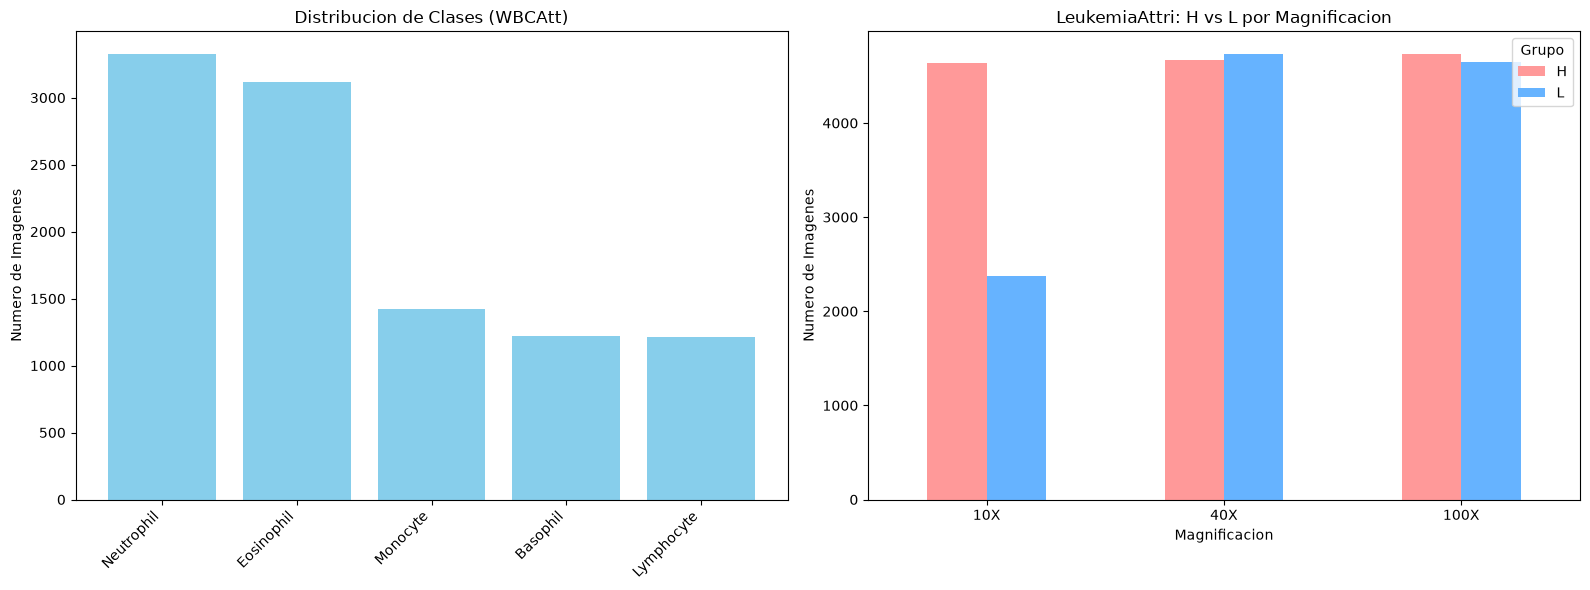

In [9]:
# Graficas de distribucion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

if not df_wbcatt_clase.empty:
    ax1.bar(df_wbcatt_clase["Clase"], df_wbcatt_clase["Imagenes"], color="skyblue")
    ax1.set_title("Distribucion de Clases (WBCAtt)")
    ax1.set_xticks(range(len(df_wbcatt_clase["Clase"])))
    ax1.set_xticklabels(df_wbcatt_clase["Clase"], rotation=45, ha="right")
    ax1.set_ylabel("Numero de Imagenes")

if not df_leukemia_dist.empty:
    df_mag = df_leukemia_dist.pivot_table(index="Magnificacion", columns="Grupo", values="Imagenes", aggfunc="sum", fill_value=0)
    df_mag = df_mag.reindex([m for m in ["10X", "40X", "100X"] if m in df_mag.index])
    df_mag.plot(kind="bar", ax=ax2, color=["#ff9999", "#66b3ff"])
    ax2.set_title("LeukemiaAttri: H vs L por Magnificacion")
    ax2.set_xlabel("Magnificacion")
    ax2.set_ylabel("Numero de Imagenes")
    ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 6. EDA de atributos morfologicos - WBCAtt (NUEVO)

Esto no existia en la version anterior del EDA porque antes no teniamos anotaciones de atributos, solo imagenes por carpeta. Ahora podemos ver, por cada uno de los 11 atributos, como se distribuyen sus valores posibles, y como se relacionan con la clase (`label`).

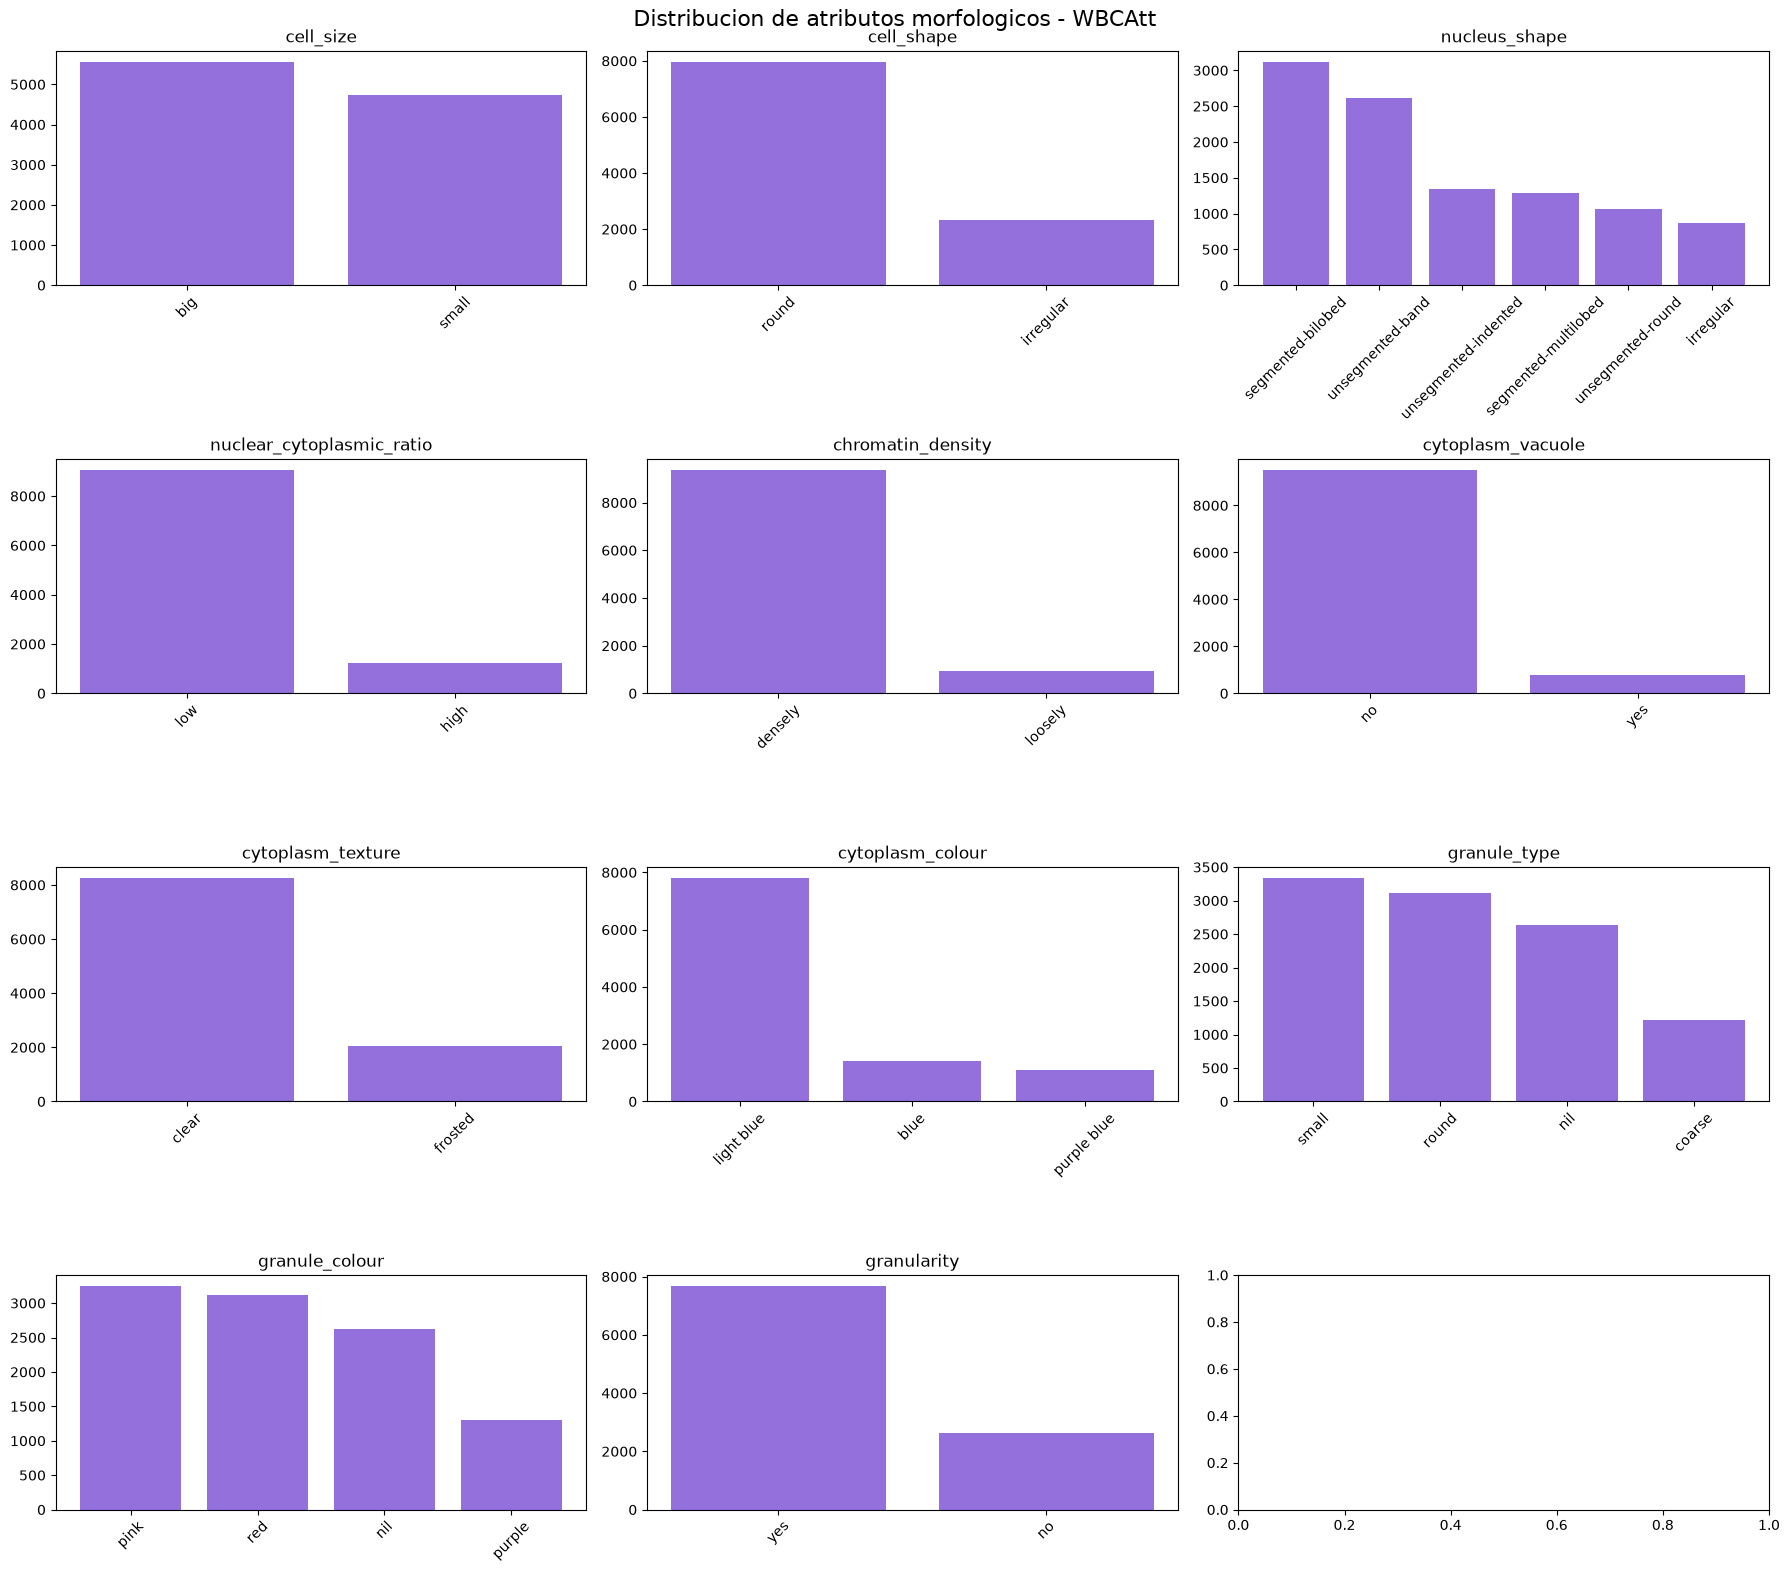

In [10]:
if not wbcatt_df.empty and ATTRIBUTE_COLS_WBCATT:
    n_attrs = len(ATTRIBUTE_COLS_WBCATT)
    n_cols = 3
    n_rows = -(-n_attrs // n_cols)  # ceil

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flat if n_attrs > 1 else [axes]

    for ax, attr in zip(axes, ATTRIBUTE_COLS_WBCATT):
        conteo = wbcatt_df[attr].value_counts()
        ax.bar(conteo.index.astype(str), conteo.values, color="mediumpurple")
        ax.set_title(attr)
        ax.tick_params(axis="x", rotation=45)

    for ax in list(axes)[n_attrs:]:
        ax.axis("off")

    plt.suptitle("Distribucion de atributos morfologicos - WBCAtt", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas de atributos para graficar.")


In [11]:
# Tabla cruzada: atributo vs clase (label), para detectar si algun atributo
# esta fuertemente asociado a una clase especifica de celula
if not wbcatt_df.empty and LABEL_COL_WBCATT and ATTRIBUTE_COLS_WBCATT:
    for attr in ATTRIBUTE_COLS_WBCATT:
        print(f"\n=== {attr} vs {LABEL_COL_WBCATT} ===")
        tabla = pd.crosstab(wbcatt_df[LABEL_COL_WBCATT], wbcatt_df[attr], normalize="index").round(3) * 100
        print(tabla.to_string())



=== cell_size vs label ===
cell_size    big  small
label                  
Basophil    27.3   72.7
Eosinophil  63.3   36.7
Lymphocyte   0.8   99.2
Monocyte    86.5   13.5
Neutrophil  60.6   39.4

=== cell_shape vs label ===
cell_shape  irregular  round
label                       
Basophil         11.0   89.0
Eosinophil        8.3   91.7
Lymphocyte       32.9   67.1
Monocyte         55.5   44.5
Neutrophil       22.6   77.4

=== nucleus_shape vs label ===
nucleus_shape  irregular  segmented-bilobed  segmented-multilobed  unsegmented-band  unsegmented-indented  unsegmented-round
label                                                                                                                       
Basophil            41.5               28.6                  19.1               6.4                   2.1                2.3
Eosinophil           0.8               68.7                  19.6               9.9                   0.7                0.3
Lymphocyte           3.7                

## 7. EDA de atributos - LeukemiaAttri (NUEVO)

Los `txt_labels` estan en formato YOLO extendido: `cls x y w h a1 a2 a3 a4 a5 a6` (clase + bounding box normalizado + 6 codigos de atributos morfologicos), a diferencia del YOLO estandar (`cls x y w h`). Parseamos todos los `.txt` para construir una tabla de detecciones (una fila por celula detectada, no por imagen) y poder analizar la distribucion de clases y atributos.

En tu caso `txt_labels` llega como **`txt_labels.zip` sin extraer** en algunas carpetas de condicion. La funcion de abajo soporta ambos casos (carpeta ya extraida o zip) sin que tengas que descomprimir nada a mano; para el zip, lee el archivo directamente desde adentro usando `zipfile`.

> Si tu version del dataset trae mas o menos columnas de atributo por linea, ajusta `N_ATTR_LEUKEMIA` abajo; el bloque te avisa si detecta un numero distinto de columnas al esperado.

In [12]:
import zipfile

_indice_zip_cache = {}

def _indice_zip_txt_labels(zip_path):
    """Indexa una sola vez el contenido de un txt_labels.zip: {stem_del_archivo: nombre_dentro_del_zip}"""
    if zip_path not in _indice_zip_cache:
        indice = {}
        with zipfile.ZipFile(zip_path) as zf:
            for nombre in zf.namelist():
                if nombre.lower().endswith(".txt"):
                    stem = Path(nombre).stem
                    indice[stem] = nombre
        _indice_zip_cache[zip_path] = indice
    return _indice_zip_cache[zip_path]


def leer_lineas_txt_label(carpeta_condicion, stem):
    """Devuelve las lineas del .txt de labels para la imagen 'stem', ya sea que
    'txt_labels' este como carpeta extraida o como 'txt_labels.zip' sin extraer.
    Devuelve None si no encuentra el label para esa imagen."""
    carpeta_txt = carpeta_condicion / "txt_labels"
    if carpeta_txt.is_dir():
        archivo = carpeta_txt / f"{stem}.txt"
        if archivo.exists():
            with open(archivo, "r") as f:
                return [l.strip() for l in f if l.strip()]
        return None

    zip_txt = carpeta_condicion / "txt_labels.zip"
    if zip_txt.exists():
        indice = _indice_zip_txt_labels(zip_txt)
        nombre_en_zip = indice.get(stem)
        if nombre_en_zip is None:
            return None
        with zipfile.ZipFile(zip_txt) as zf, zf.open(nombre_en_zip) as f:
            contenido = f.read().decode("utf-8", errors="ignore")
        return [l.strip() for l in contenido.splitlines() if l.strip()]

    return None


N_ATTR_LEUKEMIA = 6  # segun el formato documentado: cls x y w h a1..a6

deteccion_records = []
conteo_columnas = Counter()
sin_label = 0

if not leukemia_df.empty:
    for _, fila in leukemia_df.iterrows():
        stem = Path(fila["Archivo"]).stem
        lineas = leer_lineas_txt_label(fila["Carpeta_Condicion_Path"], stem)

        if lineas is None:
            sin_label += 1
            continue

        for linea in lineas:
            valores = linea.split()
            conteo_columnas[len(valores)] += 1

            if len(valores) < 5:
                continue

            cls = valores[0]
            x, y, w, h = map(float, valores[1:5])
            atributos = valores[5:5 + N_ATTR_LEUKEMIA]

            registro = {
                "Carpeta": fila["Carpeta"],
                "Grupo": fila["Grupo"],
                "Magnificacion": fila["Magnificacion"],
                "Control": fila["Control"],
                "Archivo": fila["Archivo"],
                "Clase_YOLO": cls,
                "x": x, "y": y, "w": w, "h": h,
            }
            for i, val in enumerate(atributos, start=1):
                registro[f"a{i}"] = val

            deteccion_records.append(registro)

detecciones_df = pd.DataFrame(deteccion_records)

print("Cantidad de columnas por linea encontradas en los txt_labels (deberia concentrarse en 5 + N_ATTR_LEUKEMIA):")
print(conteo_columnas.most_common())
print(f"\nImagenes sin archivo de label encontrado: {sin_label}")
print(f"Total de detecciones (celulas) parseadas: {len(detecciones_df)}")
if not detecciones_df.empty:
    detecciones_df.head()


Cantidad de columnas por linea encontradas en los txt_labels (deberia concentrarse en 5 + N_ATTR_LEUKEMIA):
[(5, 12170), (12, 3978)]

Imagenes sin archivo de label encontrado: 21533
Total de detecciones (celulas) parseadas: 16148


========== DISTRIBUCION DE Clase_YOLO ==========
Clase_YOLO
0     4901
1     2925
2     2366
3     1657
4      982
9      862
6      794
7      457
8      321
5      308
10     302
12     199
11      64
13      10


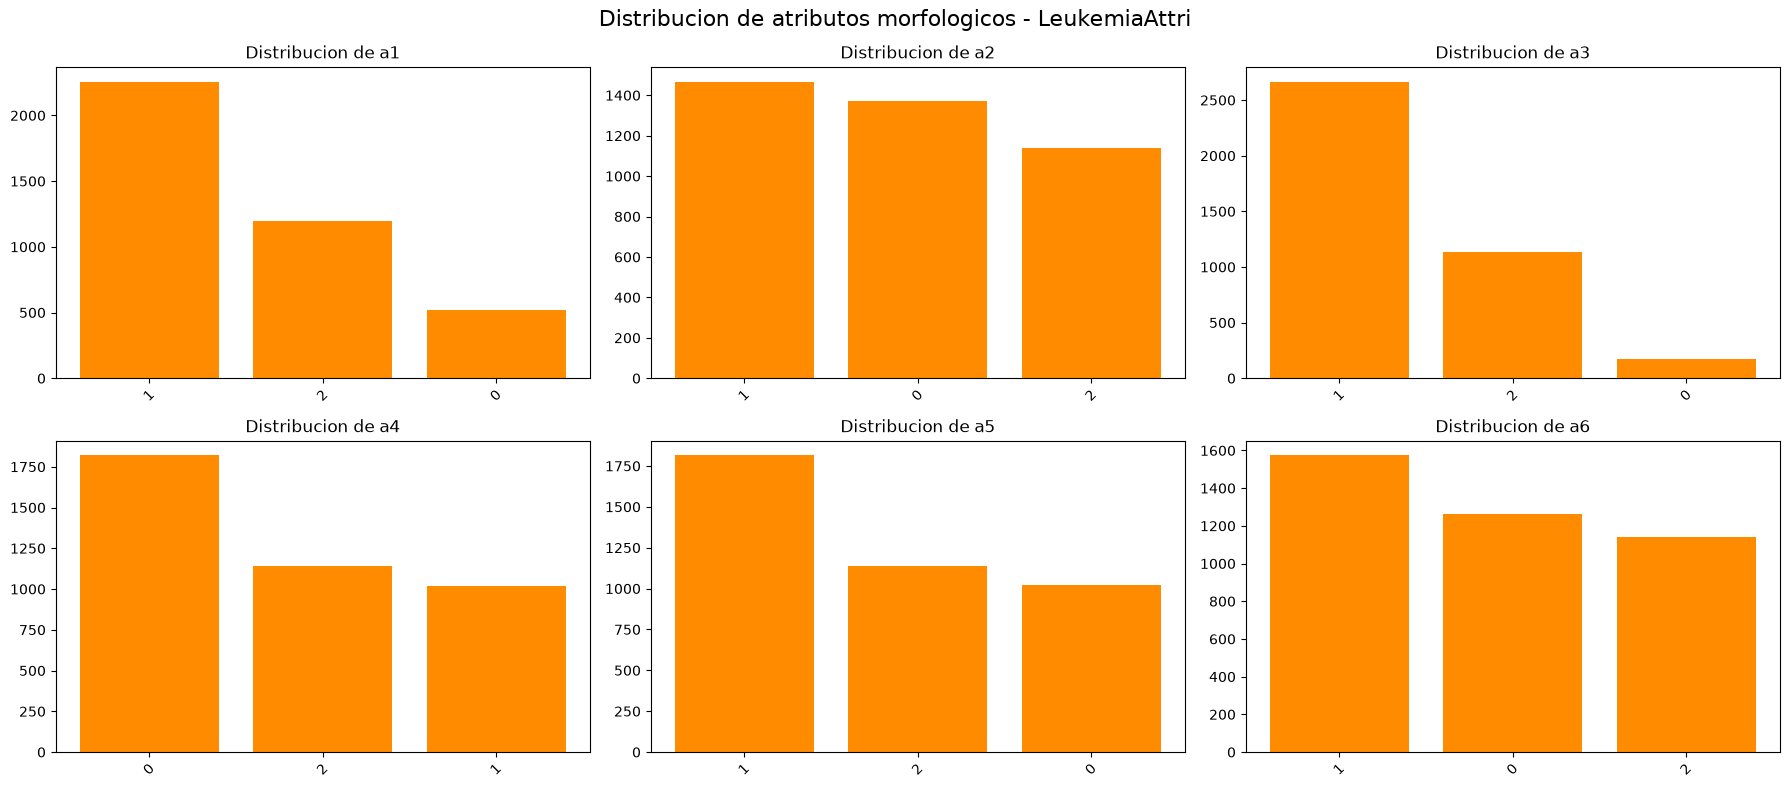

In [13]:
# Distribucion de clases YOLO (subtipos de celula/blasto) y de cada atributo a1..a6
if not detecciones_df.empty:
    print("========== DISTRIBUCION DE Clase_YOLO ==========")
    print(detecciones_df["Clase_YOLO"].value_counts().to_string())

    attr_cols = [c for c in detecciones_df.columns if c.startswith("a") and c[1:].isdigit()]

    if attr_cols:
        n_cols = 3
        n_rows = -(-len(attr_cols) // n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
        axes = axes.flat if len(attr_cols) > 1 else [axes]

        for ax, col in zip(axes, attr_cols):
            conteo = detecciones_df[col].value_counts()
            ax.bar(conteo.index.astype(str), conteo.values, color="darkorange")
            ax.set_title(f"Distribucion de {col}")
            ax.tick_params(axis="x", rotation=45)

        for ax in list(axes)[len(attr_cols):]:
            ax.axis("off")

        plt.suptitle("Distribucion de atributos morfologicos - LeukemiaAttri", fontsize=16)
        plt.tight_layout()
        plt.show()
else:
    print("No hay detecciones parseadas todavia (revisa que N_ATTR_LEUKEMIA y las rutas txt_label_path sean correctas).")


## 8. Muestras de imagenes (ambos datasets)

No se encontraron imagenes para: Muestras aleatorias - WBCAtt (sanas)


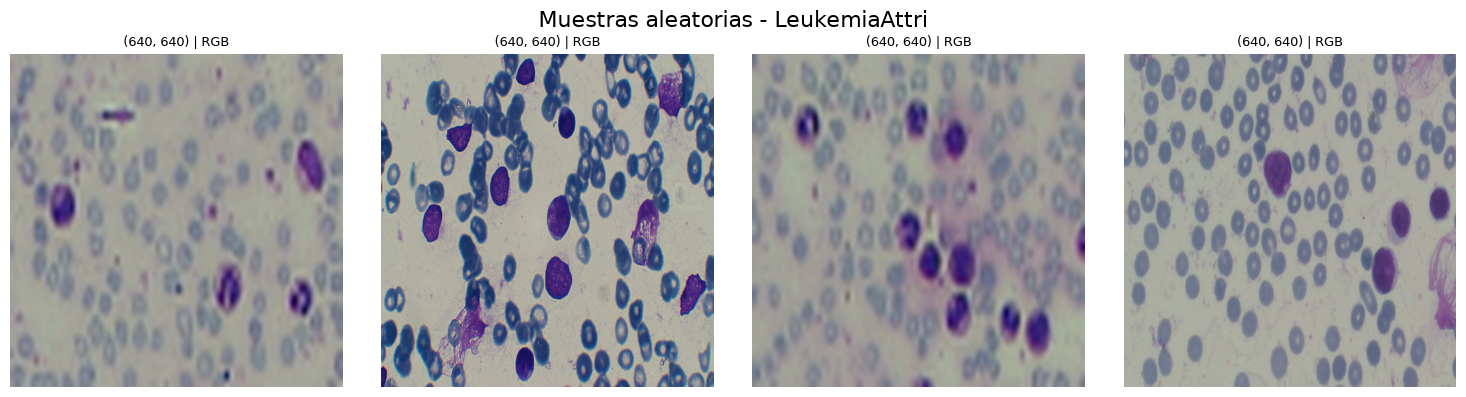

In [14]:
import random

def mostrar_muestras_aleatorias(rutas, titulo, num_muestras=4, seed=None):
    rutas = [r for r in rutas if r is not None and Path(r).exists()]
    if not rutas:
        print(f"No se encontraron imagenes para: {titulo}")
        return
    if seed is not None:
        random.seed(seed)
    muestras = random.sample(rutas, min(num_muestras, len(rutas)))

    fig, axes = plt.subplots(1, len(muestras), figsize=(15, 4))
    if len(muestras) == 1:
        axes = [axes]
    fig.suptitle(titulo, fontsize=16)

    for ax, img_path in zip(axes, muestras):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"{img.size} | {img.mode}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

mostrar_muestras_aleatorias(rutas_wbcatt, "Muestras aleatorias - WBCAtt (sanas)", num_muestras=4)
mostrar_muestras_aleatorias(rutas_leukemia, "Muestras aleatorias - LeukemiaAttri", num_muestras=4)


## 9. Deteccion de duplicados exactos (ambos datasets)

Igual que en la version anterior, pero ahora aplicado a las listas de rutas ya resueltas de cada dataset (`rutas_wbcatt`, `rutas_leukemia`), en vez de recorrer una estructura de carpetas fija.

In [15]:
import hashlib

def calcular_hashes(rutas, nombre_dataset):
    registros = []
    inicio = time.time()
    total = len(rutas)
    for i, ruta in enumerate(rutas, start=1):
        progreso(i, total, inicio, cada=2000, etiqueta=f"hash-{nombre_dataset}")
        ruta = Path(ruta)
        if not ruta.exists():
            continue
        md5 = hashlib.md5()
        with open(ruta, "rb") as f:
            for chunk in iter(lambda: f.read(8192), b""):
                md5.update(chunk)
        registros.append({"Dataset": nombre_dataset, "Archivo": ruta.name, "Ruta": str(ruta), "Hash": md5.hexdigest()})
    return pd.DataFrame(registros)

hash_wbcatt_df = calcular_hashes(rutas_wbcatt, "WBCAtt")
hash_leukemia_df = calcular_hashes(rutas_leukemia, "LeukemiaAttri")
hash_df = pd.concat([hash_wbcatt_df, hash_leukemia_df], ignore_index=True)

if not hash_df.empty:
    duplicate_hashes = hash_df[hash_df["Hash"].duplicated(keep=False)].sort_values("Hash")

    print("========== DUPLICADOS EXACTOS ==========")
    print(f"Total de imagenes analizadas: {len(hash_df)}")
    print(f"Hashes unicos: {hash_df['Hash'].nunique()}")
    print(f"Imagenes involucradas en duplicados: {len(duplicate_hashes)}")

    if len(duplicate_hashes) > 0:
        print("\n--- Imagenes duplicadas ---")
        print(duplicate_hashes.to_string(index=False))
    else:
        print("\nNo se encontraron duplicados exactos.")
else:
    print("No hay imagenes para hashear todavia.")


  [hash-LeukemiaAttri] 2000/25790 (7.8%) - 30s transcurridos
  [hash-LeukemiaAttri] 4000/25790 (15.5%) - 59s transcurridos
  [hash-LeukemiaAttri] 6000/25790 (23.3%) - 82s transcurridos
  [hash-LeukemiaAttri] 8000/25790 (31.0%) - 99s transcurridos
  [hash-LeukemiaAttri] 10000/25790 (38.8%) - 117s transcurridos
  [hash-LeukemiaAttri] 12000/25790 (46.5%) - 141s transcurridos
  [hash-LeukemiaAttri] 14000/25790 (54.3%) - 165s transcurridos
  [hash-LeukemiaAttri] 16000/25790 (62.0%) - 190s transcurridos
  [hash-LeukemiaAttri] 18000/25790 (69.8%) - 215s transcurridos
  [hash-LeukemiaAttri] 20000/25790 (77.5%) - 236s transcurridos
  [hash-LeukemiaAttri] 22000/25790 (85.3%) - 255s transcurridos
  [hash-LeukemiaAttri] 24000/25790 (93.1%) - 280s transcurridos
  [hash-LeukemiaAttri] 25790/25790 (100.0%) - 302s transcurridos
========== DUPLICADOS EXACTOS ==========
Total de imagenes analizadas: 25790
Hashes unicos: 25775
Imagenes involucradas en duplicados: 30

--- Imagenes duplicadas ---
      Dat

## 10. Dimensiones, canales y color/brillo/contraste (ambos datasets)

Se generaliza la funcion de analisis de color para recibir una lista de `(ruta, dataset, grupo)` en vez de recorrer carpetas fijas, y asi funciona igual sin importar como cambie la estructura de carpetas en el futuro.

**Nota de rendimiento:** con ~26,000 imagenes de LeukemiaAttri viviendo en OneDrive, procesar el color/brillo de TODAS puede tardar varios minutos (o mas, si hay archivos "solo en la nube" que se descargan al vuelo). Por eso el bloque de color/brillo usa una muestra de `MUESTRA_COLOR` imagenes por grupo en vez del dataset completo; sube ese numero o ponlo en `None` cuando quieras el analisis exhaustivo, ya con tiempo de sobra. Todos los bucles largos de esta version imprimen su avance cada cierto numero de imagenes para que sepas que siguen corriendo.

In [16]:
def construir_tabla_imagenes(rutas_con_metadata):
    """rutas_con_metadata: lista de dicts con al menos {'Ruta': ..., 'Dataset': ..., 'Grupo': ...}"""
    registros = []
    inicio = time.time()
    total = len(rutas_con_metadata)
    for i, item in enumerate(rutas_con_metadata, start=1):
        progreso(i, total, inicio, cada=2000, etiqueta="dimensiones")
        ruta = Path(item["Ruta"])
        if not ruta.exists():
            continue
        try:
            with Image.open(ruta) as image:
                width, height = image.size
                registros.append({
                    "Dataset": item.get("Dataset"),
                    "Grupo": item.get("Grupo"),
                    "Archivo": ruta.name,
                    "Ancho": width,
                    "Alto": height,
                    "Canales": len(image.getbands()),
                    "Formato": image.format,
                    "Aspect_Ratio": round(width / height, 3) if height else None,
                })
        except Exception as e:
            print(f"Error leyendo: {ruta} -> {e}")
    return pd.DataFrame(registros)


metadata_wbcatt = [
    {"Ruta": r, "Dataset": "WBCAtt", "Grupo": lbl}
    for r, lbl in zip(
        wbcatt_df.loc[wbcatt_df.get("Existe", pd.Series(dtype=bool)) == True, "Ruta_Absoluta"],
        wbcatt_df.loc[wbcatt_df.get("Existe", pd.Series(dtype=bool)) == True, LABEL_COL_WBCATT] if LABEL_COL_WBCATT else [],
    )
] if not wbcatt_df.empty else []

metadata_leukemia = [
    {"Ruta": r, "Dataset": "Leukemia", "Grupo": g}
    for r, g in zip(leukemia_df.get("Ruta_Absoluta", []), leukemia_df.get("Grupo", []))
] if not leukemia_df.empty else []

image_info_df = construir_tabla_imagenes(metadata_wbcatt + metadata_leukemia)
print(f"Total de imagenes en la tabla combinada: {len(image_info_df)}")
image_info_df.head()


  [dimensiones] 2000/25790 (7.8%) - 7s transcurridos
  [dimensiones] 4000/25790 (15.5%) - 14s transcurridos
  [dimensiones] 6000/25790 (23.3%) - 22s transcurridos
  [dimensiones] 8000/25790 (31.0%) - 29s transcurridos
  [dimensiones] 10000/25790 (38.8%) - 36s transcurridos
  [dimensiones] 12000/25790 (46.5%) - 42s transcurridos
  [dimensiones] 14000/25790 (54.3%) - 50s transcurridos
  [dimensiones] 16000/25790 (62.0%) - 57s transcurridos
  [dimensiones] 18000/25790 (69.8%) - 64s transcurridos
  [dimensiones] 20000/25790 (77.5%) - 70s transcurridos
  [dimensiones] 22000/25790 (85.3%) - 78s transcurridos
  [dimensiones] 24000/25790 (93.1%) - 85s transcurridos
  [dimensiones] 25790/25790 (100.0%) - 91s transcurridos
Total de imagenes en la tabla combinada: 25790


,Dataset,Grupo,Archivo,Ancho,Alto,Canales,Formato,Aspect_Ratio
0,Leukemia,H,15_10_1000_AML.png,640,640,3,PNG,1.0
1,Leukemia,H,15_11_1000_AML.png,640,640,3,PNG,1.0
2,Leukemia,H,15_12_1000_AML.png,640,640,3,PNG,1.0
3,Leukemia,H,15_14_1000_AML.png,640,640,3,PNG,1.0
4,Leukemia,H,15_15_1000_AML.png,640,640,3,PNG,1.0


In [17]:
# COLOR, BRILLO Y CONTRASTE
def analyze_image_color(file_path):
    with Image.open(file_path) as img:
        img_rgb = img.convert("RGB")
        image_array = np.asarray(img_rgb, dtype=np.float32)

        mean_r = image_array[:, :, 0].mean()
        mean_g = image_array[:, :, 1].mean()
        mean_b = image_array[:, :, 2].mean()

        brightness = (
            0.299 * image_array[:, :, 0]
            + 0.587 * image_array[:, :, 1]
            + 0.114 * image_array[:, :, 2]
        )

        return {
            "Promedio_R": mean_r,
            "Promedio_G": mean_g,
            "Promedio_B": mean_b,
            "Brillo_Promedio": brightness.mean(),
            "Contraste_STD": brightness.std(),
            "Brillo_Minimo": brightness.min(),
            "Brillo_Maximo": brightness.max(),
        }


def construir_tabla_color(rutas_con_metadata):
    registros = []
    inicio = time.time()
    total = len(rutas_con_metadata)
    for i, item in enumerate(rutas_con_metadata, start=1):
        progreso(i, total, inicio, cada=2000, etiqueta="color/brillo")
        ruta = Path(item["Ruta"])
        if not ruta.exists():
            continue
        try:
            stats = analyze_image_color(ruta)
            stats.update({"Dataset": item.get("Dataset"), "Grupo": item.get("Grupo"), "Archivo": ruta.name})
            registros.append(stats)
        except Exception as e:
            print(f"Error leyendo: {ruta} -> {e}")
    return pd.DataFrame(registros)


# MUESTRA_COLOR: numero maximo de imagenes POR (Dataset, Grupo) a analizar.
# Con ~26,000 imagenes de LeukemiaAttri sobre OneDrive, procesar TODO puede
# tardar bastante. Deja un numero (ej. 500) para una primera pasada rapida,
# y ponlo en None cuando quieras correr el analisis completo (puede tardar
# varios minutos, sobre todo si hay que descargar archivos "solo en la nube").
MUESTRA_COLOR = 500

if MUESTRA_COLOR is None:
    rutas_para_color = metadata_wbcatt + metadata_leukemia
else:
    random.seed(42)
    rutas_para_color = []
    todas = metadata_wbcatt + metadata_leukemia
    grupos_presentes = {(item.get("Dataset"), item.get("Grupo")) for item in todas}
    for dataset, grupo in grupos_presentes:
        subset = [it for it in todas if it.get("Dataset") == dataset and it.get("Grupo") == grupo]
        rutas_para_color.extend(random.sample(subset, min(MUESTRA_COLOR, len(subset))))

print(f"Analizando color/brillo sobre {len(rutas_para_color)} imagenes (MUESTRA_COLOR={MUESTRA_COLOR}).")
color_df = construir_tabla_color(rutas_para_color)
print(f"Total de imagenes analizadas para color/brillo: {len(color_df)}")
color_df.head()


Analizando color/brillo sobre 1000 imagenes (MUESTRA_COLOR=500).
  [color/brillo] 1000/1000 (100.0%) - 59s transcurridos
Total de imagenes analizadas para color/brillo: 1000


,Promedio_R,Promedio_G,Promedio_B,Brillo_Promedio,Contraste_STD,Brillo_Minimo,Brillo_Maximo,Dataset,Grupo,Archivo
0,142.390900,142.348709,145.068100,142.671341,26.314686,29.554001,186.733002,Leukemia,H,42_13_1000_AML.png
1,202.073013,181.488693,194.250275,189.098221,29.914310,35.154999,247.140991,Leukemia,H,48_39_6_100_AML.png
2,172.486420,154.825241,200.123352,165.269928,44.257473,9.832000,250.353012,Leukemia,H,44_22_1000_AML.png
3,139.119003,141.116714,141.462494,140.558823,23.344545,33.846001,187.770004,Leukemia,H,2_3_4_400_ALL.png
4,145.422073,144.275314,150.514313,145.329437,29.898298,38.396000,189.031006,Leukemia,H,48_7_1000_AML.png


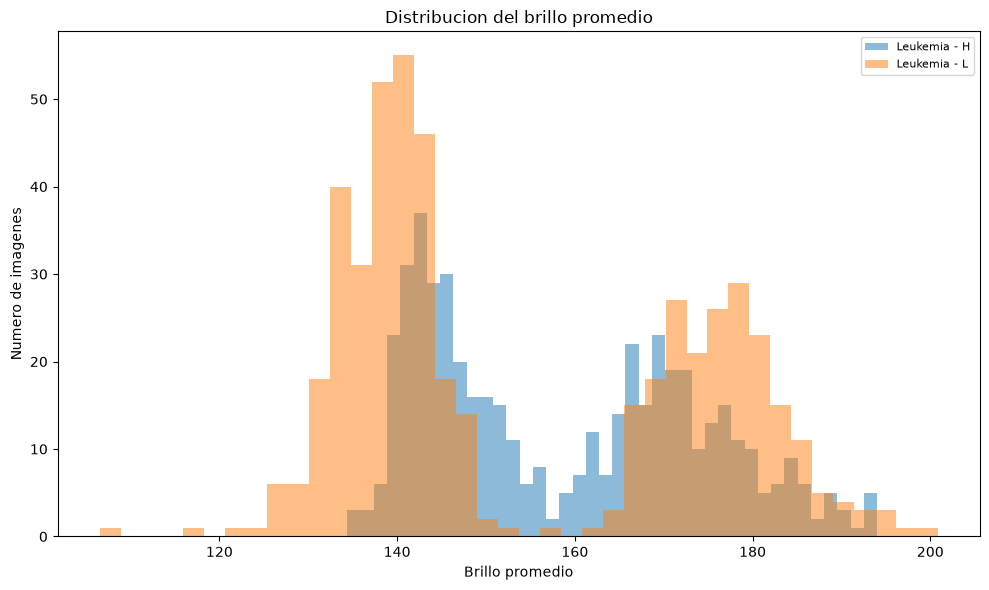

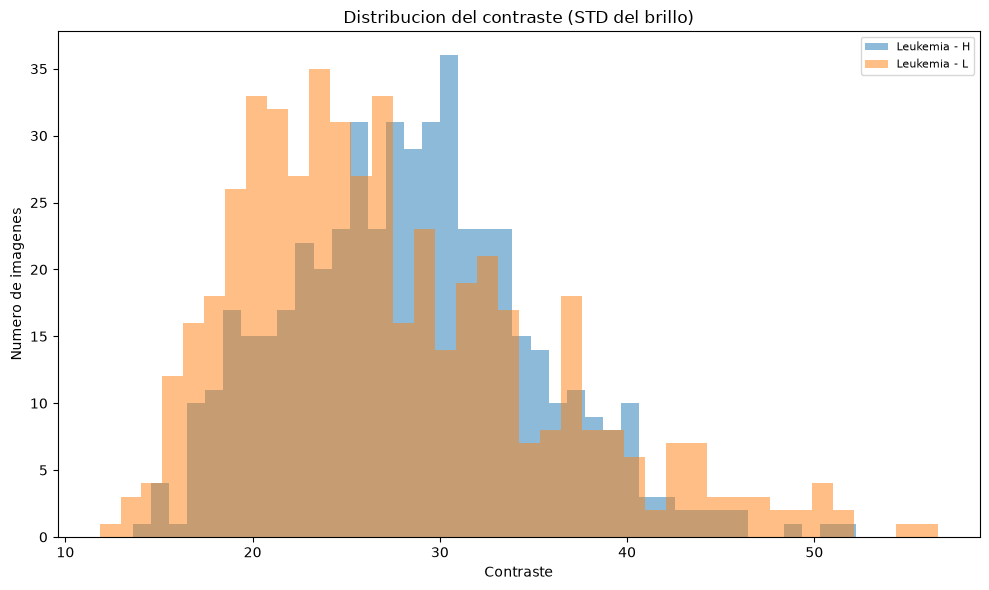

In [18]:
# DISTRIBUCION DE BRILLO Y CONTRASTE POR DATASET/GRUPO
if not color_df.empty:
    color_df["Grupo_Display"] = color_df["Dataset"] + " - " + color_df["Grupo"].astype(str)
    grupos_unicos = color_df["Grupo_Display"].unique()

    plt.figure(figsize=(10, 6))
    for g in grupos_unicos:
        plt.hist(color_df.loc[color_df["Grupo_Display"] == g, "Brillo_Promedio"], bins=40, alpha=0.5, label=g)
    plt.title("Distribucion del brillo promedio")
    plt.xlabel("Brillo promedio")
    plt.ylabel("Numero de imagenes")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    for g in grupos_unicos:
        plt.hist(color_df.loc[color_df["Grupo_Display"] == g, "Contraste_STD"], bins=40, alpha=0.5, label=g)
    plt.title("Distribucion del contraste (STD del brillo)")
    plt.xlabel("Contraste")
    plt.ylabel("Numero de imagenes")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("color_df esta vacio, no hay nada que graficar todavia.")


## 11. Analisis de textura: entropia y GLCM (ambos datasets)

Se toma una muestra por grupo para no procesar el dataset completo (igual que en la version anterior), pero ahora usando `metadata_wbcatt` / `metadata_leukemia` como fuente de rutas.

In [19]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [20]:
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

N_MUESTRA = 300
RANDOM_STATE = 42

def calcular_textura(rutas_con_metadata, n_muestra=N_MUESTRA, seed=RANDOM_STATE):
    random.seed(seed)
    muestra = random.sample(rutas_con_metadata, min(n_muestra, len(rutas_con_metadata)))

    registros = []
    inicio = time.time()
    total = len(muestra)
    for i, item in enumerate(muestra, start=1):
        progreso(i, total, inicio, cada=500, etiqueta="textura")
        ruta = Path(item["Ruta"])
        if not ruta.exists():
            continue
        try:
            with Image.open(ruta) as img:
                gris = np.array(img.convert("L"))

            entropia = shannon_entropy(gris)
            glcm = graycomatrix(gris, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

            registros.append({
                "Dataset": item.get("Dataset"),
                "Grupo": item.get("Grupo"),
                "Archivo": ruta.name,
                "Entropia": entropia,
                "GLCM_Contraste": graycoprops(glcm, "contrast")[0, 0],
                "GLCM_Homogeneidad": graycoprops(glcm, "homogeneity")[0, 0],
                "GLCM_Energia": graycoprops(glcm, "energy")[0, 0],
                "GLCM_Correlacion": graycoprops(glcm, "correlation")[0, 0],
            })
        except Exception as e:
            print(f"Error procesando textura de {ruta}: {e}")

    return pd.DataFrame(registros)

texture_df = calcular_textura(metadata_wbcatt + metadata_leukemia)
print(f"Total de imagenes analizadas para textura: {len(texture_df)}")
if not texture_df.empty:
    print(texture_df.groupby(["Dataset", "Grupo"]).size())


  [textura] 300/300 (100.0%) - 21s transcurridos
Total de imagenes analizadas para textura: 300
Dataset   Grupo
Leukemia  H        172
          L        128
dtype: int64


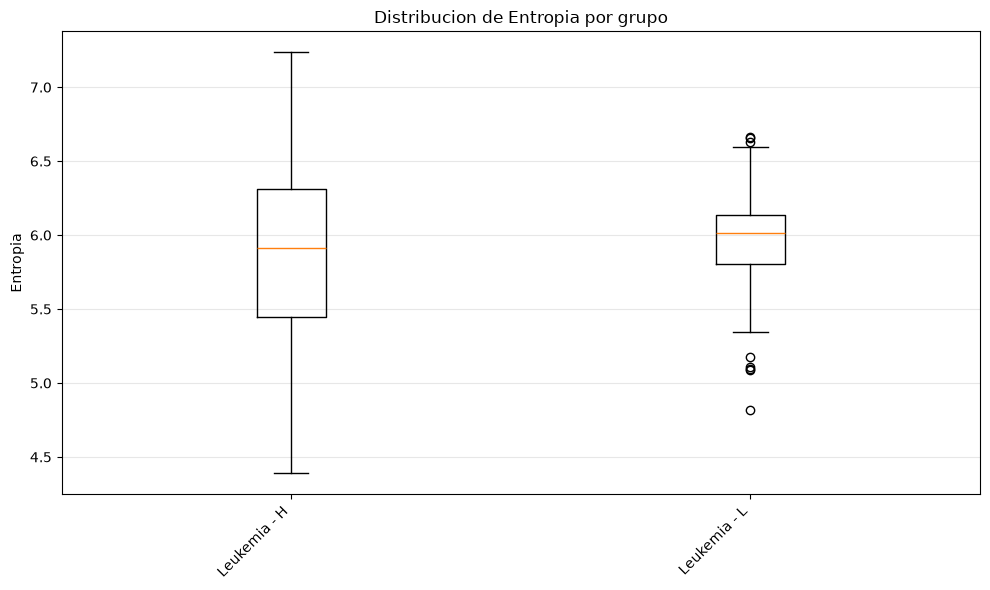

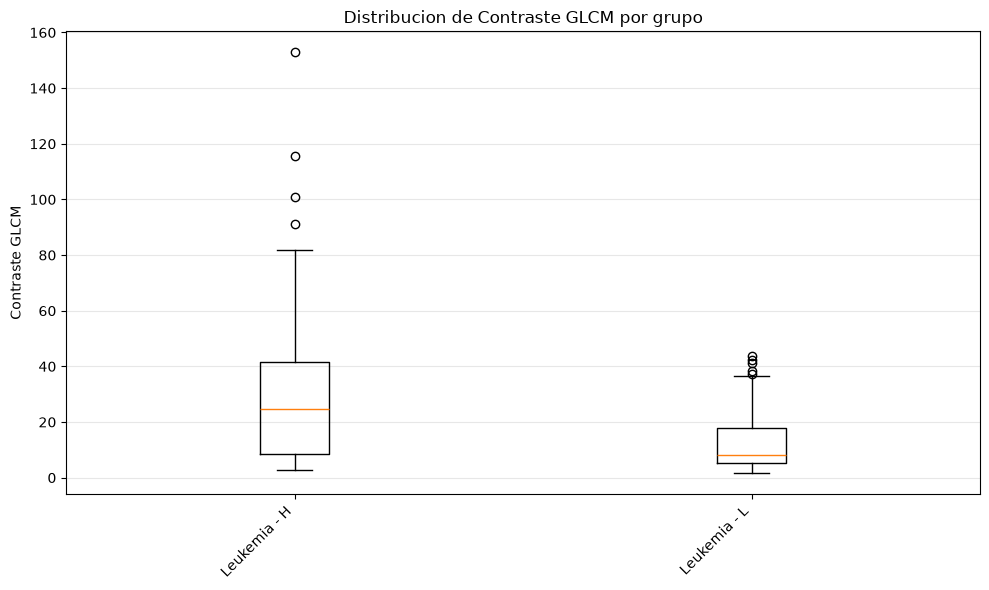

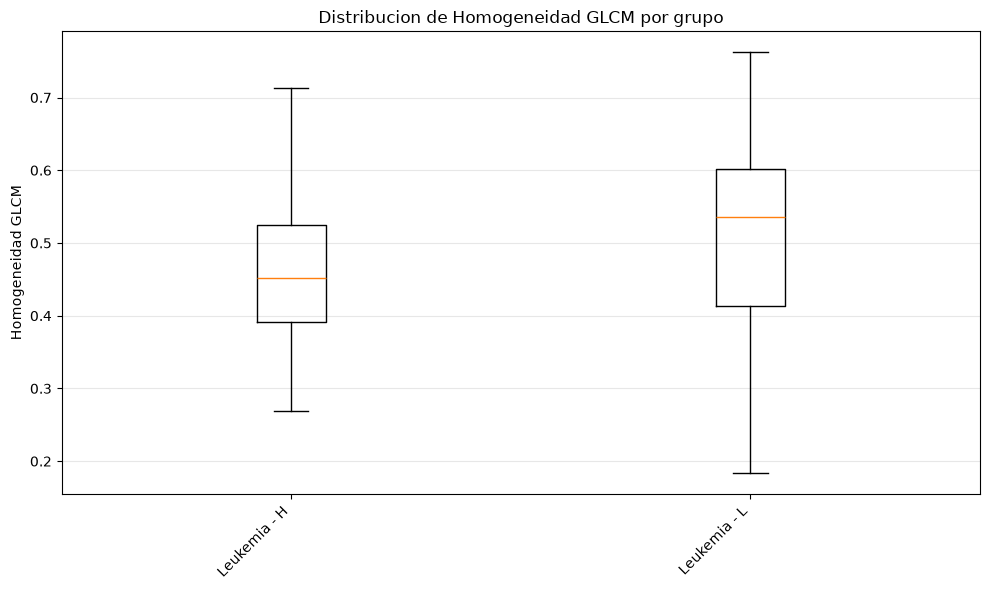

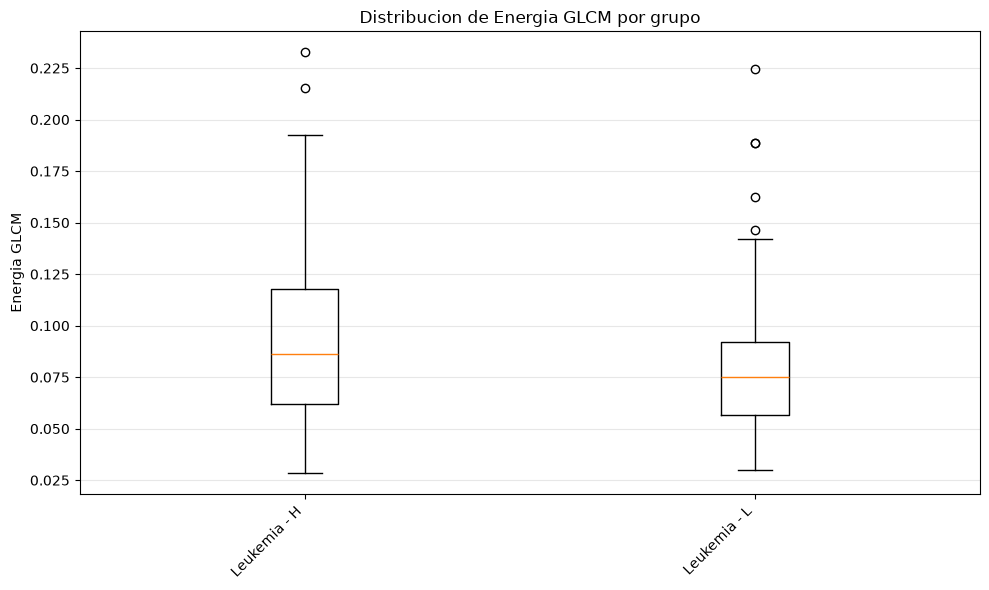

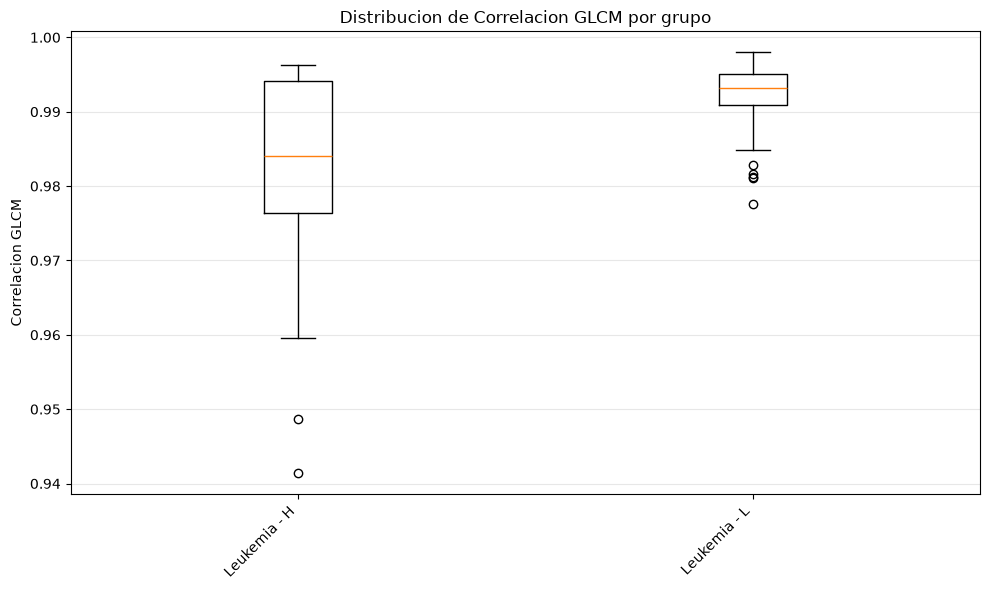

In [21]:
# BOXPLOTS DE TEXTURA POR GRUPO
if not texture_df.empty:
    texture_df["Grupo_Display"] = texture_df["Dataset"] + " - " + texture_df["Grupo"].astype(str)
    grupos_orden = sorted(texture_df["Grupo_Display"].unique())

    metricas_textura = [
        ("Entropia", "Entropia"),
        ("GLCM_Contraste", "Contraste GLCM"),
        ("GLCM_Homogeneidad", "Homogeneidad GLCM"),
        ("GLCM_Energia", "Energia GLCM"),
        ("GLCM_Correlacion", "Correlacion GLCM"),
    ]

    for columna, titulo in metricas_textura:
        datos = [texture_df.loc[texture_df["Grupo_Display"] == g, columna].dropna().values for g in grupos_orden]

        plt.figure(figsize=(10, 6))
        plt.boxplot(datos, tick_labels=grupos_orden, showfliers=True)
        plt.title(f"Distribucion de {titulo} por grupo")
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(titulo)
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("texture_df esta vacio, no hay nada que graficar todavia.")


## 12. Pruebas estadisticas (Kruskal-Wallis + comparaciones por pares)

Igual que en la version anterior, pero ahora comparando entre todos los grupos presentes en `texture_df["Grupo_Display"]` en vez de asumir exactamente 3 grupos fijos (Healthy / Leukemia H / Leukemia L).

In [22]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [23]:
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

if not texture_df.empty:
    metricas_textura_cols = ["Entropia", "GLCM_Contraste", "GLCM_Homogeneidad", "GLCM_Energia", "GLCM_Correlacion"]
    grupos_orden = sorted(texture_df["Grupo_Display"].unique())

    print("=" * 78)
    print("     PRUEBA DE KRUSKAL-WALLIS (comparacion global entre todos los grupos)")
    print("=" * 78)

    resultados_kruskal = []
    for metrica in metricas_textura_cols:
        muestras = [texture_df.loc[texture_df["Grupo_Display"] == g, metrica].dropna().values for g in grupos_orden]
        muestras = [m for m in muestras if len(m) > 0]
        if len(muestras) < 2:
            continue
        estadistico, p_valor = kruskal(*muestras)
        resultados_kruskal.append({"Metrica": metrica, "H_Kruskal": estadistico, "p_valor": p_valor, "Significativo_p<0.05": "Si" if p_valor < 0.05 else "No"})

    kruskal_df = pd.DataFrame(resultados_kruskal)
    print(kruskal_df.to_string(index=False))

    print("\n" + "=" * 78)
    print("     COMPARACIONES POR PARES (Mann-Whitney U + correccion de Holm)")
    print("=" * 78)

    resultados_pares = []
    for metrica in metricas_textura_cols:
        for g1, g2 in combinations(grupos_orden, 2):
            d1 = texture_df.loc[texture_df["Grupo_Display"] == g1, metrica].dropna().values
            d2 = texture_df.loc[texture_df["Grupo_Display"] == g2, metrica].dropna().values
            if len(d1) == 0 or len(d2) == 0:
                continue
            U, p = mannwhitneyu(d1, d2, alternative="two-sided")
            n1, n2 = len(d1), len(d2)
            media_U = n1 * n2 / 2
            desviacion_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            Z = (U - media_U) / desviacion_U if desviacion_U > 0 else np.nan
            r = abs(Z) / np.sqrt(n1 + n2) if not np.isnan(Z) else np.nan
            resultados_pares.append({"Metrica": metrica, "Comparacion": f"{g1} vs {g2}", "U": U, "p_valor": p, "Tamano_efecto_r": r})

    pares_df = pd.DataFrame(resultados_pares)
    if not pares_df.empty:
        _, p_ajustados, _, _ = multipletests(pares_df["p_valor"], method="holm")
        pares_df["p_valor_holm"] = p_ajustados
        pares_df["Significativo_p<0.05"] = pares_df["p_valor_holm"] < 0.05
        print(pares_df.round(4).to_string(index=False))
else:
    print("texture_df esta vacio, no hay pruebas estadisticas que correr todavia.")


     PRUEBA DE KRUSKAL-WALLIS (comparacion global entre todos los grupos)
          Metrica  H_Kruskal      p_valor Significativo_p<0.05
         Entropia   1.828978 1.762483e-01                   No
   GLCM_Contraste  48.738961 2.923997e-12                   Si
GLCM_Homogeneidad  12.392297 4.311086e-04                   Si
     GLCM_Energia   7.864512 5.041444e-03                   Si
 GLCM_Correlacion  47.414062 5.746893e-12                   Si

     COMPARACIONES POR PARES (Mann-Whitney U + correccion de Holm)
          Metrica                  Comparacion       U  p_valor  Tamano_efecto_r  p_valor_holm  Significativo_p<0.05
         Entropia Leukemia - H vs Leukemia - L 10003.0   0.1765           0.0781        0.1765                 False
   GLCM_Contraste Leukemia - H vs Leukemia - L 16196.0   0.0000           0.4031        0.0000                  True
GLCM_Homogeneidad Leukemia - H vs Leukemia - L  8392.0   0.0004           0.2032        0.0013                  True
     GLCM_En

# Fase 2: Ingeniería de Datos y Descripciones

En esta fase se realiza la integración, validación y depuración de las descripciones textuales asociadas a las imágenes de los conjuntos WBCATt y LeukemiaAttri.

El objetivo es preparar un conjunto multimodal consistente para el entrenamiento posterior del modelo visión-lenguaje. Para ello, se analizará la correspondencia entre imágenes, atributos morfológicos y descripciones textuales, identificando registros duplicados, imágenes sin descripción y posibles inconsistencias en las rutas.

Posteriormente, se generarán variaciones lingüísticas de las descripciones originales conservando la información morfológica y diagnóstica disponible, con el propósito de aumentar la diversidad textual sin introducir características clínicas no presentes en los datos originales.

In [24]:
from pathlib import Path
import pandas as pd

# El notebook se encuentra dentro de /notebooks,
# por lo que la raíz del proyecto corresponde al directorio padre.
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
CAPTIONS_PATH = DATA_DIR / "captions" / "captions.csv"

print("Raíz del proyecto:", PROJECT_ROOT)
print("Directorio de datos:", DATA_DIR)
print("Captions encontrados:", CAPTIONS_PATH.exists())

Raíz del proyecto: c:\Users\karin\Documents\GitHub\TT
Directorio de datos: c:\Users\karin\Documents\GitHub\TT\data
Captions encontrados: True


In [25]:
# Cargar captions generados
df_captions = pd.read_csv(CAPTIONS_PATH)

print("Dimensiones del dataset:", df_captions.shape)
print("\nColumnas:")
print(df_captions.columns.tolist())

print("\nRegistros por dataset:")
print(df_captions["dataset"].value_counts())

print("\nPrimeros registros:")
display(df_captions.head(3))

C:\Users\karin\AppData\Local\Temp\ipykernel_3248\1816754874.py:2: DtypeWarning: Columns (0: cell_type) have mixed types. Specify dtype option on import or set low_memory=False.
  df_captions = pd.read_csv(CAPTIONS_PATH)


Dimensiones del dataset: (68652, 11)

Columnas:
['filename', 'image_path', 'dataset', 'split', 'cell_type', 'diagnosis', 'magnification', 'diagnosis_idx', 'cell_type_idx', 'caption', 'caption_with_image_token']

Registros por dataset:
dataset
LeukemiaAttri    51560
WBCATt           17092
Name: count, dtype: int64

Primeros registros:


,filename,image_path,dataset,split,cell_type,diagnosis,magnification,diagnosis_idx,cell_type_idx,caption,caption_with_image_token
0,BA_100102.jpg,data\PBC_dataset_normal_DIB\PBC_dataset_normal...,WBCATt,NaN,basophil,NaN,NaN,-1,0,Peripheral blood smear showing a healthy basop...,<image> Peripheral blood smear showing a healt...
1,BA_101381.jpg,data\PBC_dataset_normal_DIB\PBC_dataset_normal...,WBCATt,NaN,basophil,NaN,NaN,-1,0,Microscopic view of a healthy basophil showing...,<image> Microscopic view of a healthy basophil...
2,BA_101611.jpg,data\PBC_dataset_normal_DIB\PBC_dataset_normal...,WBCATt,NaN,basophil,NaN,NaN,-1,0,Microscopic view of a healthy basophil showing...,<image> Microscopic view of a healthy basophil...


In [26]:
# ============================================================
# Validación de duplicados en LeukemiaAttri
# ============================================================

df_leukemia = df_captions[
    df_captions["dataset"] == "LeukemiaAttri"
].copy()

# Normalizar las rutas:
# 1. Usar "/" como separador.
# 2. Convertir a minúsculas para evitar diferencias Images/images.
df_leukemia["image_path_normalized"] = (
    df_leukemia["image_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
    .str.lower()
)

print("Filas originales de LeukemiaAttri:",
      len(df_leukemia))

print("Rutas originales únicas:",
      df_leukemia["image_path"].nunique())

print("Rutas únicas después de normalizar:",
      df_leukemia["image_path_normalized"].nunique())

print("Registros duplicados después de normalizar:",
      df_leukemia.duplicated(
          subset=["image_path_normalized"],
          keep="first"
      ).sum())

Filas originales de LeukemiaAttri: 51560
Rutas originales únicas: 51560
Rutas únicas después de normalizar: 25780
Registros duplicados después de normalizar: 25780


In [27]:
# ============================================================
# Verificar consistencia entre los registros duplicados
# ============================================================

columnas_validar = [
    "filename",
    "diagnosis",
    "magnification",
    "caption"
]

inconsistencias = []

for ruta, grupo in df_leukemia.groupby("image_path_normalized"):
    if len(grupo) > 1:
        for columna in columnas_validar:
            if grupo[columna].nunique(dropna=False) > 1:
                inconsistencias.append({
                    "image_path_normalized": ruta,
                    "columna": columna
                })

df_inconsistencias = pd.DataFrame(inconsistencias)

print("Grupos con alguna inconsistencia:",
      df_inconsistencias["image_path_normalized"].nunique()
      if not df_inconsistencias.empty else 0)

print("Inconsistencias totales:",
      len(df_inconsistencias))

if not df_inconsistencias.empty:
    display(df_inconsistencias.head(10))

Grupos con alguna inconsistencia: 20572
Inconsistencias totales: 20572


,image_path_normalized,columna
0,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
1,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
2,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
3,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
4,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
5,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
6,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
7,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
8,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption
9,data/archive/leukemiaattri_dataset/h_100x_c1/i...,caption


In [28]:
# ============================================================
# Número de captions distintas por imagen lógica
# ============================================================

captions_por_imagen = (
    df_leukemia
    .groupby("image_path_normalized")["caption"]
    .nunique()
)

distribucion_captions = (
    captions_por_imagen
    .value_counts()
    .sort_index()
)

print("Número de captions únicas por imagen:")
print(distribucion_captions)

print("\nTotal de imágenes lógicas:",
      len(captions_por_imagen))

print("Imágenes con una sola caption:",
      (captions_por_imagen == 1).sum())

print("Imágenes con dos captions distintas:",
      (captions_por_imagen == 2).sum())

Número de captions únicas por imagen:
caption
1     5208
2    20572
Name: count, dtype: int64

Total de imágenes lógicas: 25780
Imágenes con una sola caption: 5208
Imágenes con dos captions distintas: 20572


In [29]:
# ============================================================
# Ejemplo de una imagen con dos captions diferentes
# ============================================================

ruta_ejemplo = captions_por_imagen[
    captions_por_imagen == 2
].index[0]

ejemplo = df_leukemia[
    df_leukemia["image_path_normalized"] == ruta_ejemplo
][
    [
        "filename",
        "image_path",
        "diagnosis",
        "magnification",
        "caption"
    ]
]

pd.set_option("display.max_colwidth", None)

display(ejemplo)

,filename,image_path,diagnosis,magnification,caption
18768,15_10_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_10_1000_AML.png,AML,100x,"Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm."
21136,15_10_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\images\test\15_10_1000_AML.png,AML,100x,"Microscopic image at 100x magnification showing an AML (acute myeloid leukemia) blast with medium cell size, open chromatin, a round nucleus, and moderate cytoplasm."


In [30]:
# ============================================================
# Analizar imágenes con una sola caption única
# ============================================================

rutas_una_caption = captions_por_imagen[
    captions_por_imagen == 1
].index

df_una_caption = df_leukemia[
    df_leukemia["image_path_normalized"].isin(rutas_una_caption)
]

filas_por_imagen = (
    df_una_caption
    .groupby("image_path_normalized")
    .size()
    .value_counts()
    .sort_index()
)

print("Distribución del número de filas por imagen:")
print(filas_por_imagen)

print("\nImágenes con una sola caption única:",
      len(rutas_una_caption))

print("Filas correspondientes:",
      len(df_una_caption))

Distribución del número de filas por imagen:
2    5208
Name: count, dtype: int64

Imágenes con una sola caption única: 5208
Filas correspondientes: 10416


In [31]:
# ============================================================
# Construcción del DataFrame limpio de LeukemiaAttri
# ============================================================

df_leukemia_clean = (
    df_leukemia
    .drop_duplicates(
        subset=["image_path_normalized", "caption"],
        keep="first"
    )
    .copy()
)

print("Filas originales:", len(df_leukemia))
print("Filas después de eliminar repeticiones exactas:",
      len(df_leukemia_clean))

print("Filas redundantes eliminadas:",
      len(df_leukemia) - len(df_leukemia_clean))

print("Imágenes lógicas conservadas:",
      df_leukemia_clean["image_path_normalized"].nunique())

print("\nCaptions distintas por imagen después de la limpieza:")
print(
    df_leukemia_clean
    .groupby("image_path_normalized")["caption"]
    .nunique()
    .value_counts()
    .sort_index()
)

Filas originales: 51560
Filas después de eliminar repeticiones exactas: 46352
Filas redundantes eliminadas: 5208
Imágenes lógicas conservadas: 25780

Captions distintas por imagen después de la limpieza:
caption
1     5208
2    20572
Name: count, dtype: int64


In [32]:
# ============================================================
# Comparación entre imágenes físicas y captions de LeukemiaAttri
# ============================================================

LEUKEMIA_DIR = DATA_DIR / "archive" / "LeukemiaAttri_Dataset"

# Extensiones de imagen consideradas
extensiones = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# Obtener todas las imágenes físicas
imagenes_fisicas = [
    ruta for ruta in LEUKEMIA_DIR.rglob("*")
    if ruta.is_file() and ruta.suffix.lower() in extensiones
]

print("Imágenes físicas encontradas:", len(imagenes_fisicas))

# Usamos rutas relativas al directorio LeukemiaAttri_Dataset
rutas_fisicas = {
    str(ruta.relative_to(LEUKEMIA_DIR))
    .replace("\\", "/")
    .lower()
    for ruta in imagenes_fisicas
}

# Convertir las rutas de captions al mismo formato relativo
prefijo = "data/archive/leukemiaattri_dataset/"

rutas_captions = {
    ruta.replace(prefijo, "", 1)
    for ruta in df_leukemia_clean["image_path_normalized"]
}

print("Rutas físicas únicas:", len(rutas_fisicas))
print("Rutas únicas en captions:", len(rutas_captions))

# Comparar ambos conjuntos
sin_caption = sorted(rutas_fisicas - rutas_captions)
sin_imagen_fisica = sorted(rutas_captions - rutas_fisicas)

print("\nImágenes físicas sin caption:", len(sin_caption))
print("Captions sin imagen física:", len(sin_imagen_fisica))

Imágenes físicas encontradas: 25790
Rutas físicas únicas: 25790
Rutas únicas en captions: 25780

Imágenes físicas sin caption: 10
Captions sin imagen física: 0


In [33]:
# ============================================================
# Identificación de las 10 imágenes sin caption
# ============================================================

print("Imágenes físicas sin caption:")
print("=" * 80)

for i, ruta in enumerate(sin_caption, start=1):
    print(f"{i:02d}. {ruta}")

Imágenes físicas sin caption:
01. l_40x_c1/images/train/12_9_400_aml(1).png
02. l_40x_c1/images/train/17_27_400_aml(1).png
03. l_40x_c1/images/train/17_28_400_aml(1).png
04. l_40x_c1/images/train/24_38_400_apml(1).png
05. l_40x_c1/images/train/27_58_400_cml(1).png
06. l_40x_c1/images/train/36_36_400_aml(1).png
07. l_40x_c1/images/train/3_27_400_all(1).png
08. l_40x_c1/images/train/3_36_400_all(1).png
09. l_40x_c1/images/train/44_17_400_aml(1).png
10. l_40x_c1/images/train/44_6_400_aml(1).png


In [34]:
# ============================================================
# Buscar etiquetas JSON para las 10 imágenes sin caption
# ============================================================

resultados_json = []

for ruta_relativa in sin_caption:
    ruta_imagen = LEUKEMIA_DIR / Path(ruta_relativa)

    nombre_base = ruta_imagen.stem

    # Buscar JSON con el mismo nombre dentro del dataset
    coincidencias = list(
        LEUKEMIA_DIR.rglob(f"{nombre_base}.json")
    )

    resultados_json.append({
        "imagen": ruta_relativa,
        "nombre_base": nombre_base,
        "json_encontrados": len(coincidencias),
        "rutas_json": [str(r) for r in coincidencias]
    })

df_json_faltantes = pd.DataFrame(resultados_json)

display(
    df_json_faltantes[
        ["imagen", "nombre_base", "json_encontrados"]
    ]
)

print(
    "\nImágenes con al menos un JSON:",
    (df_json_faltantes["json_encontrados"] > 0).sum()
)

print(
    "Imágenes sin JSON:",
    (df_json_faltantes["json_encontrados"] == 0).sum()
)

,imagen,nombre_base,json_encontrados
0,l_40x_c1/images/train/12_9_400_aml(1).png,12_9_400_aml(1),0
1,l_40x_c1/images/train/17_27_400_aml(1).png,17_27_400_aml(1),0
2,l_40x_c1/images/train/17_28_400_aml(1).png,17_28_400_aml(1),0
3,l_40x_c1/images/train/24_38_400_apml(1).png,24_38_400_apml(1),0
4,l_40x_c1/images/train/27_58_400_cml(1).png,27_58_400_cml(1),0
5,l_40x_c1/images/train/36_36_400_aml(1).png,36_36_400_aml(1),0
6,l_40x_c1/images/train/3_27_400_all(1).png,3_27_400_all(1),0
7,l_40x_c1/images/train/3_36_400_all(1).png,3_36_400_all(1),0
8,l_40x_c1/images/train/44_17_400_aml(1).png,44_17_400_aml(1),0
9,l_40x_c1/images/train/44_6_400_aml(1).png,44_6_400_aml(1),0



Imágenes con al menos un JSON: 0
Imágenes sin JSON: 10


In [35]:
# ============================================================
# Buscar etiquetas JSON eliminando el sufijo "(1)"
# ============================================================

resultados_json_original = []

for ruta_relativa in sin_caption:
    ruta_imagen = LEUKEMIA_DIR / Path(ruta_relativa)

    nombre_actual = ruta_imagen.stem

    # Eliminar únicamente el sufijo "(1)"
    nombre_sin_copia = (
        nombre_actual[:-3]
        if nombre_actual.endswith("(1)")
        else nombre_actual
    )

    # Buscar JSON correspondiente al nombre original
    coincidencias = list(
        LEUKEMIA_DIR.rglob(f"{nombre_sin_copia}.json")
    )

    resultados_json_original.append({
        "imagen_faltante": ruta_relativa,
        "nombre_actual": nombre_actual,
        "nombre_sin_copia": nombre_sin_copia,
        "json_encontrados": len(coincidencias),
        "rutas_json": [str(r) for r in coincidencias]
    })

df_json_original = pd.DataFrame(resultados_json_original)

display(
    df_json_original[
        [
            "nombre_actual",
            "nombre_sin_copia",
            "json_encontrados"
        ]
    ]
)

print(
    "\nImágenes con JSON usando el nombre sin '(1)':",
    (df_json_original["json_encontrados"] > 0).sum()
)

print(
    "Imágenes todavía sin JSON:",
    (df_json_original["json_encontrados"] == 0).sum()
)

,nombre_actual,nombre_sin_copia,json_encontrados
0,12_9_400_aml(1),12_9_400_aml,0
1,17_27_400_aml(1),17_27_400_aml,0
2,17_28_400_aml(1),17_28_400_aml,0
3,24_38_400_apml(1),24_38_400_apml,0
4,27_58_400_cml(1),27_58_400_cml,0
5,36_36_400_aml(1),36_36_400_aml,0
6,3_27_400_all(1),3_27_400_all,0
7,3_36_400_all(1),3_36_400_all,0
8,44_17_400_aml(1),44_17_400_aml,0
9,44_6_400_aml(1),44_6_400_aml,0



Imágenes con JSON usando el nombre sin '(1)': 0
Imágenes todavía sin JSON: 10


In [36]:
# ============================================================
# Inspeccionar estructura y archivos de etiquetas de L_40X_C1
# ============================================================

L40_C1_DIR = LEUKEMIA_DIR / "L_40X_C1"

print("Existe L_40X_C1:", L40_C1_DIR.exists())
print("\nContenido principal:")
print("=" * 80)

for elemento in sorted(L40_C1_DIR.iterdir()):
    tipo = "DIR " if elemento.is_dir() else "FILE"
    print(f"{tipo}: {elemento.name}")

# Buscar tipos de archivos presentes dentro de L_40X_C1
archivos_l40 = [
    ruta for ruta in L40_C1_DIR.rglob("*")
    if ruta.is_file()
]

extensiones_l40 = pd.Series(
    [ruta.suffix.lower() for ruta in archivos_l40]
).value_counts()

print("\nTipos de archivos encontrados:")
print(extensiones_l40)

Existe L_40X_C1: True

Contenido principal:
FILE: attridet.zip
DIR : images
DIR : json_labels
FILE: WBC_detection.zip

Tipos de archivos encontrados:
.png     2365
.zip        2
.json       2
Name: count, dtype: int64


In [37]:
# ============================================================
# Inspeccionar los archivos JSON de L_40X_C1
# ============================================================

json_l40 = sorted(L40_C1_DIR.rglob("*.json"))

print("JSON encontrados:", len(json_l40))
print("=" * 80)

for ruta in json_l40:
    print(ruta.relative_to(L40_C1_DIR))

JSON encontrados: 2
json_labels\test.json
json_labels\train.json


In [38]:
# ============================================================
# Inspeccionar estructura de train.json de L_40X_C1
# ============================================================

import json

TRAIN_JSON = L40_C1_DIR / "json_labels" / "train.json"

with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_json = json.load(f)

print("Tipo de estructura:", type(train_json).__name__)

if isinstance(train_json, dict):
    print("\nClaves principales:")
    print(list(train_json.keys()))

    print("\nTipo y tamaño de cada sección:")
    for clave, valor in train_json.items():
        try:
            print(
                f"{clave}: {type(valor).__name__} "
                f"({len(valor)} elementos)"
            )
        except TypeError:
            print(
                f"{clave}: {type(valor).__name__}"
            )

elif isinstance(train_json, list):
    print("Número de elementos:", len(train_json))

    if train_json:
        print("\nClaves del primer elemento:")
        if isinstance(train_json[0], dict):
            print(list(train_json[0].keys()))

Tipo de estructura: dict

Claves principales:
['info', 'licenses', 'images', 'annotations', 'categories']

Tipo y tamaño de cada sección:
info: str (15 elementos)
licenses: list (0 elementos)
images: list (1663 elementos)
annotations: list (7346 elementos)
categories: list (14 elementos)


In [39]:
# ============================================================
# Buscar las 10 imágenes faltantes dentro de train.json
# ============================================================

# Nombres exactos de las imágenes físicas sin caption
nombres_faltantes = {
    Path(ruta).name.lower()
    for ruta in sin_caption
}

# Buscar coincidencias dentro de la sección "images" del JSON
imagenes_json_encontradas = []

for imagen in train_json["images"]:
    # En COCO normalmente se utiliza "file_name"
    nombre_json = Path(
        str(imagen.get("file_name", ""))
    ).name.lower()

    if nombre_json in nombres_faltantes:
        imagenes_json_encontradas.append(imagen)

print("Imágenes faltantes buscadas:", len(nombres_faltantes))
print(
    "Imágenes encontradas en train.json:",
    len(imagenes_json_encontradas)
)

print("\nCoincidencias:")
print("=" * 80)

for imagen in imagenes_json_encontradas:
    print(
        "ID:", imagen.get("id"),
        "| file_name:", imagen.get("file_name")
    )

Imágenes faltantes buscadas: 10
Imágenes encontradas en train.json: 0

Coincidencias:


In [40]:
# ============================================================
# Verificar si las 10 imágenes sin caption son copias exactas
# de otras imágenes del dataset mediante SHA-256
# ============================================================

import hashlib

def calcular_sha256(ruta, bloque=1024 * 1024):
    sha = hashlib.sha256()

    with open(ruta, "rb") as f:
        while True:
            datos = f.read(bloque)
            if not datos:
                break
            sha.update(datos)

    return sha.hexdigest()


# Rutas físicas de las 10 imágenes faltantes
rutas_faltantes_fisicas = [
    LEUKEMIA_DIR / Path(ruta)
    for ruta in sin_caption
]

# Hash de las 10 imágenes faltantes
hashes_faltantes = {
    calcular_sha256(ruta): ruta
    for ruta in rutas_faltantes_fisicas
}

# Buscar otras imágenes del dataset con esos mismos hashes
coincidencias_hash = []

for ruta in imagenes_fisicas:

    # No comparar el archivo consigo mismo
    if ruta in rutas_faltantes_fisicas:
        continue

    hash_actual = calcular_sha256(ruta)

    if hash_actual in hashes_faltantes:
        coincidencias_hash.append({
            "imagen_faltante": str(
                hashes_faltantes[hash_actual].relative_to(LEUKEMIA_DIR)
            ),
            "imagen_identica": str(
                ruta.relative_to(LEUKEMIA_DIR)
            ),
            "sha256": hash_actual
        })

df_coincidencias_hash = pd.DataFrame(coincidencias_hash)

print("Imágenes faltantes analizadas:", len(rutas_faltantes_fisicas))
print("Copias exactas encontradas:", len(df_coincidencias_hash))

if not df_coincidencias_hash.empty:
    display(
        df_coincidencias_hash[
            ["imagen_faltante", "imagen_identica"]
        ]
    )

Imágenes faltantes analizadas: 10
Copias exactas encontradas: 10


,imagen_faltante,imagen_identica
0,l_40x_c1\images\train\12_9_400_aml(1).png,L_40X_C1\images\train\12_9_400_AML.png
1,l_40x_c1\images\train\17_27_400_aml(1).png,L_40X_C1\images\train\17_27_400_AML.png
2,l_40x_c1\images\train\17_28_400_aml(1).png,L_40X_C1\images\train\17_28_400_AML.png
3,l_40x_c1\images\train\24_38_400_apml(1).png,L_40X_C1\images\train\24_38_400_APML.png
4,l_40x_c1\images\train\27_58_400_cml(1).png,L_40X_C1\images\train\27_58_400_CML.png
5,l_40x_c1\images\train\36_36_400_aml(1).png,L_40X_C1\images\train\36_36_400_AML.png
6,l_40x_c1\images\train\3_27_400_all(1).png,L_40X_C1\images\train\3_27_400_ALL.png
7,l_40x_c1\images\train\3_36_400_all(1).png,L_40X_C1\images\train\3_36_400_ALL.png
8,l_40x_c1\images\train\44_17_400_aml(1).png,L_40X_C1\images\train\44_17_400_AML.png
9,l_40x_c1\images\train\44_6_400_aml(1).png,L_40X_C1\images\train\44_6_400_AML.png


In [41]:
# ============================================================
# Carga de atributos morfológicos de WBCATt
# ============================================================

WBC_ATTR_DIR = DATA_DIR / "WBCAtt"

archivos_wbc = {
    "train": WBC_ATTR_DIR / "pbc_attr_v1_train.csv",
    "val": WBC_ATTR_DIR / "pbc_attr_v1_val.csv",
    "test": WBC_ATTR_DIR / "pbc_attr_v1_test.csv"
}

dfs_wbc = []

for split, ruta in archivos_wbc.items():
    df_temp = pd.read_csv(ruta, low_memory=False)
    df_temp["split_original"] = split
    dfs_wbc.append(df_temp)

df_wbc_attr = pd.concat(
    dfs_wbc,
    ignore_index=True
)

print("Registros totales de atributos:", len(df_wbc_attr))

print("\nRegistros por split:")
print(df_wbc_attr["split_original"].value_counts())

print("\nColumnas disponibles:")
print(df_wbc_attr.columns.tolist())

print("\nPrimeros registros:")
display(df_wbc_attr.head(3))

Registros totales de atributos: 10298

Registros por split:
split_original
train    6169
test     3099
val      1030
Name: count, dtype: int64

Columnas disponibles:
['img_name', 'label', 'cell_size', 'cell_shape', 'nucleus_shape', 'nuclear_cytoplasmic_ratio', 'chromatin_density', 'cytoplasm_vacuole', 'cytoplasm_texture', 'cytoplasm_colour', 'granule_type', 'granule_colour', 'granularity', 'path', 'split_original']

Primeros registros:


,img_name,label,cell_size,cell_shape,nucleus_shape,nuclear_cytoplasmic_ratio,chromatin_density,cytoplasm_vacuole,cytoplasm_texture,cytoplasm_colour,granule_type,granule_colour,granularity,path,split_original
0,BNE_7323.jpg,Neutrophil,big,round,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_7323.jpg,train
1,BNE_7938.jpg,Neutrophil,big,irregular,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_7938.jpg,train
2,BNE_8741.jpg,Neutrophil,big,irregular,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,PBC_dataset_normal_DIB/neutrophil/BNE_8741.jpg,train


In [42]:
# ============================================================
# Cruce entre WBCATt captions y atributos morfológicos
# ============================================================

df_wbc_captions = (
    df_captions[
        df_captions["dataset"] == "WBCATt"
    ]
    .copy()
)

# Normalizar nombres para evitar diferencias de mayúsculas/minúsculas
df_wbc_captions["filename_normalized"] = (
    df_wbc_captions["filename"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_wbc_attr["img_name_normalized"] = (
    df_wbc_attr["img_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Conjuntos de nombres
nombres_captions = set(
    df_wbc_captions["filename_normalized"]
)

nombres_atributos = set(
    df_wbc_attr["img_name_normalized"]
)

# Comparación
coincidencias = nombres_captions & nombres_atributos
sin_atributos = nombres_captions - nombres_atributos
atributos_sin_caption = nombres_atributos - nombres_captions

print("Imágenes WBCATt en captions:",
      len(nombres_captions))

print("Imágenes con atributos morfológicos:",
      len(nombres_atributos))

print("\nCoincidencias:",
      len(coincidencias))

print("Imágenes de captions sin atributos:",
      len(sin_atributos))

print("Registros de atributos sin caption:",
      len(atributos_sin_caption))

Imágenes WBCATt en captions: 17092
Imágenes con atributos morfológicos: 10298

Coincidencias: 10298
Imágenes de captions sin atributos: 6794
Registros de atributos sin caption: 0


In [43]:
# ============================================================
# Exploración de valores morfológicos de WBCATt
# ============================================================

columnas_morfologicas = [
    "cell_size",
    "cell_shape",
    "nucleus_shape",
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity"
]

for columna in columnas_morfologicas:
    print("=" * 80)
    print(f"{columna}")
    print("-" * 80)

    print(
        df_wbc_attr[columna]
        .value_counts(dropna=False)
        .head(15)
    )

    print()

cell_size
--------------------------------------------------------------------------------
cell_size
big      5561
small    4737
Name: count, dtype: int64

cell_shape
--------------------------------------------------------------------------------
cell_shape
round        7966
irregular    2332
Name: count, dtype: int64

nucleus_shape
--------------------------------------------------------------------------------
nucleus_shape
segmented-bilobed       3119
unsegmented-band        2614
unsegmented-indented    1342
segmented-multilobed    1284
unsegmented-round       1069
irregular                870
Name: count, dtype: int64

nuclear_cytoplasmic_ratio
--------------------------------------------------------------------------------
nuclear_cytoplasmic_ratio
low     9060
high    1238
Name: count, dtype: int64

chromatin_density
--------------------------------------------------------------------------------
chromatin_density
densely    9369
loosely     929
Name: count, dtype: int64

cytopl

In [44]:
# ============================================================
# Comparar caption actual vs. atributos morfológicos de WBCATt
# ============================================================

df_wbc_integrado = df_wbc_captions.merge(
    df_wbc_attr,
    left_on="filename_normalized",
    right_on="img_name_normalized",
    how="left",
    validate="one_to_one",
    indicator=True
)

print("Resultado de la integración:")
print(df_wbc_integrado["_merge"].value_counts())

# Seleccionar el primer registro que sí tenga atributos
ejemplo_wbc = df_wbc_integrado[
    df_wbc_integrado["_merge"] == "both"
].iloc[0]

print("\n" + "=" * 80)
print("EJEMPLO WBCATt")
print("=" * 80)

print("\nImagen:")
print(ejemplo_wbc["filename"])

print("\nTipo celular:")
print(ejemplo_wbc["cell_type"])

print("\nCaption actual:")
print(ejemplo_wbc["caption"])

print("\nAtributos morfológicos:")
for columna in columnas_morfologicas:
    print(f"  {columna}: {ejemplo_wbc[columna]}")

Resultado de la integración:
_merge
both          10298
left_only      6794
right_only        0
Name: count, dtype: int64

EJEMPLO WBCATt

Imagen:
BA_100102.jpg

Tipo celular:
basophil

Caption actual:
Peripheral blood smear showing a healthy basophil with a round nucleus partially obscured by dark-staining granules and abundant cytoplasm.

Atributos morfológicos:
  cell_size: small
  cell_shape: round
  nucleus_shape: irregular
  nuclear_cytoplasmic_ratio: high
  chromatin_density: densely
  cytoplasm_vacuole: no
  cytoplasm_texture: clear
  cytoplasm_colour: light blue
  granule_type: coarse
  granule_colour: purple
  granularity: yes


In [45]:
# ============================================================
# Diversidad textual actual de las captions de WBCATt
# ============================================================

diversidad_wbc = (
    df_wbc_captions
    .groupby("cell_type")
    .agg(
        imagenes=("filename", "count"),
        captions_unicas=("caption", "nunique")
    )
    .sort_values("imagenes", ascending=False)
)

diversidad_wbc["imagenes_por_caption"] = (
    diversidad_wbc["imagenes"] /
    diversidad_wbc["captions_unicas"]
).round(2)

display(diversidad_wbc)

print(
    "\nTotal de imágenes:",
    len(df_wbc_captions)
)

print(
    "Total de captions únicas:",
    df_wbc_captions["caption"].nunique()
)

,imagenes,captions_unicas,imagenes_por_caption
cell_type,,,
neutrophil,3329,5,665.8
eosinophil,3117,5,623.4
ig,2895,5,579.0
platelet,2348,5,469.6
erythroblast,1551,5,310.2
monocyte,1420,5,284.0
basophil,1218,5,243.6
lymphocyte,1214,5,242.8



Total de imágenes: 17092
Total de captions únicas: 40


In [46]:
# ============================================================
# Preparación del dataset maestro de WBCATt
# ============================================================

# Columnas principales provenientes de captions.csv
columnas_caption = [
    "filename",
    "image_path",
    "dataset",
    "cell_type",
    "caption",
    "caption_with_image_token",
    "filename_normalized"
]

# Columnas de atributos que queremos incorporar
columnas_attr = [
    "img_name_normalized",
    "label",
    "split_original"
] + columnas_morfologicas

# Integración definitiva
df_wbc_master = df_wbc_captions[columnas_caption].merge(
    df_wbc_attr[columnas_attr],
    left_on="filename_normalized",
    right_on="img_name_normalized",
    how="left",
    validate="one_to_one"
)

# Indicador explícito de disponibilidad de atributos
df_wbc_master["tiene_atributos"] = (
    df_wbc_master["img_name_normalized"].notna()
)

print("Total de imágenes WBCATt:",
      len(df_wbc_master))

print("\nDisponibilidad de atributos:")
print(
    df_wbc_master["tiene_atributos"]
    .value_counts()
)

print("\nPorcentaje con atributos:")
print(
    f"{df_wbc_master['tiene_atributos'].mean() * 100:.2f}%"
)

print("\nPorcentaje sin atributos:")
print(
    f"{(~df_wbc_master['tiene_atributos']).mean() * 100:.2f}%"
)

Total de imágenes WBCATt: 17092

Disponibilidad de atributos:
tiene_atributos
True     10298
False     6794
Name: count, dtype: int64

Porcentaje con atributos:
60.25%

Porcentaje sin atributos:
39.75%


In [47]:
# ============================================================
# Construcción de información fuente para generación de captions
# ============================================================

def construir_info_morfologica(fila):
    """
    Construye una representación textual de los datos reales
    disponibles para una imagen WBCATt.
    """

    if fila["tiene_atributos"]:
        return (
            f"Cell type: {fila['cell_type']}. "
            f"Cell size: {fila['cell_size']}. "
            f"Cell shape: {fila['cell_shape']}. "
            f"Nucleus shape: {fila['nucleus_shape']}. "
            f"Nuclear-cytoplasmic ratio: {fila['nuclear_cytoplasmic_ratio']}. "
            f"Chromatin density: {fila['chromatin_density']}. "
            f"Cytoplasmic vacuoles: {fila['cytoplasm_vacuole']}. "
            f"Cytoplasm texture: {fila['cytoplasm_texture']}. "
            f"Cytoplasm colour: {fila['cytoplasm_colour']}. "
            f"Granule type: {fila['granule_type']}. "
            f"Granule colour: {fila['granule_colour']}. "
            f"Granularity: {fila['granularity']}."
        )

    return (
        f"Cell type: {fila['cell_type']}. "
        f"Original description: {fila['caption']}"
    )


df_wbc_master["informacion_fuente"] = (
    df_wbc_master.apply(
        construir_info_morfologica,
        axis=1
    )
)

# Mostrar un ejemplo con atributos
ejemplo_con_attr = df_wbc_master[
    df_wbc_master["tiene_atributos"]
].iloc[0]

print("Imagen:")
print(ejemplo_con_attr["filename"])

print("\nCaption original:")
print(ejemplo_con_attr["caption"])

print("\nInformación fuente para el LLM:")
print(ejemplo_con_attr["informacion_fuente"])

Imagen:
BA_100102.jpg

Caption original:
Peripheral blood smear showing a healthy basophil with a round nucleus partially obscured by dark-staining granules and abundant cytoplasm.

Información fuente para el LLM:
Cell type: basophil. Cell size: small. Cell shape: round. Nucleus shape: irregular. Nuclear-cytoplasmic ratio: high. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granule type: coarse. Granule colour: purple. Granularity: yes.


In [48]:
# ============================================================
# Prompt controlado para enriquecimiento de captions WBCATt
# ============================================================

def construir_prompt_wbc(fila):
    
    if fila["tiene_atributos"]:
        evidencia = fila["informacion_fuente"]

        instruccion = """
Generate exactly 3 distinct microscopic image descriptions in English.

Requirements:
- Use only the morphological information provided below.
- Preserve every morphological attribute exactly.
- Do not invent additional findings, structures, diagnoses, or abnormalities.
- Do not contradict any provided attribute.
- Express the information naturally rather than as a list.
- Vary sentence structure and vocabulary across the three descriptions.
- Each description should contain 1 or 2 complete sentences.
- Use professional hematology/microscopy terminology.
- Do not mention that the description was generated from structured data.
- Return only the three descriptions, numbered 1, 2, and 3.
"""

    else:
        evidencia = fila["informacion_fuente"]

        instruccion = """
Generate exactly 3 distinct paraphrases of the microscopic image description provided below.

Requirements:
- Preserve the exact meaning of the original description.
- Do not introduce morphological features that are not explicitly stated.
- Do not add diagnoses, abnormalities, colors, structures, or measurements.
- Vary sentence structure and vocabulary.
- Each description should contain 1 or 2 complete sentences.
- Use professional hematology/microscopy terminology.
- Return only the three descriptions, numbered 1, 2, and 3.
"""

    return (
        instruccion.strip()
        + "\n\nSOURCE INFORMATION:\n"
        + evidencia
    )


# Probar el prompt con BA_100102.jpg
prompt_ejemplo = construir_prompt_wbc(ejemplo_con_attr)

print(prompt_ejemplo)

Generate exactly 3 distinct microscopic image descriptions in English.

Requirements:
- Use only the morphological information provided below.
- Preserve every morphological attribute exactly.
- Do not invent additional findings, structures, diagnoses, or abnormalities.
- Do not contradict any provided attribute.
- Express the information naturally rather than as a list.
- Vary sentence structure and vocabulary across the three descriptions.
- Each description should contain 1 or 2 complete sentences.
- Use professional hematology/microscopy terminology.
- Do not mention that the description was generated from structured data.
- Return only the three descriptions, numbered 1, 2, and 3.

SOURCE INFORMATION:
Cell type: basophil. Cell size: small. Cell shape: round. Nucleus shape: irregular. Nuclear-cytoplasmic ratio: high. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granule type: coarse. Granule colour: purple. Granularity

In [49]:
# ============================================================
# Dataset maestro de LeukemiaAttri: una fila por imagen
# ============================================================

df_leukemia_master = (
    df_leukemia_clean
    .groupby("image_path_normalized")
    .agg(
        filename=("filename", "first"),
        image_path=("image_path", "first"),
        dataset=("dataset", "first"),
        split=("split", "first"),
        diagnosis=("diagnosis", "first"),
        magnification=("magnification", "first"),
        diagnosis_idx=("diagnosis_idx", "first"),
        captions_existentes=(
            "caption",
            lambda x: list(dict.fromkeys(x))
        )
    )
    .reset_index()
)

# Número de captions distintas que ya tiene cada imagen
df_leukemia_master["num_captions_existentes"] = (
    df_leukemia_master["captions_existentes"]
    .apply(len)
)

# Cuántas faltan para llegar a 3
df_leukemia_master["captions_por_generar"] = (
    3 - df_leukemia_master["num_captions_existentes"]
)

print(
    "Total de imágenes:",
    len(df_leukemia_master)
)

print("\nCaptions existentes por imagen:")
print(
    df_leukemia_master["num_captions_existentes"]
    .value_counts()
    .sort_index()
)

print("\nCaptions que necesitamos generar por imagen:")
print(
    df_leukemia_master["captions_por_generar"]
    .value_counts()
    .sort_index()
)

print(
    "\nTotal de nuevas captions necesarias:",
    df_leukemia_master["captions_por_generar"].sum()
)

Total de imágenes: 25780

Captions existentes por imagen:
num_captions_existentes
1     5208
2    20572
Name: count, dtype: int64

Captions que necesitamos generar por imagen:
captions_por_generar
1    20572
2     5208
Name: count, dtype: int64

Total de nuevas captions necesarias: 30988


In [50]:
# ============================================================
# Verificar estructura del dataset maestro de LeukemiaAttri
# ============================================================

ejemplo_leukemia = df_leukemia_master[
    df_leukemia_master["num_captions_existentes"] == 2
].iloc[0]

print("=" * 80)
print("EJEMPLO LEUKEMIAATTRI")
print("=" * 80)

print("\nImagen:")
print(ejemplo_leukemia["filename"])

print("\nDiagnóstico:")
print(ejemplo_leukemia["diagnosis"])

print("\nMagnificación:")
print(ejemplo_leukemia["magnification"])

print("\nSplit:")
print(ejemplo_leukemia["split"])

print("\nCaptions existentes:")
for i, caption in enumerate(
    ejemplo_leukemia["captions_existentes"],
    start=1
):
    print(f"\nCaption {i}:")
    print(caption)

print(
    "\nNúmero de captions existentes:",
    ejemplo_leukemia["num_captions_existentes"]
)

print(
    "Nuevas captions necesarias:",
    ejemplo_leukemia["captions_por_generar"]
)

EJEMPLO LEUKEMIAATTRI

Imagen:
15_10_1000_AML.png

Diagnóstico:
AML

Magnificación:
100x

Split:
test

Captions existentes:

Caption 1:
Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.

Caption 2:
Microscopic image at 100x magnification showing an AML (acute myeloid leukemia) blast with medium cell size, open chromatin, a round nucleus, and moderate cytoplasm.

Número de captions existentes: 2
Nuevas captions necesarias: 1


In [51]:
# ============================================================
# Prompt controlado para enriquecimiento de LeukemiaAttri
# ============================================================

def construir_prompt_leukemia(fila):
    
    captions = fila["captions_existentes"]
    cantidad = int(fila["captions_por_generar"])

    captions_texto = "\n".join(
        f"Existing description {i}: {caption}"
        for i, caption in enumerate(captions, start=1)
    )

    prompt = f"""
Generate exactly {cantidad} new microscopic image description(s) in English.

IMAGE INFORMATION:
Diagnosis: {fila['diagnosis']}
Magnification: {fila['magnification']}

EXISTING DESCRIPTIONS:
{captions_texto}

Requirements:
- Preserve all clinical and morphological facts stated in the existing descriptions.
- Preserve the diagnosis and magnification exactly.
- Do not invent new morphological features, structures, abnormalities, measurements, or diagnoses.
- Do not omit or contradict the morphological information already provided.
- The new description(s) must be semantically equivalent to the existing descriptions.
- Use natural professional hematology and microscopy terminology.
- Vary sentence structure and vocabulary substantially.
- Avoid copying complete phrases from the existing descriptions when a natural alternative is possible.
- Each new description should contain 1 or 2 complete sentences.
- Do not mention the generation process or the existing descriptions.
- Return only the new description(s), numbered starting from 1.
"""

    return prompt.strip()


prompt_leukemia_ejemplo = construir_prompt_leukemia(
    ejemplo_leukemia
)

print(prompt_leukemia_ejemplo)

Generate exactly 1 new microscopic image description(s) in English.

IMAGE INFORMATION:
Diagnosis: AML
Magnification: 100x

EXISTING DESCRIPTIONS:
Existing description 1: Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.
Existing description 2: Microscopic image at 100x magnification showing an AML (acute myeloid leukemia) blast with medium cell size, open chromatin, a round nucleus, and moderate cytoplasm.

Requirements:
- Preserve all clinical and morphological facts stated in the existing descriptions.
- Preserve the diagnosis and magnification exactly.
- Do not invent new morphological features, structures, abnormalities, measurements, or diagnoses.
- Do not omit or contradict the morphological information already provided.
- The new description(s) must be semantically equivalent to the existing description

In [52]:
# ============================================================
# Probar prompt en una imagen con una sola caption
# ============================================================

ejemplo_leukemia_1 = df_leukemia_master[
    df_leukemia_master["num_captions_existentes"] == 1
].iloc[0]

print("Imagen:")
print(ejemplo_leukemia_1["filename"])

print("\nDiagnóstico:")
print(ejemplo_leukemia_1["diagnosis"])

print("\nMagnificación:")
print(ejemplo_leukemia_1["magnification"])

print("\nCaption existente:")
print(ejemplo_leukemia_1["captions_existentes"][0])

print("\n" + "=" * 80)
print("PROMPT GENERADO")
print("=" * 80)

print(
    construir_prompt_leukemia(
        ejemplo_leukemia_1
    )
)

Imagen:
15_12_1000_AML.png

Diagnóstico:
AML

Magnificación:
100x

Caption existente:
Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.

PROMPT GENERADO
Generate exactly 2 new microscopic image description(s) in English.

IMAGE INFORMATION:
Diagnosis: AML
Magnification: 100x

EXISTING DESCRIPTIONS:
Existing description 1: Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.

Requirements:
- Preserve all clinical and morphological facts stated in the existing descriptions.
- Preserve the diagnosis and magnification exactly.
- Do not invent new morphological features, structures, abnormalities, measurements, or diagnoses.
- Do not omit or co

In [53]:
# ============================================================
# Muestra piloto para generación con LLM
# ============================================================

# Seleccionar ejemplos reproducibles:
# 5 imágenes con una caption existente
# 5 imágenes con dos captions existentes

muestra_1_caption = (
    df_leukemia_master[
        df_leukemia_master["num_captions_existentes"] == 1
    ]
    .sample(n=5, random_state=42)
)

muestra_2_captions = (
    df_leukemia_master[
        df_leukemia_master["num_captions_existentes"] == 2
    ]
    .sample(n=5, random_state=42)
)

df_piloto_leukemia = pd.concat(
    [muestra_1_caption, muestra_2_captions],
    ignore_index=True
)

# Construir prompt para cada imagen
df_piloto_leukemia["prompt"] = (
    df_piloto_leukemia.apply(
        construir_prompt_leukemia,
        axis=1
    )
)

print("Imágenes seleccionadas para el piloto:",
      len(df_piloto_leukemia))

print("\nDistribución:")
print(
    df_piloto_leukemia[
        "num_captions_existentes"
    ].value_counts().sort_index()
)

display(
    df_piloto_leukemia[
        [
            "filename",
            "diagnosis",
            "magnification",
            "num_captions_existentes",
            "captions_por_generar"
        ]
    ]
)

Imágenes seleccionadas para el piloto: 10

Distribución:
num_captions_existentes
1    5
2    5
Name: count, dtype: int64


,filename,diagnosis,magnification,num_captions_existentes,captions_por_generar
0,5_46_1000_ALL.png,ALL,100x,1,2
1,29_18_1000_ALL.png,ALL,100x,1,2
2,41_38_400_ALL.png,ALL,40x,1,2
3,12_45_400_AML.png,AML,40x,1,2
4,48_50_400_AML.png,AML,40x,1,2
5,39_16_25_400_AML.png,AML,40x,2,1
6,43_30_8_100_AML.png,AML,10x,2,1
7,15_59_100_AML.png,AML,10x,2,1
8,3_60_66_400_ALL.png,ALL,40x,2,1
9,18_5_1000_ALL.png,ALL,100x,2,1


In [54]:
# ============================================================
# Exportar prompts del piloto de LeukemiaAttri
# ============================================================

for i, fila in df_piloto_leukemia.iterrows():
    print("\n" + "=" * 100)
    print(f"CASO {i + 1}: {fila['filename']}")
    print("=" * 100)
    print(fila["prompt"])


CASO 1: 5_46_1000_ALL.png
Generate exactly 2 new microscopic image description(s) in English.

IMAGE INFORMATION:
Diagnosis: ALL
Magnification: 100x

EXISTING DESCRIPTIONS:
Existing description 1: Microscopic image at 100x magnification showing an ALL (acute lymphoblastic leukemia) blast with small cell size, fine dispersed chromatin, round or oval nucleus, and a scant cytoplasmic rim.

Requirements:
- Preserve all clinical and morphological facts stated in the existing descriptions.
- Preserve the diagnosis and magnification exactly.
- Do not invent new morphological features, structures, abnormalities, measurements, or diagnoses.
- Do not omit or contradict the morphological information already provided.
- The new description(s) must be semantically equivalent to the existing descriptions.
- Use natural professional hematology and microscopy terminology.
- Vary sentence structure and vocabulary substantially.
- Avoid copying complete phrases from the existing descriptions when a nat

In [55]:
# ============================================================
# Analizar patrones textuales únicos en LeukemiaAttri
# ============================================================

# Convertimos la lista de captions de cada imagen en una tupla
# para poder agrupar imágenes con exactamente las mismas
# descripciones existentes.
df_leukemia_master["patron_captions"] = (
    df_leukemia_master["captions_existentes"]
    .apply(lambda captions: tuple(sorted(captions)))
)

# Cantidad de imágenes que comparten cada patrón
patrones_leukemia = (
    df_leukemia_master
    .groupby(
        [
            "diagnosis",
            "magnification",
            "patron_captions"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="num_imagenes")
    .sort_values("num_imagenes", ascending=False)
    .reset_index(drop=True)
)

print("Total de imágenes:", len(df_leukemia_master))

print(
    "Captions individuales únicas:",
    df_leukemia_clean["caption"].nunique()
)

print(
    "Patrones de captions únicos:",
    len(patrones_leukemia)
)

print("\nNúmero de imágenes por patrón:")
print(
    patrones_leukemia["num_imagenes"].describe()
)

print("\n10 patrones más frecuentes:")
display(
    patrones_leukemia[
        [
            "diagnosis",
            "magnification",
            "num_imagenes",
            "patron_captions"
        ]
    ].head(10)
)

Total de imágenes: 25780
Captions individuales únicas: 75
Patrones de captions únicos: 225

Número de imágenes por patrón:
count    225.000000
mean     114.577778
std      109.757421
min        9.000000
25%       30.000000
50%       58.000000
75%      204.000000
max      361.000000
Name: num_imagenes, dtype: float64

10 patrones más frecuentes:


,diagnosis,magnification,num_imagenes,patron_captions
0,AML,40x,361,"(Peripheral blood smear showing a leukemic blast consistent with AML (acute myeloid leukemia) at 40x magnification. Morphological features include medium cell size, open chromatin, round nucleus, and moderate cytoplasm., This blood film at 40x magnification shows a myeloblast consistent with acute myeloid leukemia (AML), characterized by medium cell size, open vesicular chromatin, a round nucleus, and moderate cytoplasm.)"
1,AML,100x,356,"(Blood smear at 100x magnification revealing a leukemic myeloblast diagnostic of acute myeloid leukemia (AML). Notable features: medium cell size, open chromatin, round nucleus, and moderate cytoplasm., Peripheral blood smear showing a leukemic blast consistent with AML (acute myeloid leukemia) at 100x magnification. Morphological features include medium cell size, open chromatin, round nucleus, and moderate cytoplasm.)"
2,AML,100x,350,"(Blood smear at 100x magnification revealing a leukemic myeloblast diagnostic of acute myeloid leukemia (AML). Notable features: medium cell size, open chromatin, round nucleus, and moderate cytoplasm., This blood film at 100x magnification shows a myeloblast consistent with acute myeloid leukemia (AML), characterized by medium cell size, open vesicular chromatin, a round nucleus, and moderate cytoplasm.)"
3,AML,40x,345,"(Peripheral blood film at 40x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm., Peripheral blood smear showing a leukemic blast consistent with AML (acute myeloid leukemia) at 40x magnification. Morphological features include medium cell size, open chromatin, round nucleus, and moderate cytoplasm.)"
4,AML,40x,345,"(Peripheral blood film at 40x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm., This blood film at 40x magnification shows a myeloblast consistent with acute myeloid leukemia (AML), characterized by medium cell size, open vesicular chromatin, a round nucleus, and moderate cytoplasm.)"
5,AML,100x,339,"(Microscopic image at 100x magnification showing an AML (acute myeloid leukemia) blast with medium cell size, open chromatin, a round nucleus, and moderate cytoplasm., Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.)"
6,AML,100x,336,"(Blood smear at 100x magnification revealing a leukemic myeloblast diagnostic of acute myeloid leukemia (AML). Notable features: medium cell size, open chromatin, round nucleus, and moderate cytoplasm., Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.)"
7,AML,100x,335,"(Peripheral blood smear showing a leukemic blast consistent with AML (acute myeloid leukemia) at 100x magnification. Morphological features include medium cell size, open chromatin, round nucleus, and moderate cytoplasm., This blood film at 100x magnification shows a myeloblast consistent with acute myeloid leukemia (AML), characterized by medium cell size, open vesicular chromatin, a round nucleus, and moderate cytoplasm.)"
8,AML,40x,334,"(Microscopic image at 40x magnification showing an AML (acute myeloid leukemia) blast with medium cell size, open chromatin, a round nucleus, and moderate cytoplasm., Peripheral blood film at 40x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.)"
9,A

In [56]:
# ============================================================
# Analizar los 225 patrones según captions existentes
# ============================================================

# Número de captions que contiene cada patrón
patrones_leukemia["num_captions_existentes"] = (
    patrones_leukemia["patron_captions"]
    .apply(len)
)

print("Total de patrones:", len(patrones_leukemia))

print("\nPatrones según número de captions existentes:")
print(
    patrones_leukemia["num_captions_existentes"]
    .value_counts()
    .sort_index()
)

print("\nImágenes representadas por cada tipo de patrón:")
print(
    patrones_leukemia
    .groupby("num_captions_existentes")["num_imagenes"]
    .agg(["count", "sum", "mean", "min", "max"])
)

print("\nDistribución por diagnóstico:")
print(
    pd.crosstab(
        patrones_leukemia["diagnosis"],
        patrones_leukemia["num_captions_existentes"]
    )
)

print("\nDistribución por magnificación:")
print(
    pd.crosstab(
        patrones_leukemia["magnification"],
        patrones_leukemia["num_captions_existentes"]
    )
)

Total de patrones: 225

Patrones según número de captions existentes:
num_captions_existentes
1     75
2    150
Name: count, dtype: int64

Imágenes representadas por cada tipo de patrón:
                         count    sum        mean  min  max
num_captions_existentes                                    
1                           75   5208   69.440000    9  189
2                          150  20572  137.146667   13  361

Distribución por diagnóstico:
num_captions_existentes   1   2
diagnosis                      
ALL                      15  30
AML                      15  30
APML                     15  30
CLL                      15  30
CML                      15  30

Distribución por magnificación:
num_captions_existentes   1   2
magnification                  
100x                     25  50
10x                      25  50
40x                      25  50


In [57]:
# ============================================================
# Analizar estructura de los patrones por diagnóstico
# y magnificación
# ============================================================

resumen_patrones = (
    patrones_leukemia
    .groupby(
        ["diagnosis", "magnification"],
        dropna=False
    )
    .agg(
        patrones=("patron_captions", "count"),
        imagenes=("num_imagenes", "sum")
    )
    .reset_index()
)

print("Patrones por diagnóstico y magnificación:\n")

display(resumen_patrones)

print(
    "\nTotal de combinaciones diagnóstico-magnificación:",
    len(resumen_patrones)
)

print(
    "Total de patrones:",
    resumen_patrones["patrones"].sum()
)

print(
    "Total de imágenes:",
    resumen_patrones["imagenes"].sum()
)

Patrones por diagnóstico y magnificación:



,diagnosis,magnification,patrones,imagenes
0,ALL,100x,15,3552
1,ALL,10x,15,2655
2,ALL,40x,15,3561
3,AML,100x,15,4108
4,AML,10x,15,3066
5,AML,40x,15,4100
6,APML,100x,15,412
7,APML,10x,15,307
8,APML,40x,15,412
9,CLL,100x,15,441



Total de combinaciones diagnóstico-magnificación: 15
Total de patrones: 225
Total de imágenes: 25780


In [58]:
# ============================================================
# Inspeccionar captions únicas de una combinación
# diagnóstico-magnificación
# ============================================================

diagnostico_ejemplo = "AML"
magnificacion_ejemplo = "40x"

captions_grupo = (
    df_leukemia_clean[
        (df_leukemia_clean["diagnosis"] == diagnostico_ejemplo) &
        (df_leukemia_clean["magnification"] == magnificacion_ejemplo)
    ]["caption"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

print(
    f"Diagnóstico: {diagnostico_ejemplo} | "
    f"Magnificación: {magnificacion_ejemplo}"
)

print(
    "\nNúmero de captions individuales únicas:",
    len(captions_grupo)
)

for i, caption in enumerate(captions_grupo, start=1):
    print(f"\nCaption {i}:")
    print(caption)

Diagnóstico: AML | Magnificación: 40x

Número de captions individuales únicas: 5

Caption 1:
Blood smear at 40x magnification revealing a leukemic myeloblast diagnostic of acute myeloid leukemia (AML). Notable features: medium cell size, open chromatin, round nucleus, and moderate cytoplasm.

Caption 2:
Microscopic image at 40x magnification showing an AML (acute myeloid leukemia) blast with medium cell size, open chromatin, a round nucleus, and moderate cytoplasm.

Caption 3:
Peripheral blood film at 40x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.

Caption 4:
Peripheral blood smear showing a leukemic blast consistent with AML (acute myeloid leukemia) at 40x magnification. Morphological features include medium cell size, open chromatin, round nucleus, and moderate cytoplasm.

Caption 5:
This blood film at 40x magnification shows a mye

In [59]:
# ============================================================
# Verificar número de captions base por cada combinación
# diagnóstico-magnificación
# ============================================================

captions_base_por_grupo = (
    df_leukemia_clean
    .groupby(
        ["diagnosis", "magnification"]
    )["caption"]
    .nunique()
    .reset_index(name="captions_base")
)

display(captions_base_por_grupo)

print(
    "\nNúmero de combinaciones:",
    len(captions_base_por_grupo)
)

print(
    "Total de captions base:",
    captions_base_por_grupo["captions_base"].sum()
)

print("\nDistribución:")
print(
    captions_base_por_grupo["captions_base"]
    .value_counts()
    .sort_index()
)

,diagnosis,magnification,captions_base
0,ALL,100x,5
1,ALL,10x,5
2,ALL,40x,5
3,AML,100x,5
4,AML,10x,5
5,AML,40x,5
6,APML,100x,5
7,APML,10x,5
8,APML,40x,5
9,CLL,100x,5



Número de combinaciones: 15
Total de captions base: 75

Distribución:
captions_base
5    15
Name: count, dtype: int64


In [60]:
# ============================================================
# Revisar las captions base de ALL
# ============================================================

diagnostico_revision = "ALL"

for magnificacion in ["10x", "40x", "100x"]:

    captions_revision = (
        df_leukemia_clean[
            (df_leukemia_clean["diagnosis"] == diagnostico_revision) &
            (df_leukemia_clean["magnification"] == magnificacion)
        ]["caption"]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    print("\n" + "=" * 100)
    print(f"{diagnostico_revision} | {magnificacion}")
    print("=" * 100)

    for i, caption in enumerate(captions_revision, start=1):
        print(f"\nCaption {i}:")
        print(caption)


ALL | 10x

Caption 1:
Blood smear at 10x magnification revealing a leukemic lymphoblast diagnostic of acute lymphoblastic leukemia (ALL). Notable features: small cell, fine chromatin, round-to-oval nucleus, and very little cytoplasm.

Caption 2:
Microscopic image at 10x magnification showing an ALL (acute lymphoblastic leukemia) blast with small cell size, fine dispersed chromatin, round or oval nucleus, and a scant cytoplasmic rim.

Caption 3:
Peripheral blood film at 10x magnification depicting a malignant lymphoblast associated with ALL (acute lymphoblastic leukemia). The cell exhibits small size, fine chromatin pattern, round to oval nucleus, and minimal cytoplasm.

Caption 4:
Peripheral blood smear showing a leukemic blast consistent with ALL (acute lymphoblastic leukemia) at 10x magnification. Morphological features include small cell size, fine chromatin, round to oval nucleus, and scant cytoplasm.

Caption 5:
This blood film at 10x magnification shows a lymphoblast consistent 


ALL | 100x

Caption 1:
Blood smear at 100x magnification revealing a leukemic lymphoblast diagnostic of acute lymphoblastic leukemia (ALL). Notable features: small cell, fine chromatin, round-to-oval nucleus, and very little cytoplasm.

Caption 2:
Microscopic image at 100x magnification showing an ALL (acute lymphoblastic leukemia) blast with small cell size, fine dispersed chromatin, round or oval nucleus, and a scant cytoplasmic rim.

Caption 3:
Peripheral blood film at 100x magnification depicting a malignant lymphoblast associated with ALL (acute lymphoblastic leukemia). The cell exhibits small size, fine chromatin pattern, round to oval nucleus, and minimal cytoplasm.

Caption 4:
Peripheral blood smear showing a leukemic blast consistent with ALL (acute lymphoblastic leukemia) at 100x magnification. Morphological features include small cell size, fine chromatin, round to oval nucleus, and scant cytoplasm.

Caption 5:
This blood film at 100x magnification shows a lymphoblast consi

In [61]:
# ============================================================
# Verificar si la morfología textual cambia con la magnificación
# ============================================================

import re

def eliminar_magnificacion(texto):
    """
    Elimina únicamente la referencia textual a la magnificación
    para comparar el contenido restante de las captions.
    """
    texto = str(texto)

    texto = re.sub(
        r"\b(?:10x|40x|100x)\b",
        "[MAG]",
        texto,
        flags=re.IGNORECASE
    )

    return texto.strip()


df_verificacion = df_leukemia_clean[
    ["diagnosis", "magnification", "caption"]
].drop_duplicates().copy()

df_verificacion["caption_sin_magnificacion"] = (
    df_verificacion["caption"]
    .apply(eliminar_magnificacion)
)

resumen_semantico = (
    df_verificacion
    .groupby("diagnosis")
    .agg(
        captions_totales=("caption", "nunique"),
        captions_sin_magnificacion=(
            "caption_sin_magnificacion",
            "nunique"
        )
    )
    .reset_index()
)

display(resumen_semantico)

print(
    "\nCaptions únicas totales:",
    df_verificacion["caption"].nunique()
)

print(
    "Captions únicas ignorando magnificación:",
    df_verificacion[
        "caption_sin_magnificacion"
    ].nunique()
)

,diagnosis,captions_totales,captions_sin_magnificacion
0,ALL,15,5
1,AML,15,5
2,APML,15,5
3,CLL,15,5
4,CML,15,5



Captions únicas totales: 75
Captions únicas ignorando magnificación: 25


In [62]:
# ============================================================
# Revisar las 5 formulaciones morfológicas de cada diagnóstico
# ============================================================

for diagnostico in ["ALL", "AML", "APML", "CLL", "CML"]:

    formulaciones = (
        df_verificacion[
            df_verificacion["diagnosis"] == diagnostico
        ]["caption_sin_magnificacion"]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    print("\n" + "=" * 100)
    print(f"DIAGNÓSTICO: {diagnostico}")
    print("=" * 100)

    print(
        f"Número de formulaciones únicas: {len(formulaciones)}"
    )

    for i, texto in enumerate(formulaciones, start=1):
        print(f"\nFormulación {i}:")
        print(texto)


DIAGNÓSTICO: ALL
Número de formulaciones únicas: 5

Formulación 1:
Blood smear at [MAG] magnification revealing a leukemic lymphoblast diagnostic of acute lymphoblastic leukemia (ALL). Notable features: small cell, fine chromatin, round-to-oval nucleus, and very little cytoplasm.

Formulación 2:
Microscopic image at [MAG] magnification showing an ALL (acute lymphoblastic leukemia) blast with small cell size, fine dispersed chromatin, round or oval nucleus, and a scant cytoplasmic rim.

Formulación 3:
Peripheral blood film at [MAG] magnification depicting a malignant lymphoblast associated with ALL (acute lymphoblastic leukemia). The cell exhibits small size, fine chromatin pattern, round to oval nucleus, and minimal cytoplasm.

Formulación 4:
Peripheral blood smear showing a leukemic blast consistent with ALL (acute lymphoblastic leukemia) at [MAG] magnification. Morphological features include small cell size, fine chromatin, round to oval nucleus, and scant cytoplasm.

Formulación 5:

In [63]:
# ============================================================
# Perfiles morfológicos canónicos de LeukemiaAttri
# ============================================================

perfiles_leukemia = {
    "ALL": {
        "cell_type": "lymphoblast",
        "cell_size": "small",
        "chromatin": "fine",
        "nucleus": "round to oval",
        "cytoplasm": "scant"
    },

    "AML": {
        "cell_type": "myeloblast",
        "cell_size": "medium",
        "chromatin": "open",
        "nucleus": "round",
        "cytoplasm": "moderate"
    },

    "APML": {
        "cell_type": "promyelocyte",
        "cell_size": "medium",
        "chromatin": "dense",
        "nucleus": "irregular",
        "cytoplasm": "moderate"
    },

    "CLL": {
        "cell_type": "lymphocyte",
        "cell_size": "small",
        "chromatin": "coarse",
        "nucleus": "round",
        "cytoplasm": "scant"
    },

    "CML": {
        "cell_type": "myeloid cell",
        "cell_size": "large",
        "chromatin": "coarse",
        "nucleus": "oval",
        "cytoplasm": "moderate"
    }
}

for diagnostico, atributos in perfiles_leukemia.items():
    print("\n" + "=" * 60)
    print(diagnostico)
    print("=" * 60)

    for atributo, valor in atributos.items():
        print(f"{atributo}: {valor}")


ALL
cell_type: lymphoblast
cell_size: small
chromatin: fine
nucleus: round to oval
cytoplasm: scant

AML
cell_type: myeloblast
cell_size: medium
chromatin: open
nucleus: round
cytoplasm: moderate

APML
cell_type: promyelocyte
cell_size: medium
chromatin: dense
nucleus: irregular
cytoplasm: moderate

CLL
cell_type: lymphocyte
cell_size: small
chromatin: coarse
nucleus: round
cytoplasm: scant

CML
cell_type: myeloid cell
cell_size: large
chromatin: coarse
nucleus: oval
cytoplasm: moderate


In [64]:
# ============================================================
# Prompt maestro para aumento lingüístico de LeukemiaAttri
# ============================================================

def construir_prompt_perfil_leukemia(
    diagnostico,
    magnificacion,
    num_variantes=5
):
    perfil = perfiles_leukemia[diagnostico]

    nombres = {
        "ALL": "acute lymphoblastic leukemia",
        "AML": "acute myeloid leukemia",
        "APML": "acute promyelocytic leukemia",
        "CLL": "chronic lymphocytic leukemia",
        "CML": "chronic myeloid leukemia"
    }

    prompt = f"""
Generate exactly {num_variantes} distinct microscopic image descriptions in English.

CONTROLLED SOURCE INFORMATION:
Diagnosis: {diagnostico} ({nombres[diagnostico]})
Magnification: {magnificacion}
Cell type: {perfil['cell_type']}
Cell size: {perfil['cell_size']}
Chromatin: {perfil['chromatin']}
Nucleus shape: {perfil['nucleus']}
Cytoplasm amount: {perfil['cytoplasm']}

Requirements:
- Use only the information provided in CONTROLLED SOURCE INFORMATION.
- Preserve the diagnosis and magnification exactly.
- Preserve every morphological attribute.
- Do not invent additional cellular features, structures, colors, abnormalities, measurements, or clinical findings.
- Do not omit any of the provided morphological attributes.
- Do not infer morphology from general medical knowledge about the diagnosis.
- Each description must express the same morphological information using substantially different wording and sentence structure.
- Use natural professional hematology and microscopy terminology.
- Each description should contain 1 or 2 complete sentences.
- Avoid list-like descriptions.
- Do not mention the prompt, source information, dataset, or generation process.
- Return only the {num_variantes} descriptions, numbered from 1 to {num_variantes}.
"""

    return prompt.strip()


prompt_piloto_all = construir_prompt_perfil_leukemia(
    diagnostico="ALL",
    magnificacion="100x",
    num_variantes=5
)

print(prompt_piloto_all)

Generate exactly 5 distinct microscopic image descriptions in English.

CONTROLLED SOURCE INFORMATION:
Diagnosis: ALL (acute lymphoblastic leukemia)
Magnification: 100x
Cell type: lymphoblast
Cell size: small
Chromatin: fine
Nucleus shape: round to oval
Cytoplasm amount: scant

Requirements:
- Use only the information provided in CONTROLLED SOURCE INFORMATION.
- Preserve the diagnosis and magnification exactly.
- Preserve every morphological attribute.
- Do not invent additional cellular features, structures, colors, abnormalities, measurements, or clinical findings.
- Do not omit any of the provided morphological attributes.
- Do not infer morphology from general medical knowledge about the diagnosis.
- Each description must express the same morphological information using substantially different wording and sentence structure.
- Use natural professional hematology and microscopy terminology.
- Each description should contain 1 or 2 complete sentences.
- Avoid list-like descriptions.


In [65]:
# ============================================================
# Guardar piloto de captions generadas para ALL - 100x
# ============================================================

captions_generadas_all_100x = [
    (
        "At 100x magnification, the microscopic image shows a small "
        "lymphoblast associated with ALL (acute lymphoblastic leukemia), "
        "with fine chromatin and a round-to-oval nucleus surrounded by "
        "scant cytoplasm."
    ),

    (
        "A small lymphoblast consistent with ALL (acute lymphoblastic "
        "leukemia) is observed at 100x magnification. The cell displays "
        "fine chromatin, a nucleus ranging from round to oval, and only "
        "a scant amount of cytoplasm."
    ),

    (
        "Microscopic examination at 100x magnification demonstrates an "
        "ALL (acute lymphoblastic leukemia) lymphoblast of small size, "
        "characterized by fine chromatin, a round or oval nucleus, and "
        "scant cytoplasm."
    ),

    (
        "Viewed at 100x magnification, this small lymphoblast associated "
        "with ALL (acute lymphoblastic leukemia) exhibits fine chromatin "
        "within a round-to-oval nucleus and has scant cytoplasm."
    ),

    (
        "The 100x microscopic view depicts a small lymphoblast "
        "corresponding to ALL (acute lymphoblastic leukemia). Its "
        "morphology consists of fine chromatin, a round-to-oval nuclear "
        "shape, and scant cytoplasm."
    )
]


# Recuperar las 5 captions originales de ALL - 100x
captions_originales_all_100x = (
    df_leukemia_clean[
        (df_leukemia_clean["diagnosis"] == "ALL") &
        (df_leukemia_clean["magnification"] == "100x")
    ]["caption"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)


# Crear tabla comparativa
df_comparacion_all = pd.DataFrame({
    "tipo": (
        ["Original"] * len(captions_originales_all_100x) +
        ["Generada"] * len(captions_generadas_all_100x)
    ),
    "caption": (
        captions_originales_all_100x +
        captions_generadas_all_100x
    )
})


print(
    "Captions originales:",
    len(captions_originales_all_100x)
)

print(
    "Captions generadas:",
    len(captions_generadas_all_100x)
)

print(
    "Total disponible para ALL-100x:",
    len(df_comparacion_all)
)

display(df_comparacion_all)

Captions originales: 5
Captions generadas: 5
Total disponible para ALL-100x: 10


,tipo,caption
0,Original,"Blood smear at 100x magnification revealing a leukemic lymphoblast diagnostic of acute lymphoblastic leukemia (ALL). Notable features: small cell, fine chromatin, round-to-oval nucleus, and very little cytoplasm."
1,Original,"Microscopic image at 100x magnification showing an ALL (acute lymphoblastic leukemia) blast with small cell size, fine dispersed chromatin, round or oval nucleus, and a scant cytoplasmic rim."
2,Original,"Peripheral blood film at 100x magnification depicting a malignant lymphoblast associated with ALL (acute lymphoblastic leukemia). The cell exhibits small size, fine chromatin pattern, round to oval nucleus, and minimal cytoplasm."
3,Original,"Peripheral blood smear showing a leukemic blast consistent with ALL (acute lymphoblastic leukemia) at 100x magnification. Morphological features include small cell size, fine chromatin, round to oval nucleus, and scant cytoplasm."
4,Original,"This blood film at 100x magnification shows a lymphoblast consistent with acute lymphoblastic leukemia (ALL), characterized by small cell size, fine nuclear chromatin, a round to oval nucleus, and scant cytoplasm."
5,Generada,"At 100x magnification, the microscopic image shows a small lymphoblast associated with ALL (acute lymphoblastic leukemia), with fine chromatin and a round-to-oval nucleus surrounded by scant cytoplasm."
6,Generada,"A small lymphoblast consistent with ALL (acute lymphoblastic leukemia) is observed at 100x magnification. The cell displays fine chromatin, a nucleus ranging from round to oval, and only a scant amount of cytoplasm."
7,Generada,"Microscopic examination at 100x magnification demonstrates an ALL (acute lymphoblastic leukemia) lymphoblast of small size, characterized by fine chromatin, a round or oval nucleus, and scant cytoplasm."
8,Generada,"Viewed at 100x magnification, this small lymphoblast associated with ALL (acute lymphoblastic leukemia) exhibits fine chromatin within a round-to-oval nucleus and has scant cytoplasm."
9,Generada,"The 100x microscopic view depicts a small lymphoblast corresponding to ALL (acute lymphoblastic leukemia). Its morphology consists of fine chromatin, a round-to-oval nuclear shape, and scant cytoplasm."


In [66]:
# ============================================================
# Validación automática básica del piloto ALL - 100x
# ============================================================

def validar_caption_all_100x(caption):
    texto = caption.lower()

    validaciones = {
        "diagnostico": (
            "all" in texto or
            "acute lymphoblastic leukemia" in texto
        ),

        "magnificacion": "100x" in texto,

        "tipo_celular": (
            "lymphoblast" in texto or
            "blast" in texto
        ),

        "tamano": "small" in texto,

        "cromatina": (
            "fine chromatin" in texto or
            "fine nuclear chromatin" in texto
        ),

        "nucleo": (
            ("round" in texto and "oval" in texto)
        ),

        "citoplasma": (
            "scant cytoplasm" in texto or
            "scant amount of cytoplasm" in texto or
            "scant cytoplasmic" in texto or
            "minimal cytoplasm" in texto or
            "very little cytoplasm" in texto
        )
    }

    validaciones["valida"] = all(validaciones.values())

    return pd.Series(validaciones)


# Validar únicamente las captions generadas
df_validacion_all = pd.DataFrame({
    "caption": captions_generadas_all_100x
})

resultados_validacion = (
    df_validacion_all["caption"]
    .apply(validar_caption_all_100x)
)

df_validacion_all = pd.concat(
    [df_validacion_all, resultados_validacion],
    axis=1
)

display(df_validacion_all)

print(
    "\nCaptions generadas:",
    len(df_validacion_all)
)

print(
    "Captions que pasan todas las validaciones:",
    df_validacion_all["valida"].sum()
)

print(
    "Captions con alguna validación pendiente:",
    (~df_validacion_all["valida"]).sum()
)

,caption,diagnostico,magnificacion,tipo_celular,tamano,cromatina,nucleo,citoplasma,valida
0,"At 100x magnification, the microscopic image shows a small lymphoblast associated with ALL (acute lymphoblastic leukemia), with fine chromatin and a round-to-oval nucleus surrounded by scant cytoplasm.",True,True,True,True,True,True,True,True
1,"A small lymphoblast consistent with ALL (acute lymphoblastic leukemia) is observed at 100x magnification. The cell displays fine chromatin, a nucleus ranging from round to oval, and only a scant amount of cytoplasm.",True,True,True,True,True,True,True,True
2,"Microscopic examination at 100x magnification demonstrates an ALL (acute lymphoblastic leukemia) lymphoblast of small size, characterized by fine chromatin, a round or oval nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
3,"Viewed at 100x magnification, this small lymphoblast associated with ALL (acute lymphoblastic leukemia) exhibits fine chromatin within a round-to-oval nucleus and has scant cytoplasm.",True,True,True,True,True,True,True,True
4,"The 100x microscopic view depicts a small lymphoblast corresponding to ALL (acute lymphoblastic leukemia). Its morphology consists of fine chromatin, a round-to-oval nuclear shape, and scant cytoplasm.",True,True,True,True,True,True,True,True



Captions generadas: 5
Captions que pasan todas las validaciones: 5
Captions con alguna validación pendiente: 0


In [67]:
# ============================================================
# Validador general para captions de LeukemiaAttri
# ============================================================

def contiene_alguna(texto, opciones):
    return any(opcion in texto for opcion in opciones)


def validar_caption_leukemia(caption, diagnostico, magnificacion):

    texto = str(caption).lower()
    perfil = perfiles_leukemia[diagnostico]

    nombres_diagnosticos = {
        "ALL": ["all", "acute lymphoblastic leukemia"],
        "AML": ["aml", "acute myeloid leukemia"],
        "APML": ["apml", "acute promyelocytic leukemia"],
        "CLL": ["cll", "chronic lymphocytic leukemia"],
        "CML": ["cml", "chronic myeloid leukemia"]
    }

    equivalencias = {
        "lymphoblast": ["lymphoblast"],
        "myeloblast": ["myeloblast"],
        "promyelocyte": ["promyelocyte"],
        "lymphocyte": ["lymphocyte"],
        "myeloid cell": ["myeloid cell"],

        "small": ["small"],
        "medium": ["medium"],
        "large": ["large"],

        "fine": ["fine chromatin", "fine nuclear chromatin"],
        "open": [
            "open chromatin",
            "open nuclear chromatin",
            "open vesicular chromatin"
        ],
        "dense": [
            "dense chromatin",
            "condensed dense chromatin"
        ],
        "coarse": [
            "coarse chromatin",
            "coarse clumped chromatin"
        ],

        "round to oval": [
            "round to oval",
            "round-to-oval",
            "round or oval",
            "round-to-oval nuclear"
        ],
        "round": [
            "round nucleus",
            "round nuclear"
        ],
        "irregular": [
            "irregular nucleus",
            "irregular nuclear"
        ],
        "oval": [
            "oval nucleus",
            "oval nuclear"
        ],

        "scant": [
            "scant cytoplasm",
            "scant amount of cytoplasm",
            "scant cytoplasmic",
            "minimal cytoplasm",
            "very little cytoplasm"
        ],
        "moderate": [
            "moderate cytoplasm",
            "moderate amount of cytoplasm",
            "moderate amounts of cytoplasm"
        ]
    }

    validaciones = {
        "diagnostico": contiene_alguna(
            texto,
            nombres_diagnosticos[diagnostico]
        ),

        "magnificacion": magnificacion.lower() in texto,

        "tipo_celular": contiene_alguna(
            texto,
            equivalencias[perfil["cell_type"]]
        ),

        "tamano": contiene_alguna(
            texto,
            equivalencias[perfil["cell_size"]]
        ),

        "cromatina": contiene_alguna(
            texto,
            equivalencias[perfil["chromatin"]]
        ),

        "nucleo": contiene_alguna(
            texto,
            equivalencias[perfil["nucleus"]]
        ),

        "citoplasma": contiene_alguna(
            texto,
            equivalencias[perfil["cytoplasm"]]
        )
    }

    validaciones["valida"] = all(validaciones.values())

    return pd.Series(validaciones)

In [68]:
prueba_validador_general = pd.DataFrame({
    "caption": captions_generadas_all_100x
})

resultados = prueba_validador_general["caption"].apply(
    lambda caption: validar_caption_leukemia(
        caption,
        diagnostico="ALL",
        magnificacion="100x"
    )
)

prueba_validador_general = pd.concat(
    [prueba_validador_general, resultados],
    axis=1
)

display(prueba_validador_general)

print(
    "\nResultado:",
    f"{prueba_validador_general['valida'].sum()}/"
    f"{len(prueba_validador_general)} captions válidas"
)

,caption,diagnostico,magnificacion,tipo_celular,tamano,cromatina,nucleo,citoplasma,valida
0,"At 100x magnification, the microscopic image shows a small lymphoblast associated with ALL (acute lymphoblastic leukemia), with fine chromatin and a round-to-oval nucleus surrounded by scant cytoplasm.",True,True,True,True,True,True,True,True
1,"A small lymphoblast consistent with ALL (acute lymphoblastic leukemia) is observed at 100x magnification. The cell displays fine chromatin, a nucleus ranging from round to oval, and only a scant amount of cytoplasm.",True,True,True,True,True,True,True,True
2,"Microscopic examination at 100x magnification demonstrates an ALL (acute lymphoblastic leukemia) lymphoblast of small size, characterized by fine chromatin, a round or oval nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
3,"Viewed at 100x magnification, this small lymphoblast associated with ALL (acute lymphoblastic leukemia) exhibits fine chromatin within a round-to-oval nucleus and has scant cytoplasm.",True,True,True,True,True,True,True,True
4,"The 100x microscopic view depicts a small lymphoblast corresponding to ALL (acute lymphoblastic leukemia). Its morphology consists of fine chromatin, a round-to-oval nuclear shape, and scant cytoplasm.",True,True,True,True,True,True,True,True



Resultado: 5/5 captions válidas


In [69]:
# ============================================================
# Tabla maestra para generación de captions de LeukemiaAttri
# ============================================================

diagnosticos = ["ALL", "AML", "APML", "CLL", "CML"]
magnificaciones = ["10x", "40x", "100x"]

registros_generacion = []

for diagnostico in diagnosticos:
    for magnificacion in magnificaciones:

        perfil = perfiles_leukemia[diagnostico]

        registros_generacion.append({
            "diagnosis": diagnostico,
            "magnification": magnificacion,
            "cell_type": perfil["cell_type"],
            "cell_size": perfil["cell_size"],
            "chromatin": perfil["chromatin"],
            "nucleus": perfil["nucleus"],
            "cytoplasm": perfil["cytoplasm"],
            "num_variantes_generar": 5,
            "prompt": construir_prompt_perfil_leukemia(
                diagnostico=diagnostico,
                magnificacion=magnificacion,
                num_variantes=5
            )
        })

df_generacion_leukemia = pd.DataFrame(registros_generacion)

print(
    "Combinaciones preparadas:",
    len(df_generacion_leukemia)
)

print(
    "Variantes nuevas planeadas:",
    df_generacion_leukemia["num_variantes_generar"].sum()
)

display(
    df_generacion_leukemia[
        [
            "diagnosis",
            "magnification",
            "cell_type",
            "cell_size",
            "chromatin",
            "nucleus",
            "cytoplasm",
            "num_variantes_generar"
        ]
    ]
)

Combinaciones preparadas: 15
Variantes nuevas planeadas: 75


,diagnosis,magnification,cell_type,cell_size,chromatin,nucleus,cytoplasm,num_variantes_generar
0,ALL,10x,lymphoblast,small,fine,round to oval,scant,5
1,ALL,40x,lymphoblast,small,fine,round to oval,scant,5
2,ALL,100x,lymphoblast,small,fine,round to oval,scant,5
3,AML,10x,myeloblast,medium,open,round,moderate,5
4,AML,40x,myeloblast,medium,open,round,moderate,5
5,AML,100x,myeloblast,medium,open,round,moderate,5
6,APML,10x,promyelocyte,medium,dense,irregular,moderate,5
7,APML,40x,promyelocyte,medium,dense,irregular,moderate,5
8,APML,100x,promyelocyte,medium,dense,irregular,moderate,5
9,CLL,10x,lymphocyte,small,coarse,round,scant,5


In [70]:
# ============================================================
# Prompts pendientes para completar el banco de ALL
# ============================================================

prompts_all_pendientes = df_generacion_leukemia[
    (df_generacion_leukemia["diagnosis"] == "ALL") &
    (df_generacion_leukemia["magnification"].isin(["10x", "40x"]))
]

for _, fila in prompts_all_pendientes.iterrows():

    print("\n" + "=" * 100)
    print(
        f"ALL | {fila['magnification']} | "
        f"{fila['num_variantes_generar']} variantes"
    )
    print("=" * 100)

    print(fila["prompt"])


ALL | 10x | 5 variantes
Generate exactly 5 distinct microscopic image descriptions in English.

CONTROLLED SOURCE INFORMATION:
Diagnosis: ALL (acute lymphoblastic leukemia)
Magnification: 10x
Cell type: lymphoblast
Cell size: small
Chromatin: fine
Nucleus shape: round to oval
Cytoplasm amount: scant

Requirements:
- Use only the information provided in CONTROLLED SOURCE INFORMATION.
- Preserve the diagnosis and magnification exactly.
- Preserve every morphological attribute.
- Do not invent additional cellular features, structures, colors, abnormalities, measurements, or clinical findings.
- Do not omit any of the provided morphological attributes.
- Do not infer morphology from general medical knowledge about the diagnosis.
- Each description must express the same morphological information using substantially different wording and sentence structure.
- Use natural professional hematology and microscopy terminology.
- Each description should contain 1 or 2 complete sentences.
- Avoid 

In [71]:
# ============================================================
# Banco generado de ALL: 10x, 40x y 100x
# ============================================================

captions_generadas_all_10x = [
    "At 10x magnification, the microscopic image shows a small lymphoblast associated with ALL (acute lymphoblastic leukemia), displaying fine chromatin, a round-to-oval nucleus, and scant cytoplasm.",

    "A small lymphoblast consistent with ALL (acute lymphoblastic leukemia) is observed at 10x magnification. It exhibits fine chromatin, a nucleus ranging from round to oval, and a scant amount of cytoplasm.",

    "Microscopic examination at 10x magnification demonstrates an ALL (acute lymphoblastic leukemia) lymphoblast of small size, with fine chromatin, a round or oval nucleus, and scant cytoplasm.",

    "Viewed at 10x magnification, this small lymphoblast associated with ALL (acute lymphoblastic leukemia) has fine chromatin, a round-to-oval nuclear shape, and scant cytoplasm.",

    "The 10x microscopic view depicts a small lymphoblast corresponding to ALL (acute lymphoblastic leukemia). The cell is characterized by fine chromatin, a round-to-oval nucleus, and scant cytoplasm."
]

captions_generadas_all_40x = [
    "At 40x magnification, a small lymphoblast associated with ALL (acute lymphoblastic leukemia) is visible, with fine chromatin, a round-to-oval nucleus, and scant cytoplasm.",

    "Microscopic evaluation at 40x magnification shows an ALL (acute lymphoblastic leukemia) lymphoblast of small size. Fine chromatin is present within a round or oval nucleus, accompanied by scant cytoplasm.",

    "A small lymphoblast consistent with ALL (acute lymphoblastic leukemia) is observed under 40x magnification, displaying fine chromatin, a nucleus ranging from round to oval, and scant cytoplasm.",

    "The microscopic field at 40x magnification depicts a small ALL (acute lymphoblastic leukemia) lymphoblast characterized by fine chromatin, a round-to-oval nucleus, and a scant amount of cytoplasm.",

    "Viewed at 40x magnification, this ALL (acute lymphoblastic leukemia) lymphoblast is small and exhibits fine chromatin, a round or oval nuclear shape, and scant cytoplasm."
]


# Unificar las 15 captions generadas de ALL
registros_all = []

for magnification, captions in {
    "10x": captions_generadas_all_10x,
    "40x": captions_generadas_all_40x,
    "100x": captions_generadas_all_100x
}.items():

    for i, caption in enumerate(captions, start=1):

        validacion = validar_caption_leukemia(
            caption,
            diagnostico="ALL",
            magnificacion=magnification
        )

        registros_all.append({
            "diagnosis": "ALL",
            "magnification": magnification,
            "variant": i,
            "caption": caption,
            **validacion.to_dict()
        })


df_banco_all = pd.DataFrame(registros_all)

display(df_banco_all)

print("\nTotal de captions:", len(df_banco_all))

print(
    "Captions válidas:",
    df_banco_all["valida"].sum()
)

print(
    "Captions con alguna validación pendiente:",
    (~df_banco_all["valida"]).sum()
)

print("\nResultado por magnificación:")
print(
    df_banco_all
    .groupby("magnification")["valida"]
    .agg(["count", "sum"])
)

,diagnosis,magnification,variant,caption,diagnostico,magnificacion,tipo_celular,tamano,cromatina,nucleo,citoplasma,valida
0,ALL,10x,1,"At 10x magnification, the microscopic image shows a small lymphoblast associated with ALL (acute lymphoblastic leukemia), displaying fine chromatin, a round-to-oval nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
1,ALL,10x,2,"A small lymphoblast consistent with ALL (acute lymphoblastic leukemia) is observed at 10x magnification. It exhibits fine chromatin, a nucleus ranging from round to oval, and a scant amount of cytoplasm.",True,True,True,True,True,True,True,True
2,ALL,10x,3,"Microscopic examination at 10x magnification demonstrates an ALL (acute lymphoblastic leukemia) lymphoblast of small size, with fine chromatin, a round or oval nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
3,ALL,10x,4,"Viewed at 10x magnification, this small lymphoblast associated with ALL (acute lymphoblastic leukemia) has fine chromatin, a round-to-oval nuclear shape, and scant cytoplasm.",True,True,True,True,True,True,True,True
4,ALL,10x,5,"The 10x microscopic view depicts a small lymphoblast corresponding to ALL (acute lymphoblastic leukemia). The cell is characterized by fine chromatin, a round-to-oval nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
5,ALL,40x,1,"At 40x magnification, a small lymphoblast associated with ALL (acute lymphoblastic leukemia) is visible, with fine chromatin, a round-to-oval nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
6,ALL,40x,2,"Microscopic evaluation at 40x magnification shows an ALL (acute lymphoblastic leukemia) lymphoblast of small size. Fine chromatin is present within a round or oval nucleus, accompanied by scant cytoplasm.",True,True,True,True,True,True,True,True
7,ALL,40x,3,"A small lymphoblast consistent with ALL (acute lymphoblastic leukemia) is observed under 40x magnification, displaying fine chromatin, a nucleus ranging from round to oval, and scant cytoplasm.",True,True,True,True,True,True,True,True
8,ALL,40x,4,"The microscopic field at 40x magnification depicts a small ALL (acute lymphoblastic leukemia) lymphoblast characterized by fine chromatin, a round-to-oval nucleus, and a scant amount of cytoplasm.",True,True,True,True,True,True,True,True
9,ALL,40x,5,"Viewed at 40x magnification, this ALL (acute lymphoblastic leukemia) lymphoblast is small and exhibits fine chromatin, a round or oval nuclear shape, and scant cytoplasm.",True,True,True,True,True,True,True,True



Total de captions: 15
Captions válidas: 15
Captions con alguna validación pendiente: 0

Resultado por magnificación:
               count  sum
magnification            
100x               5    5
10x                5    5
40x                5    5


In [72]:
# ============================================================
# Prompts para generación del banco de AML
# ============================================================

prompts_aml = df_generacion_leukemia[
    df_generacion_leukemia["diagnosis"] == "AML"
]

for _, fila in prompts_aml.iterrows():

    print("\n" + "=" * 100)
    print(
        f"AML | {fila['magnification']} | "
        f"{fila['num_variantes_generar']} variantes"
    )
    print("=" * 100)

    print(fila["prompt"])


AML | 10x | 5 variantes
Generate exactly 5 distinct microscopic image descriptions in English.

CONTROLLED SOURCE INFORMATION:
Diagnosis: AML (acute myeloid leukemia)
Magnification: 10x
Cell type: myeloblast
Cell size: medium
Chromatin: open
Nucleus shape: round
Cytoplasm amount: moderate

Requirements:
- Use only the information provided in CONTROLLED SOURCE INFORMATION.
- Preserve the diagnosis and magnification exactly.
- Preserve every morphological attribute.
- Do not invent additional cellular features, structures, colors, abnormalities, measurements, or clinical findings.
- Do not omit any of the provided morphological attributes.
- Do not infer morphology from general medical knowledge about the diagnosis.
- Each description must express the same morphological information using substantially different wording and sentence structure.
- Use natural professional hematology and microscopy terminology.
- Each description should contain 1 or 2 complete sentences.
- Avoid list-like d

In [73]:
# ============================================================
# Banco generado de AML: 10x, 40x y 100x
# ============================================================

captions_generadas_aml_10x = [
    "At 10x magnification, the microscopic image shows a medium-sized myeloblast associated with AML (acute myeloid leukemia), displaying open chromatin, a round nucleus, and moderate cytoplasm.",

    "A medium-sized myeloblast consistent with AML (acute myeloid leukemia) is observed at 10x magnification. The cell exhibits open chromatin within a round nucleus and a moderate amount of cytoplasm.",

    "Microscopic examination at 10x magnification demonstrates an AML (acute myeloid leukemia) myeloblast of medium size, characterized by open chromatin, a round nucleus, and moderate cytoplasm.",

    "Viewed at 10x magnification, this medium-sized myeloblast associated with AML (acute myeloid leukemia) has open chromatin, a round nuclear shape, and moderate cytoplasm.",

    "The 10x microscopic view depicts a medium-sized myeloblast corresponding to AML (acute myeloid leukemia). Its morphology includes open chromatin, a round nucleus, and a moderate amount of cytoplasm."
]

captions_generadas_aml_40x = [
    "At 40x magnification, a medium-sized myeloblast associated with AML (acute myeloid leukemia) is observed with open chromatin, a round nucleus, and moderate cytoplasm.",

    "Microscopic evaluation at 40x magnification shows an AML (acute myeloid leukemia) myeloblast of medium size. It displays open chromatin within a round nucleus and a moderate amount of cytoplasm.",

    "A medium-sized myeloblast consistent with AML (acute myeloid leukemia) is visible at 40x magnification, exhibiting open chromatin, a round nuclear shape, and moderate cytoplasm.",

    "The microscopic field at 40x magnification depicts a medium-sized AML (acute myeloid leukemia) myeloblast characterized by open chromatin, a round nucleus, and moderate cytoplasm.",

    "Viewed at 40x magnification, this myeloblast associated with AML (acute myeloid leukemia) is medium-sized and shows open chromatin, a round nucleus, and a moderate amount of cytoplasm."
]

captions_generadas_aml_100x = [
    "At 100x magnification, the microscopic image shows a medium-sized myeloblast associated with AML (acute myeloid leukemia), with open chromatin, a round nucleus, and moderate cytoplasm.",

    "A medium-sized myeloblast consistent with AML (acute myeloid leukemia) is observed at 100x magnification. Open chromatin is present within a round nucleus, accompanied by a moderate amount of cytoplasm.",

    "Microscopic examination at 100x magnification demonstrates an AML (acute myeloid leukemia) myeloblast of medium size, displaying open chromatin, a round nuclear shape, and moderate cytoplasm.",

    "Viewed at 100x magnification, this medium-sized AML (acute myeloid leukemia) myeloblast exhibits open chromatin, a round nucleus, and a moderate amount of cytoplasm.",

    "The 100x microscopic view depicts a myeloblast associated with AML (acute myeloid leukemia). The cell is medium-sized and characterized by open chromatin, a round nucleus, and moderate cytoplasm."
]


# ============================================================
# Validar las 15 captions de AML
# ============================================================

registros_aml = []

for magnification, captions in {
    "10x": captions_generadas_aml_10x,
    "40x": captions_generadas_aml_40x,
    "100x": captions_generadas_aml_100x
}.items():

    for i, caption in enumerate(captions, start=1):

        validacion = validar_caption_leukemia(
            caption,
            diagnostico="AML",
            magnificacion=magnification
        )

        registros_aml.append({
            "diagnosis": "AML",
            "magnification": magnification,
            "variant": i,
            "caption": caption,
            **validacion.to_dict()
        })


df_banco_aml = pd.DataFrame(registros_aml)

display(df_banco_aml)

print("\nTotal de captions:", len(df_banco_aml))
print("Captions válidas:", df_banco_aml["valida"].sum())
print(
    "Captions con alguna validación pendiente:",
    (~df_banco_aml["valida"]).sum()
)

print("\nResultado por magnificación:")
print(
    df_banco_aml
    .groupby("magnification")["valida"]
    .agg(["count", "sum"])
)

,diagnosis,magnification,variant,caption,diagnostico,magnificacion,tipo_celular,tamano,cromatina,nucleo,citoplasma,valida
0,AML,10x,1,"At 10x magnification, the microscopic image shows a medium-sized myeloblast associated with AML (acute myeloid leukemia), displaying open chromatin, a round nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
1,AML,10x,2,A medium-sized myeloblast consistent with AML (acute myeloid leukemia) is observed at 10x magnification. The cell exhibits open chromatin within a round nucleus and a moderate amount of cytoplasm.,True,True,True,True,True,True,True,True
2,AML,10x,3,"Microscopic examination at 10x magnification demonstrates an AML (acute myeloid leukemia) myeloblast of medium size, characterized by open chromatin, a round nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
3,AML,10x,4,"Viewed at 10x magnification, this medium-sized myeloblast associated with AML (acute myeloid leukemia) has open chromatin, a round nuclear shape, and moderate cytoplasm.",True,True,True,True,True,True,True,True
4,AML,10x,5,"The 10x microscopic view depicts a medium-sized myeloblast corresponding to AML (acute myeloid leukemia). Its morphology includes open chromatin, a round nucleus, and a moderate amount of cytoplasm.",True,True,True,True,True,True,True,True
5,AML,40x,1,"At 40x magnification, a medium-sized myeloblast associated with AML (acute myeloid leukemia) is observed with open chromatin, a round nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
6,AML,40x,2,Microscopic evaluation at 40x magnification shows an AML (acute myeloid leukemia) myeloblast of medium size. It displays open chromatin within a round nucleus and a moderate amount of cytoplasm.,True,True,True,True,True,True,True,True
7,AML,40x,3,"A medium-sized myeloblast consistent with AML (acute myeloid leukemia) is visible at 40x magnification, exhibiting open chromatin, a round nuclear shape, and moderate cytoplasm.",True,True,True,True,True,True,True,True
8,AML,40x,4,"The microscopic field at 40x magnification depicts a medium-sized AML (acute myeloid leukemia) myeloblast characterized by open chromatin, a round nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
9,AML,40x,5,"Viewed at 40x magnification, this myeloblast associated with AML (acute myeloid leukemia) is medium-sized and shows open chromatin, a round nucleus, and a moderate amount of cytoplasm.",True,True,True,True,True,True,True,True



Total de captions: 15
Captions válidas: 15
Captions con alguna validación pendiente: 0

Resultado por magnificación:
               count  sum
magnification            
100x               5    5
10x                5    5
40x                5    5


In [74]:
# ============================================================
# Banco generado de APML: 10x, 40x y 100x
# ============================================================

captions_generadas_apml_10x = [
    "At 10x magnification, the microscopic image shows a medium-sized promyelocyte associated with APML (acute promyelocytic leukemia), displaying dense chromatin, an irregular nucleus, and moderate cytoplasm.",

    "A medium-sized promyelocyte consistent with APML (acute promyelocytic leukemia) is observed at 10x magnification. The cell exhibits dense chromatin within an irregular nucleus and a moderate amount of cytoplasm.",

    "Microscopic examination at 10x magnification demonstrates an APML (acute promyelocytic leukemia) promyelocyte of medium size, characterized by dense chromatin, an irregular nucleus, and moderate cytoplasm.",

    "Viewed at 10x magnification, this medium-sized promyelocyte associated with APML (acute promyelocytic leukemia) has dense chromatin, an irregular nuclear shape, and moderate cytoplasm.",

    "The 10x microscopic view depicts a medium-sized promyelocyte corresponding to APML (acute promyelocytic leukemia). Its morphology includes dense chromatin, an irregular nucleus, and a moderate amount of cytoplasm."
]

captions_generadas_apml_40x = [
    "At 40x magnification, a medium-sized promyelocyte associated with APML (acute promyelocytic leukemia) is observed with dense chromatin, an irregular nucleus, and moderate cytoplasm.",

    "Microscopic evaluation at 40x magnification shows an APML (acute promyelocytic leukemia) promyelocyte of medium size. It displays dense chromatin within an irregular nucleus and a moderate amount of cytoplasm.",

    "A medium-sized promyelocyte consistent with APML (acute promyelocytic leukemia) is visible at 40x magnification, exhibiting dense chromatin, an irregular nuclear shape, and moderate cytoplasm.",

    "The microscopic field at 40x magnification depicts a medium-sized APML (acute promyelocytic leukemia) promyelocyte characterized by dense chromatin, an irregular nucleus, and moderate cytoplasm.",

    "Viewed at 40x magnification, this promyelocyte associated with APML (acute promyelocytic leukemia) is medium-sized and shows dense chromatin, an irregular nucleus, and a moderate amount of cytoplasm."
]

captions_generadas_apml_100x = [
    "At 100x magnification, the microscopic image shows a medium-sized promyelocyte associated with APML (acute promyelocytic leukemia), with dense chromatin, an irregular nucleus, and moderate cytoplasm.",

    "A medium-sized promyelocyte consistent with APML (acute promyelocytic leukemia) is observed at 100x magnification. Dense chromatin is present within an irregular nucleus, accompanied by a moderate amount of cytoplasm.",

    "Microscopic examination at 100x magnification demonstrates an APML (acute promyelocytic leukemia) promyelocyte of medium size, displaying dense chromatin, an irregular nuclear shape, and moderate cytoplasm.",

    "Viewed at 100x magnification, this medium-sized APML (acute promyelocytic leukemia) promyelocyte exhibits dense chromatin, an irregular nucleus, and a moderate amount of cytoplasm.",

    "The 100x microscopic view depicts a promyelocyte associated with APML (acute promyelocytic leukemia). The cell is medium-sized and characterized by dense chromatin, an irregular nucleus, and moderate cytoplasm."
]


# ============================================================
# Validar las 15 captions de APML
# ============================================================

registros_apml = []

for magnification, captions in {
    "10x": captions_generadas_apml_10x,
    "40x": captions_generadas_apml_40x,
    "100x": captions_generadas_apml_100x
}.items():

    for i, caption in enumerate(captions, start=1):

        validacion = validar_caption_leukemia(
            caption,
            diagnostico="APML",
            magnificacion=magnification
        )

        registros_apml.append({
            "diagnosis": "APML",
            "magnification": magnification,
            "variant": i,
            "caption": caption,
            **validacion.to_dict()
        })


df_banco_apml = pd.DataFrame(registros_apml)

display(df_banco_apml)

print("\nTotal de captions:", len(df_banco_apml))
print("Captions válidas:", df_banco_apml["valida"].sum())
print(
    "Captions con alguna validación pendiente:",
    (~df_banco_apml["valida"]).sum()
)

print("\nResultado por magnificación:")
print(
    df_banco_apml
    .groupby("magnification")["valida"]
    .agg(["count", "sum"])
)

,diagnosis,magnification,variant,caption,diagnostico,magnificacion,tipo_celular,tamano,cromatina,nucleo,citoplasma,valida
0,APML,10x,1,"At 10x magnification, the microscopic image shows a medium-sized promyelocyte associated with APML (acute promyelocytic leukemia), displaying dense chromatin, an irregular nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
1,APML,10x,2,A medium-sized promyelocyte consistent with APML (acute promyelocytic leukemia) is observed at 10x magnification. The cell exhibits dense chromatin within an irregular nucleus and a moderate amount of cytoplasm.,True,True,True,True,True,True,True,True
2,APML,10x,3,"Microscopic examination at 10x magnification demonstrates an APML (acute promyelocytic leukemia) promyelocyte of medium size, characterized by dense chromatin, an irregular nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
3,APML,10x,4,"Viewed at 10x magnification, this medium-sized promyelocyte associated with APML (acute promyelocytic leukemia) has dense chromatin, an irregular nuclear shape, and moderate cytoplasm.",True,True,True,True,True,True,True,True
4,APML,10x,5,"The 10x microscopic view depicts a medium-sized promyelocyte corresponding to APML (acute promyelocytic leukemia). Its morphology includes dense chromatin, an irregular nucleus, and a moderate amount of cytoplasm.",True,True,True,True,True,True,True,True
5,APML,40x,1,"At 40x magnification, a medium-sized promyelocyte associated with APML (acute promyelocytic leukemia) is observed with dense chromatin, an irregular nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
6,APML,40x,2,Microscopic evaluation at 40x magnification shows an APML (acute promyelocytic leukemia) promyelocyte of medium size. It displays dense chromatin within an irregular nucleus and a moderate amount of cytoplasm.,True,True,True,True,True,True,True,True
7,APML,40x,3,"A medium-sized promyelocyte consistent with APML (acute promyelocytic leukemia) is visible at 40x magnification, exhibiting dense chromatin, an irregular nuclear shape, and moderate cytoplasm.",True,True,True,True,True,True,True,True
8,APML,40x,4,"The microscopic field at 40x magnification depicts a medium-sized APML (acute promyelocytic leukemia) promyelocyte characterized by dense chromatin, an irregular nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
9,APML,40x,5,"Viewed at 40x magnification, this promyelocyte associated with APML (acute promyelocytic leukemia) is medium-sized and shows dense chromatin, an irregular nucleus, and a moderate amount of cytoplasm.",True,True,True,True,True,True,True,True



Total de captions: 15
Captions válidas: 15
Captions con alguna validación pendiente: 0

Resultado por magnificación:
               count  sum
magnification            
100x               5    5
10x                5    5
40x                5    5


In [75]:
# ============================================================
# Banco generado de CLL: 10x, 40x y 100x
# ============================================================

captions_generadas_cll_10x = [
    "At 10x magnification, the microscopic image shows a small lymphocyte associated with CLL (chronic lymphocytic leukemia), displaying coarse chromatin, a round nucleus, and scant cytoplasm.",

    "A small lymphocyte consistent with CLL (chronic lymphocytic leukemia) is observed at 10x magnification. The cell exhibits coarse chromatin within a round nucleus and a scant amount of cytoplasm.",

    "Microscopic examination at 10x magnification demonstrates a CLL (chronic lymphocytic leukemia) lymphocyte of small size, characterized by coarse chromatin, a round nucleus, and scant cytoplasm.",

    "Viewed at 10x magnification, this small lymphocyte associated with CLL (chronic lymphocytic leukemia) has coarse chromatin, a round nuclear shape, and scant cytoplasm.",

    "The 10x microscopic view depicts a small lymphocyte corresponding to CLL (chronic lymphocytic leukemia). Its morphology includes coarse chromatin, a round nucleus, and a scant amount of cytoplasm."
]

captions_generadas_cll_40x = [
    "At 40x magnification, a small lymphocyte associated with CLL (chronic lymphocytic leukemia) is observed with coarse chromatin, a round nucleus, and scant cytoplasm.",

    "Microscopic evaluation at 40x magnification shows a CLL (chronic lymphocytic leukemia) lymphocyte of small size. It displays coarse chromatin within a round nucleus and a scant amount of cytoplasm.",

    "A small lymphocyte consistent with CLL (chronic lymphocytic leukemia) is visible at 40x magnification, exhibiting coarse chromatin, a round nuclear shape, and scant cytoplasm.",

    "The microscopic field at 40x magnification depicts a small CLL (chronic lymphocytic leukemia) lymphocyte characterized by coarse chromatin, a round nucleus, and scant cytoplasm.",

    "Viewed at 40x magnification, this lymphocyte associated with CLL (chronic lymphocytic leukemia) is small and shows coarse chromatin, a round nucleus, and a scant amount of cytoplasm."
]

captions_generadas_cll_100x = [
    "At 100x magnification, the microscopic image shows a small lymphocyte associated with CLL (chronic lymphocytic leukemia), with coarse chromatin, a round nucleus, and scant cytoplasm.",

    "A small lymphocyte consistent with CLL (chronic lymphocytic leukemia) is observed at 100x magnification. Coarse chromatin is present within a round nucleus, accompanied by a scant amount of cytoplasm.",

    "Microscopic examination at 100x magnification demonstrates a CLL (chronic lymphocytic leukemia) lymphocyte of small size, displaying coarse chromatin, a round nuclear shape, and scant cytoplasm.",

    "Viewed at 100x magnification, this small CLL (chronic lymphocytic leukemia) lymphocyte exhibits coarse chromatin, a round nucleus, and a scant amount of cytoplasm.",

    "The 100x microscopic view depicts a lymphocyte associated with CLL (chronic lymphocytic leukemia). The cell is small and characterized by coarse chromatin, a round nucleus, and scant cytoplasm."
]


# ============================================================
# Validar las 15 captions de CLL
# ============================================================

registros_cll = []

for magnification, captions in {
    "10x": captions_generadas_cll_10x,
    "40x": captions_generadas_cll_40x,
    "100x": captions_generadas_cll_100x
}.items():

    for i, caption in enumerate(captions, start=1):

        validacion = validar_caption_leukemia(
            caption,
            diagnostico="CLL",
            magnificacion=magnification
        )

        registros_cll.append({
            "diagnosis": "CLL",
            "magnification": magnification,
            "variant": i,
            "caption": caption,
            **validacion.to_dict()
        })


df_banco_cll = pd.DataFrame(registros_cll)

display(df_banco_cll)

print("\nTotal de captions:", len(df_banco_cll))
print("Captions válidas:", df_banco_cll["valida"].sum())
print(
    "Captions con alguna validación pendiente:",
    (~df_banco_cll["valida"]).sum()
)

print("\nResultado por magnificación:")
print(
    df_banco_cll
    .groupby("magnification")["valida"]
    .agg(["count", "sum"])
)

,diagnosis,magnification,variant,caption,diagnostico,magnificacion,tipo_celular,tamano,cromatina,nucleo,citoplasma,valida
0,CLL,10x,1,"At 10x magnification, the microscopic image shows a small lymphocyte associated with CLL (chronic lymphocytic leukemia), displaying coarse chromatin, a round nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
1,CLL,10x,2,A small lymphocyte consistent with CLL (chronic lymphocytic leukemia) is observed at 10x magnification. The cell exhibits coarse chromatin within a round nucleus and a scant amount of cytoplasm.,True,True,True,True,True,True,True,True
2,CLL,10x,3,"Microscopic examination at 10x magnification demonstrates a CLL (chronic lymphocytic leukemia) lymphocyte of small size, characterized by coarse chromatin, a round nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
3,CLL,10x,4,"Viewed at 10x magnification, this small lymphocyte associated with CLL (chronic lymphocytic leukemia) has coarse chromatin, a round nuclear shape, and scant cytoplasm.",True,True,True,True,True,True,True,True
4,CLL,10x,5,"The 10x microscopic view depicts a small lymphocyte corresponding to CLL (chronic lymphocytic leukemia). Its morphology includes coarse chromatin, a round nucleus, and a scant amount of cytoplasm.",True,True,True,True,True,True,True,True
5,CLL,40x,1,"At 40x magnification, a small lymphocyte associated with CLL (chronic lymphocytic leukemia) is observed with coarse chromatin, a round nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
6,CLL,40x,2,Microscopic evaluation at 40x magnification shows a CLL (chronic lymphocytic leukemia) lymphocyte of small size. It displays coarse chromatin within a round nucleus and a scant amount of cytoplasm.,True,True,True,True,True,True,True,True
7,CLL,40x,3,"A small lymphocyte consistent with CLL (chronic lymphocytic leukemia) is visible at 40x magnification, exhibiting coarse chromatin, a round nuclear shape, and scant cytoplasm.",True,True,True,True,True,True,True,True
8,CLL,40x,4,"The microscopic field at 40x magnification depicts a small CLL (chronic lymphocytic leukemia) lymphocyte characterized by coarse chromatin, a round nucleus, and scant cytoplasm.",True,True,True,True,True,True,True,True
9,CLL,40x,5,"Viewed at 40x magnification, this lymphocyte associated with CLL (chronic lymphocytic leukemia) is small and shows coarse chromatin, a round nucleus, and a scant amount of cytoplasm.",True,True,True,True,True,True,True,True



Total de captions: 15
Captions válidas: 15
Captions con alguna validación pendiente: 0

Resultado por magnificación:
               count  sum
magnification            
100x               5    5
10x                5    5
40x                5    5


In [76]:
# ============================================================
# Banco generado de CML: 10x, 40x y 100x
# ============================================================

captions_generadas_cml_10x = [
    "At 10x magnification, the microscopic image shows a large myeloid cell associated with CML (chronic myeloid leukemia), displaying coarse chromatin, an oval nucleus, and moderate cytoplasm.",

    "A large myeloid cell consistent with CML (chronic myeloid leukemia) is observed at 10x magnification. The cell exhibits coarse chromatin within an oval nucleus and a moderate amount of cytoplasm.",

    "Microscopic examination at 10x magnification demonstrates a CML (chronic myeloid leukemia) myeloid cell of large size, characterized by coarse chromatin, an oval nucleus, and moderate cytoplasm.",

    "Viewed at 10x magnification, this large myeloid cell associated with CML (chronic myeloid leukemia) has coarse chromatin, an oval nuclear shape, and moderate cytoplasm.",

    "The 10x microscopic view depicts a large myeloid cell corresponding to CML (chronic myeloid leukemia). Its morphology includes coarse chromatin, an oval nucleus, and a moderate amount of cytoplasm."
]

captions_generadas_cml_40x = [
    "At 40x magnification, a large myeloid cell associated with CML (chronic myeloid leukemia) is observed with coarse chromatin, an oval nucleus, and moderate cytoplasm.",

    "Microscopic evaluation at 40x magnification shows a CML (chronic myeloid leukemia) myeloid cell of large size. It displays coarse chromatin within an oval nucleus and a moderate amount of cytoplasm.",

    "A large myeloid cell consistent with CML (chronic myeloid leukemia) is visible at 40x magnification, exhibiting coarse chromatin, an oval nuclear shape, and moderate cytoplasm.",

    "The microscopic field at 40x magnification depicts a large CML (chronic myeloid leukemia) myeloid cell characterized by coarse chromatin, an oval nucleus, and moderate cytoplasm.",

    "Viewed at 40x magnification, this myeloid cell associated with CML (chronic myeloid leukemia) is large and shows coarse chromatin, an oval nucleus, and a moderate amount of cytoplasm."
]

captions_generadas_cml_100x = [
    "At 100x magnification, the microscopic image shows a large myeloid cell associated with CML (chronic myeloid leukemia), with coarse chromatin, an oval nucleus, and moderate cytoplasm.",

    "A large myeloid cell consistent with CML (chronic myeloid leukemia) is observed at 100x magnification. Coarse chromatin is present within an oval nucleus, accompanied by a moderate amount of cytoplasm.",

    "Microscopic examination at 100x magnification demonstrates a CML (chronic myeloid leukemia) myeloid cell of large size, displaying coarse chromatin, an oval nuclear shape, and moderate cytoplasm.",

    "Viewed at 100x magnification, this large CML (chronic myeloid leukemia) myeloid cell exhibits coarse chromatin, an oval nucleus, and a moderate amount of cytoplasm.",

    "The 100x microscopic view depicts a myeloid cell associated with CML (chronic myeloid leukemia). The cell is large and characterized by coarse chromatin, an oval nucleus, and moderate cytoplasm."
]


# ============================================================
# Validar las 15 captions de CML
# ============================================================

registros_cml = []

for magnification, captions in {
    "10x": captions_generadas_cml_10x,
    "40x": captions_generadas_cml_40x,
    "100x": captions_generadas_cml_100x
}.items():

    for i, caption in enumerate(captions, start=1):

        validacion = validar_caption_leukemia(
            caption,
            diagnostico="CML",
            magnificacion=magnification
        )

        registros_cml.append({
            "diagnosis": "CML",
            "magnification": magnification,
            "variant": i,
            "caption": caption,
            **validacion.to_dict()
        })


df_banco_cml = pd.DataFrame(registros_cml)

display(df_banco_cml)

print("\nTotal de captions:", len(df_banco_cml))
print("Captions válidas:", df_banco_cml["valida"].sum())
print(
    "Captions con alguna validación pendiente:",
    (~df_banco_cml["valida"]).sum()
)

print("\nResultado por magnificación:")
print(
    df_banco_cml
    .groupby("magnification")["valida"]
    .agg(["count", "sum"])
)

,diagnosis,magnification,variant,caption,diagnostico,magnificacion,tipo_celular,tamano,cromatina,nucleo,citoplasma,valida
0,CML,10x,1,"At 10x magnification, the microscopic image shows a large myeloid cell associated with CML (chronic myeloid leukemia), displaying coarse chromatin, an oval nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
1,CML,10x,2,A large myeloid cell consistent with CML (chronic myeloid leukemia) is observed at 10x magnification. The cell exhibits coarse chromatin within an oval nucleus and a moderate amount of cytoplasm.,True,True,True,True,True,True,True,True
2,CML,10x,3,"Microscopic examination at 10x magnification demonstrates a CML (chronic myeloid leukemia) myeloid cell of large size, characterized by coarse chromatin, an oval nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
3,CML,10x,4,"Viewed at 10x magnification, this large myeloid cell associated with CML (chronic myeloid leukemia) has coarse chromatin, an oval nuclear shape, and moderate cytoplasm.",True,True,True,True,True,True,True,True
4,CML,10x,5,"The 10x microscopic view depicts a large myeloid cell corresponding to CML (chronic myeloid leukemia). Its morphology includes coarse chromatin, an oval nucleus, and a moderate amount of cytoplasm.",True,True,True,True,True,True,True,True
5,CML,40x,1,"At 40x magnification, a large myeloid cell associated with CML (chronic myeloid leukemia) is observed with coarse chromatin, an oval nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
6,CML,40x,2,Microscopic evaluation at 40x magnification shows a CML (chronic myeloid leukemia) myeloid cell of large size. It displays coarse chromatin within an oval nucleus and a moderate amount of cytoplasm.,True,True,True,True,True,True,True,True
7,CML,40x,3,"A large myeloid cell consistent with CML (chronic myeloid leukemia) is visible at 40x magnification, exhibiting coarse chromatin, an oval nuclear shape, and moderate cytoplasm.",True,True,True,True,True,True,True,True
8,CML,40x,4,"The microscopic field at 40x magnification depicts a large CML (chronic myeloid leukemia) myeloid cell characterized by coarse chromatin, an oval nucleus, and moderate cytoplasm.",True,True,True,True,True,True,True,True
9,CML,40x,5,"Viewed at 40x magnification, this myeloid cell associated with CML (chronic myeloid leukemia) is large and shows coarse chromatin, an oval nucleus, and a moderate amount of cytoplasm.",True,True,True,True,True,True,True,True



Total de captions: 15
Captions válidas: 15
Captions con alguna validación pendiente: 0

Resultado por magnificación:
               count  sum
magnification            
100x               5    5
10x                5    5
40x                5    5


In [77]:
# ============================================================
# Unificación y validación global del banco LeukemiaAttri
# ============================================================

df_banco_leukemia = pd.concat(
    [
        df_banco_all,
        df_banco_aml,
        df_banco_apml,
        df_banco_cll,
        df_banco_cml
    ],
    ignore_index=True
)

print("Total de captions generadas:", len(df_banco_leukemia))
print(
    "Captions válidas:",
    df_banco_leukemia["valida"].sum()
)
print(
    "Captions con validación pendiente:",
    (~df_banco_leukemia["valida"]).sum()
)

print(
    "Captions duplicadas exactas:",
    df_banco_leukemia["caption"].duplicated().sum()
)

print(
    "Captions únicas:",
    df_banco_leukemia["caption"].nunique()
)

print("\nDistribución por diagnóstico y magnificación:")

resumen_banco = (
    df_banco_leukemia
    .groupby(["diagnosis", "magnification"])
    .agg(
        total=("caption", "size"),
        unicas=("caption", "nunique"),
        validas=("valida", "sum")
    )
    .reset_index()
)

display(resumen_banco)

Total de captions generadas: 75
Captions válidas: 75
Captions con validación pendiente: 0
Captions duplicadas exactas: 0
Captions únicas: 75

Distribución por diagnóstico y magnificación:


,diagnosis,magnification,total,unicas,validas
0,ALL,100x,5,5,5
1,ALL,10x,5,5,5
2,ALL,40x,5,5,5
3,AML,100x,5,5,5
4,AML,10x,5,5,5
5,AML,40x,5,5,5
6,APML,100x,5,5,5
7,APML,10x,5,5,5
8,APML,40x,5,5,5
9,CLL,100x,5,5,5


In [78]:
# ============================================================
# Distribución de LeukemiaAttri por split
# ============================================================

resumen_splits_leukemia = (
    df_leukemia_master
    .groupby(
        ["split", "diagnosis", "magnification"],
        dropna=False
    )
    .size()
    .reset_index(name="num_imagenes")
)

print("Total de imágenes:", len(df_leukemia_master))

print("\nDistribución general por split:")
print(
    df_leukemia_master["split"]
    .value_counts(dropna=False)
)

print("\nDistribución por split, diagnóstico y magnificación:")
display(resumen_splits_leukemia)

print("\nNúmero de combinaciones presentes en cada split:")
print(
    resumen_splits_leukemia
    .groupby("split")
    .size()
)

Total de imágenes: 25780

Distribución general por split:
split
train    18330
test      7450
Name: count, dtype: int64

Distribución por split, diagnóstico y magnificación:


,split,diagnosis,magnification,num_imagenes
0,test,ALL,100x,743
1,test,ALL,10x,505
2,test,ALL,40x,757
3,test,AML,100x,1060
4,test,AML,10x,797
5,test,AML,40x,1060
6,test,APML,100x,236
7,test,APML,10x,178
8,test,APML,40x,237
9,test,CLL,100x,249



Número de combinaciones presentes en cada split:
split
test     15
train    15
dtype: int64


In [79]:
# ============================================================
# Solapamiento de captions originales entre train y test
# ============================================================

captions_por_split = (
    df_leukemia_clean
    .groupby("split")["caption"]
    .apply(lambda x: set(x.dropna()))
)

captions_train = captions_por_split.get("train", set())
captions_test = captions_por_split.get("test", set())

captions_compartidas = captions_train & captions_test

print("Captions únicas en train:", len(captions_train))
print("Captions únicas en test:", len(captions_test))
print(
    "Captions exactas compartidas entre train y test:",
    len(captions_compartidas)
)

print("\nPorcentaje de captions de test también presentes en train:")

if len(captions_test) > 0:
    print(
        f"{len(captions_compartidas) / len(captions_test) * 100:.2f}%"
    )

print("\nEjemplos de captions compartidas:")

for i, caption in enumerate(
    sorted(captions_compartidas)[:10],
    start=1
):
    print(f"\n{i}. {caption}")

Captions únicas en train: 75
Captions únicas en test: 75
Captions exactas compartidas entre train y test: 75

Porcentaje de captions de test también presentes en train:
100.00%

Ejemplos de captions compartidas:

1. Blood smear at 100x magnification revealing a leukemic lymphoblast diagnostic of acute lymphoblastic leukemia (ALL). Notable features: small cell, fine chromatin, round-to-oval nucleus, and very little cytoplasm.

2. Blood smear at 100x magnification revealing a leukemic lymphocyte diagnostic of chronic lymphocytic leukemia (CLL). Notable features: small cell size, coarse chromatin, round nucleus, and scant cytoplasm.

3. Blood smear at 100x magnification revealing a leukemic myeloblast diagnostic of acute myeloid leukemia (AML). Notable features: medium cell size, open chromatin, round nucleus, and moderate cytoplasm.

4. Blood smear at 100x magnification revealing an abnormal myeloid cell diagnostic of chronic myeloid leukemia (CML). Notable features: large cell size, coa

In [80]:
# ============================================================
# Verificar duplicados visuales exactos entre train y test
# mediante SHA-256
# ============================================================

import hashlib
from pathlib import Path

LEUKEMIA_DIR = DATA_DIR / "archive" / "LeukemiaAttri_Dataset"


def obtener_ruta_fisica(image_path):
    ruta = str(image_path).replace("\\", "/")

    prefijo = "data/archive/LeukemiaAttri_Dataset/"

    if ruta.lower().startswith(prefijo.lower()):
        ruta = ruta[len(prefijo):]

    return LEUKEMIA_DIR / Path(ruta)


def calcular_sha256(ruta):
    sha256 = hashlib.sha256()

    with open(ruta, "rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            sha256.update(bloque)

    return sha256.hexdigest()


# Copia para no modificar el master original todavía
df_hash_leukemia = df_leukemia_master[
    [
        "filename",
        "image_path",
        "split",
        "diagnosis",
        "magnification"
    ]
].copy()

df_hash_leukemia["ruta_fisica"] = (
    df_hash_leukemia["image_path"]
    .apply(obtener_ruta_fisica)
)

print(
    "Rutas físicas encontradas:",
    df_hash_leukemia["ruta_fisica"]
    .apply(lambda x: x.exists())
    .sum(),
    "/",
    len(df_hash_leukemia)
)

# Calcular hash
df_hash_leukemia["sha256"] = (
    df_hash_leukemia["ruta_fisica"]
    .apply(calcular_sha256)
)

# Hashes presentes en cada split
hash_train = set(
    df_hash_leukemia.loc[
        df_hash_leukemia["split"] == "train",
        "sha256"
    ]
)

hash_test = set(
    df_hash_leukemia.loc[
        df_hash_leukemia["split"] == "test",
        "sha256"
    ]
)

hash_compartidos = hash_train & hash_test

print("\nImágenes train:", len(hash_train))
print("Imágenes test:", len(hash_test))

print(
    "Hashes compartidos entre train y test:",
    len(hash_compartidos)
)

print(
    "Imágenes únicas globales por contenido:",
    df_hash_leukemia["sha256"].nunique()
)

Rutas físicas encontradas: 25780 / 25780

Imágenes train: 18330
Imágenes test: 7448
Hashes compartidos entre train y test: 3
Imágenes únicas globales por contenido: 25775


In [81]:
# ============================================================
# Identificar imágenes con el mismo contenido entre train/test
# ============================================================

casos_compartidos = (
    df_hash_leukemia[
        df_hash_leukemia["sha256"].isin(hash_compartidos)
    ]
    .sort_values(["sha256", "split", "filename"])
    .copy()
)

print(
    "Hashes compartidos entre train y test:",
    casos_compartidos["sha256"].nunique()
)

print(
    "Registros involucrados:",
    len(casos_compartidos)
)

display(
    casos_compartidos[
        [
            "filename",
            "split",
            "diagnosis",
            "magnification",
            "image_path",
            "sha256"
        ]
    ]
)


# ============================================================
# Revisar también TODOS los duplicados globales
# ============================================================

duplicados_globales = (
    df_hash_leukemia[
        df_hash_leukemia.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values(["sha256", "split", "filename"])
    .copy()
)

print("\nHashes con más de un registro:")
print(
    duplicados_globales["sha256"].nunique()
)

print(
    "Registros involucrados en duplicados:",
    len(duplicados_globales)
)

display(
    duplicados_globales[
        [
            "filename",
            "split",
            "diagnosis",
            "magnification",
            "image_path",
            "sha256"
        ]
    ]
)

Hashes compartidos entre train y test: 3
Registros involucrados: 6


,filename,split,diagnosis,magnification,image_path,sha256
19270,6_40_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_40_100_ALL.png,0e1df85eb27548fa5ee95c967e1e8382e8c7695a4702574fd581ad893088a27b
20939,6_40_100_ALL.png,train,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\train\6_40_100_ALL.png,0e1df85eb27548fa5ee95c967e1e8382e8c7695a4702574fd581ad893088a27b
19271,6_45_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_45_100_ALL.png,39d26817e2544df0bd4daa8988dbedc7f18aa6b993a600a24aea25534b7596e0
20944,6_45_100_ALL.png,train,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\train\6_45_100_ALL.png,39d26817e2544df0bd4daa8988dbedc7f18aa6b993a600a24aea25534b7596e0
19272,6_53_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_53_100_ALL.png,bf0031922016fc4b11b43762a1d85f4550f5a59c14b78cc8fcaf8daa557d74c2
20953,6_53_100_ALL.png,train,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\train\6_53_100_ALL.png,bf0031922016fc4b11b43762a1d85f4550f5a59c14b78cc8fcaf8daa557d74c2



Hashes con más de un registro:
5
Registros involucrados en duplicados: 10


,filename,split,diagnosis,magnification,image_path,sha256
19270,6_40_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_40_100_ALL.png,0e1df85eb27548fa5ee95c967e1e8382e8c7695a4702574fd581ad893088a27b
20939,6_40_100_ALL.png,train,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\train\6_40_100_ALL.png,0e1df85eb27548fa5ee95c967e1e8382e8c7695a4702574fd581ad893088a27b
19271,6_45_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_45_100_ALL.png,39d26817e2544df0bd4daa8988dbedc7f18aa6b993a600a24aea25534b7596e0
20944,6_45_100_ALL.png,train,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\train\6_45_100_ALL.png,39d26817e2544df0bd4daa8988dbedc7f18aa6b993a600a24aea25534b7596e0
11798,21_34_46_400_CLL.png,test,CLL,40x,data\archive\LeukemiaAttri_Dataset\H_40X_C2\Images\test\21_34_46_400_CLL.png,606b1ec4d7ce49f9953e7a9ceb52099fe546863bd0b82d6679f382c37e7bdebc
11827,21_60_46_400_CLL.png,test,CLL,40x,data\archive\LeukemiaAttri_Dataset\H_40X_C2\Images\test\21_60_46_400_CLL.png,606b1ec4d7ce49f9953e7a9ceb52099fe546863bd0b82d6679f382c37e7bdebc
19276,8_14_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\8_14_100_ALL.png,a12ebbd022b42812ab0e05e2082303768928e2e97b5922b9a4bfee90471518d0
19277,8_15_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\8_15_100_ALL.png,a12ebbd022b42812ab0e05e2082303768928e2e97b5922b9a4bfee90471518d0
19272,6_53_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_53_100_ALL.png,bf0031922016fc4b11b43762a1d85f4550f5a59c14b78cc8fcaf8daa557d74c2
20953,6_53_100_ALL.png,train,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\train\6_53_100_ALL.png,bf0031922016fc4b11b43762a1d85f4550f5a59c14b78cc8fcaf8daa557d74c2


In [82]:
# ============================================================
# Seleccionar una sola imagen por contenido visual (SHA-256)
# Sin borrar archivos físicos
# ============================================================

df_dedup = df_hash_leukemia.copy()

# Prioridad:
# 0 = train -> se conserva primero
# 1 = test
prioridad_split = {
    "train": 0,
    "test": 1
}

df_dedup["prioridad_split"] = (
    df_dedup["split"]
    .map(prioridad_split)
)

# Orden reproducible:
# 1. hash
# 2. prioridad de split
# 3. nombre del archivo
df_dedup = df_dedup.sort_values(
    ["sha256", "prioridad_split", "filename"]
)

# Primer registro de cada hash = registro que conservamos
mask_conservar = ~df_dedup.duplicated(
    subset="sha256",
    keep="first"
)

df_imagenes_conservar = (
    df_dedup[mask_conservar]
    .copy()
)

df_imagenes_excluir = (
    df_dedup[~mask_conservar]
    .copy()
)

print("Registros originales:", len(df_hash_leukemia))
print("Imágenes a conservar:", len(df_imagenes_conservar))
print("Registros duplicados a excluir:", len(df_imagenes_excluir))

print("\nDistribución de las imágenes conservadas:")
print(
    df_imagenes_conservar["split"]
    .value_counts()
)

print("\nRegistros que quedarían excluidos:")

display(
    df_imagenes_excluir[
        [
            "filename",
            "split",
            "diagnosis",
            "magnification",
            "image_path",
            "sha256"
        ]
    ]
)

# Comprobación final train vs test
hash_train_limpio = set(
    df_imagenes_conservar.loc[
        df_imagenes_conservar["split"] == "train",
        "sha256"
    ]
)

hash_test_limpio = set(
    df_imagenes_conservar.loc[
        df_imagenes_conservar["split"] == "test",
        "sha256"
    ]
)

print(
    "\nHashes compartidos train/test después de la limpieza:",
    len(hash_train_limpio & hash_test_limpio)
)

Registros originales: 25780
Imágenes a conservar: 25775
Registros duplicados a excluir: 5

Distribución de las imágenes conservadas:
split
train    18330
test      7445
Name: count, dtype: int64

Registros que quedarían excluidos:


,filename,split,diagnosis,magnification,image_path,sha256
19270,6_40_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_40_100_ALL.png,0e1df85eb27548fa5ee95c967e1e8382e8c7695a4702574fd581ad893088a27b
19271,6_45_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_45_100_ALL.png,39d26817e2544df0bd4daa8988dbedc7f18aa6b993a600a24aea25534b7596e0
11827,21_60_46_400_CLL.png,test,CLL,40x,data\archive\LeukemiaAttri_Dataset\H_40X_C2\Images\test\21_60_46_400_CLL.png,606b1ec4d7ce49f9953e7a9ceb52099fe546863bd0b82d6679f382c37e7bdebc
19277,8_15_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\8_15_100_ALL.png,a12ebbd022b42812ab0e05e2082303768928e2e97b5922b9a4bfee90471518d0
19272,6_53_100_ALL.png,test,ALL,10x,data\archive\LeukemiaAttri_Dataset\L_10X_C2\Images\test\6_53_100_ALL.png,bf0031922016fc4b11b43762a1d85f4550f5a59c14b78cc8fcaf8daa557d74c2



Hashes compartidos train/test después de la limpieza: 0


In [83]:
# ============================================================
# Crear master limpio de LeukemiaAttri
# usando únicamente imágenes visualmente únicas
# ============================================================

rutas_conservar = set(
    df_imagenes_conservar["image_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
    .str.lower()
)

df_leukemia_master_limpio = (
    df_leukemia_master[
        df_leukemia_master["image_path_normalized"].isin(
            rutas_conservar
        )
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Imágenes antes de depuración:",
    len(df_leukemia_master)
)

print(
    "Imágenes después de depuración:",
    len(df_leukemia_master_limpio)
)

print("\nDistribución por split:")
print(
    df_leukemia_master_limpio["split"]
    .value_counts()
)

print("\nCaptions originales por imagen:")
print(
    df_leukemia_master_limpio[
        "num_captions_existentes"
    ].value_counts().sort_index()
)

print("\nCaptions nuevas necesarias para llegar a 3 por imagen:")
print(
    df_leukemia_master_limpio[
        "captions_por_generar"
    ].value_counts().sort_index()
)

print(
    "\nTotal de nuevas asignaciones necesarias:",
    df_leukemia_master_limpio[
        "captions_por_generar"
    ].sum()
)

Imágenes antes de depuración: 25780
Imágenes después de depuración: 25775

Distribución por split:
split
train    18330
test      7445
Name: count, dtype: int64

Captions originales por imagen:
num_captions_existentes
1     5205
2    20570
Name: count, dtype: int64

Captions nuevas necesarias para llegar a 3 por imagen:
captions_por_generar
1    20570
2     5205
Name: count, dtype: int64

Total de nuevas asignaciones necesarias: 30980


In [84]:
# ============================================================
# Separar banco generado entre train y test
# ============================================================

df_banco_leukemia_split = df_banco_leukemia.copy()

# Variantes 1, 2 y 3 -> train
# Variantes 4 y 5    -> test
df_banco_leukemia_split["split_asignado"] = (
    df_banco_leukemia_split["variant"]
    .apply(
        lambda x: "train" if x in [1, 2, 3] else "test"
    )
)

print("Distribución general:")
print(
    df_banco_leukemia_split[
        "split_asignado"
    ].value_counts()
)

print("\nDistribución por diagnóstico, magnificación y split:")

resumen_banco_split = (
    df_banco_leukemia_split
    .groupby(
        [
            "diagnosis",
            "magnification",
            "split_asignado"
        ]
    )
    .size()
    .reset_index(name="num_variantes")
)

display(resumen_banco_split)


# ============================================================
# Comprobar que no existe solapamiento textual train/test
# ============================================================

captions_generadas_train = set(
    df_banco_leukemia_split.loc[
        df_banco_leukemia_split["split_asignado"] == "train",
        "caption"
    ]
)

captions_generadas_test = set(
    df_banco_leukemia_split.loc[
        df_banco_leukemia_split["split_asignado"] == "test",
        "caption"
    ]
)

solapamiento_generado = (
    captions_generadas_train
    & captions_generadas_test
)

print(
    "\nCaptions reservadas para train:",
    len(captions_generadas_train)
)

print(
    "Captions reservadas para test:",
    len(captions_generadas_test)
)

print(
    "Captions generadas compartidas train/test:",
    len(solapamiento_generado)
)

Distribución general:
split_asignado
train    45
test     30
Name: count, dtype: int64

Distribución por diagnóstico, magnificación y split:


,diagnosis,magnification,split_asignado,num_variantes
0,ALL,100x,test,2
1,ALL,100x,train,3
2,ALL,10x,test,2
3,ALL,10x,train,3
4,ALL,40x,test,2
5,ALL,40x,train,3
6,AML,100x,test,2
7,AML,100x,train,3
8,AML,10x,test,2
9,AML,10x,train,3



Captions reservadas para train: 45
Captions reservadas para test: 30
Captions generadas compartidas train/test: 0


In [85]:
# ============================================================
# Asignación reproducible de captions generadas
# a cada imagen de LeukemiaAttri
# ============================================================

import hashlib

def indice_reproducible(texto, modulo):
    """
    Genera un índice reproducible a partir de un texto.
    A diferencia de hash() de Python, SHA-256 produce
    el mismo resultado entre ejecuciones.
    """
    valor = hashlib.sha256(
        str(texto).encode("utf-8")
    ).hexdigest()

    return int(valor, 16) % modulo


def asignar_captions_generadas(fila):
    diagnostico = fila["diagnosis"]
    magnificacion = fila["magnification"]
    split = fila["split"]
    cantidad = int(fila["captions_por_generar"])

    # Banco permitido exclusivamente para este split,
    # diagnóstico y magnificación
    banco = (
        df_banco_leukemia_split[
            (df_banco_leukemia_split["diagnosis"] == diagnostico)
            & (df_banco_leukemia_split["magnification"] == magnificacion)
            & (df_banco_leukemia_split["split_asignado"] == split)
        ]
        .sort_values("variant")
        ["caption"]
        .tolist()
    )

    if len(banco) < cantidad:
        raise ValueError(
            f"No hay suficientes captions para "
            f"{diagnostico} - {magnificacion} - {split}"
        )

    # La ruta normalizada identifica de forma estable la imagen
    inicio = indice_reproducible(
        fila["image_path_normalized"],
        len(banco)
    )

    # Rotación circular para obtener captions distintas
    seleccion = [
        banco[(inicio + i) % len(banco)]
        for i in range(cantidad)
    ]

    return seleccion


# ------------------------------------------------------------
# Realizar asignación
# ------------------------------------------------------------

df_leukemia_final = df_leukemia_master_limpio.copy()

df_leukemia_final["captions_generadas"] = (
    df_leukemia_final.apply(
        asignar_captions_generadas,
        axis=1
    )
)

df_leukemia_final["captions_finales"] = (
    df_leukemia_final.apply(
        lambda fila:
            fila["captions_existentes"]
            + fila["captions_generadas"],
        axis=1
    )
)

df_leukemia_final["num_captions_finales"] = (
    df_leukemia_final["captions_finales"]
    .apply(len)
)


# ============================================================
# Validaciones
# ============================================================

print(
    "Imágenes procesadas:",
    len(df_leukemia_final)
)

print(
    "Asignaciones nuevas realizadas:",
    df_leukemia_final["captions_generadas"]
    .apply(len)
    .sum()
)

print("\nNúmero de captions finales por imagen:")
print(
    df_leukemia_final["num_captions_finales"]
    .value_counts()
    .sort_index()
)

print(
    "\nImágenes con captions generadas repetidas internamente:",
    df_leukemia_final["captions_generadas"]
    .apply(lambda x: len(x) != len(set(x)))
    .sum()
)

print(
    "Imágenes con menos o más de 3 captions:",
    (df_leukemia_final["num_captions_finales"] != 3)
    .sum()
)

Imágenes procesadas: 25775
Asignaciones nuevas realizadas: 30980

Número de captions finales por imagen:
num_captions_finales
3    25775
Name: count, dtype: int64

Imágenes con captions generadas repetidas internamente: 0
Imágenes con menos o más de 3 captions: 0


In [86]:
# ============================================================
# Auditoría final de captions de LeukemiaAttri
# ============================================================

# ------------------------------------------------------------
# 1. Bancos generados reservados para cada split
# ------------------------------------------------------------

banco_train = set(
    df_banco_leukemia_split.loc[
        df_banco_leukemia_split["split_asignado"] == "train",
        "caption"
    ]
)

banco_test = set(
    df_banco_leukemia_split.loc[
        df_banco_leukemia_split["split_asignado"] == "test",
        "caption"
    ]
)


# ------------------------------------------------------------
# 2. Captions realmente asignadas a cada split
# ------------------------------------------------------------

asignadas_train = set(
    caption
    for lista in df_leukemia_final.loc[
        df_leukemia_final["split"] == "train",
        "captions_generadas"
    ]
    for caption in lista
)

asignadas_test = set(
    caption
    for lista in df_leukemia_final.loc[
        df_leukemia_final["split"] == "test",
        "captions_generadas"
    ]
    for caption in lista
)


# ------------------------------------------------------------
# 3. Comprobar fuga de captions generadas
# ------------------------------------------------------------

train_usando_test = asignadas_train & banco_test
test_usando_train = asignadas_test & banco_train

print("AUDITORÍA DE SPLITS")
print("--------------------")
print(
    "Captions de test usadas en train:",
    len(train_usando_test)
)

print(
    "Captions de train usadas en test:",
    len(test_usando_train)
)

print(
    "Captions generadas compartidas entre train/test:",
    len(asignadas_train & asignadas_test)
)


# ------------------------------------------------------------
# 4. Comparar originales vs generadas
# ------------------------------------------------------------

captions_originales = set(
    caption
    for lista in df_leukemia_final["captions_existentes"]
    for caption in lista
)

captions_generadas = set(
    caption
    for lista in df_leukemia_final["captions_generadas"]
    for caption in lista
)

print("\nAUDITORÍA TEXTUAL")
print("-----------------")

print(
    "Captions originales únicas:",
    len(captions_originales)
)

print(
    "Captions generadas únicas utilizadas:",
    len(captions_generadas)
)

print(
    "Coincidencias exactas original/generada:",
    len(captions_originales & captions_generadas)
)


# ------------------------------------------------------------
# 5. Verificar las 3 captions dentro de cada imagen
# ------------------------------------------------------------

duplicados_por_imagen = (
    df_leukemia_final["captions_finales"]
    .apply(lambda x: len(x) != len(set(x)))
    .sum()
)

print(
    "\nImágenes con alguna caption repetida internamente:",
    duplicados_por_imagen
)


# ------------------------------------------------------------
# 6. Total final de pares imagen-texto
# ------------------------------------------------------------

total_pares = (
    df_leukemia_final["captions_finales"]
    .apply(len)
    .sum()
)

print(
    "\nTotal final de pares imagen-texto:",
    total_pares
)

AUDITORÍA DE SPLITS
--------------------
Captions de test usadas en train: 0
Captions de train usadas en test: 0
Captions generadas compartidas entre train/test: 0

AUDITORÍA TEXTUAL
-----------------
Captions originales únicas: 75
Captions generadas únicas utilizadas: 75
Coincidencias exactas original/generada: 0

Imágenes con alguna caption repetida internamente: 0

Total final de pares imagen-texto: 77325


In [87]:
# ============================================================
# Convertir LeukemiaAttri a formato largo:
# una fila = una imagen + una caption
# ============================================================

registros = []

for _, fila in df_leukemia_final.iterrows():

    # --------------------------------------------------------
    # Captions originales
    # --------------------------------------------------------
    for i, caption in enumerate(
        fila["captions_existentes"],
        start=1
    ):
        registros.append({
            "filename": fila["filename"],
            "image_path": fila["image_path"],
            "split": fila["split"],
            "diagnosis": fila["diagnosis"],
            "magnification": fila["magnification"],
            "caption": caption,
            "caption_source": "original",
            "caption_index": i
        })

    # --------------------------------------------------------
    # Captions generadas
    # --------------------------------------------------------
    inicio_generadas = (
        len(fila["captions_existentes"]) + 1
    )

    for i, caption in enumerate(
        fila["captions_generadas"],
        start=inicio_generadas
    ):
        registros.append({
            "filename": fila["filename"],
            "image_path": fila["image_path"],
            "split": fila["split"],
            "diagnosis": fila["diagnosis"],
            "magnification": fila["magnification"],
            "caption": caption,
            "caption_source": "generated",
            "caption_index": i
        })


df_leukemia_long = pd.DataFrame(registros)


# ============================================================
# Validaciones
# ============================================================

print(
    "Total de pares imagen-texto:",
    len(df_leukemia_long)
)

print(
    "Imágenes únicas:",
    df_leukemia_long["image_path"].nunique()
)

print("\nOrigen de las captions:")
print(
    df_leukemia_long["caption_source"]
    .value_counts()
)

print("\nPares por split:")
print(
    df_leukemia_long["split"]
    .value_counts()
)

print("\nNúmero de captions por imagen:")

captions_por_imagen_final = (
    df_leukemia_long
    .groupby("image_path")
    .size()
)

print(
    captions_por_imagen_final
    .value_counts()
    .sort_index()
)

print(
    "\nImágenes que NO tienen exactamente 3 captions:",
    (captions_por_imagen_final != 3).sum()
)

print("\nColumnas finales:")
print(df_leukemia_long.columns.tolist())

display(
    df_leukemia_long.head(9)
)

Total de pares imagen-texto: 77325
Imágenes únicas: 25775

Origen de las captions:
caption_source
original     46345
generated    30980
Name: count, dtype: int64

Pares por split:
split
train    54990
test     22335
Name: count, dtype: int64

Número de captions por imagen:
3    25775
Name: count, dtype: int64

Imágenes que NO tienen exactamente 3 captions: 0

Columnas finales:
['filename', 'image_path', 'split', 'diagnosis', 'magnification', 'caption', 'caption_source', 'caption_index']


,filename,image_path,split,diagnosis,magnification,caption,caption_source,caption_index
0,15_10_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_10_1000_AML.png,test,AML,100x,"Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.",original,1
1,15_10_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_10_1000_AML.png,test,AML,100x,"Microscopic image at 100x magnification showing an AML (acute myeloid leukemia) blast with medium cell size, open chromatin, a round nucleus, and moderate cytoplasm.",original,2
2,15_10_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_10_1000_AML.png,test,AML,100x,"The 100x microscopic view depicts a myeloblast associated with AML (acute myeloid leukemia). The cell is medium-sized and characterized by open chromatin, a round nucleus, and moderate cytoplasm.",generated,3
3,15_11_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_11_1000_AML.png,test,AML,100x,"Peripheral blood smear showing a leukemic blast consistent with AML (acute myeloid leukemia) at 100x magnification. Morphological features include medium cell size, open chromatin, round nucleus, and moderate cytoplasm.",original,1
4,15_11_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_11_1000_AML.png,test,AML,100x,"Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.",original,2
5,15_11_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_11_1000_AML.png,test,AML,100x,"The 100x microscopic view depicts a myeloblast associated with AML (acute myeloid leukemia). The cell is medium-sized and characterized by open chromatin, a round nucleus, and moderate cytoplasm.",generated,3
6,15_12_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_12_1000_AML.png,test,AML,100x,"Peripheral blood film at 100x magnification depicting a malignant myeloblast associated with AML (acute myeloid leukemia). The cell exhibits medium size, open chromatin pattern, round nucleus, and moderate amounts of cytoplasm.",original,1
7,15_12_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_12_1000_AML.png,test,AML,100x,"The 100x microscopic view depicts a myeloblast associated with AML (acute myeloid leukemia). The cell is medium-sized and characterized by open chromatin, a round nucleus, and moderate cytoplasm.",generated,2
8,15_12_1000_AML.png,data\archive\LeukemiaAttri_Dataset\H_100X_C1\Images\test\15_12_1000_AML.png,test,AML,100x,"Viewed at 100x magnification, this medium-sized AML (acute myeloid leukemia) myeloblast exhibits open chromatin, a round nucleus, and a moderate amount of cytoplasm.",generated,3


In [88]:
# ============================================================
# Guardar dataset procesado de LeukemiaAttri
# ============================================================

PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

LEUKEMIA_FINAL_PATH = (
    PROCESSED_DIR / "leukemiaattri_captions_final.csv"
)

DUPLICADOS_EXCLUIDOS_PATH = (
    PROCESSED_DIR / "leukemiaattri_duplicados_excluidos.csv"
)


# ------------------------------------------------------------
# 1. Dataset final imagen-texto
# ------------------------------------------------------------

df_leukemia_long.to_csv(
    LEUKEMIA_FINAL_PATH,
    index=False,
    encoding="utf-8"
)


# ------------------------------------------------------------
# 2. Registro de duplicados visuales excluidos
# ------------------------------------------------------------

df_imagenes_excluir[
    [
        "filename",
        "image_path",
        "split",
        "diagnosis",
        "magnification",
        "sha256"
    ]
].to_csv(
    DUPLICADOS_EXCLUIDOS_PATH,
    index=False,
    encoding="utf-8"
)


# ------------------------------------------------------------
# 3. Verificación de escritura
# ------------------------------------------------------------

print("Dataset final:")
print(LEUKEMIA_FINAL_PATH)
print("Existe:", LEUKEMIA_FINAL_PATH.exists())

print("\nDuplicados excluidos:")
print(DUPLICADOS_EXCLUIDOS_PATH)
print("Existe:", DUPLICADOS_EXCLUIDOS_PATH.exists())


# ------------------------------------------------------------
# 4. Leer nuevamente el CSV final para comprobar integridad
# ------------------------------------------------------------

df_verificacion = pd.read_csv(
    LEUKEMIA_FINAL_PATH,
    low_memory=False
)

print("\nVERIFICACIÓN DEL ARCHIVO GUARDADO")
print("---------------------------------")

print(
    "Filas:",
    len(df_verificacion)
)

print(
    "Imágenes únicas:",
    df_verificacion["image_path"].nunique()
)

print(
    "Captions vacías:",
    df_verificacion["caption"].isna().sum()
)

print("\nDistribución por split:")
print(
    df_verificacion["split"].value_counts()
)

print("\nOrigen de captions:")
print(
    df_verificacion["caption_source"].value_counts()
)

Dataset final:
c:\Users\karin\Documents\GitHub\TT\data\processed\leukemiaattri_captions_final.csv
Existe: True

Duplicados excluidos:
c:\Users\karin\Documents\GitHub\TT\data\processed\leukemiaattri_duplicados_excluidos.csv
Existe: True

VERIFICACIÓN DEL ARCHIVO GUARDADO
---------------------------------
Filas: 77325
Imágenes únicas: 25775
Captions vacías: 0

Distribución por split:
split
train    54990
test     22335
Name: count, dtype: int64

Origen de captions:
caption_source
original     46345
generated    30980
Name: count, dtype: int64


In [89]:
# ============================================================
# Auditar distribución de WBCATt antes del enriquecimiento
# ============================================================

print("Total de imágenes WBCATt:")
print(len(df_wbc_master))

print("\nDisponibilidad de atributos:")
print(
    df_wbc_master["tiene_atributos"]
    .value_counts()
)

print("\nPorcentaje con atributos:")
print(
    (
        df_wbc_master["tiene_atributos"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)


# ============================================================
# Distribución de las imágenes CON atributos
# ============================================================

print("\nIMÁGENES CON ATRIBUTOS POR SPLIT")
print("--------------------------------")

print(
    df_wbc_master.loc[
        df_wbc_master["tiene_atributos"],
        "split_original"
    ]
    .value_counts()
)


print("\nDISTRIBUCIÓN POR SPLIT Y TIPO CELULAR")
print("-------------------------------------")

resumen_wbc_split = (
    df_wbc_master[
        df_wbc_master["tiene_atributos"]
    ]
    .groupby(
        ["split_original", "cell_type"]
    )
    .size()
    .reset_index(name="num_imagenes")
)

display(resumen_wbc_split)


# ============================================================
# Imágenes SIN atributos
# ============================================================

print("\nIMÁGENES SIN ATRIBUTOS")
print("----------------------")

sin_atributos = df_wbc_master[
    ~df_wbc_master["tiene_atributos"]
]

print(
    "Total:",
    len(sin_atributos)
)

print("\nPor tipo celular:")

print(
    sin_atributos["cell_type"]
    .value_counts()
)

Total de imágenes WBCATt:
17092

Disponibilidad de atributos:
tiene_atributos
True     10298
False     6794
Name: count, dtype: int64

Porcentaje con atributos:
tiene_atributos
True     60.25
False    39.75
Name: proportion, dtype: float64

IMÁGENES CON ATRIBUTOS POR SPLIT
--------------------------------
split_original
train    6169
test     3099
val      1030
Name: count, dtype: int64

DISTRIBUCIÓN POR SPLIT Y TIPO CELULAR
-------------------------------------


,split_original,cell_type,num_imagenes
0,test,basophil,349
1,test,eosinophil,927
2,test,lymphocyte,367
3,test,monocyte,445
4,test,neutrophil,1011
5,train,basophil,744
6,train,eosinophil,1876
7,train,lymphocyte,736
8,train,monocyte,829
9,train,neutrophil,1984



IMÁGENES SIN ATRIBUTOS
----------------------
Total: 6794

Por tipo celular:
cell_type
ig              2895
platelet        2348
erythroblast    1551
Name: count, dtype: int64


In [90]:
# ============================================================
# Revisar splits originales de WBCATt en captions.csv
# ============================================================

df_wbc_split_captions = (
    df_captions[
        df_captions["dataset"] == "WBCATt"
    ][
        [
            "filename",
            "image_path",
            "cell_type",
            "split"
        ]
    ]
    .copy()
)

df_wbc_split_captions["filename_normalized"] = (
    df_wbc_split_captions["filename"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Total de imágenes:")
print(len(df_wbc_split_captions))

print("\nValores de split:")
print(
    df_wbc_split_captions["split"]
    .value_counts(dropna=False)
)

print("\nDistribución por tipo celular y split:")

resumen_split_wbc = (
    df_wbc_split_captions
    .groupby(
        ["cell_type", "split"],
        dropna=False
    )
    .size()
    .reset_index(name="num_imagenes")
)

display(resumen_split_wbc)

Total de imágenes:
17092

Valores de split:
split
NaN    17092
Name: count, dtype: int64

Distribución por tipo celular y split:


,cell_type,split,num_imagenes
0,basophil,NaN,1218
1,eosinophil,NaN,3117
2,erythroblast,NaN,1551
3,ig,NaN,2895
4,lymphocyte,NaN,1214
5,monocyte,NaN,1420
6,neutrophil,NaN,3329
7,platelet,NaN,2348


In [91]:
# ============================================================
# Auditoría SHA-256 de todas las imágenes WBCATt
# ============================================================

import hashlib
from pathlib import Path

WBC_IMAGES_DIR = (
    DATA_DIR
    / "PBC_dataset_normal_DIB"
    / "PBC_dataset_normal_DIB"
)


def calcular_sha256_wbc(ruta):
    sha256 = hashlib.sha256()

    with open(ruta, "rb") as archivo:
        for bloque in iter(
            lambda: archivo.read(1024 * 1024),
            b""
        ):
            sha256.update(bloque)

    return sha256.hexdigest()


# ------------------------------------------------------------
# Localizar imágenes físicas
# ------------------------------------------------------------

extensiones = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

imagenes_wbc = [
    ruta
    for ruta in WBC_IMAGES_DIR.rglob("*")
    if ruta.is_file()
    and ruta.suffix.lower() in extensiones
]

print(
    "Imágenes físicas encontradas:",
    len(imagenes_wbc)
)


# ------------------------------------------------------------
# Construir tabla física
# ------------------------------------------------------------

df_wbc_hash = pd.DataFrame({
    "ruta_fisica": imagenes_wbc
})

df_wbc_hash["filename"] = (
    df_wbc_hash["ruta_fisica"]
    .apply(lambda x: x.name)
)

df_wbc_hash["filename_normalized"] = (
    df_wbc_hash["filename"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df_wbc_hash["cell_type_fisico"] = (
    df_wbc_hash["ruta_fisica"]
    .apply(lambda x: x.parent.name.lower())
)


# ------------------------------------------------------------
# Calcular SHA-256
# ------------------------------------------------------------

df_wbc_hash["sha256"] = (
    df_wbc_hash["ruta_fisica"]
    .apply(calcular_sha256_wbc)
)


# ------------------------------------------------------------
# Auditoría
# ------------------------------------------------------------

print(
    "Nombres únicos:",
    df_wbc_hash["filename_normalized"].nunique()
)

print(
    "Hashes únicos:",
    df_wbc_hash["sha256"].nunique()
)

print(
    "Duplicaciones por contenido:",
    len(df_wbc_hash)
    - df_wbc_hash["sha256"].nunique()
)


duplicados_wbc = (
    df_wbc_hash[
        df_wbc_hash.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values(
        ["sha256", "cell_type_fisico", "filename"]
    )
)

print(
    "\nHashes con más de una imagen:",
    duplicados_wbc["sha256"].nunique()
)

print(
    "Registros involucrados:",
    len(duplicados_wbc)
)

if len(duplicados_wbc) > 0:
    display(
        duplicados_wbc[
            [
                "filename",
                "cell_type_fisico",
                "ruta_fisica",
                "sha256"
            ]
        ]
    )

Imágenes físicas encontradas: 17092
Nombres únicos: 17092
Hashes únicos: 17075
Duplicaciones por contenido: 17

Hashes con más de una imagen: 17
Registros involucrados: 34


,filename,cell_type_fisico,ruta_fisica,sha256
8480,PMY_538541.jpg,ig,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\ig\PMY_538541.jpg,0991f6cb7e691e1839a30cb2f120fa58fd51dcbf7b2e0e4d19489dca1be35d8a
8612,PMY_753076.jpg,ig,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\ig\PMY_753076.jpg,0991f6cb7e691e1839a30cb2f120fa58fd51dcbf7b2e0e4d19489dca1be35d8a
187,BA_251042.jpg,basophil,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\basophil\BA_251042.jpg,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d
1196,BA_988506.jpg,basophil,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\basophil\BA_988506.jpg,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d
361,BA_381452.jpg,basophil,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\basophil\BA_381452.jpg,0bba7588d03f7324d799e596705164f61160224b12ad06dd9b8255b8be676bc2
957,BA_80990.jpg,basophil,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\basophil\BA_80990.jpg,0bba7588d03f7324d799e596705164f61160224b12ad06dd9b8255b8be676bc2
8238,PMY_187173.jpg,ig,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\ig\PMY_187173.jpg,24f8d857cd904ec6df8755e82a7917085db0fcbf7565bcfadb3b69c6ea6187fb
8260,PMY_225787.jpg,ig,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\ig\PMY_225787.jpg,24f8d857cd904ec6df8755e82a7917085db0fcbf7565bcfadb3b69c6ea6187fb
122,BA_20201.jpg,basophil,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\basophil\BA_20201.jpg,3a3bf7577b78747be366c61a483f6356ab91399c912485fdab8abeadcdeeb221
958,BA_809918.jpg,basophil,c:\Users\karin\Documents\GitHub\TT\data\PBC_dataset_normal_DIB\PBC_dataset_normal_DIB\basophil\BA_809918.jpg,3a3bf7577b78747be366c61a483f6356ab91399c912485fdab8abeadcdeeb221


In [92]:
# ============================================================
# Auditar duplicados WBCATt:
# clase, atributos y split original
# ============================================================

columnas_master_dup = [
    "filename_normalized",
    "cell_type",
    "tiene_atributos",
    "split_original",
    "caption"
]

df_wbc_duplicados_audit = (
    duplicados_wbc
    .merge(
        df_wbc_master[columnas_master_dup],
        on="filename_normalized",
        how="left",
        validate="one_to_one"
    )
    .copy()
)


# ============================================================
# Resumen por hash
# ============================================================

resumen_hash_wbc = (
    df_wbc_duplicados_audit
    .groupby("sha256")
    .agg(
        num_archivos=("filename", "size"),

        clases=(
            "cell_type",
            lambda x: sorted(set(x.dropna()))
        ),

        num_clases=(
            "cell_type",
            lambda x: x.dropna().nunique()
        ),

        splits=(
            "split_original",
            lambda x: sorted(set(x.dropna()))
        ),

        num_splits=(
            "split_original",
            lambda x: x.dropna().nunique()
        ),

        con_atributos=(
            "tiene_atributos",
            "sum"
        )
    )
    .reset_index()
)


resumen_hash_wbc["conflicto_clase"] = (
    resumen_hash_wbc["num_clases"] > 1
)

resumen_hash_wbc["cruza_splits_conocidos"] = (
    resumen_hash_wbc["num_splits"] > 1
)


print("Hashes duplicados:", len(resumen_hash_wbc))

print(
    "Hashes con conflicto de clase:",
    resumen_hash_wbc["conflicto_clase"].sum()
)

print(
    "Hashes que cruzan splits conocidos:",
    resumen_hash_wbc["cruza_splits_conocidos"].sum()
)


print("\nRESUMEN POR HASH")
print("----------------")

display(
    resumen_hash_wbc[
        [
            "sha256",
            "num_archivos",
            "clases",
            "splits",
            "con_atributos",
            "conflicto_clase",
            "cruza_splits_conocidos"
        ]
    ]
)


print("\nDETALLE DE LOS 34 ARCHIVOS")
print("--------------------------")

display(
    df_wbc_duplicados_audit[
        [
            "filename",
            "cell_type",
            "cell_type_fisico",
            "split_original",
            "tiene_atributos",
            "sha256"
        ]
    ]
    .sort_values(
        ["sha256", "filename"]
    )
)

Hashes duplicados: 17
Hashes con conflicto de clase: 1
Hashes que cruzan splits conocidos: 6

RESUMEN POR HASH
----------------


,sha256,num_archivos,clases,splits,con_atributos,conflicto_clase,cruza_splits_conocidos
0,0991f6cb7e691e1839a30cb2f120fa58fd51dcbf7b2e0e4d19489dca1be35d8a,2,[ig],[],0,False,False
1,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d,2,[basophil],[train],2,False,False
2,0bba7588d03f7324d799e596705164f61160224b12ad06dd9b8255b8be676bc2,2,[basophil],"[test, train]",2,False,True
3,24f8d857cd904ec6df8755e82a7917085db0fcbf7565bcfadb3b69c6ea6187fb,2,[ig],[],0,False,False
4,3a3bf7577b78747be366c61a483f6356ab91399c912485fdab8abeadcdeeb221,2,[basophil],[train],2,False,False
5,4da73dd185d21a1f639d518347d2820b9817ed8f082376dde34ee7f295914391,2,[basophil],[train],2,False,False
6,58141dbb74b850defaa9ecba189025d6a6adc9c9e854f109c07838d57294b0ff,2,[basophil],"[test, train]",2,False,True
7,5c7c2002b0fec1f34093f672961aa13e3880fb5db0075e6a211d91f4e6ec68c7,2,"[eosinophil, neutrophil]","[test, val]",2,True,True
8,75c8696041fd1db60f19a415b8b8565c6d79bbfd7a0917f0566b9db88082bc93,2,[eosinophil],[train],2,False,False
9,8476004690326eb5d0170943693c1e6d71ff0aa353f61f317d2ecae26dd72102,2,[eosinophil],[test],2,False,False



DETALLE DE LOS 34 ARCHIVOS
--------------------------


,filename,cell_type,cell_type_fisico,split_original,tiene_atributos,sha256
0,PMY_538541.jpg,ig,ig,NaN,False,0991f6cb7e691e1839a30cb2f120fa58fd51dcbf7b2e0e4d19489dca1be35d8a
1,PMY_753076.jpg,ig,ig,NaN,False,0991f6cb7e691e1839a30cb2f120fa58fd51dcbf7b2e0e4d19489dca1be35d8a
2,BA_251042.jpg,basophil,basophil,train,True,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d
3,BA_988506.jpg,basophil,basophil,train,True,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d
4,BA_381452.jpg,basophil,basophil,train,True,0bba7588d03f7324d799e596705164f61160224b12ad06dd9b8255b8be676bc2
5,BA_80990.jpg,basophil,basophil,test,True,0bba7588d03f7324d799e596705164f61160224b12ad06dd9b8255b8be676bc2
6,PMY_187173.jpg,ig,ig,NaN,False,24f8d857cd904ec6df8755e82a7917085db0fcbf7565bcfadb3b69c6ea6187fb
7,PMY_225787.jpg,ig,ig,NaN,False,24f8d857cd904ec6df8755e82a7917085db0fcbf7565bcfadb3b69c6ea6187fb
8,BA_20201.jpg,basophil,basophil,train,True,3a3bf7577b78747be366c61a483f6356ab91399c912485fdab8abeadcdeeb221
9,BA_809918.jpg,basophil,basophil,train,True,3a3bf7577b78747be366c61a483f6356ab91399c912485fdab8abeadcdeeb221


In [93]:
# ============================================================
# Comparar atributos morfológicos entre duplicados WBCATt
# ============================================================

columnas_comparar = [
    "cell_size",
    "cell_shape",
    "nucleus_shape",
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity"
]

columnas_merge = [
    "filename_normalized"
] + columnas_comparar

df_dup_atributos = (
    df_wbc_duplicados_audit
    .merge(
        df_wbc_master[columnas_merge],
        on="filename_normalized",
        how="left",
        validate="one_to_one"
    )
    .copy()
)


# ============================================================
# Comparar atributos dentro de cada hash
# ============================================================

resultados = []

for sha, grupo in df_dup_atributos.groupby("sha256"):

    filas_con_atributos = grupo[
        grupo["tiene_atributos"]
    ]

    # Si no tienen atributos estructurados, no hay
    # comparación morfológica posible.
    if len(filas_con_atributos) == 0:
        atributos_iguales = None
        diferencias = []

    else:
        diferencias = []

        for columna in columnas_comparar:

            valores = (
                filas_con_atributos[columna]
                .dropna()
                .astype(str)
                .str.lower()
                .str.strip()
                .unique()
            )

            if len(valores) > 1:
                diferencias.append(
                    f"{columna}: {list(valores)}"
                )

        atributos_iguales = len(diferencias) == 0

    resultados.append({
        "sha256": sha,
        "clases": sorted(
            grupo["cell_type"].dropna().unique()
        ),
        "splits": sorted(
            grupo["split_original"].dropna().unique()
        ),
        "atributos_iguales": atributos_iguales,
        "diferencias_atributos": diferencias
    })


df_comparacion_dup = pd.DataFrame(resultados)


print("COMPARACIÓN MORFOLÓGICA DE DUPLICADOS")
print("-------------------------------------")

display(df_comparacion_dup)


print(
    "\nHashes con atributos estructurados diferentes:",
    (
        df_comparacion_dup["atributos_iguales"]
        == False
    ).sum()
)


# ============================================================
# Mostrar detalle únicamente de casos conflictivos
# ============================================================

hashes_conflictivos = set(
    df_comparacion_dup.loc[
        df_comparacion_dup["atributos_iguales"] == False,
        "sha256"
    ]
)

if hashes_conflictivos:

    print("\nDETALLE DE CASOS CON ATRIBUTOS DIFERENTES")
    print("-----------------------------------------")

    display(
        df_dup_atributos[
            df_dup_atributos["sha256"].isin(
                hashes_conflictivos
            )
        ][
            [
                "filename",
                "cell_type",
                "split_original",
                *columnas_comparar,
                "sha256"
            ]
        ]
        .sort_values(["sha256", "filename"])
    )

COMPARACIÓN MORFOLÓGICA DE DUPLICADOS
-------------------------------------


,sha256,clases,splits,atributos_iguales,diferencias_atributos
0,0991f6cb7e691e1839a30cb2f120fa58fd51dcbf7b2e0e4d19489dca1be35d8a,[ig],[],None,[]
1,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d,[basophil],[train],False,"[cell_size: ['big', 'small'], nucleus_shape: ['unsegmented-indented', 'irregular']]"
2,0bba7588d03f7324d799e596705164f61160224b12ad06dd9b8255b8be676bc2,[basophil],"[test, train]",True,[]
3,24f8d857cd904ec6df8755e82a7917085db0fcbf7565bcfadb3b69c6ea6187fb,[ig],[],None,[]
4,3a3bf7577b78747be366c61a483f6356ab91399c912485fdab8abeadcdeeb221,[basophil],[train],True,[]
5,4da73dd185d21a1f639d518347d2820b9817ed8f082376dde34ee7f295914391,[basophil],[train],False,"[nucleus_shape: ['unsegmented-indented', 'irregular']]"
6,58141dbb74b850defaa9ecba189025d6a6adc9c9e854f109c07838d57294b0ff,[basophil],"[test, train]",True,[]
7,5c7c2002b0fec1f34093f672961aa13e3880fb5db0075e6a211d91f4e6ec68c7,"[eosinophil, neutrophil]","[test, val]",False,"[nucleus_shape: ['segmented-multilobed', 'segmented-bilobed']]"
8,75c8696041fd1db60f19a415b8b8565c6d79bbfd7a0917f0566b9db88082bc93,[eosinophil],[train],True,[]
9,8476004690326eb5d0170943693c1e6d71ff0aa353f61f317d2ecae26dd72102,[eosinophil],[test],True,[]



Hashes con atributos estructurados diferentes: 5

DETALLE DE CASOS CON ATRIBUTOS DIFERENTES
-----------------------------------------


,filename,cell_type,split_original,cell_size,cell_shape,nucleus_shape,nuclear_cytoplasmic_ratio,chromatin_density,cytoplasm_vacuole,cytoplasm_texture,cytoplasm_colour,granule_type,granule_colour,granularity,sha256
2,BA_251042.jpg,basophil,train,big,round,unsegmented-indented,low,densely,no,clear,light blue,coarse,purple,yes,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d
3,BA_988506.jpg,basophil,train,small,round,irregular,low,densely,no,clear,light blue,coarse,purple,yes,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d
10,BA_546746.jpg,basophil,train,small,round,unsegmented-indented,low,densely,no,clear,light blue,coarse,purple,yes,4da73dd185d21a1f639d518347d2820b9817ed8f082376dde34ee7f295914391
11,BA_685720.jpg,basophil,train,small,round,irregular,low,densely,no,clear,light blue,coarse,purple,yes,4da73dd185d21a1f639d518347d2820b9817ed8f082376dde34ee7f295914391
15,BNE_191112.jpg,neutrophil,val,big,round,segmented-bilobed,low,densely,no,clear,light blue,round,red,yes,5c7c2002b0fec1f34093f672961aa13e3880fb5db0075e6a211d91f4e6ec68c7
14,EO_225902.jpg,eosinophil,test,big,round,segmented-multilobed,low,densely,no,clear,light blue,round,red,yes,5c7c2002b0fec1f34093f672961aa13e3880fb5db0075e6a211d91f4e6ec68c7
24,MO_145357.jpg,monocyte,test,big,irregular,irregular,low,loosely,yes,clear,blue,nil,nil,no,a6c80c6cf12692afdcde4e07e6822446c9d7371ae6127442c50c0954fb611cf0
25,MO_997225.jpg,monocyte,train,big,irregular,irregular,low,densely,yes,frosted,light blue,nil,nil,no,a6c80c6cf12692afdcde4e07e6822446c9d7371ae6127442c50c0954fb611cf0
26,BA_435917.jpg,basophil,val,big,round,irregular,low,densely,no,clear,light blue,coarse,purple,yes,c19782b7871ca4d87d6c49cb4e2da56a4eecf078559f783feac1792ef95b2d88
27,BA_858229.jpg,basophil,test,small,round,irregular,low,densely,no,clear,light blue,coarse,purple,yes,c19782b7871ca4d87d6c49cb4e2da56a4eecf078559f783feac1792ef95b2d88


In [94]:
# ============================================================
# Clasificar duplicados WBCATt antes de la depuración
# ============================================================

df_plan_duplicados = df_comparacion_dup.copy()

# Número de clases distintas por hash
df_plan_duplicados["conflicto_clase"] = (
    df_plan_duplicados["clases"]
    .apply(lambda x: len(x) > 1)
)


def definir_accion(fila):
    # Caso 1:
    # mismo contenido pero clase o atributos contradictorios
    if (
        fila["conflicto_clase"]
        or fila["atributos_iguales"] == False
    ):
        return "excluir_hash_completo"

    # Caso 2:
    # duplicado consistente o sin atributos estructurados
    return "conservar_una_copia"


df_plan_duplicados["accion"] = (
    df_plan_duplicados.apply(
        definir_accion,
        axis=1
    )
)


# ============================================================
# Resumen
# ============================================================

print("PLAN DE DEPURACIÓN WBCATt")
print("-------------------------")

print(
    df_plan_duplicados["accion"]
    .value_counts()
)

print(
    "\nHashes a excluir completamente:",
    (
        df_plan_duplicados["accion"]
        == "excluir_hash_completo"
    ).sum()
)

print(
    "Hashes donde se conservará una copia:",
    (
        df_plan_duplicados["accion"]
        == "conservar_una_copia"
    ).sum()
)


print("\nDETALLE")
print("-------")

display(
    df_plan_duplicados[
        [
            "sha256",
            "clases",
            "splits",
            "atributos_iguales",
            "conflicto_clase",
            "diferencias_atributos",
            "accion"
        ]
    ]
)


# ============================================================
# Calcular cuántos archivos quedarían
# ============================================================

hashes_excluir_completos = set(
    df_plan_duplicados.loc[
        df_plan_duplicados["accion"]
        == "excluir_hash_completo",
        "sha256"
    ]
)

hashes_conservar_uno = set(
    df_plan_duplicados.loc[
        df_plan_duplicados["accion"]
        == "conservar_una_copia",
        "sha256"
    ]
)

num_archivos_conflictivos = (
    df_wbc_hash["sha256"]
    .isin(hashes_excluir_completos)
    .sum()
)

num_copias_redundantes = sum(
    max(
        (df_wbc_hash["sha256"] == sha).sum() - 1,
        0
    )
    for sha in hashes_conservar_uno
)

total_estimado = (
    len(df_wbc_hash)
    - num_archivos_conflictivos
    - num_copias_redundantes
)

print("\nIMPACTO ESTIMADO")
print("----------------")

print(
    "Archivos originales:",
    len(df_wbc_hash)
)

print(
    "Archivos excluidos por conflicto:",
    num_archivos_conflictivos
)

print(
    "Copias redundantes a excluir:",
    num_copias_redundantes
)

print(
    "Muestras finales estimadas:",
    total_estimado
)

PLAN DE DEPURACIÓN WBCATt
-------------------------
accion
conservar_una_copia      12
excluir_hash_completo     5
Name: count, dtype: int64

Hashes a excluir completamente: 5
Hashes donde se conservará una copia: 12

DETALLE
-------


,sha256,clases,splits,atributos_iguales,conflicto_clase,diferencias_atributos,accion
0,0991f6cb7e691e1839a30cb2f120fa58fd51dcbf7b2e0e4d19489dca1be35d8a,[ig],[],None,False,[],conservar_una_copia
1,0b3577a928d351dedf7159cbf2ad9ed1e3d54367ea1e0af94b98a86c63be9c9d,[basophil],[train],False,False,"[cell_size: ['big', 'small'], nucleus_shape: ['unsegmented-indented', 'irregular']]",excluir_hash_completo
2,0bba7588d03f7324d799e596705164f61160224b12ad06dd9b8255b8be676bc2,[basophil],"[test, train]",True,False,[],conservar_una_copia
3,24f8d857cd904ec6df8755e82a7917085db0fcbf7565bcfadb3b69c6ea6187fb,[ig],[],None,False,[],conservar_una_copia
4,3a3bf7577b78747be366c61a483f6356ab91399c912485fdab8abeadcdeeb221,[basophil],[train],True,False,[],conservar_una_copia
5,4da73dd185d21a1f639d518347d2820b9817ed8f082376dde34ee7f295914391,[basophil],[train],False,False,"[nucleus_shape: ['unsegmented-indented', 'irregular']]",excluir_hash_completo
6,58141dbb74b850defaa9ecba189025d6a6adc9c9e854f109c07838d57294b0ff,[basophil],"[test, train]",True,False,[],conservar_una_copia
7,5c7c2002b0fec1f34093f672961aa13e3880fb5db0075e6a211d91f4e6ec68c7,"[eosinophil, neutrophil]","[test, val]",False,True,"[nucleus_shape: ['segmented-multilobed', 'segmented-bilobed']]",excluir_hash_completo
8,75c8696041fd1db60f19a415b8b8565c6d79bbfd7a0917f0566b9db88082bc93,[eosinophil],[train],True,False,[],conservar_una_copia
9,8476004690326eb5d0170943693c1e6d71ff0aa353f61f317d2ecae26dd72102,[eosinophil],[test],True,False,[],conservar_una_copia



IMPACTO ESTIMADO
----------------
Archivos originales: 17092
Archivos excluidos por conflicto: 10
Copias redundantes a excluir: 12
Muestras finales estimadas: 17070


In [95]:
# ============================================================
# Construir WBCATt limpio a nivel de imagen
# ============================================================

# Añadir hash al master
df_wbc_con_hash = (
    df_wbc_master
    .merge(
        df_wbc_hash[
            [
                "filename_normalized",
                "sha256",
                "ruta_fisica"
            ]
        ],
        on="filename_normalized",
        how="left",
        validate="one_to_one"
    )
    .copy()
)

print(
    "Imágenes sin hash:",
    df_wbc_con_hash["sha256"].isna().sum()
)


# ============================================================
# 1. Excluir completamente hashes conflictivos
# ============================================================

df_wbc_sin_conflictos = (
    df_wbc_con_hash[
        ~df_wbc_con_hash["sha256"].isin(
            hashes_excluir_completos
        )
    ]
    .copy()
)

print(
    "Después de excluir hashes conflictivos:",
    len(df_wbc_sin_conflictos)
)


# ============================================================
# 2. Elegir una sola copia para hashes redundantes
#
# Prioridad:
# train > val > test > sin split
# ============================================================

prioridad_split = {
    "train": 0,
    "val": 1,
    "test": 2
}

df_wbc_sin_conflictos["prioridad_split"] = (
    df_wbc_sin_conflictos["split_original"]
    .map(prioridad_split)
    .fillna(3)
)

df_wbc_sin_conflictos = (
    df_wbc_sin_conflictos
    .sort_values(
        [
            "sha256",
            "prioridad_split",
            "filename_normalized"
        ]
    )
)


# ============================================================
# 3. Conservar una sola muestra por contenido visual
# ============================================================

df_wbc_limpio = (
    df_wbc_sin_conflictos
    .drop_duplicates(
        subset="sha256",
        keep="first"
    )
    .drop(
        columns="prioridad_split"
    )
    .reset_index(drop=True)
)


# ============================================================
# 4. Auditoría
# ============================================================

print("\nRESULTADO DE DEPURACIÓN")
print("-----------------------")

print(
    "Imágenes originales:",
    len(df_wbc_master)
)

print(
    "Imágenes finales:",
    len(df_wbc_limpio)
)

print(
    "Hashes únicos:",
    df_wbc_limpio["sha256"].nunique()
)

print(
    "Duplicados visuales restantes:",
    len(df_wbc_limpio)
    - df_wbc_limpio["sha256"].nunique()
)

print(
    "Imágenes con atributos:",
    df_wbc_limpio["tiene_atributos"].sum()
)

print(
    "Imágenes sin atributos:",
    (~df_wbc_limpio["tiene_atributos"]).sum()
)


print("\nSPLITS OFICIALES CONSERVADOS")
print("----------------------------")

print(
    df_wbc_limpio["split_original"]
    .value_counts(dropna=False)
)


print("\nDISTRIBUCIÓN POR CLASE")
print("----------------------")

print(
    df_wbc_limpio["cell_type"]
    .value_counts()
)

Imágenes sin hash: 0
Después de excluir hashes conflictivos: 17082

RESULTADO DE DEPURACIÓN
-----------------------
Imágenes originales: 17092
Imágenes finales: 17070
Hashes únicos: 17070
Duplicados visuales restantes: 0
Imágenes con atributos: 10279
Imágenes sin atributos: 6791

SPLITS OFICIALES CONSERVADOS
----------------------------
split_original
NaN      6791
train    6159
test     3092
val      1028
Name: count, dtype: int64

DISTRIBUCIÓN POR CLASE
----------------------
cell_type
neutrophil      3328
eosinophil      3110
ig              2892
platelet        2348
erythroblast    1551
monocyte        1418
lymphocyte      1214
basophil        1209
Name: count, dtype: int64


In [96]:
# ============================================================
# Calcular proporciones de los splits oficiales WBCATt
# ============================================================

df_con_split = df_wbc_limpio[
    df_wbc_limpio["split_original"].notna()
].copy()

df_sin_split = df_wbc_limpio[
    df_wbc_limpio["split_original"].isna()
].copy()


# ------------------------------------------------------------
# Proporciones oficiales después de la depuración
# ------------------------------------------------------------

conteo_splits = (
    df_con_split["split_original"]
    .value_counts()
)

proporcion_splits = (
    conteo_splits
    / conteo_splits.sum()
)

print("SPLITS OFICIALES DESPUÉS DE DEPURACIÓN")
print("--------------------------------------")

print(conteo_splits)

print("\nPROPORCIONES")
print("------------")

print(
    (proporcion_splits * 100)
    .round(2)
)


# ------------------------------------------------------------
# Clases que necesitan split
# ------------------------------------------------------------

print("\nCLASES SIN SPLIT")
print("----------------")

conteo_sin_split = (
    df_sin_split["cell_type"]
    .value_counts()
)

print(conteo_sin_split)


# ------------------------------------------------------------
# Estimación de distribución
# ------------------------------------------------------------

estimaciones = []

for clase, total in conteo_sin_split.items():

    train_estimado = round(
        total * proporcion_splits["train"]
    )

    val_estimado = round(
        total * proporcion_splits["val"]
    )

    test_estimado = (
        total
        - train_estimado
        - val_estimado
    )

    estimaciones.append({
        "cell_type": clase,
        "total": total,
        "train_estimado": train_estimado,
        "val_estimado": val_estimado,
        "test_estimado": test_estimado
    })


df_estimacion_splits = pd.DataFrame(
    estimaciones
)

print("\nDISTRIBUCIÓN ESTIMADA")
print("---------------------")

display(df_estimacion_splits)


print("\nTOTALES ESTIMADOS")

print(
    df_estimacion_splits[
        [
            "train_estimado",
            "val_estimado",
            "test_estimado"
        ]
    ].sum()
)

SPLITS OFICIALES DESPUÉS DE DEPURACIÓN
--------------------------------------
split_original
train    6159
test     3092
val      1028
Name: count, dtype: int64

PROPORCIONES
------------
split_original
train    59.92
test     30.08
val      10.00
Name: count, dtype: float64

CLASES SIN SPLIT
----------------
cell_type
ig              2892
platelet        2348
erythroblast    1551
Name: count, dtype: int64

DISTRIBUCIÓN ESTIMADA
---------------------


,cell_type,total,train_estimado,val_estimado,test_estimado
0,ig,2892,1733,289,870
1,platelet,2348,1407,235,706
2,erythroblast,1551,929,155,467



TOTALES ESTIMADOS
train_estimado    4069
val_estimado       679
test_estimado     2043
dtype: int64


In [97]:
# ============================================================
# Asignar split a las clases sin atributos
# ============================================================

import numpy as np

SEMILLA = 42

df_wbc_final_split = df_wbc_limpio.copy()

# Nueva columna que contendrá el split definitivo
df_wbc_final_split["split_final"] = (
    df_wbc_final_split["split_original"]
)


# ============================================================
# Asignación reproducible por clase
# ============================================================

for _, fila in df_estimacion_splits.iterrows():

    clase = fila["cell_type"]

    n_train = int(fila["train_estimado"])
    n_val = int(fila["val_estimado"])
    n_test = int(fila["test_estimado"])

    indices_clase = (
        df_wbc_final_split[
            (df_wbc_final_split["cell_type"] == clase)
            &
            (df_wbc_final_split["split_final"].isna())
        ]
        .sample(
            frac=1,
            random_state=SEMILLA
        )
        .index
        .tolist()
    )

    # Comprobación
    assert len(indices_clase) == (
        n_train + n_val + n_test
    )

    indices_train = indices_clase[:n_train]

    indices_val = indices_clase[
        n_train:n_train + n_val
    ]

    indices_test = indices_clase[
        n_train + n_val:
    ]

    df_wbc_final_split.loc[
        indices_train,
        "split_final"
    ] = "train"

    df_wbc_final_split.loc[
        indices_val,
        "split_final"
    ] = "val"

    df_wbc_final_split.loc[
        indices_test,
        "split_final"
    ] = "test"


# ============================================================
# Auditoría
# ============================================================

print("IMÁGENES SIN SPLIT FINAL:")
print(
    df_wbc_final_split["split_final"]
    .isna()
    .sum()
)


print("\nDISTRIBUCIÓN FINAL")
print("------------------")

print(
    df_wbc_final_split["split_final"]
    .value_counts()
)


print("\nPORCENTAJES FINALES")
print("-------------------")

print(
    (
        df_wbc_final_split["split_final"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)


print("\nDISTRIBUCIÓN POR CLASE Y SPLIT")
print("------------------------------")

distribucion_final_wbc = (
    df_wbc_final_split
    .groupby(
        ["cell_type", "split_final"]
    )
    .size()
    .reset_index(name="num_imagenes")
)

display(distribucion_final_wbc)


# ============================================================
# Verificar que ningún hash aparezca en más de un split
# ============================================================

splits_por_hash = (
    df_wbc_final_split
    .groupby("sha256")["split_final"]
    .nunique()
)

print(
    "\nHashes presentes en más de un split:",
    (splits_por_hash > 1).sum()
)

print(
    "Hashes únicos finales:",
    df_wbc_final_split["sha256"].nunique()
)

print(
    "Imágenes finales:",
    len(df_wbc_final_split)
)

IMÁGENES SIN SPLIT FINAL:
0

DISTRIBUCIÓN FINAL
------------------
split_final
train    10228
test      5135
val       1707
Name: count, dtype: int64

PORCENTAJES FINALES
-------------------
split_final
train    59.92
test     30.08
val      10.00
Name: proportion, dtype: float64

DISTRIBUCIÓN POR CLASE Y SPLIT
------------------------------


,cell_type,split_final,num_imagenes
0,basophil,test,346
1,basophil,train,739
2,basophil,val,124
3,eosinophil,test,924
4,eosinophil,train,1872
5,eosinophil,val,314
6,erythroblast,test,467
7,erythroblast,train,929
8,erythroblast,val,155
9,ig,test,870



Hashes presentes en más de un split: 0
Hashes únicos finales: 17070
Imágenes finales: 17070


In [98]:
# ============================================================
# Analizar perfiles morfológicos únicos en WBCATt
# ============================================================

columnas_perfil = [
    "cell_type",
    "cell_size",
    "cell_shape",
    "nucleus_shape",
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity"
]

df_wbc_con_atributos_final = (
    df_wbc_final_split[
        df_wbc_final_split["tiene_atributos"]
    ]
    .copy()
)


# ============================================================
# Crear identificador del perfil morfológico
# ============================================================

df_wbc_con_atributos_final["perfil_morfologico"] = (
    df_wbc_con_atributos_final[columnas_perfil]
    .astype(str)
    .agg(" | ".join, axis=1)
)


# ============================================================
# Número de perfiles únicos
# ============================================================

print(
    "Imágenes con atributos:",
    len(df_wbc_con_atributos_final)
)

print(
    "Perfiles morfológicos únicos:",
    df_wbc_con_atributos_final[
        "perfil_morfologico"
    ].nunique()
)


# ============================================================
# Perfiles únicos por tipo celular
# ============================================================

perfiles_por_clase = (
    df_wbc_con_atributos_final
    .groupby("cell_type")
    .agg(
        num_imagenes=("filename", "size"),
        perfiles_unicos=(
            "perfil_morfologico",
            "nunique"
        )
    )
    .reset_index()
)

perfiles_por_clase["imagenes_por_perfil"] = (
    perfiles_por_clase["num_imagenes"]
    /
    perfiles_por_clase["perfiles_unicos"]
).round(2)

print("\nPERFILES POR CLASE")
print("------------------")

display(perfiles_por_clase)


# ============================================================
# Frecuencia de cada perfil
# ============================================================

frecuencia_perfiles = (
    df_wbc_con_atributos_final
    .groupby(columnas_perfil)
    .size()
    .reset_index(name="num_imagenes")
    .sort_values(
        "num_imagenes",
        ascending=False
    )
)


print("\n10 PERFILES MÁS FRECUENTES")
print("-------------------------")

display(
    frecuencia_perfiles.head(10)
)


print("\nDISTRIBUCIÓN DE FRECUENCIA DE PERFILES")
print("--------------------------------------")

print(
    frecuencia_perfiles["num_imagenes"]
    .describe()
)

Imágenes con atributos: 10279
Perfiles morfológicos únicos: 362

PERFILES POR CLASE
------------------


,cell_type,num_imagenes,perfiles_unicos,imagenes_por_perfil
0,basophil,1209,40,30.22
1,eosinophil,3110,42,74.05
2,lymphocyte,1214,74,16.41
3,monocyte,1418,149,9.52
4,neutrophil,3328,57,58.39



10 PERFILES MÁS FRECUENTES
-------------------------


,cell_type,cell_size,cell_shape,nucleus_shape,nuclear_cytoplasmic_ratio,chromatin_density,cytoplasm_vacuole,cytoplasm_texture,cytoplasm_colour,granule_type,granule_colour,granularity,num_imagenes
54,eosinophil,big,round,segmented-bilobed,low,densely,no,clear,light blue,round,red,yes,1237
356,neutrophil,small,round,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,892
326,neutrophil,big,round,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,788
73,eosinophil,small,round,segmented-bilobed,low,densely,no,clear,light blue,round,red,yes,731
24,basophil,small,round,irregular,low,densely,no,clear,light blue,coarse,purple,yes,325
321,neutrophil,big,round,segmented-bilobed,low,densely,no,clear,light blue,small,pink,yes,306
58,eosinophil,big,round,segmented-multilobed,low,densely,no,clear,light blue,round,red,yes,297
312,neutrophil,big,irregular,unsegmented-band,low,densely,no,clear,light blue,small,pink,yes,291
75,eosinophil,small,round,segmented-multilobed,low,densely,no,clear,light blue,round,red,yes,257
26,basophil,small,round,segmented-bilobed,low,densely,no,clear,light blue,coarse,purple,yes,248



DISTRIBUCIÓN DE FRECUENCIA DE PERFILES
--------------------------------------
count     362.000000
mean       28.395028
std       106.577537
min         1.000000
25%         1.000000
50%         3.000000
75%        11.000000
max      1237.000000
Name: num_imagenes, dtype: float64


In [99]:
# ============================================================
# Auditar presencia de perfiles morfológicos entre splits
# ============================================================

# Cada imagen ya tiene:
# - perfil_morfologico
# - split_final
# - cell_type

perfiles_splits = (
    df_wbc_con_atributos_final
    .groupby("perfil_morfologico")
    .agg(
        cell_type=(
            "cell_type",
            "first"
        ),
        num_imagenes=(
            "filename",
            "size"
        ),
        num_splits=(
            "split_final",
            "nunique"
        ),
        splits=(
            "split_final",
            lambda x: sorted(set(x))
        )
    )
    .reset_index()
)


print("TOTAL DE PERFILES")
print("-----------------")

print(
    len(perfiles_splits)
)


print("\nPERFILES SEGÚN NÚMERO DE SPLITS")
print("--------------------------------")

print(
    perfiles_splits["num_splits"]
    .value_counts()
    .sort_index()
)


# ============================================================
# Combinaciones concretas de splits
# ============================================================

perfiles_splits["combinacion_splits"] = (
    perfiles_splits["splits"]
    .apply(lambda x: " + ".join(x))
)

print("\nCOMBINACIONES DE SPLITS")
print("-----------------------")

print(
    perfiles_splits["combinacion_splits"]
    .value_counts()
)


# ============================================================
# Perfiles compartidos por los tres splits
# ============================================================

perfiles_tres_splits = (
    perfiles_splits[
        perfiles_splits["num_splits"] == 3
    ]
)

print(
    "\nPerfiles presentes en train + val + test:",
    len(perfiles_tres_splits)
)


# ============================================================
# Perfiles por clase
# ============================================================

resumen_perfiles_split_clase = (
    perfiles_splits
    .groupby(
        ["cell_type", "num_splits"]
    )
    .size()
    .reset_index(name="num_perfiles")
)

print("\nPERFILES POR CLASE Y NÚMERO DE SPLITS")
print("-------------------------------------")

display(resumen_perfiles_split_clase)


# ============================================================
# Ejemplos de perfiles presentes en los tres splits
# ============================================================

if len(perfiles_tres_splits) > 0:

    print("\nEJEMPLOS DE PERFILES PRESENTES EN LOS 3 SPLITS")
    print("----------------------------------------------")

    display(
        perfiles_tres_splits[
            [
                "cell_type",
                "num_imagenes",
                "splits",
                "perfil_morfologico"
            ]
        ]
        .sort_values(
            "num_imagenes",
            ascending=False
        )
        .head(10)
    )

TOTAL DE PERFILES
-----------------
362

PERFILES SEGÚN NÚMERO DE SPLITS
--------------------------------
num_splits
1    165
2     75
3    122
Name: count, dtype: int64

COMBINACIONES DE SPLITS
-----------------------
combinacion_splits
test + train + val    122
train                 110
test + train           61
test                   44
train + val            12
val                    11
test + val              2
Name: count, dtype: int64

Perfiles presentes en train + val + test: 122

PERFILES POR CLASE Y NÚMERO DE SPLITS
-------------------------------------


,cell_type,num_splits,num_perfiles
0,basophil,1,18
1,basophil,2,5
2,basophil,3,17
3,eosinophil,1,18
4,eosinophil,2,10
5,eosinophil,3,14
6,lymphocyte,1,36
7,lymphocyte,2,18
8,lymphocyte,3,20
9,monocyte,1,70



EJEMPLOS DE PERFILES PRESENTES EN LOS 3 SPLITS
----------------------------------------------


,cell_type,num_imagenes,splits,perfil_morfologico
54,eosinophil,1237,"[test, train, val]",eosinophil | big | round | segmented-bilobed | low | densely | no | clear | light blue | round | red | yes
356,neutrophil,892,"[test, train, val]",neutrophil | small | round | unsegmented-band | low | densely | no | clear | light blue | small | pink | yes
326,neutrophil,788,"[test, train, val]",neutrophil | big | round | unsegmented-band | low | densely | no | clear | light blue | small | pink | yes
73,eosinophil,731,"[test, train, val]",eosinophil | small | round | segmented-bilobed | low | densely | no | clear | light blue | round | red | yes
24,basophil,325,"[test, train, val]",basophil | small | round | irregular | low | densely | no | clear | light blue | coarse | purple | yes
321,neutrophil,306,"[test, train, val]",neutrophil | big | round | segmented-bilobed | low | densely | no | clear | light blue | small | pink | yes
58,eosinophil,297,"[test, train, val]",eosinophil | big | round | segmented-multilobed | low | densely | no | clear | light blue | round | red | yes
312,neutrophil,291,"[test, train, val]",neutrophil | big | irregular | unsegmented-band | low | densely | no | clear | light blue | small | pink | yes
75,eosinophil,257,"[test, train, val]",eosinophil | small | round | segmented-multilobed | low | densely | no | clear | light blue | round | red | yes
26,basophil,248,"[test, train, val]",basophil | small | round | segmented-bilobed | low | densely | no | clear | light blue | coarse | purple | yes


In [100]:
# ============================================================
# Calcular tamaño necesario del banco:
# perfil morfológico × split
# ============================================================

perfiles_por_split = (
    df_wbc_con_atributos_final
    .groupby(
        [
            "perfil_morfologico",
            "split_final"
        ]
    )
    .agg(
        cell_type=(
            "cell_type",
            "first"
        ),
        num_imagenes=(
            "filename",
            "size"
        )
    )
    .reset_index()
)


print("COMBINACIONES PERFIL × SPLIT")
print("----------------------------")

print(
    len(perfiles_por_split)
)


print("\nPOR SPLIT")
print("---------")

print(
    perfiles_por_split["split_final"]
    .value_counts()
)


print("\nPOR TIPO CELULAR Y SPLIT")
print("------------------------")

resumen_banco_wbc = (
    perfiles_por_split
    .groupby(
        [
            "cell_type",
            "split_final"
        ]
    )
    .size()
    .reset_index(
        name="num_perfiles"
    )
)

display(resumen_banco_wbc)


# ============================================================
# Calcular número de captions si generamos:
# 3 variantes por perfil y split
# ============================================================

NUM_VARIANTES = 3

num_combinaciones = len(
    perfiles_por_split
)

num_captions_generadas = (
    num_combinaciones
    * NUM_VARIANTES
)

print(
    "\nSi generamos",
    NUM_VARIANTES,
    "variantes por perfil × split:"
)

print(
    "Captions nuevas necesarias:",
    num_captions_generadas
)


# ============================================================
# Distribución de imágenes por combinación perfil × split
# ============================================================

print(
    "\nIMÁGENES POR COMBINACIÓN PERFIL × SPLIT"
)

print(
    perfiles_por_split[
        "num_imagenes"
    ].describe()
)

COMBINACIONES PERFIL × SPLIT
----------------------------
681

POR SPLIT
---------
split_final
train    305
test     229
val      147
Name: count, dtype: int64

POR TIPO CELULAR Y SPLIT
------------------------


,cell_type,split_final,num_perfiles
0,basophil,test,23
1,basophil,train,35
2,basophil,val,21
3,eosinophil,test,26
4,eosinophil,train,36
5,eosinophil,val,18
6,lymphocyte,test,47
7,lymphocyte,train,60
8,lymphocyte,val,25
9,monocyte,test,94



Si generamos 3 variantes por perfil × split:
Captions nuevas necesarias: 2043

IMÁGENES POR COMBINACIÓN PERFIL × SPLIT
count    681.000000
mean      15.093979
std       52.754370
min        1.000000
25%        1.000000
50%        2.000000
75%        8.000000
max      775.000000
Name: num_imagenes, dtype: float64


In [101]:
# ============================================================
# Auditar captions originales de las clases con atributos
# ============================================================

captions_originales_wbc_attr = (
    df_wbc_con_atributos_final
    .groupby(
        [
            "cell_type",
            "caption"
        ]
    )
    .agg(
        num_imagenes=(
            "filename",
            "size"
        ),
        perfiles_asociados=(
            "perfil_morfologico",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        [
            "cell_type",
            "num_imagenes"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("CAPTIONS ORIGINALES ÚNICAS")
print("--------------------------")
print(len(captions_originales_wbc_attr))


print("\nCAPTIONS ÚNICAS POR CLASE")
print("-------------------------")

print(
    captions_originales_wbc_attr
    .groupby("cell_type")
    .size()
)


print("\nDETALLE")
print("-------")

display(
    captions_originales_wbc_attr[
        [
            "cell_type",
            "num_imagenes",
            "perfiles_asociados",
            "caption"
        ]
    ]
)


# ============================================================
# Analizar cuántos perfiles representa cada caption
# ============================================================

print("\nPERFILES ASOCIADOS A CADA CAPTION")
print("---------------------------------")

print(
    captions_originales_wbc_attr[
        "perfiles_asociados"
    ].describe()
)


print("\n5 CAPTIONS ASOCIADAS A MÁS PERFILES")
print("-----------------------------------")

display(
    captions_originales_wbc_attr
    .sort_values(
        "perfiles_asociados",
        ascending=False
    )
    .head(5)
)

CAPTIONS ORIGINALES ÚNICAS
--------------------------
25

CAPTIONS ÚNICAS POR CLASE
-------------------------
cell_type
basophil      5
eosinophil    5
lymphocyte    5
monocyte      5
neutrophil    5
dtype: int64

DETALLE
-------


,cell_type,num_imagenes,perfiles_asociados,caption
1,basophil,257,27,Blood smear image of a normal basophil. The round nucleus is partially obscured by large dark basophilic granules filling the cytoplasm.
3,basophil,249,19,Peripheral blood smear showing a healthy basophil with a round nucleus partially obscured by dark-staining granules and abundant cytoplasm.
4,basophil,238,24,This peripheral blood image depicts a mature basophil with a round nucleus obscured by coarse dark granules and abundant surrounding cytoplasm.
2,basophil,233,22,Microscopic view of a healthy basophil showing a round nucleus partially hidden by prominent dark-purple granules within abundant cytoplasm.
0,basophil,232,25,"A normal basophil in this blood film, featuring a round nucleus that is largely covered by its characteristic dark metachromatic granules."
7,eosinophil,642,22,Microscopic view of a healthy eosinophil displaying a bilobed nucleus with coarse chromatin and abundant cytoplasm packed with reddish-staining granules.
5,eosinophil,638,22,"A normal eosinophil in this blood film, identifiable by its characteristic bilobed nucleus and prominent reddish-orange cytoplasmic granules."
9,eosinophil,629,23,"This peripheral blood image shows a mature eosinophil with its hallmark two-lobed nucleus, coarse chromatin, and large reddish granules filling the cytoplasm."
8,eosinophil,606,20,"Peripheral blood smear showing a healthy eosinophil with a bilobed nucleus, coarse chromatin, and abundant cytoplasm filled with reddish granules."
6,eosinophil,595,24,"Blood smear revealing a normal eosinophil characterized by a bilobular nucleus, coarse nuclear chromatin, and plentiful reddish cytoplasmic granules."



PERFILES ASOCIADOS A CADA CAPTION
---------------------------------
count    25.000000
mean     38.480000
std      21.221294
min      19.000000
25%      24.000000
50%      32.000000
75%      38.000000
max      84.000000
Name: perfiles_asociados, dtype: float64

5 CAPTIONS ASOCIADAS A MÁS PERFILES
-----------------------------------


,cell_type,caption,num_imagenes,perfiles_asociados
19,monocyte,"This peripheral blood image depicts a mature monocyte with its distinctive reniform nucleus, fine open chromatin pattern, and abundant gray-blue cytoplasm.",285,84
15,monocyte,"A normal monocyte in this blood film, characterized by its large horseshoe or kidney-shaped nucleus with lacy open chromatin and plentiful cytoplasm.",290,83
18,monocyte,"Peripheral blood smear showing a healthy monocyte with a kidney-shaped nucleus, open chromatin, and abundant cytoplasm.",264,78
17,monocyte,"Microscopic view of a healthy monocyte showing an indented kidney-shaped nucleus, open lacy chromatin, and abundant cytoplasm with fine vacuoles.",281,77
16,monocyte,Blood smear image of a normal monocyte. The cell has a large irregular folded nucleus with open chromatin and abundant pale cytoplasm.,298,69


In [102]:
# ============================================================
# Analizar frecuencia de combinaciones perfil × split
# ============================================================

rangos = pd.cut(
    perfiles_por_split["num_imagenes"],
    bins=[
        0,
        1,
        2,
        5,
        10,
        25,
        50,
        100,
        float("inf")
    ],
    labels=[
        "1",
        "2",
        "3-5",
        "6-10",
        "11-25",
        "26-50",
        "51-100",
        ">100"
    ]
)

distribucion_frecuencia = (
    rangos
    .value_counts()
    .sort_index()
)

print("COMBINACIONES PERFIL × SPLIT POR FRECUENCIA")
print("-------------------------------------------")

print(distribucion_frecuencia)


print("\nIMÁGENES REPRESENTADAS EN CADA RANGO")
print("------------------------------------")

resumen_rangos = (
    perfiles_por_split
    .assign(rango_frecuencia=rangos)
    .groupby(
        "rango_frecuencia",
        observed=False
    )
    .agg(
        num_combinaciones=(
            "perfil_morfologico",
            "size"
        ),
        num_imagenes=(
            "num_imagenes",
            "sum"
        )
    )
    .reset_index()
)

display(resumen_rangos)


print("\nCOMBINACIONES CON MÁS DE 100 IMÁGENES")
print("-------------------------------------")

display(
    perfiles_por_split[
        perfiles_por_split[
            "num_imagenes"
        ] > 100
    ]
    .sort_values(
        "num_imagenes",
        ascending=False
    )
    [
        [
            "cell_type",
            "split_final",
            "num_imagenes",
            "perfil_morfologico"
        ]
    ]
)

COMBINACIONES PERFIL × SPLIT POR FRECUENCIA
-------------------------------------------
num_imagenes
1         287
2          80
3-5       106
6-10       69
11-25      62
26-50      35
51-100     21
>100       21
Name: count, dtype: int64

IMÁGENES REPRESENTADAS EN CADA RANGO
------------------------------------


,rango_frecuencia,num_combinaciones,num_imagenes
0,1,287,287
1,2,80,160
2,3-5,106,390
3,6-10,69,532
4,11-25,62,1020
5,26-50,35,1270
6,51-100,21,1539
7,>100,21,5081



COMBINACIONES CON MÁS DE 100 IMÁGENES
-------------------------------------


,cell_type,split_final,num_imagenes,perfil_morfologico
104,eosinophil,train,775,eosinophil | big | round | segmented-bilobed | low | densely | no | clear | light blue | round | red | yes
669,neutrophil,train,532,neutrophil | small | round | unsegmented-band | low | densely | no | clear | light blue | small | pink | yes
613,neutrophil,train,478,neutrophil | big | round | unsegmented-band | low | densely | no | clear | light blue | small | pink | yes
142,eosinophil,train,435,eosinophil | small | round | segmented-bilobed | low | densely | no | clear | light blue | round | red | yes
103,eosinophil,test,348,eosinophil | big | round | segmented-bilobed | low | densely | no | clear | light blue | round | red | yes
668,neutrophil,test,284,neutrophil | small | round | unsegmented-band | low | densely | no | clear | light blue | small | pink | yes
612,neutrophil,test,228,neutrophil | big | round | unsegmented-band | low | densely | no | clear | light blue | small | pink | yes
141,eosinophil,test,215,eosinophil | small | round | segmented-bilobed | low | densely | no | clear | light blue | round | red | yes
52,basophil,train,197,basophil | small | round | irregular | low | densely | no | clear | light blue | coarse | purple | yes
602,neutrophil,train,176,neutrophil | big | round | segmented-bilobed | low | densely | no | clear | light blue | small | pink | yes


In [103]:
# ============================================================
# Definir tamaño adaptativo del banco de captions
# por combinación perfil × split
# ============================================================

def calcular_num_variantes(num_imagenes):
    """
    Define cuántas variantes lingüísticas se generarán
    para una combinación perfil morfológico × split.
    """

    if num_imagenes <= 5:
        return 3

    elif num_imagenes <= 25:
        return 5

    else:
        return 8


perfiles_por_split["num_variantes"] = (
    perfiles_por_split["num_imagenes"]
    .apply(calcular_num_variantes)
)


# ============================================================
# Resumen
# ============================================================

print("COMBINACIONES SEGÚN NÚMERO DE VARIANTES")
print("---------------------------------------")

print(
    perfiles_por_split["num_variantes"]
    .value_counts()
    .sort_index()
)


print("\nCAPTIONS A GENERAR POR SPLIT")
print("----------------------------")

captions_por_split = (
    perfiles_por_split
    .groupby("split_final")["num_variantes"]
    .sum()
)

print(captions_por_split)


print("\nTOTAL DE CAPTIONS NUEVAS")
print("------------------------")

print(
    perfiles_por_split["num_variantes"]
    .sum()
)


# ============================================================
# Resumen por clase y split
# ============================================================

resumen_generacion = (
    perfiles_por_split
    .groupby(
        [
            "cell_type",
            "split_final"
        ]
    )
    .agg(
        perfiles=(
            "perfil_morfologico",
            "size"
        ),
        captions_a_generar=(
            "num_variantes",
            "sum"
        ),
        imagenes=(
            "num_imagenes",
            "sum"
        )
    )
    .reset_index()
)


print("\nRESUMEN POR CLASE Y SPLIT")
print("-------------------------")

display(resumen_generacion)


# ============================================================
# Verificar cobertura
# ============================================================

print("\nVERIFICACIONES")
print("--------------")

print(
    "Combinaciones perfil × split:",
    len(perfiles_por_split)
)

print(
    "Imágenes representadas:",
    perfiles_por_split["num_imagenes"].sum()
)

print(
    "Mínimo de variantes:",
    perfiles_por_split["num_variantes"].min()
)

print(
    "Máximo de variantes:",
    perfiles_por_split["num_variantes"].max()
)

COMBINACIONES SEGÚN NÚMERO DE VARIANTES
---------------------------------------
num_variantes
3    473
5    131
8     77
Name: count, dtype: int64

CAPTIONS A GENERAR POR SPLIT
----------------------------
split_final
test      902
train    1240
val       548
Name: num_variantes, dtype: int64

TOTAL DE CAPTIONS NUEVAS
------------------------
2690

RESUMEN POR CLASE Y SPLIT
-------------------------


,cell_type,split_final,perfiles,captions_a_generar,imagenes
0,basophil,test,23,101,346
1,basophil,train,35,156,739
2,basophil,val,21,76,124
3,eosinophil,test,26,114,924
4,eosinophil,train,36,155,1872
5,eosinophil,val,18,82,314
6,lymphocyte,test,47,183,367
7,lymphocyte,train,60,244,736
8,lymphocyte,val,25,88,111
9,monocyte,test,94,332,444



VERIFICACIONES
--------------
Combinaciones perfil × split: 681
Imágenes representadas: 10279
Mínimo de variantes: 3
Máximo de variantes: 8


In [104]:
# ============================================================
# Construir tabla maestra para generación de captions
# WBCATt con atributos
# ============================================================

columnas_perfil = [
    "cell_type",
    "cell_size",
    "cell_shape",
    "nucleus_shape",
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity"
]


# ============================================================
# Recuperar atributos de cada perfil × split
# ============================================================

df_perfiles_generacion = (
    df_wbc_con_atributos_final
    .groupby(
        columnas_perfil + ["split_final"],
        dropna=False
    )
    .size()
    .reset_index(name="num_imagenes")
)


# ============================================================
# Incorporar número adaptativo de variantes
# ============================================================

df_perfiles_generacion["num_variantes"] = (
    df_perfiles_generacion["num_imagenes"]
    .apply(calcular_num_variantes)
)


# ============================================================
# Orden estable
# ============================================================

orden_splits = {
    "train": 0,
    "val": 1,
    "test": 2
}

df_perfiles_generacion["_orden_split"] = (
    df_perfiles_generacion["split_final"]
    .map(orden_splits)
)

df_perfiles_generacion = (
    df_perfiles_generacion
    .sort_values(
        [
            "_orden_split",
            "cell_type",
            "cell_size",
            "cell_shape",
            "nucleus_shape",
            "nuclear_cytoplasmic_ratio",
            "chromatin_density",
            "cytoplasm_vacuole",
            "cytoplasm_texture",
            "cytoplasm_colour",
            "granule_type",
            "granule_colour",
            "granularity"
        ]
    )
    .drop(columns="_orden_split")
    .reset_index(drop=True)
)


# ============================================================
# Identificador estable
# ============================================================

df_perfiles_generacion["profile_split_id"] = [
    f"WBC_PROFILE_{i:04d}"
    for i in range(
        1,
        len(df_perfiles_generacion) + 1
    )
]


# ============================================================
# Información fuente
# ============================================================

def construir_fuente_perfil(fila):

    return (
        f"Cell type: {fila['cell_type']}. "
        f"Cell size: {fila['cell_size']}. "
        f"Cell shape: {fila['cell_shape']}. "
        f"Nucleus shape: {fila['nucleus_shape']}. "
        f"Nuclear-cytoplasmic ratio: "
        f"{fila['nuclear_cytoplasmic_ratio']}. "
        f"Chromatin density: "
        f"{fila['chromatin_density']}. "
        f"Cytoplasmic vacuoles: "
        f"{fila['cytoplasm_vacuole']}. "
        f"Cytoplasm texture: "
        f"{fila['cytoplasm_texture']}. "
        f"Cytoplasm colour: "
        f"{fila['cytoplasm_colour']}. "
        f"Granule type: "
        f"{fila['granule_type']}. "
        f"Granule colour: "
        f"{fila['granule_colour']}. "
        f"Granularity: "
        f"{fila['granularity']}."
    )


df_perfiles_generacion["source_information"] = (
    df_perfiles_generacion
    .apply(
        construir_fuente_perfil,
        axis=1
    )
)


# ============================================================
# Auditoría
# ============================================================

print("PERFILES × SPLIT:")
print(len(df_perfiles_generacion))

print(
    "\nIMÁGENES REPRESENTADAS:",
    df_perfiles_generacion[
        "num_imagenes"
    ].sum()
)

print(
    "\nCAPTIONS A GENERAR:",
    df_perfiles_generacion[
        "num_variantes"
    ].sum()
)

print("\nPOR SPLIT:")

print(
    df_perfiles_generacion
    .groupby("split_final")
    .agg(
        perfiles=(
            "profile_split_id",
            "size"
        ),
        imagenes=(
            "num_imagenes",
            "sum"
        ),
        captions=(
            "num_variantes",
            "sum"
        )
    )
)


print("\nPRIMEROS 5 PERFILES:")

display(
    df_perfiles_generacion[
        [
            "profile_split_id",
            "split_final",
            "num_imagenes",
            "num_variantes",
            "source_information"
        ]
    ]
    .head()
)


# Verificaciones estrictas
assert len(df_perfiles_generacion) == 681
assert df_perfiles_generacion["num_imagenes"].sum() == 10279
assert df_perfiles_generacion["num_variantes"].sum() == 2690
assert df_perfiles_generacion["profile_split_id"].is_unique

print("\n✓ Todas las verificaciones fueron superadas.")

PERFILES × SPLIT:
681

IMÁGENES REPRESENTADAS: 10279

CAPTIONS A GENERAR: 2690

POR SPLIT:
             perfiles  imagenes  captions
split_final                              
test              229      3092       902
train             305      6159      1240
val               147      1028       548

PRIMEROS 5 PERFILES:


,profile_split_id,split_final,num_imagenes,num_variantes,source_information
0,WBC_PROFILE_0001,train,19,5,Cell type: basophil. Cell size: big. Cell shape: irregular. Nucleus shape: irregular. Nuclear-cytoplasmic ratio: low. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granule type: coarse. Granule colour: purple. Granularity: yes.
1,WBC_PROFILE_0002,train,14,5,Cell type: basophil. Cell size: big. Cell shape: irregular. Nucleus shape: segmented-bilobed. Nuclear-cytoplasmic ratio: low. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granule type: coarse. Granule colour: purple. Granularity: yes.
2,WBC_PROFILE_0003,train,6,5,Cell type: basophil. Cell size: big. Cell shape: irregular. Nucleus shape: segmented-multilobed. Nuclear-cytoplasmic ratio: low. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granule type: coarse. Granule colour: purple. Granularity: yes.
3,WBC_PROFILE_0004,train,1,3,Cell type: basophil. Cell size: big. Cell shape: irregular. Nucleus shape: segmented-multilobed. Nuclear-cytoplasmic ratio: low. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granule type: small. Granule colour: purple. Granularity: yes.
4,WBC_PROFILE_0005,train,7,5,Cell type: basophil. Cell size: big. Cell shape: irregular. Nucleus shape: unsegmented-band. Nuclear-cytoplasmic ratio: low. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granule type: coarse. Granule colour: purple. Granularity: yes.



✓ Todas las verificaciones fueron superadas.


In [105]:
# ============================================================
# Preparar perfiles piloto para generación de captions
# ============================================================

df_piloto_wbc = (
    df_perfiles_generacion
    .head(5)
    .copy()
)


def construir_prompt_perfil_wbc(fila):

    return f"""
You are generating descriptions of peripheral blood cell microscopy images.

Generate exactly {fila['num_variantes']} distinct descriptions in English
for the morphological profile provided below.

STRICT REQUIREMENTS:

- Use only the morphological attributes provided.
- Preserve all morphological attributes.
- Do not invent additional structures, abnormalities, diagnoses,
  measurements, clinical interpretations, or disease states.
- Do not describe the cell as healthy, normal, abnormal, malignant,
  reactive, or pathological unless explicitly provided.
- Do not change the cell type.
- Do not contradict any attribute.
- "no" means the corresponding feature is absent.
- "nil" means that no granule type or granule colour is present,
  as applicable.
- A low nuclear-cytoplasmic ratio must remain low.
- A high nuclear-cytoplasmic ratio must remain high.
- Express the attributes naturally rather than as a list.
- Vary vocabulary and sentence structure between descriptions.
- Each description must contain 1 or 2 complete sentences.
- Use professional hematology and microscopy terminology.
- Do not mention structured data, attributes, prompts, or generation.
- Return only the numbered descriptions.

PROFILE ID:
{fila['profile_split_id']}

SOURCE INFORMATION:
{fila['source_information']}
""".strip()


df_piloto_wbc["prompt"] = (
    df_piloto_wbc
    .apply(
        construir_prompt_perfil_wbc,
        axis=1
    )
)


for _, fila in df_piloto_wbc.iterrows():

    print("=" * 80)

    print(
        fila["profile_split_id"],
        "|",
        fila["split_final"],
        "|",
        fila["num_variantes"],
        "variantes"
    )

    print("=" * 80)

    print(fila["prompt"])

    print()

WBC_PROFILE_0001 | train | 5 variantes
You are generating descriptions of peripheral blood cell microscopy images.

Generate exactly 5 distinct descriptions in English
for the morphological profile provided below.

STRICT REQUIREMENTS:

- Use only the morphological attributes provided.
- Preserve all morphological attributes.
- Do not invent additional structures, abnormalities, diagnoses,
  measurements, clinical interpretations, or disease states.
- Do not describe the cell as healthy, normal, abnormal, malignant,
  reactive, or pathological unless explicitly provided.
- Do not change the cell type.
- Do not contradict any attribute.
- "no" means the corresponding feature is absent.
- "nil" means that no granule type or granule colour is present,
  as applicable.
- A low nuclear-cytoplasmic ratio must remain low.
- A high nuclear-cytoplasmic ratio must remain high.
- Express the attributes naturally rather than as a list.
- Vary vocabulary and sentence structure between descriptions.

In [107]:
# ============================================================
# Crear banco piloto de captions generadas
# ============================================================

captions_piloto = {

    "WBC_PROFILE_0001": [
        "A large basophil with an irregular cellular contour shows an irregular nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. The clear, light-blue cytoplasm contains coarse purple granules and no cytoplasmic vacuoles.",
        "Microscopic view of a large, irregularly shaped basophil displaying an irregular nucleus, dense chromatin, and a low nuclear-cytoplasmic ratio. Its clear light-blue cytoplasm is non-vacuolated and exhibits coarse purple granulation.",
        "This large basophil has an irregular cell shape and an irregular nucleus characterized by dense chromatin and a low nuclear-to-cytoplasmic ratio. Coarse purple granules are present within clear, light-blue cytoplasm without vacuoles.",
        "An irregularly contoured, large basophil is observed with an irregular nucleus containing densely arranged chromatin and a low nuclear-cytoplasmic ratio. The cytoplasm is clear and light blue, lacks vacuoles, and contains coarse purple granules.",
        "The image shows a large basophil with an irregular outline and irregular nuclear morphology, dense chromatin, and a low nuclear-to-cytoplasmic ratio. Clear light-blue cytoplasm without vacuoles demonstrates coarse purple granularity."
    ],

    "WBC_PROFILE_0002": [
        "A large, irregularly shaped basophil displays a segmented bilobed nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. The clear, light-blue cytoplasm lacks vacuoles and contains coarse purple granules.",
        "Microscopic view of a large basophil with an irregular cellular contour and a segmented, bilobed nucleus showing dense chromatin. A low nuclear-cytoplasmic ratio is present, with clear light-blue cytoplasm containing coarse purple granules and no vacuoles.",
        "This large basophil has an irregular cell shape and a bilobed, segmented nucleus with densely arranged chromatin and a low nuclear-to-cytoplasmic ratio. Its clear, light-blue cytoplasm is non-vacuolated and exhibits coarse purple granulation.",
        "An irregularly contoured, large basophil is observed with a segmented bilobed nucleus, dense chromatin, and a low nuclear-to-cytoplasmic ratio. Coarse purple granules are present in clear, light-blue cytoplasm without vacuoles.",
        "The image shows a large basophil with an irregular outline and a segmented, bilobed nucleus containing dense chromatin. The nuclear-to-cytoplasmic ratio is low, while the clear light-blue cytoplasm lacks vacuoles and contains coarse purple granules."
    ],

    "WBC_PROFILE_0003": [
        "A large basophil with an irregular cellular contour shows a segmented multilobed nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. The clear, light-blue cytoplasm lacks vacuoles and contains coarse purple granules.",
        "Microscopic view of a large, irregularly shaped basophil displaying a segmented, multilobed nucleus with dense chromatin. The cell has a low nuclear-cytoplasmic ratio and clear light-blue cytoplasm with coarse purple granules and no vacuoles.",
        "This large basophil has an irregular cell shape and a multilobed, segmented nucleus characterized by densely arranged chromatin and a low nuclear-to-cytoplasmic ratio. Its clear, light-blue cytoplasm is non-vacuolated and contains coarse purple granules.",
        "An irregularly contoured, large basophil is observed with a segmented multilobed nucleus, dense chromatin, and a low nuclear-to-cytoplasmic ratio. Coarse purple granulation is present in clear, light-blue cytoplasm without vacuoles.",
        "The image shows a large basophil with an irregular outline and a segmented, multilobed nucleus containing dense chromatin. Its nuclear-to-cytoplasmic ratio is low, and the clear light-blue cytoplasm lacks vacuoles while displaying coarse purple granules."
    ],

    "WBC_PROFILE_0004": [
        "A large, irregularly shaped basophil displays a segmented multilobed nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. Its clear, light-blue cytoplasm lacks vacuoles and contains small purple granules.",
        "Microscopic view of a large basophil with an irregular cellular contour and a segmented, multilobed nucleus showing dense chromatin. The low nuclear-cytoplasmic ratio is accompanied by clear light-blue cytoplasm with small purple granules and no vacuoles.",
        "This large basophil has an irregular outline and a segmented multilobed nucleus with densely arranged chromatin and a low nuclear-to-cytoplasmic ratio. The clear, light-blue cytoplasm is non-vacuolated and exhibits small purple granules."
    ],

    "WBC_PROFILE_0005": [
        "A large basophil with an irregular cellular contour displays an unsegmented band-shaped nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. The clear, light-blue cytoplasm lacks vacuoles and contains coarse purple granules.",
        "Microscopic view of a large, irregularly shaped basophil showing an unsegmented band-shaped nucleus with dense chromatin. The cell has a low nuclear-cytoplasmic ratio and clear light-blue cytoplasm containing coarse purple granules without vacuoles.",
        "This large basophil has an irregular cell shape and an unsegmented band-form nucleus characterized by densely arranged chromatin and a low nuclear-to-cytoplasmic ratio. Its clear, light-blue cytoplasm is non-vacuolated and exhibits coarse purple granulation.",
        "An irregularly contoured, large basophil is observed with an unsegmented band-shaped nucleus, dense chromatin, and a low nuclear-to-cytoplasmic ratio. Coarse purple granules are present within clear, light-blue cytoplasm that lacks vacuoles.",
        "The image shows a large basophil with an irregular outline and an unsegmented band-form nucleus containing dense chromatin. The nuclear-to-cytoplasmic ratio is low, while the clear light-blue cytoplasm contains coarse purple granules and no vacuoles."
    ]
}


# ============================================================
# Convertir a formato largo
# ============================================================

registros_piloto = []

for profile_id, captions in captions_piloto.items():

    for numero, caption in enumerate(captions, start=1):

        registros_piloto.append({
            "profile_split_id": profile_id,
            "variant_id": numero,
            "caption_generated": caption
        })


df_captions_piloto = pd.DataFrame(registros_piloto)


# ============================================================
# Incorporar información del perfil original
# ============================================================

columnas_metadata = [
    "profile_split_id",
    "split_final",
    "num_imagenes",
    "num_variantes"
] + columnas_perfil


df_captions_piloto = (
    df_captions_piloto
    .merge(
        df_perfiles_generacion[columnas_metadata],
        on="profile_split_id",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# Auditoría inicial
# ============================================================

print("Captions piloto:", len(df_captions_piloto))

print(
    "Perfiles:",
    df_captions_piloto["profile_split_id"].nunique()
)


print("\nCAPTIONS POR PERFIL")
print("-------------------")

print(
    df_captions_piloto
    .groupby("profile_split_id")
    .size()
)


print("\nCAPTIONS DUPLICADAS EXACTAS")
print("---------------------------")

print(
    df_captions_piloto["caption_generated"]
    .duplicated()
    .sum()
)


print("\nVALORES NULOS EN METADATA")
print("-------------------------")

print(
    df_captions_piloto[columnas_metadata]
    .isna()
    .sum()
    .sum()
)


display(
    df_captions_piloto[
        [
            "profile_split_id",
            "variant_id",
            "cell_type",
            "nucleus_shape",
            "granule_type",
            "caption_generated"
        ]
    ].head(10)
)


# ============================================================
# Verificaciones estrictas
# ============================================================

assert len(df_captions_piloto) == 23

assert (
    df_captions_piloto["profile_split_id"].nunique()
    == 5
)

assert (
    df_captions_piloto["caption_generated"]
    .duplicated()
    .sum()
    == 0
)

assert (
    df_captions_piloto[columnas_metadata]
    .isna()
    .sum()
    .sum()
    == 0
)

print("\n✓ Banco piloto construido correctamente.")

Captions piloto: 23
Perfiles: 5

CAPTIONS POR PERFIL
-------------------
profile_split_id
WBC_PROFILE_0001    5
WBC_PROFILE_0002    5
WBC_PROFILE_0003    5
WBC_PROFILE_0004    3
WBC_PROFILE_0005    5
dtype: int64

CAPTIONS DUPLICADAS EXACTAS
---------------------------
0

VALORES NULOS EN METADATA
-------------------------
0


,profile_split_id,variant_id,cell_type,nucleus_shape,granule_type,caption_generated
0,WBC_PROFILE_0001,1,basophil,irregular,coarse,"A large basophil with an irregular cellular contour shows an irregular nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. The clear, light-blue cytoplasm contains coarse purple granules and no cytoplasmic vacuoles."
1,WBC_PROFILE_0001,2,basophil,irregular,coarse,"Microscopic view of a large, irregularly shaped basophil displaying an irregular nucleus, dense chromatin, and a low nuclear-cytoplasmic ratio. Its clear light-blue cytoplasm is non-vacuolated and exhibits coarse purple granulation."
2,WBC_PROFILE_0001,3,basophil,irregular,coarse,"This large basophil has an irregular cell shape and an irregular nucleus characterized by dense chromatin and a low nuclear-to-cytoplasmic ratio. Coarse purple granules are present within clear, light-blue cytoplasm without vacuoles."
3,WBC_PROFILE_0001,4,basophil,irregular,coarse,"An irregularly contoured, large basophil is observed with an irregular nucleus containing densely arranged chromatin and a low nuclear-cytoplasmic ratio. The cytoplasm is clear and light blue, lacks vacuoles, and contains coarse purple granules."
4,WBC_PROFILE_0001,5,basophil,irregular,coarse,"The image shows a large basophil with an irregular outline and irregular nuclear morphology, dense chromatin, and a low nuclear-to-cytoplasmic ratio. Clear light-blue cytoplasm without vacuoles demonstrates coarse purple granularity."
5,WBC_PROFILE_0002,1,basophil,segmented-bilobed,coarse,"A large, irregularly shaped basophil displays a segmented bilobed nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. The clear, light-blue cytoplasm lacks vacuoles and contains coarse purple granules."
6,WBC_PROFILE_0002,2,basophil,segmented-bilobed,coarse,"Microscopic view of a large basophil with an irregular cellular contour and a segmented, bilobed nucleus showing dense chromatin. A low nuclear-cytoplasmic ratio is present, with clear light-blue cytoplasm containing coarse purple granules and no vacuoles."
7,WBC_PROFILE_0002,3,basophil,segmented-bilobed,coarse,"This large basophil has an irregular cell shape and a bilobed, segmented nucleus with densely arranged chromatin and a low nuclear-to-cytoplasmic ratio. Its clear, light-blue cytoplasm is non-vacuolated and exhibits coarse purple granulation."
8,WBC_PROFILE_0002,4,basophil,segmented-bilobed,coarse,"An irregularly contoured, large basophil is observed with a segmented bilobed nucleus, dense chromatin, and a low nuclear-to-cytoplasmic ratio. Coarse purple granules are present in clear, light-blue cytoplasm without vacuoles."
9,WBC_PROFILE_0002,5,basophil,segmented-bilobed,coarse,"The image shows a large basophil with an irregular outline and a segmented, bilobed nucleus containing dense chromatin. The nuclear-to-cytoplasmic ratio is low, while the clear light-blue cytoplasm lacks vacuoles and contains coarse purple granules."



✓ Banco piloto construido correctamente.


In [108]:
# ============================================================
# Validador morfológico automático - piloto WBCATt
# ============================================================

import re


# ============================================================
# Expresiones aceptadas para cada atributo
# ============================================================

patrones_wbc = {

    "cell_size": {
        "big": [
            r"\blarge\b",
            r"\bbig\b"
        ],
        "small": [
            r"\bsmall\b"
        ]
    },

    "cell_shape": {
        "round": [
            r"\bround cell\b",
            r"\bround cellular\b",
            r"\bround contour\b",
            r"\bround outline\b",
            r"\bround shape\b",
            r"\broundly shaped\b"
        ],
        "irregular": [
            r"\birregular cell shape\b",
            r"\birregular cellular contour\b",
            r"\birregularly shaped\b",
            r"\birregularly contoured\b",
            r"\birregular outline\b"
        ]
    },

    "nucleus_shape": {

        "irregular": [
            r"\birregular nucleus\b",
            r"\birregular nuclear morphology\b"
        ],

        "segmented-bilobed": [
            r"\bsegmented bilobed nucleus\b",
            r"\bsegmented, bilobed nucleus\b",
            r"\bbilobed, segmented nucleus\b",
            r"\bbilobed nucleus\b"
        ],

        "segmented-multilobed": [
            r"\bsegmented multilobed nucleus\b",
            r"\bsegmented, multilobed nucleus\b",
            r"\bmultilobed, segmented nucleus\b",
            r"\bmultilobed nucleus\b"
        ],

        "unsegmented-band": [
            r"\bunsegmented band-shaped nucleus\b",
            r"\bunsegmented band-form nucleus\b",
            r"\bband-shaped nucleus\b",
            r"\bband-form nucleus\b"
        ],

        "unsegmented-indented": [
            r"\bunsegmented indented nucleus\b",
            r"\bunsegmented, indented nucleus\b",
            r"\bindented nucleus\b"
        ],

        "unsegmented-round": [
            r"\bunsegmented round nucleus\b",
            r"\bunsegmented, round nucleus\b"
        ]
    },

    "nuclear_cytoplasmic_ratio": {

        "low": [
            r"\blow nuclear[- ]to[- ]cytoplasmic ratio\b",
            r"\blow nuclear[- ]cytoplasmic ratio\b"
        ],

        "high": [
            r"\bhigh nuclear[- ]to[- ]cytoplasmic ratio\b",
            r"\bhigh nuclear[- ]cytoplasmic ratio\b"
        ]
    },

    "chromatin_density": {

        "densely": [
            r"\bdense chromatin\b",
            r"\bdensely packed chromatin\b",
            r"\bdensely arranged chromatin\b"
        ],

        "loosely": [
            r"\bloose chromatin\b",
            r"\bloosely packed chromatin\b",
            r"\bloosely arranged chromatin\b"
        ]
    },

    "cytoplasm_vacuole": {

        "no": [
            r"\bno (?:cytoplasmic )?vacuoles\b",
            r"\bwithout vacuoles\b",
            r"\blacks vacuoles\b",
            r"\bnon-vacuolated\b"
        ],

        "yes": [
            r"\bcytoplasmic vacuoles\b",
            r"\bvacuolated cytoplasm\b",
            r"\bcontains vacuoles\b",
            r"\bwith vacuoles\b"
        ]
    },

    "cytoplasm_texture": {

        "clear": [
            r"\bclear\b"
        ],

        "frosted": [
            r"\bfrosted\b"
        ]
    },

    "cytoplasm_colour": {

        "light blue": [
            r"\blight[- ]blue\b"
        ],

        "blue": [
            r"(?<!light[- ])\bblue\b"
        ],

        "purple blue": [
            r"\bpurple[- ]blue\b",
            r"\bpurple blue\b",
            r"\bbluish[- ]purple\b"
        ]
    },

    "granule_type": {

        "coarse": [
            r"\bcoarse\b"
        ],

        "small": [
            r"\bsmall purple granules\b",
            r"\bsmall pink granules\b",
            r"\bsmall red granules\b",
            r"\bsmall granules\b"
        ],

        "round": [
            r"\bround granules\b"
        ],

        "nil": [
            r"\bno granules\b",
            r"\bwithout granules\b",
            r"\blacks granules\b",
            r"\babsence of granules\b"
        ]
    },

    "granule_colour": {

        "purple": [
            r"\bpurple\b"
        ],

        "pink": [
            r"\bpink\b"
        ],

        "red": [
            r"\bred\b",
            r"\breddish\b"
        ],

        "nil": [
            r"\bno granules\b",
            r"\bwithout granules\b",
            r"\blacks granules\b",
            r"\babsence of granules\b"
        ]
    },

    "granularity": {

        "yes": [
            r"\bgranules\b",
            r"\bgranulation\b",
            r"\bgranularity\b"
        ],

        "no": [
            r"\bno granules\b",
            r"\bwithout granules\b",
            r"\blacks granules\b",
            r"\babsence of granules\b",
            r"\bnon-granular\b"
        ]
    }
}


# ============================================================
# Buscar si un atributo está representado
# ============================================================

def contiene_patron(texto, patrones):

    texto = str(texto).lower()

    return any(
        re.search(patron, texto)
        for patron in patrones
    )


# ============================================================
# Validar una caption
# ============================================================

def validar_caption_wbc(fila):

    texto = str(
        fila["caption_generated"]
    ).lower()

    errores = []


    # Tipo celular
    if str(fila["cell_type"]).lower() not in texto:

        errores.append(
            "cell_type"
        )


    # Atributos morfológicos
    atributos_validar = [
        "cell_size",
        "cell_shape",
        "nucleus_shape",
        "nuclear_cytoplasmic_ratio",
        "chromatin_density",
        "cytoplasm_vacuole",
        "cytoplasm_texture",
        "cytoplasm_colour",
        "granule_type",
        "granule_colour",
        "granularity"
    ]


    for atributo in atributos_validar:

        valor = str(
            fila[atributo]
        ).lower()

        patrones_valor = (
            patrones_wbc
            .get(atributo, {})
            .get(valor, [])
        )


        if not contiene_patron(
            texto,
            patrones_valor
        ):

            errores.append(
                atributo
            )


    return errores


# ============================================================
# Ejecutar validación
# ============================================================

df_captions_piloto["errores_validacion"] = (
    df_captions_piloto
    .apply(
        validar_caption_wbc,
        axis=1
    )
)


df_captions_piloto["num_errores"] = (
    df_captions_piloto[
        "errores_validacion"
    ]
    .apply(len)
)


df_captions_piloto["caption_valida"] = (
    df_captions_piloto[
        "num_errores"
    ] == 0
)


# ============================================================
# Resultados
# ============================================================

print("RESULTADOS DEL VALIDADOR")
print("------------------------")

print(
    df_captions_piloto[
        "caption_valida"
    ].value_counts()
)


print(
    "\nCAPTIONS VÁLIDAS:",
    df_captions_piloto[
        "caption_valida"
    ].sum(),
    "/",
    len(df_captions_piloto)
)


print("\nERRORES DETECTADOS")
print("------------------")

errores = (
    df_captions_piloto[
        ~df_captions_piloto[
            "caption_valida"
        ]
    ]
)


if len(errores) == 0:

    print(
        "No se detectaron atributos faltantes."
    )

else:

    display(
        errores[
            [
                "profile_split_id",
                "variant_id",
                "errores_validacion",
                "caption_generated"
            ]
        ]
    )

RESULTADOS DEL VALIDADOR
------------------------
caption_valida
True     20
False     3
Name: count, dtype: int64

CAPTIONS VÁLIDAS: 20 / 23

ERRORES DETECTADOS
------------------


,profile_split_id,variant_id,errores_validacion,caption_generated
9,WBC_PROFILE_0002,5,[nuclear_cytoplasmic_ratio],"The image shows a large basophil with an irregular outline and a segmented, bilobed nucleus containing dense chromatin. The nuclear-to-cytoplasmic ratio is low, while the clear light-blue cytoplasm lacks vacuoles and contains coarse purple granules."
14,WBC_PROFILE_0003,5,[nuclear_cytoplasmic_ratio],"The image shows a large basophil with an irregular outline and a segmented, multilobed nucleus containing dense chromatin. Its nuclear-to-cytoplasmic ratio is low, and the clear light-blue cytoplasm lacks vacuoles while displaying coarse purple granules."
22,WBC_PROFILE_0005,5,[nuclear_cytoplasmic_ratio],"The image shows a large basophil with an irregular outline and an unsegmented band-form nucleus containing dense chromatin. The nuclear-to-cytoplasmic ratio is low, while the clear light-blue cytoplasm contains coarse purple granules and no vacuoles."


In [109]:
# ============================================================
# Ampliar patrones del nuclear-cytoplasmic ratio
# ============================================================

patrones_wbc["nuclear_cytoplasmic_ratio"] = {

    "low": [
        # low aparece antes del término
        r"\blow nuclear[- ]to[- ]cytoplasmic ratio\b",
        r"\blow nuclear[- ]cytoplasmic ratio\b",

        # low aparece después del término
        r"\bnuclear[- ]to[- ]cytoplasmic ratio is low\b",
        r"\bnuclear[- ]cytoplasmic ratio is low\b"
    ],

    "high": [
        # high aparece antes del término
        r"\bhigh nuclear[- ]to[- ]cytoplasmic ratio\b",
        r"\bhigh nuclear[- ]cytoplasmic ratio\b",

        # high aparece después del término
        r"\bnuclear[- ]to[- ]cytoplasmic ratio is high\b",
        r"\bnuclear[- ]cytoplasmic ratio is high\b"
    ]
}


# ============================================================
# Volver a ejecutar la validación
# ============================================================

df_captions_piloto["errores_validacion"] = (
    df_captions_piloto
    .apply(
        validar_caption_wbc,
        axis=1
    )
)

df_captions_piloto["num_errores"] = (
    df_captions_piloto["errores_validacion"]
    .apply(len)
)

df_captions_piloto["caption_valida"] = (
    df_captions_piloto["num_errores"] == 0
)


# ============================================================
# Resultados
# ============================================================

print("RESULTADOS DEL VALIDADOR CORREGIDO")
print("----------------------------------")

print(
    df_captions_piloto[
        "caption_valida"
    ].value_counts()
)


print(
    "\nCAPTIONS VÁLIDAS:",
    df_captions_piloto[
        "caption_valida"
    ].sum(),
    "/",
    len(df_captions_piloto)
)


print("\nERRORES RESTANTES")
print("------------------")

errores = (
    df_captions_piloto[
        ~df_captions_piloto["caption_valida"]
    ]
)

if len(errores) == 0:

    print(
        "No se detectaron atributos faltantes."
    )

else:

    display(
        errores[
            [
                "profile_split_id",
                "variant_id",
                "errores_validacion",
                "caption_generated"
            ]
        ]
    )

RESULTADOS DEL VALIDADOR CORREGIDO
----------------------------------
caption_valida
True    23
Name: count, dtype: int64

CAPTIONS VÁLIDAS: 23 / 23

ERRORES RESTANTES
------------------
No se detectaron atributos faltantes.


In [110]:
# ============================================================
# Ampliar patrones del nuclear-cytoplasmic ratio
# ============================================================

patrones_wbc["nuclear_cytoplasmic_ratio"] = {

    "low": [
        # low aparece antes del término
        r"\blow nuclear[- ]to[- ]cytoplasmic ratio\b",
        r"\blow nuclear[- ]cytoplasmic ratio\b",

        # low aparece después del término
        r"\bnuclear[- ]to[- ]cytoplasmic ratio is low\b",
        r"\bnuclear[- ]cytoplasmic ratio is low\b"
    ],

    "high": [
        # high aparece antes del término
        r"\bhigh nuclear[- ]to[- ]cytoplasmic ratio\b",
        r"\bhigh nuclear[- ]cytoplasmic ratio\b",

        # high aparece después del término
        r"\bnuclear[- ]to[- ]cytoplasmic ratio is high\b",
        r"\bnuclear[- ]cytoplasmic ratio is high\b"
    ]
}


# ============================================================
# Volver a ejecutar la validación
# ============================================================

df_captions_piloto["errores_validacion"] = (
    df_captions_piloto
    .apply(
        validar_caption_wbc,
        axis=1
    )
)

df_captions_piloto["num_errores"] = (
    df_captions_piloto["errores_validacion"]
    .apply(len)
)

df_captions_piloto["caption_valida"] = (
    df_captions_piloto["num_errores"] == 0
)


# ============================================================
# Resultados
# ============================================================

print("RESULTADOS DEL VALIDADOR CORREGIDO")
print("----------------------------------")

print(
    df_captions_piloto[
        "caption_valida"
    ].value_counts()
)


print(
    "\nCAPTIONS VÁLIDAS:",
    df_captions_piloto[
        "caption_valida"
    ].sum(),
    "/",
    len(df_captions_piloto)
)


print("\nERRORES RESTANTES")
print("------------------")

errores = (
    df_captions_piloto[
        ~df_captions_piloto["caption_valida"]
    ]
)

if len(errores) == 0:

    print(
        "No se detectaron atributos faltantes."
    )

else:

    display(
        errores[
            [
                "profile_split_id",
                "variant_id",
                "errores_validacion",
                "caption_generated"
            ]
        ]
    )

RESULTADOS DEL VALIDADOR CORREGIDO
----------------------------------
caption_valida
True    23
Name: count, dtype: int64

CAPTIONS VÁLIDAS: 23 / 23

ERRORES RESTANTES
------------------
No se detectaron atributos faltantes.


In [111]:
# ============================================================
# Seleccionar perfiles morfológicos de prueba más complejos
# ============================================================

condiciones_interes = (
    (df_perfiles_generacion["nuclear_cytoplasmic_ratio"] == "high")
    | (df_perfiles_generacion["chromatin_density"] == "loosely")
    | (df_perfiles_generacion["cytoplasm_vacuole"] == "yes")
    | (df_perfiles_generacion["cytoplasm_texture"] == "frosted")
    | (df_perfiles_generacion["cytoplasm_colour"] == "purple blue")
    | (df_perfiles_generacion["granule_type"] == "nil")
    | (df_perfiles_generacion["granule_colour"] == "nil")
    | (df_perfiles_generacion["granularity"] == "no")
)


df_perfiles_complejos = (
    df_perfiles_generacion[
        condiciones_interes
    ]
    .copy()
)


print("PERFILES CON ATRIBUTOS DE INTERÉS")
print("--------------------------------")

print(
    len(df_perfiles_complejos)
)


# ============================================================
# Cobertura de valores que queremos probar
# ============================================================

atributos_prueba = [
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity"
]


print("\nVALORES DISPONIBLES")
print("-------------------")

for columna in atributos_prueba:

    print(
        f"\n{columna}:",
        sorted(
            df_perfiles_complejos[
                columna
            ]
            .dropna()
            .unique()
            .tolist()
        )
    )


# ============================================================
# Buscar un conjunto pequeño que cubra la mayor cantidad
# de características de interés
# ============================================================

objetivos = {
    ("nuclear_cytoplasmic_ratio", "high"),
    ("chromatin_density", "loosely"),
    ("cytoplasm_vacuole", "yes"),
    ("cytoplasm_texture", "frosted"),
    ("cytoplasm_colour", "purple blue"),
    ("granule_type", "nil"),
    ("granule_colour", "nil"),
    ("granularity", "no")
}


seleccionados = []
cubiertos = set()


for _, fila in df_perfiles_complejos.iterrows():

    presentes = {
        (columna, valor)
        for columna, valor in objetivos
        if str(fila[columna]) == valor
    }

    nuevos = presentes - cubiertos

    if nuevos:

        seleccionados.append(
            fila["profile_split_id"]
        )

        cubiertos.update(nuevos)

    if cubiertos == objetivos:
        break


df_piloto_complejo = (
    df_perfiles_generacion[
        df_perfiles_generacion[
            "profile_split_id"
        ].isin(seleccionados)
    ]
    .copy()
)


# ============================================================
# Mostrar perfiles seleccionados
# ============================================================

print("\nPERFILES SELECCIONADOS")
print("----------------------")

print(
    len(df_piloto_complejo)
)


display(
    df_piloto_complejo[
        [
            "profile_split_id",
            "split_final",
            "cell_type",
            "nuclear_cytoplasmic_ratio",
            "chromatin_density",
            "cytoplasm_vacuole",
            "cytoplasm_texture",
            "cytoplasm_colour",
            "granule_type",
            "granule_colour",
            "granularity",
            "num_variantes"
        ]
    ]
)


print("\nOBJETIVOS CUBIERTOS")
print("-------------------")

for objetivo in sorted(cubiertos):

    print(
        objetivo[0],
        "=",
        objetivo[1]
    )


print(
    "\nCobertura:",
    len(cubiertos),
    "/",
    len(objetivos)
)

PERFILES CON ATRIBUTOS DE INTERÉS
--------------------------------
488

VALORES DISPONIBLES
-------------------

nuclear_cytoplasmic_ratio: ['high', 'low']

chromatin_density: ['densely', 'loosely']

cytoplasm_vacuole: ['no', 'yes']

cytoplasm_texture: ['clear', 'frosted']

cytoplasm_colour: ['blue', 'light blue', 'purple blue']

granule_type: ['coarse', 'nil', 'round', 'small']

granule_colour: ['nil', 'pink', 'purple', 'red']

granularity: ['no', 'yes']

PERFILES SELECCIONADOS
----------------------
6


,profile_split_id,split_final,cell_type,nuclear_cytoplasmic_ratio,chromatin_density,cytoplasm_vacuole,cytoplasm_texture,cytoplasm_colour,granule_type,granule_colour,granularity,num_variantes
8,WBC_PROFILE_0009,train,basophil,low,densely,no,clear,purple blue,coarse,purple,yes,3
13,WBC_PROFILE_0014,train,basophil,low,densely,yes,clear,light blue,coarse,purple,yes,3
14,WBC_PROFILE_0015,train,basophil,high,densely,no,clear,light blue,coarse,purple,yes,3
36,WBC_PROFILE_0037,train,eosinophil,low,loosely,no,clear,light blue,round,red,yes,5
62,WBC_PROFILE_0063,train,eosinophil,low,densely,no,clear,light blue,nil,red,yes,3
71,WBC_PROFILE_0072,train,lymphocyte,high,densely,no,frosted,purple blue,nil,nil,no,3



OBJETIVOS CUBIERTOS
-------------------
chromatin_density = loosely
cytoplasm_colour = purple blue
cytoplasm_texture = frosted
cytoplasm_vacuole = yes
granularity = no
granule_colour = nil
granule_type = nil
nuclear_cytoplasmic_ratio = high

Cobertura: 8 / 8


In [112]:
# ============================================================
# Inspeccionar perfiles complejos completos
# ============================================================

columnas_revision = [
    "profile_split_id",
    "split_final",
    "cell_type",
    "cell_size",
    "cell_shape",
    "nucleus_shape",
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity",
    "num_imagenes",
    "num_variantes"
]


display(
    df_piloto_complejo[
        columnas_revision
    ]
)


print("\nINCONSISTENCIAS POTENCIALES CON 'nil'")
print("-------------------------------------")

casos_nil = df_piloto_complejo[
    (
        (df_piloto_complejo["granule_type"] == "nil")
        & (df_piloto_complejo["granularity"] == "yes")
    )
    |
    (
        (df_piloto_complejo["granule_colour"] == "nil")
        & (df_piloto_complejo["granularity"] == "yes")
    )
    |
    (
        (df_piloto_complejo["granule_type"] == "nil")
        & (df_piloto_complejo["granule_colour"] != "nil")
    )
    |
    (
        (df_piloto_complejo["granule_colour"] == "nil")
        & (df_piloto_complejo["granule_type"] != "nil")
    )
]


if casos_nil.empty:

    print("No se detectaron combinaciones potencialmente inconsistentes.")

else:

    display(
        casos_nil[
            [
                "profile_split_id",
                "cell_type",
                "granule_type",
                "granule_colour",
                "granularity"
            ]
        ]
    )

,profile_split_id,split_final,cell_type,cell_size,cell_shape,nucleus_shape,nuclear_cytoplasmic_ratio,chromatin_density,cytoplasm_vacuole,cytoplasm_texture,cytoplasm_colour,granule_type,granule_colour,granularity,num_imagenes,num_variantes
8,WBC_PROFILE_0009,train,basophil,big,round,segmented-bilobed,low,densely,no,clear,purple blue,coarse,purple,yes,1,3
13,WBC_PROFILE_0014,train,basophil,big,round,unsegmented-round,low,densely,yes,clear,light blue,coarse,purple,yes,1,3
14,WBC_PROFILE_0015,train,basophil,small,irregular,irregular,high,densely,no,clear,light blue,coarse,purple,yes,1,3
36,WBC_PROFILE_0037,train,eosinophil,big,irregular,irregular,low,loosely,no,clear,light blue,round,red,yes,6,5
62,WBC_PROFILE_0063,train,eosinophil,small,round,segmented-bilobed,low,densely,no,clear,light blue,nil,red,yes,1,3
71,WBC_PROFILE_0072,train,lymphocyte,big,irregular,irregular,high,densely,no,frosted,purple blue,nil,nil,no,1,3



INCONSISTENCIAS POTENCIALES CON 'nil'
-------------------------------------


,profile_split_id,cell_type,granule_type,granule_colour,granularity
62,WBC_PROFILE_0063,eosinophil,nil,red,yes


In [113]:
# ============================================================
# Corregir interpretación de atributos de granulación
# ============================================================

def construir_fuente_perfil_segura(fila):

    partes = [
        f"Cell type: {fila['cell_type']}.",
        f"Cell size: {fila['cell_size']}.",
        f"Cell shape: {fila['cell_shape']}.",
        f"Nucleus shape: {fila['nucleus_shape']}.",
        (
            "Nuclear-cytoplasmic ratio: "
            f"{fila['nuclear_cytoplasmic_ratio']}."
        ),
        (
            "Chromatin density: "
            f"{fila['chromatin_density']}."
        ),
        (
            "Cytoplasmic vacuoles: "
            f"{fila['cytoplasm_vacuole']}."
        ),
        (
            "Cytoplasm texture: "
            f"{fila['cytoplasm_texture']}."
        ),
        (
            "Cytoplasm colour: "
            f"{fila['cytoplasm_colour']}."
        )
    ]


    # ========================================================
    # Granulación
    # ========================================================

    granularity = str(
        fila["granularity"]
    ).lower()

    granule_type = str(
        fila["granule_type"]
    ).lower()

    granule_colour = str(
        fila["granule_colour"]
    ).lower()


    if granularity == "no":

        # La ausencia de granulación sí está explícitamente
        # respaldada por el atributo granularity.
        partes.append(
            "Granularity: no."
        )

    else:

        # Existe granulación.
        partes.append(
            "Granularity: yes."
        )

        # Solo describimos tipo/color cuando contienen
        # información explícita distinta de nil.
        if granule_type != "nil":

            partes.append(
                f"Granule type: {fila['granule_type']}."
            )

        if granule_colour != "nil":

            partes.append(
                f"Granule colour: {fila['granule_colour']}."
            )


    return " ".join(partes)


# ============================================================
# Crear nueva fuente segura
# ============================================================

df_perfiles_generacion[
    "source_information_safe"
] = (
    df_perfiles_generacion
    .apply(
        construir_fuente_perfil_segura,
        axis=1
    )
)


# ============================================================
# Revisar específicamente los casos con nil
# ============================================================

ids_revision = [
    "WBC_PROFILE_0063",
    "WBC_PROFILE_0072"
]


revision_nil = (
    df_perfiles_generacion[
        df_perfiles_generacion[
            "profile_split_id"
        ].isin(ids_revision)
    ]
)


for _, fila in revision_nil.iterrows():

    print("=" * 80)

    print(
        fila["profile_split_id"]
    )

    print("=" * 80)

    print(
        fila["source_information_safe"]
    )

    print()

WBC_PROFILE_0063
Cell type: eosinophil. Cell size: small. Cell shape: round. Nucleus shape: segmented-bilobed. Nuclear-cytoplasmic ratio: low. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: light blue. Granularity: yes. Granule colour: red.

WBC_PROFILE_0072
Cell type: lymphocyte. Cell size: big. Cell shape: irregular. Nucleus shape: irregular. Nuclear-cytoplasmic ratio: high. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: frosted. Cytoplasm colour: purple blue. Granularity: no.



In [114]:
# ============================================================
# Corregir validador para tratar "nil" como no especificado
# ============================================================

def validar_caption_wbc(fila):

    texto = str(
        fila["caption_generated"]
    ).lower()

    errores = []


    # ========================================================
    # Tipo celular
    # ========================================================

    if str(fila["cell_type"]).lower() not in texto:

        errores.append(
            "cell_type"
        )


    # ========================================================
    # Atributos morfológicos obligatorios
    # ========================================================

    atributos_validar = [
        "cell_size",
        "cell_shape",
        "nucleus_shape",
        "nuclear_cytoplasmic_ratio",
        "chromatin_density",
        "cytoplasm_vacuole",
        "cytoplasm_texture",
        "cytoplasm_colour"
    ]


    for atributo in atributos_validar:

        valor = str(
            fila[atributo]
        ).lower()

        patrones_valor = (
            patrones_wbc
            .get(atributo, {})
            .get(valor, [])
        )


        if not contiene_patron(
            texto,
            patrones_valor
        ):

            errores.append(
                atributo
            )


    # ========================================================
    # Granulación
    #
    # Regla:
    # - granularity = yes/no siempre se valida.
    # - granule_type se valida solo si != nil.
    # - granule_colour se valida solo si != nil.
    # ========================================================

    granularity = str(
        fila["granularity"]
    ).lower()

    granule_type = str(
        fila["granule_type"]
    ).lower()

    granule_colour = str(
        fila["granule_colour"]
    ).lower()


    # Granularity
    patrones_granularity = (
        patrones_wbc
        .get("granularity", {})
        .get(granularity, [])
    )

    if not contiene_patron(
        texto,
        patrones_granularity
    ):

        errores.append(
            "granularity"
        )


    # Granule type
    if granule_type != "nil":

        patrones_tipo = (
            patrones_wbc
            .get("granule_type", {})
            .get(granule_type, [])
        )

        if not contiene_patron(
            texto,
            patrones_tipo
        ):

            errores.append(
                "granule_type"
            )


    # Granule colour
    if granule_colour != "nil":

        patrones_color = (
            patrones_wbc
            .get("granule_colour", {})
            .get(granule_colour, [])
        )

        if not contiene_patron(
            texto,
            patrones_color
        ):

            errores.append(
                "granule_colour"
            )


    return errores


print(
    "✓ Validador actualizado: "
    "'nil' se interpreta como atributo no especificado."
)

✓ Validador actualizado: 'nil' se interpreta como atributo no especificado.


In [115]:
# ============================================================
# Construir prompts seguros para el segundo piloto WBCATt
# ============================================================

def construir_prompt_wbc_seguro(fila):

    num_variantes = int(
        fila["num_variantes"]
    )

    fuente = fila[
        "source_information_safe"
    ]

    prompt = f"""
Generate exactly {num_variantes} distinct microscopic descriptions
for the white blood cell profile provided below.

SOURCE MORPHOLOGICAL INFORMATION:
{fuente}

STRICT REQUIREMENTS:

1. Use only the morphological information explicitly provided above.

2. Preserve every provided morphological attribute without changing
   its meaning.

3. Do not infer or invent additional structures, abnormalities,
   diagnoses, measurements, clinical interpretations, diseases,
   or pathological findings.

4. Do not describe the cell as healthy, normal, abnormal, malignant,
   reactive, pathological, or diseased unless such information is
   explicitly provided.

5. Do not change the cell type.

6. Do not introduce contradictory morphology.

7. Cytoplasmic vacuoles:
   - "yes" means vacuoles are present.
   - "no" means vacuoles are absent.

8. Granularity:
   - "yes" means granules/granulation are present.
   - "no" means granules/granulation are absent.

9. Granule type and granule colour are included in the source only
   when explicitly specified.
   If either attribute is absent from the source, do not infer it
   and do not invent a value for it.

10. Do not interpret an omitted granule type or granule colour as
    evidence that granules are absent. Granule presence or absence
    is determined only by the Granularity attribute.

11. Preserve the nuclear-to-cytoplasmic ratio exactly as provided
    (low or high).

12. Preserve the nucleus morphology exactly as provided. For example,
    do not change segmented to unsegmented, bilobed to multilobed,
    or irregular to round.

13. Use natural professional hematology and microscopy terminology.

14. Vary vocabulary and sentence structure between descriptions
    while preserving the same morphological information.

15. Each description should contain one or two sentences.

16. Do not mention structured data, attributes, prompts, generation,
    datasets, or these instructions.

17. Return only a numbered list containing exactly {num_variantes}
    descriptions.
""".strip()

    return prompt


# ============================================================
# Actualizar segundo piloto con fuente segura
# ============================================================

df_piloto_complejo = (
    df_perfiles_generacion[
        df_perfiles_generacion[
            "profile_split_id"
        ].isin(seleccionados)
    ]
    .copy()
)


df_piloto_complejo[
    "generation_prompt"
] = (
    df_piloto_complejo
    .apply(
        construir_prompt_wbc_seguro,
        axis=1
    )
)


# ============================================================
# Mostrar los prompts completos
# ============================================================

for _, fila in df_piloto_complejo.iterrows():

    print("\n" + "=" * 90)

    print(
        fila["profile_split_id"],
        "|",
        fila["cell_type"],
        "| variantes:",
        fila["num_variantes"]
    )

    print("=" * 90)

    print(
        fila["generation_prompt"]
    )


WBC_PROFILE_0009 | basophil | variantes: 3
Generate exactly 3 distinct microscopic descriptions
for the white blood cell profile provided below.

SOURCE MORPHOLOGICAL INFORMATION:
Cell type: basophil. Cell size: big. Cell shape: round. Nucleus shape: segmented-bilobed. Nuclear-cytoplasmic ratio: low. Chromatin density: densely. Cytoplasmic vacuoles: no. Cytoplasm texture: clear. Cytoplasm colour: purple blue. Granularity: yes. Granule type: coarse. Granule colour: purple.

STRICT REQUIREMENTS:

1. Use only the morphological information explicitly provided above.

2. Preserve every provided morphological attribute without changing
   its meaning.

3. Do not infer or invent additional structures, abnormalities,
   diagnoses, measurements, clinical interpretations, diseases,
   or pathological findings.

4. Do not describe the cell as healthy, normal, abnormal, malignant,
   reactive, pathological, or diseased unless such information is
   explicitly provided.

5. Do not change the cell 

In [116]:
# ============================================================
# Segundo piloto WBCATt - captions generadas
# ============================================================

captions_piloto_complejo = {

    "WBC_PROFILE_0009": [
        (
            "The image shows a large, round basophil with a segmented "
            "bilobed nucleus containing dense chromatin. The cell has "
            "a low nuclear-to-cytoplasmic ratio, clear purple-blue "
            "cytoplasm without vacuoles, and coarse purple granules."
        ),
        (
            "A large basophil with a round cellular contour is observed, "
            "showing a segmented, bilobed nucleus with densely packed "
            "chromatin and a low nuclear-to-cytoplasmic ratio. Its clear "
            "purple-blue cytoplasm lacks vacuoles and contains coarse "
            "purple granules."
        ),
        (
            "This large, round basophil displays a segmented bilobed "
            "nucleus with dense chromatin and a low nuclear-to-cytoplasmic "
            "ratio. Clear purple-blue cytoplasm surrounds the nucleus, "
            "with no cytoplasmic vacuoles and with coarse purple granules."
        )
    ],

    "WBC_PROFILE_0014": [
        (
            "The image shows a large, round basophil with an unsegmented "
            "round nucleus containing dense chromatin and a low "
            "nuclear-to-cytoplasmic ratio. The clear light-blue cytoplasm "
            "contains vacuoles and coarse purple granules."
        ),
        (
            "A large basophil with a round cellular contour is present, "
            "featuring an unsegmented, round nucleus with densely packed "
            "chromatin. The nuclear-to-cytoplasmic ratio is low, while "
            "the clear light-blue cytoplasm contains cytoplasmic vacuoles "
            "and coarse purple granules."
        ),
        (
            "This large, round basophil displays an unsegmented round "
            "nucleus with dense chromatin and a low nuclear-to-cytoplasmic "
            "ratio. Its clear light-blue cytoplasm is vacuolated and "
            "contains coarse purple granules."
        )
    ],

    "WBC_PROFILE_0015": [
        (
            "The image shows a small basophil with an irregular cell "
            "shape and an irregular nucleus containing dense chromatin. "
            "It has a high nuclear-to-cytoplasmic ratio, clear light-blue "
            "cytoplasm without vacuoles, and coarse purple granules."
        ),
        (
            "A small, irregularly shaped basophil is observed with an "
            "irregular nucleus and densely packed chromatin. The "
            "nuclear-to-cytoplasmic ratio is high, and the clear "
            "light-blue cytoplasm lacks vacuoles while containing "
            "coarse purple granules."
        ),
        (
            "This small basophil has an irregular cellular contour and "
            "irregular nuclear morphology with dense chromatin. A high "
            "nuclear-to-cytoplasmic ratio is present, together with "
            "clear light-blue, non-vacuolated cytoplasm containing "
            "coarse purple granules."
        )
    ],

    "WBC_PROFILE_0037": [
        (
            "The image shows a large eosinophil with an irregular cell "
            "shape and an irregular nucleus containing loosely packed "
            "chromatin. It has a low nuclear-to-cytoplasmic ratio, clear "
            "light-blue cytoplasm without vacuoles, and round red granules."
        ),
        (
            "A large, irregularly shaped eosinophil is observed with an "
            "irregular nucleus and loosely arranged chromatin. The "
            "nuclear-to-cytoplasmic ratio is low, while the clear "
            "light-blue cytoplasm lacks vacuoles and contains round "
            "red granules."
        ),
        (
            "This large eosinophil displays an irregular cellular contour "
            "and irregular nuclear morphology with loosely packed "
            "chromatin. Clear light-blue cytoplasm without vacuoles "
            "contains round red granules, and the nuclear-to-cytoplasmic "
            "ratio is low."
        ),
        (
            "A large eosinophil with an irregular outline shows an "
            "irregular nucleus containing loose chromatin and a low "
            "nuclear-to-cytoplasmic ratio. Its clear light-blue cytoplasm "
            "is non-vacuolated and contains round red granules."
        ),
        (
            "The cell is a large eosinophil with an irregular cellular "
            "shape, an irregular nucleus, and loosely arranged chromatin. "
            "The nuclear-to-cytoplasmic ratio is low, with clear "
            "light-blue cytoplasm lacking vacuoles and displaying round "
            "red granules."
        )
    ],

    "WBC_PROFILE_0063": [
        (
            "The image shows a small, round eosinophil with a segmented "
            "bilobed nucleus containing dense chromatin. It has a low "
            "nuclear-to-cytoplasmic ratio and clear light-blue cytoplasm "
            "without vacuoles, with red granulation present."
        ),
        (
            "A small eosinophil with a round cellular contour is observed, "
            "showing a segmented, bilobed nucleus with densely packed "
            "chromatin and a low nuclear-to-cytoplasmic ratio. Its clear "
            "light-blue cytoplasm lacks vacuoles and displays red granules."
        ),
        (
            "This small, round eosinophil displays a segmented bilobed "
            "nucleus containing dense chromatin. The nuclear-to-cytoplasmic "
            "ratio is low, while the clear light-blue cytoplasm is "
            "non-vacuolated and contains red granulation."
        )
    ],

    "WBC_PROFILE_0072": [
        (
            "The image shows a large lymphocyte with an irregular cell "
            "shape and an irregular nucleus containing dense chromatin. "
            "It has a high nuclear-to-cytoplasmic ratio and frosted "
            "purple-blue cytoplasm without vacuoles or granules."
        ),
        (
            "A large, irregularly shaped lymphocyte is observed with an "
            "irregular nucleus and densely packed chromatin. The "
            "nuclear-to-cytoplasmic ratio is high, while the frosted "
            "purple-blue cytoplasm lacks vacuoles and granules."
        ),
        (
            "This large lymphocyte has an irregular cellular contour and "
            "irregular nuclear morphology with dense chromatin. A high "
            "nuclear-to-cytoplasmic ratio is present, together with "
            "frosted purple-blue cytoplasm without cytoplasmic vacuoles "
            "or granulation."
        )
    ]
}


# ============================================================
# Convertir a formato largo
# ============================================================

registros = []

for profile_id, captions in captions_piloto_complejo.items():

    for i, caption in enumerate(
        captions,
        start=1
    ):

        registros.append(
            {
                "profile_split_id": profile_id,
                "variant_id": i,
                "caption_generated": caption
            }
        )


df_captions_piloto_complejo = pd.DataFrame(
    registros
)


# ============================================================
# Incorporar atributos morfológicos
# ============================================================

columnas_metadata = [
    "profile_split_id",
    "split_final",
    "cell_type",
    "cell_size",
    "cell_shape",
    "nucleus_shape",
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity",
    "num_variantes"
]


df_captions_piloto_complejo = (
    df_captions_piloto_complejo
    .merge(
        df_piloto_complejo[
            columnas_metadata
        ],
        on="profile_split_id",
        how="left"
    )
)


# ============================================================
# Verificación inicial
# ============================================================

print("CAPTIONS SEGUNDO PILOTO")
print("-----------------------")

print(
    "Total:",
    len(df_captions_piloto_complejo)
)

print(
    "Perfiles:",
    df_captions_piloto_complejo[
        "profile_split_id"
    ].nunique()
)


print("\nCAPTIONS POR PERFIL")
print("-------------------")

print(
    df_captions_piloto_complejo
    .groupby("profile_split_id")
    .size()
)


print(
    "\nDuplicados exactos:",
    df_captions_piloto_complejo[
        "caption_generated"
    ].duplicated().sum()
)


print(
    "Metadatos nulos:",
    df_captions_piloto_complejo[
        "cell_type"
    ].isna().sum()
)

CAPTIONS SEGUNDO PILOTO
-----------------------
Total: 20
Perfiles: 6

CAPTIONS POR PERFIL
-------------------
profile_split_id
WBC_PROFILE_0009    3
WBC_PROFILE_0014    3
WBC_PROFILE_0015    3
WBC_PROFILE_0037    5
WBC_PROFILE_0063    3
WBC_PROFILE_0072    3
dtype: int64

Duplicados exactos: 0
Metadatos nulos: 0


In [117]:
# ============================================================
# Validar segundo piloto WBCATt
# ============================================================

df_captions_piloto_complejo[
    "errores_validacion"
] = (
    df_captions_piloto_complejo
    .apply(
        validar_caption_wbc,
        axis=1
    )
)


df_captions_piloto_complejo[
    "num_errores"
] = (
    df_captions_piloto_complejo[
        "errores_validacion"
    ]
    .apply(len)
)


df_captions_piloto_complejo[
    "caption_valida"
] = (
    df_captions_piloto_complejo[
        "num_errores"
    ] == 0
)


# ============================================================
# Resultados generales
# ============================================================

print("RESULTADOS DEL SEGUNDO PILOTO")
print("-----------------------------")

print(
    df_captions_piloto_complejo[
        "caption_valida"
    ].value_counts()
)


print(
    "\nCAPTIONS VÁLIDAS:",
    df_captions_piloto_complejo[
        "caption_valida"
    ].sum(),
    "/",
    len(df_captions_piloto_complejo)
)


# ============================================================
# Errores detectados
# ============================================================

errores_complejos = (
    df_captions_piloto_complejo[
        ~df_captions_piloto_complejo[
            "caption_valida"
        ]
    ]
)


print("\nERRORES DETECTADOS")
print("------------------")


if errores_complejos.empty:

    print(
        "No se detectaron atributos faltantes."
    )

else:

    display(
        errores_complejos[
            [
                "profile_split_id",
                "variant_id",
                "errores_validacion",
                "caption_generated"
            ]
        ]
    )


# ============================================================
# Frecuencia de errores por atributo
# ============================================================

if not errores_complejos.empty:

    errores_por_atributo = (
        errores_complejos[
            "errores_validacion"
        ]
        .explode()
        .value_counts()
    )

    print("\nFRECUENCIA DE ERRORES")
    print("---------------------")

    print(
        errores_por_atributo
    )

RESULTADOS DEL SEGUNDO PILOTO
-----------------------------
caption_valida
False    14
True      6
Name: count, dtype: int64

CAPTIONS VÁLIDAS: 6 / 20

ERRORES DETECTADOS
------------------


,profile_split_id,variant_id,errores_validacion,caption_generated
0,WBC_PROFILE_0009,1,[cell_shape],"The image shows a large, round basophil with a segmented bilobed nucleus containing dense chromatin. The cell has a low nuclear-to-cytoplasmic ratio, clear purple-blue cytoplasm without vacuoles, and coarse purple granules."
2,WBC_PROFILE_0009,3,[cell_shape],"This large, round basophil displays a segmented bilobed nucleus with dense chromatin and a low nuclear-to-cytoplasmic ratio. Clear purple-blue cytoplasm surrounds the nucleus, with no cytoplasmic vacuoles and with coarse purple granules."
3,WBC_PROFILE_0014,1,[cell_shape],"The image shows a large, round basophil with an unsegmented round nucleus containing dense chromatin and a low nuclear-to-cytoplasmic ratio. The clear light-blue cytoplasm contains vacuoles and coarse purple granules."
5,WBC_PROFILE_0014,3,"[cell_shape, cytoplasm_vacuole]","This large, round basophil displays an unsegmented round nucleus with dense chromatin and a low nuclear-to-cytoplasmic ratio. Its clear light-blue cytoplasm is vacuolated and contains coarse purple granules."
9,WBC_PROFILE_0037,1,[granule_type],"The image shows a large eosinophil with an irregular cell shape and an irregular nucleus containing loosely packed chromatin. It has a low nuclear-to-cytoplasmic ratio, clear light-blue cytoplasm without vacuoles, and round red granules."
10,WBC_PROFILE_0037,2,[granule_type],"A large, irregularly shaped eosinophil is observed with an irregular nucleus and loosely arranged chromatin. The nuclear-to-cytoplasmic ratio is low, while the clear light-blue cytoplasm lacks vacuoles and contains round red granules."
11,WBC_PROFILE_0037,3,[granule_type],"This large eosinophil displays an irregular cellular contour and irregular nuclear morphology with loosely packed chromatin. Clear light-blue cytoplasm without vacuoles contains round red granules, and the nuclear-to-cytoplasmic ratio is low."
12,WBC_PROFILE_0037,4,[granule_type],A large eosinophil with an irregular outline shows an irregular nucleus containing loose chromatin and a low nuclear-to-cytoplasmic ratio. Its clear light-blue cytoplasm is non-vacuolated and contains round red granules.
13,WBC_PROFILE_0037,5,"[cell_shape, cytoplasm_vacuole, granule_type]","The cell is a large eosinophil with an irregular cellular shape, an irregular nucleus, and loosely arranged chromatin. The nuclear-to-cytoplasmic ratio is low, with clear light-blue cytoplasm lacking vacuoles and displaying round red granules."
14,WBC_PROFILE_0063,1,[cell_shape],"The image shows a small, round eosinophil with a segmented bilobed nucleus containing dense chromatin. It has a low nuclear-to-cytoplasmic ratio and clear light-blue cytoplasm without vacuoles, with red granulation present."



FRECUENCIA DE ERRORES
---------------------
errores_validacion
cell_shape           7
granule_type         5
cytoplasm_vacuole    3
granularity          3
Name: count, dtype: int64


In [119]:
# ============================================================
# Ampliar y hacer más específicos los patrones del validador
# ============================================================


# ------------------------------------------------------------
# 1. Forma celular
# ------------------------------------------------------------

patrones_wbc["cell_shape"] = {

    "round": [
        r"\bround cell\b",
        r"\bround cellular\b",
        r"\bround contour\b",
        r"\bround outline\b",
        r"\bround shape\b",
        r"\broundly shaped\b",

        # Ej.: "large, round basophil"
        r"\bround (?:basophil|eosinophil|lymphocyte|monocyte|neutrophil)\b"
    ],

    "irregular": [
        r"\birregular cell shape\b",
        r"\birregular cellular shape\b",
        r"\birregular cellular contour\b",
        r"\birregularly shaped\b",
        r"\birregularly contoured\b",
        r"\birregular outline\b",

        # Ej.: "large, irregularly shaped eosinophil"
        r"\birregular(?:ly shaped)? (?:basophil|eosinophil|lymphocyte|monocyte|neutrophil)\b"
    ]
}


# ------------------------------------------------------------
# 2. Vacuolas citoplasmáticas
# ------------------------------------------------------------

patrones_wbc["cytoplasm_vacuole"] = {

    "no": [
        r"\bno (?:cytoplasmic )?vacuoles\b",
        r"\bwithout (?:cytoplasmic )?vacuoles\b",
        r"\blacks (?:cytoplasmic )?vacuoles\b",
        r"\bnon-vacuolated\b",

        # Ej.: "without vacuoles or granules"
        r"\bwithout (?:cytoplasmic )?vacuoles or\b"
    ],

    "yes": [
        r"\bcytoplasmic vacuoles\b",
        r"\bvacuolated cytoplasm\b",
        r"\bcytoplasm is vacuolated\b",
        r"\bcontains vacuoles\b",
        r"\bwith vacuoles\b",

        # Ej.: "cytoplasm is vacuolated"
        r"\bis vacuolated\b"
    ]
}


# ------------------------------------------------------------
# 3. Tipo de gránulo
#
# Ahora exigimos que coarse/small/round estén relacionados
# explícitamente con "granules".
# ------------------------------------------------------------

patrones_wbc["granule_type"] = {

    "coarse": [
        r"\bcoarse (?:\w+ )?granules\b",
        r"\bgranules (?:are )?coarse\b"
    ],

    "small": [
        r"\bsmall (?:\w+ )?granules\b",
        r"\bgranules (?:are )?small\b"
    ],

    "round": [
        r"\bround (?:\w+ )?granules\b",
        r"\bgranules (?:are )?round\b"
    ]
}


# ------------------------------------------------------------
# 4. Color de gránulos
#
# También lo hacemos contextual para evitar que "purple"
# coincida solamente con "purple-blue cytoplasm".
# ------------------------------------------------------------

patrones_wbc["granule_colour"] = {

    "purple": [
        r"\bpurple granules\b",
        r"\bpurple (?:\w+ )?granules\b",
        r"\bgranules (?:are )?purple\b"
    ],

    "pink": [
        r"\bpink granules\b",
        r"\bpink (?:\w+ )?granules\b",
        r"\bgranules (?:are )?pink\b"
    ],

    "red": [
        r"\bred granules\b",
        r"\bred (?:\w+ )?granules\b",
        r"\bgranules (?:are )?red\b",

        # Cuando no existe granule_type pero sí color
        r"\bred granulation\b"
    ]
}


# ------------------------------------------------------------
# 5. Granularity
# ------------------------------------------------------------

patrones_wbc["granularity"] = {

    "yes": [
        r"\bgranules\b",
        r"\bgranulation\b",
        r"\bgranularity\b"
    ],

    "no": [
        r"\bno granules\b",
        r"\bwithout granules\b",
        r"\blacks granules\b",
        r"\babsence of granules\b",
        r"\bnon-granular\b",
        r"\bwithout granulation\b",

        # Ej.: "without vacuoles or granules"
        r"\bwithout (?:cytoplasmic )?vacuoles or granules\b"
    ]
}


print(
    "✓ Patrones morfológicos ampliados y contextualizados."
)

✓ Patrones morfológicos ampliados y contextualizados.


In [120]:
# ============================================================
# Revalidar segundo piloto con patrones corregidos
# ============================================================

df_captions_piloto_complejo[
    "errores_validacion"
] = (
    df_captions_piloto_complejo
    .apply(
        validar_caption_wbc,
        axis=1
    )
)


df_captions_piloto_complejo[
    "num_errores"
] = (
    df_captions_piloto_complejo[
        "errores_validacion"
    ]
    .apply(len)
)


df_captions_piloto_complejo[
    "caption_valida"
] = (
    df_captions_piloto_complejo[
        "num_errores"
    ] == 0
)


# ============================================================
# Resultados
# ============================================================

print("REVALIDACIÓN DEL SEGUNDO PILOTO")
print("-------------------------------")

print(
    df_captions_piloto_complejo[
        "caption_valida"
    ].value_counts()
)


print(
    "\nCAPTIONS VÁLIDAS:",
    df_captions_piloto_complejo[
        "caption_valida"
    ].sum(),
    "/",
    len(df_captions_piloto_complejo)
)


# ============================================================
# Mostrar únicamente errores restantes
# ============================================================

errores_restantes = (
    df_captions_piloto_complejo[
        ~df_captions_piloto_complejo[
            "caption_valida"
        ]
    ]
)


print("\nERRORES RESTANTES")
print("------------------")


if errores_restantes.empty:

    print(
        "No se detectaron atributos faltantes."
    )

else:

    display(
        errores_restantes[
            [
                "profile_split_id",
                "variant_id",
                "errores_validacion",
                "caption_generated"
            ]
        ]
    )


# ============================================================
# Frecuencia de errores, si todavía existen
# ============================================================

if not errores_restantes.empty:

    print("\nFRECUENCIA DE ERRORES")
    print("---------------------")

    print(
        errores_restantes[
            "errores_validacion"
        ]
        .explode()
        .value_counts()
    )

REVALIDACIÓN DEL SEGUNDO PILOTO
-------------------------------
caption_valida
True     17
False     3
Name: count, dtype: int64

CAPTIONS VÁLIDAS: 17 / 20

ERRORES RESTANTES
------------------


,profile_split_id,variant_id,errores_validacion,caption_generated
13,WBC_PROFILE_0037,5,[cytoplasm_vacuole],"The cell is a large eosinophil with an irregular cellular shape, an irregular nucleus, and loosely arranged chromatin. The nuclear-to-cytoplasmic ratio is low, with clear light-blue cytoplasm lacking vacuoles and displaying round red granules."
18,WBC_PROFILE_0072,2,[granularity],"A large, irregularly shaped lymphocyte is observed with an irregular nucleus and densely packed chromatin. The nuclear-to-cytoplasmic ratio is high, while the frosted purple-blue cytoplasm lacks vacuoles and granules."
19,WBC_PROFILE_0072,3,[granularity],"This large lymphocyte has an irregular cellular contour and irregular nuclear morphology with dense chromatin. A high nuclear-to-cytoplasmic ratio is present, together with frosted purple-blue cytoplasm without cytoplasmic vacuoles or granulation."



FRECUENCIA DE ERRORES
---------------------
errores_validacion
granularity          2
cytoplasm_vacuole    1
Name: count, dtype: int64


In [121]:
# ============================================================
# Completar patrones restantes de ausencia
# ============================================================


# ------------------------------------------------------------
# Vacuolas: ausencia
# ------------------------------------------------------------

patrones_wbc["cytoplasm_vacuole"]["no"].extend([
    r"\blacking (?:cytoplasmic )?vacuoles\b",
    r"\blacks (?:cytoplasmic )?vacuoles\b"
])


# ------------------------------------------------------------
# Granulación: ausencia
# ------------------------------------------------------------

patrones_wbc["granularity"]["no"].extend([

    # "lacks vacuoles and granules"
    r"\blacks (?:\w+ )?vacuoles and granules\b",

    # También permite "lacks granules"
    r"\blacks granules\b",

    # "without cytoplasmic vacuoles or granulation"
    r"\bwithout (?:cytoplasmic )?vacuoles or granulation\b",

    # Variación equivalente con granules
    r"\bwithout (?:cytoplasmic )?vacuoles or granules\b",

    # "lacking vacuoles and granules"
    r"\blacking (?:\w+ )?vacuoles and granules\b",

    # "lacking granules / granulation"
    r"\blacking granules\b",
    r"\blacking granulation\b"
])


print(
    "✓ Patrones de ausencia ampliados."
)

✓ Patrones de ausencia ampliados.


In [122]:
# ============================================================
# Revalidar segundo piloto con patrones corregidos
# ============================================================

df_captions_piloto_complejo[
    "errores_validacion"
] = (
    df_captions_piloto_complejo
    .apply(
        validar_caption_wbc,
        axis=1
    )
)


df_captions_piloto_complejo[
    "num_errores"
] = (
    df_captions_piloto_complejo[
        "errores_validacion"
    ]
    .apply(len)
)


df_captions_piloto_complejo[
    "caption_valida"
] = (
    df_captions_piloto_complejo[
        "num_errores"
    ] == 0
)


# ============================================================
# Resultados
# ============================================================

print("REVALIDACIÓN DEL SEGUNDO PILOTO")
print("-------------------------------")

print(
    df_captions_piloto_complejo[
        "caption_valida"
    ].value_counts()
)


print(
    "\nCAPTIONS VÁLIDAS:",
    df_captions_piloto_complejo[
        "caption_valida"
    ].sum(),
    "/",
    len(df_captions_piloto_complejo)
)


# ============================================================
# Mostrar únicamente errores restantes
# ============================================================

errores_restantes = (
    df_captions_piloto_complejo[
        ~df_captions_piloto_complejo[
            "caption_valida"
        ]
    ]
)


print("\nERRORES RESTANTES")
print("------------------")


if errores_restantes.empty:

    print(
        "No se detectaron atributos faltantes."
    )

else:

    display(
        errores_restantes[
            [
                "profile_split_id",
                "variant_id",
                "errores_validacion",
                "caption_generated"
            ]
        ]
    )


# ============================================================
# Frecuencia de errores, si todavía existen
# ============================================================

if not errores_restantes.empty:

    print("\nFRECUENCIA DE ERRORES")
    print("---------------------")

    print(
        errores_restantes[
            "errores_validacion"
        ]
        .explode()
        .value_counts()
    )

REVALIDACIÓN DEL SEGUNDO PILOTO
-------------------------------
caption_valida
True    20
Name: count, dtype: int64

CAPTIONS VÁLIDAS: 20 / 20

ERRORES RESTANTES
------------------
No se detectaron atributos faltantes.


In [123]:
# ============================================================
# Prueba negativa controlada del validador WBCATt
# ============================================================

pruebas_negativas = [

    # --------------------------------------------------------
    # 1. Ratio: low -> high
    # --------------------------------------------------------
    {
        "nombre_prueba": "ratio_low_a_high",
        "profile_split_id": "WBC_PROFILE_0009",
        "variant_id": 1,
        "atributo_alterado": "nuclear_cytoplasmic_ratio",
        "buscar": "low nuclear-to-cytoplasmic ratio",
        "reemplazar": "high nuclear-to-cytoplasmic ratio"
    },

    # --------------------------------------------------------
    # 2. Vacuolas: ausencia -> presencia
    # --------------------------------------------------------
    {
        "nombre_prueba": "vacuolas_no_a_yes",
        "profile_split_id": "WBC_PROFILE_0009",
        "variant_id": 1,
        "atributo_alterado": "cytoplasm_vacuole",
        "buscar": "without vacuoles",
        "reemplazar": "with vacuoles"
    },

    # --------------------------------------------------------
    # 3. Tamaño: small -> large
    # --------------------------------------------------------
    {
        "nombre_prueba": "size_small_a_big",
        "profile_split_id": "WBC_PROFILE_0015",
        "variant_id": 1,
        "atributo_alterado": "cell_size",
        "buscar": "small basophil",
        "reemplazar": "large basophil"
    },

    # --------------------------------------------------------
    # 4. Forma: round -> irregular
    # --------------------------------------------------------
    {
        "nombre_prueba": "shape_round_a_irregular",
        "profile_split_id": "WBC_PROFILE_0063",
        "variant_id": 1,
        "atributo_alterado": "cell_shape",
        "buscar": "small, round eosinophil",
        "reemplazar": "small, irregular eosinophil"
    },

    # --------------------------------------------------------
    # 5. Granulación: ausencia -> presencia
    # --------------------------------------------------------
    {
        "nombre_prueba": "granularity_no_a_yes",
        "profile_split_id": "WBC_PROFILE_0072",
        "variant_id": 1,
        "atributo_alterado": "granularity",
        "buscar": "without vacuoles or granules",
        "reemplazar": "without vacuoles and with granules"
    }
]


registros_negativos = []


for prueba in pruebas_negativas:

    original = (
        df_captions_piloto_complejo[
            (
                df_captions_piloto_complejo[
                    "profile_split_id"
                ] == prueba["profile_split_id"]
            )
            &
            (
                df_captions_piloto_complejo[
                    "variant_id"
                ] == prueba["variant_id"]
            )
        ]
        .iloc[0]
        .copy()
    )


    caption_original = original[
        "caption_generated"
    ]


    caption_alterada = (
        caption_original.replace(
            prueba["buscar"],
            prueba["reemplazar"]
        )
    )


    registros_negativos.append(
        {
            **original.to_dict(),

            "nombre_prueba":
                prueba["nombre_prueba"],

            "atributo_alterado":
                prueba["atributo_alterado"],

            "caption_original":
                caption_original,

            "caption_generated":
                caption_alterada,

            "alteracion_realizada":
                caption_original != caption_alterada
        }
    )


df_pruebas_negativas = pd.DataFrame(
    registros_negativos
)


# ============================================================
# Validar captions alteradas
# ============================================================

df_pruebas_negativas[
    "errores_validacion"
] = (
    df_pruebas_negativas
    .apply(
        validar_caption_wbc,
        axis=1
    )
)


df_pruebas_negativas[
    "caption_valida"
] = (
    df_pruebas_negativas[
        "errores_validacion"
    ]
    .apply(len)
    == 0
)


# ============================================================
# Resultados
# ============================================================

print("PRUEBAS NEGATIVAS CONTROLADAS")
print("-----------------------------")


display(
    df_pruebas_negativas[
        [
            "nombre_prueba",
            "atributo_alterado",
            "alteracion_realizada",
            "errores_validacion",
            "caption_valida"
        ]
    ]
)


print(
    "\nAlteraciones realizadas:",
    df_pruebas_negativas[
        "alteracion_realizada"
    ].sum(),
    "/",
    len(df_pruebas_negativas)
)


print(
    "Captions incorrectas detectadas:",
    (
        ~df_pruebas_negativas[
            "caption_valida"
        ]
    ).sum(),
    "/",
    len(df_pruebas_negativas)
)

PRUEBAS NEGATIVAS CONTROLADAS
-----------------------------


,nombre_prueba,atributo_alterado,alteracion_realizada,errores_validacion,caption_valida
0,ratio_low_a_high,nuclear_cytoplasmic_ratio,True,[nuclear_cytoplasmic_ratio],False
1,vacuolas_no_a_yes,cytoplasm_vacuole,True,[cytoplasm_vacuole],False
2,size_small_a_big,cell_size,True,[cell_size],False
3,shape_round_a_irregular,cell_shape,True,[cell_shape],False
4,granularity_no_a_yes,granularity,True,[granularity],False



Alteraciones realizadas: 5 / 5
Captions incorrectas detectadas: 5 / 5


In [124]:
# ============================================================
# Prueba de contradicciones coexistentes
# ============================================================

pruebas_contradiccion = [

    # --------------------------------------------------------
    # 1. Mantiene LOW pero añade HIGH
    # --------------------------------------------------------
    {
        "nombre_prueba": "ratio_low_mas_high",
        "profile_split_id": "WBC_PROFILE_0009",
        "variant_id": 1,
        "atributo": "nuclear_cytoplasmic_ratio",
        "texto_extra": (
            " The nuclear-to-cytoplasmic ratio is high."
        )
    },

    # --------------------------------------------------------
    # 2. Mantiene ausencia de vacuolas pero añade presencia
    # --------------------------------------------------------
    {
        "nombre_prueba": "vacuolas_no_mas_yes",
        "profile_split_id": "WBC_PROFILE_0009",
        "variant_id": 1,
        "atributo": "cytoplasm_vacuole",
        "texto_extra": (
            " Cytoplasmic vacuoles are present."
        )
    },

    # --------------------------------------------------------
    # 3. Mantiene BIG pero añade SMALL
    # --------------------------------------------------------
    {
        "nombre_prueba": "size_big_mas_small",
        "profile_split_id": "WBC_PROFILE_0009",
        "variant_id": 1,
        "atributo": "cell_size",
        "texto_extra": (
            " The basophil is also described as a small cell."
        )
    },

    # --------------------------------------------------------
    # 4. Mantiene ROUND pero añade IRREGULAR
    # --------------------------------------------------------
    {
        "nombre_prueba": "shape_round_mas_irregular",
        "profile_split_id": "WBC_PROFILE_0009",
        "variant_id": 1,
        "atributo": "cell_shape",
        "texto_extra": (
            " The basophil has an irregular cell shape."
        )
    },

    # --------------------------------------------------------
    # 5. Mantiene ausencia de granulación pero añade presencia
    # --------------------------------------------------------
    {
        "nombre_prueba": "granularity_no_mas_yes",
        "profile_split_id": "WBC_PROFILE_0072",
        "variant_id": 1,
        "atributo": "granularity",
        "texto_extra": (
            " Granules are also present in the cytoplasm."
        )
    }
]


registros_contradiccion = []


for prueba in pruebas_contradiccion:

    original = (
        df_captions_piloto_complejo[
            (
                df_captions_piloto_complejo[
                    "profile_split_id"
                ] == prueba["profile_split_id"]
            )
            &
            (
                df_captions_piloto_complejo[
                    "variant_id"
                ] == prueba["variant_id"]
            )
        ]
        .iloc[0]
        .copy()
    )


    caption_original = original[
        "caption_generated"
    ]


    caption_contradictoria = (
        caption_original
        + prueba["texto_extra"]
    )


    registros_contradiccion.append(
        {
            **original.to_dict(),

            "nombre_prueba":
                prueba["nombre_prueba"],

            "atributo_contradictorio":
                prueba["atributo"],

            "caption_original":
                caption_original,

            "caption_generated":
                caption_contradictoria
        }
    )


df_pruebas_contradiccion = pd.DataFrame(
    registros_contradiccion
)


# ============================================================
# Ejecutar validador ACTUAL
# ============================================================

df_pruebas_contradiccion[
    "errores_validacion"
] = (
    df_pruebas_contradiccion
    .apply(
        validar_caption_wbc,
        axis=1
    )
)


df_pruebas_contradiccion[
    "caption_valida"
] = (
    df_pruebas_contradiccion[
        "errores_validacion"
    ]
    .apply(len)
    == 0
)


# ============================================================
# Resultados
# ============================================================

print("PRUEBA DE CONTRADICCIONES COEXISTENTES")
print("--------------------------------------")


display(
    df_pruebas_contradiccion[
        [
            "nombre_prueba",
            "atributo_contradictorio",
            "errores_validacion",
            "caption_valida"
        ]
    ]
)


print(
    "\nContradicciones rechazadas:",
    (
        ~df_pruebas_contradiccion[
            "caption_valida"
        ]
    ).sum(),
    "/",
    len(df_pruebas_contradiccion)
)


print(
    "Contradicciones que pasaron inadvertidas:",
    df_pruebas_contradiccion[
        "caption_valida"
    ].sum(),
    "/",
    len(df_pruebas_contradiccion)
)

PRUEBA DE CONTRADICCIONES COEXISTENTES
--------------------------------------


,nombre_prueba,atributo_contradictorio,errores_validacion,caption_valida
0,ratio_low_mas_high,nuclear_cytoplasmic_ratio,[],True
1,vacuolas_no_mas_yes,cytoplasm_vacuole,[],True
2,size_big_mas_small,cell_size,[],True
3,shape_round_mas_irregular,cell_shape,[],True
4,granularity_no_mas_yes,granularity,[],True



Contradicciones rechazadas: 0 / 5
Contradicciones que pasaron inadvertidas: 5 / 5


In [125]:
# ============================================================
# Validador explícito de contradicciones morfológicas
# ============================================================

def detectar_contradicciones_wbc(fila):

    texto = str(
        fila["caption_generated"]
    ).lower()

    contradicciones = []


    # ========================================================
    # 1. Tamaño celular
    # ========================================================

    esperado = str(
        fila["cell_size"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "cell_size"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"cell_size:{valor}"
                )


    # ========================================================
    # 2. Forma celular
    # ========================================================

    esperado = str(
        fila["cell_shape"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "cell_shape"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"cell_shape:{valor}"
                )


    # ========================================================
    # 3. Forma nuclear
    # ========================================================

    esperado = str(
        fila["nucleus_shape"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "nucleus_shape"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"nucleus_shape:{valor}"
                )


    # ========================================================
    # 4. Relación núcleo-citoplasma
    # ========================================================

    esperado = str(
        fila["nuclear_cytoplasmic_ratio"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "nuclear_cytoplasmic_ratio"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"nuclear_cytoplasmic_ratio:{valor}"
                )


    # ========================================================
    # 5. Densidad de cromatina
    # ========================================================

    esperado = str(
        fila["chromatin_density"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "chromatin_density"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"chromatin_density:{valor}"
                )


    # ========================================================
    # 6. Vacuolas
    # ========================================================

    esperado = str(
        fila["cytoplasm_vacuole"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "cytoplasm_vacuole"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"cytoplasm_vacuole:{valor}"
                )


    # ========================================================
    # 7. Textura citoplasmática
    # ========================================================

    esperado = str(
        fila["cytoplasm_texture"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "cytoplasm_texture"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"cytoplasm_texture:{valor}"
                )


    # ========================================================
    # 8. Color citoplasmático
    # ========================================================

    esperado = str(
        fila["cytoplasm_colour"]
    ).lower()

    for valor, patrones in patrones_wbc[
        "cytoplasm_colour"
    ].items():

        if valor != esperado:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"cytoplasm_colour:{valor}"
                )


    # ========================================================
    # 9. Granularidad
    # ========================================================

    esperado = str(
        fila["granularity"]
    ).lower()

    valor_contrario = (
        "no"
        if esperado == "yes"
        else "yes"
    )

    patrones_contrarios = (
        patrones_wbc[
            "granularity"
        ].get(
            valor_contrario,
            []
        )
    )

    if contiene_patron(
        texto,
        patrones_contrarios
    ):

        contradicciones.append(
            f"granularity:{valor_contrario}"
        )


    # ========================================================
    # Eliminar duplicados manteniendo orden
    # ========================================================

    contradicciones = list(
        dict.fromkeys(
            contradicciones
        )
    )


    return contradicciones


print(
    "✓ Detector explícito de contradicciones creado."
)

✓ Detector explícito de contradicciones creado.


In [126]:
# ============================================================
# Evaluar detector de contradicciones
# ============================================================


# ============================================================
# A. Captions correctas
# ============================================================

df_captions_piloto_complejo[
    "contradicciones"
] = (
    df_captions_piloto_complejo
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_captions_piloto_complejo[
    "sin_contradicciones"
] = (
    df_captions_piloto_complejo[
        "contradicciones"
    ]
    .apply(len)
    == 0
)


print("CAPTIONS CORRECTAS")
print("------------------")

print(
    "Sin contradicciones:",
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].sum(),
    "/",
    len(df_captions_piloto_complejo)
)


# Mostrar falsos positivos, si existen

falsos_positivos = (
    df_captions_piloto_complejo[
        ~df_captions_piloto_complejo[
            "sin_contradicciones"
        ]
    ]
)


if falsos_positivos.empty:

    print(
        "✓ No se detectaron contradicciones "
        "en captions correctas."
    )

else:

    print(
        "\nPOSIBLES FALSOS POSITIVOS"
    )

    display(
        falsos_positivos[
            [
                "profile_split_id",
                "variant_id",
                "contradicciones",
                "caption_generated"
            ]
        ]
    )


# ============================================================
# B. Captions con contradicciones introducidas
# ============================================================

df_pruebas_contradiccion[
    "contradicciones"
] = (
    df_pruebas_contradiccion
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_pruebas_contradiccion[
    "contradiccion_detectada"
] = (
    df_pruebas_contradiccion[
        "contradicciones"
    ]
    .apply(len)
    > 0
)


print("\nCAPTIONS ALTERADAS")
print("------------------")


display(
    df_pruebas_contradiccion[
        [
            "nombre_prueba",
            "atributo_contradictorio",
            "contradicciones",
            "contradiccion_detectada"
        ]
    ]
)


print(
    "\nContradicciones detectadas:",
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].sum(),
    "/",
    len(df_pruebas_contradiccion)
)


# ============================================================
# C. Resultado global
# ============================================================

correctas_ok = (
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].all()
)

negativas_ok = (
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].all()
)


print("\nRESULTADO GLOBAL")
print("----------------")


if correctas_ok and negativas_ok:

    print(
        "✓ Detector aprobado."
    )

else:

    print(
        "⚠ El detector todavía necesita ajustes."
    )

CAPTIONS CORRECTAS
------------------
Sin contradicciones: 13 / 20

POSIBLES FALSOS POSITIVOS


,profile_split_id,variant_id,contradicciones,caption_generated
0,WBC_PROFILE_0009,1,[cytoplasm_colour:blue],"The image shows a large, round basophil with a segmented bilobed nucleus containing dense chromatin. The cell has a low nuclear-to-cytoplasmic ratio, clear purple-blue cytoplasm without vacuoles, and coarse purple granules."
1,WBC_PROFILE_0009,2,[cytoplasm_colour:blue],"A large basophil with a round cellular contour is observed, showing a segmented, bilobed nucleus with densely packed chromatin and a low nuclear-to-cytoplasmic ratio. Its clear purple-blue cytoplasm lacks vacuoles and contains coarse purple granules."
2,WBC_PROFILE_0009,3,"[cytoplasm_vacuole:yes, cytoplasm_colour:blue]","This large, round basophil displays a segmented bilobed nucleus with dense chromatin and a low nuclear-to-cytoplasmic ratio. Clear purple-blue cytoplasm surrounds the nucleus, with no cytoplasmic vacuoles and with coarse purple granules."
8,WBC_PROFILE_0015,3,[cytoplasm_vacuole:yes],"This small basophil has an irregular cellular contour and irregular nuclear morphology with dense chromatin. A high nuclear-to-cytoplasmic ratio is present, together with clear light-blue, non-vacuolated cytoplasm containing coarse purple granules."
17,WBC_PROFILE_0072,1,"[cytoplasm_colour:blue, granularity:yes]",The image shows a large lymphocyte with an irregular cell shape and an irregular nucleus containing dense chromatin. It has a high nuclear-to-cytoplasmic ratio and frosted purple-blue cytoplasm without vacuoles or granules.
18,WBC_PROFILE_0072,2,"[cytoplasm_colour:blue, granularity:yes]","A large, irregularly shaped lymphocyte is observed with an irregular nucleus and densely packed chromatin. The nuclear-to-cytoplasmic ratio is high, while the frosted purple-blue cytoplasm lacks vacuoles and granules."
19,WBC_PROFILE_0072,3,"[cytoplasm_vacuole:yes, cytoplasm_colour:blue, granularity:yes]","This large lymphocyte has an irregular cellular contour and irregular nuclear morphology with dense chromatin. A high nuclear-to-cytoplasmic ratio is present, together with frosted purple-blue cytoplasm without cytoplasmic vacuoles or granulation."



CAPTIONS ALTERADAS
------------------


,nombre_prueba,atributo_contradictorio,contradicciones,contradiccion_detectada
0,ratio_low_mas_high,nuclear_cytoplasmic_ratio,"[nuclear_cytoplasmic_ratio:high, cytoplasm_colour:blue]",True
1,vacuolas_no_mas_yes,cytoplasm_vacuole,"[cytoplasm_vacuole:yes, cytoplasm_colour:blue]",True
2,size_big_mas_small,cell_size,"[cell_size:small, cytoplasm_colour:blue]",True
3,shape_round_mas_irregular,cell_shape,"[cell_shape:irregular, cytoplasm_colour:blue]",True
4,granularity_no_mas_yes,granularity,"[cytoplasm_colour:blue, granularity:yes]",True



Contradicciones detectadas: 5 / 5

RESULTADO GLOBAL
----------------
⚠ El detector todavía necesita ajustes.


In [127]:
# ============================================================
# Patrones específicos para detección de contradicciones
# ============================================================


# ------------------------------------------------------------
# 1. Color citoplasmático
#
# Evitamos que "blue" coincida dentro de:
# - light-blue
# - purple-blue
# ------------------------------------------------------------

patrones_contradiccion_colour = {

    "light blue": [
        r"\blight[- ]blue\b"
    ],

    "purple blue": [
        r"\bpurple[- ]blue\b",
        r"\bpurple blue\b",
        r"\bbluish[- ]purple\b"
    ],

    "blue": [
        r"(?<!light-)(?<!light )(?<!purple-)(?<!purple )\bblue\b"
    ]
}


# ------------------------------------------------------------
# 2. Presencia explícita de vacuolas
#
# NO usamos simplemente "vacuoles", porque también aparece
# en expresiones negativas como "no vacuoles".
# ------------------------------------------------------------

patrones_vacuolas_presentes = [
    r"\bwith (?:cytoplasmic )?vacuoles\b",
    r"\bcontains (?:cytoplasmic )?vacuoles\b",
    r"\bcontaining (?:cytoplasmic )?vacuoles\b",
    r"\bcytoplasmic vacuoles are present\b",
    r"\bvacuoles are present\b",
    r"\bvacuolated cytoplasm\b",
    r"\bcytoplasm is vacuolated\b",
    r"\bis vacuolated\b"
]


# ------------------------------------------------------------
# 3. Ausencia explícita de vacuolas
# ------------------------------------------------------------

patrones_vacuolas_ausentes = [
    r"\bno (?:cytoplasmic )?vacuoles\b",
    r"\bwithout (?:cytoplasmic )?vacuoles\b",
    r"\blacks (?:cytoplasmic )?vacuoles\b",
    r"\blacking (?:cytoplasmic )?vacuoles\b",
    r"\bnon-vacuolated\b"
]


# ------------------------------------------------------------
# 4. Presencia explícita de granulación
#
# Tampoco usamos simplemente "granules".
# ------------------------------------------------------------

patrones_granulos_presentes = [
    r"\bwith (?:\w+ )?granules\b",
    r"\bcontains (?:\w+ )?granules\b",
    r"\bcontaining (?:\w+ )?granules\b",
    r"\bdisplays (?:\w+ )?granules\b",
    r"\bdisplaying (?:\w+ )?granules\b",
    r"\bgranules are present\b",
    r"\bgranulation is present\b",
    r"\bgranulation present\b",

    # Casos descriptivos:
    # coarse purple granules
    # round red granules
    r"\b(?:coarse|small|round) "
    r"(?:purple|pink|red) granules\b",

    # Cuando solo conocemos color
    r"\b(?:purple|pink|red) granulation\b"
]


# ------------------------------------------------------------
# 5. Ausencia explícita de granulación
# ------------------------------------------------------------

patrones_granulos_ausentes = [
    r"\bno granules\b",
    r"\bwithout granules\b",
    r"\blacks granules\b",
    r"\blacking granules\b",
    r"\bwithout granulation\b",
    r"\blacks granulation\b",
    r"\blacking granulation\b",
    r"\babsence of granules\b",
    r"\bnon-granular\b",

    # Construcciones combinadas
    r"\bwithout (?:cytoplasmic )?vacuoles or granules\b",
    r"\blacks (?:cytoplasmic )?vacuoles and granules\b",
    r"\bwithout (?:cytoplasmic )?vacuoles or granulation\b"
]


print(
    "✓ Patrones contextuales para contradicciones creados."
)

✓ Patrones contextuales para contradicciones creados.


In [128]:
# ============================================================
# Detector de contradicciones WBCATt - versión corregida
# ============================================================

def detectar_contradicciones_wbc(fila):

    texto = str(
        fila["caption_generated"]
    ).lower()

    contradicciones = []


    # ========================================================
    # Atributos categóricos generales
    # ========================================================

    atributos_generales = [
        "cell_size",
        "cell_shape",
        "nucleus_shape",
        "nuclear_cytoplasmic_ratio",
        "chromatin_density",
        "cytoplasm_texture"
    ]


    for atributo in atributos_generales:

        esperado = str(
            fila[atributo]
        ).lower()

        for valor, patrones in patrones_wbc[
            atributo
        ].items():

            if valor != esperado:

                if contiene_patron(
                    texto,
                    patrones
                ):

                    contradicciones.append(
                        f"{atributo}:{valor}"
                    )


    # ========================================================
    # Color citoplasmático
    # ========================================================

    esperado_colour = str(
        fila["cytoplasm_colour"]
    ).lower()


    for valor, patrones in (
        patrones_contradiccion_colour.items()
    ):

        if valor != esperado_colour:

            if contiene_patron(
                texto,
                patrones
            ):

                contradicciones.append(
                    f"cytoplasm_colour:{valor}"
                )


    # ========================================================
    # Vacuolas citoplasmáticas
    # ========================================================

    esperado_vacuolas = str(
        fila["cytoplasm_vacuole"]
    ).lower()


    if esperado_vacuolas == "no":

        # Si esperamos ausencia, buscamos evidencia
        # explícita de PRESENCIA.

        if contiene_patron(
            texto,
            patrones_vacuolas_presentes
        ):

            contradicciones.append(
                "cytoplasm_vacuole:yes"
            )


    elif esperado_vacuolas == "yes":

        # Si esperamos presencia, buscamos evidencia
        # explícita de AUSENCIA.

        if contiene_patron(
            texto,
            patrones_vacuolas_ausentes
        ):

            contradicciones.append(
                "cytoplasm_vacuole:no"
            )


    # ========================================================
    # Granularidad
    # ========================================================

    esperado_granularidad = str(
        fila["granularity"]
    ).lower()


    if esperado_granularidad == "no":

        # Si esperamos ausencia de granulación,
        # buscamos evidencia explícita de presencia.

        if contiene_patron(
            texto,
            patrones_granulos_presentes
        ):

            contradicciones.append(
                "granularity:yes"
            )


    elif esperado_granularidad == "yes":

        # Si esperamos presencia de granulación,
        # buscamos evidencia explícita de ausencia.

        if contiene_patron(
            texto,
            patrones_granulos_ausentes
        ):

            contradicciones.append(
                "granularity:no"
            )


    # ========================================================
    # Eliminar duplicados conservando orden
    # ========================================================

    contradicciones = list(
        dict.fromkeys(
            contradicciones
        )
    )


    return contradicciones


print(
    "✓ Detector de contradicciones actualizado."
)

✓ Detector de contradicciones actualizado.


In [129]:
# ============================================================
# Revalidación final del detector de contradicciones
# ============================================================


# ============================================================
# A. Captions correctas
# ============================================================

df_captions_piloto_complejo[
    "contradicciones"
] = (
    df_captions_piloto_complejo
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_captions_piloto_complejo[
    "sin_contradicciones"
] = (
    df_captions_piloto_complejo[
        "contradicciones"
    ]
    .apply(len)
    == 0
)


print("CAPTIONS CORRECTAS")
print("------------------")

print(
    "Sin contradicciones:",
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].sum(),
    "/",
    len(df_captions_piloto_complejo)
)


falsos_positivos = (
    df_captions_piloto_complejo[
        ~df_captions_piloto_complejo[
            "sin_contradicciones"
        ]
    ]
)


if falsos_positivos.empty:

    print(
        "✓ No se detectaron contradicciones "
        "en captions correctas."
    )

else:

    print("\nPOSIBLES FALSOS POSITIVOS")

    display(
        falsos_positivos[
            [
                "profile_split_id",
                "variant_id",
                "contradicciones",
                "caption_generated"
            ]
        ]
    )


# ============================================================
# B. Captions contradictorias
# ============================================================

df_pruebas_contradiccion[
    "contradicciones"
] = (
    df_pruebas_contradiccion
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_pruebas_contradiccion[
    "contradiccion_detectada"
] = (
    df_pruebas_contradiccion[
        "contradicciones"
    ]
    .apply(len)
    > 0
)


print("\nCAPTIONS ALTERADAS")
print("------------------")


display(
    df_pruebas_contradiccion[
        [
            "nombre_prueba",
            "atributo_contradictorio",
            "contradicciones",
            "contradiccion_detectada"
        ]
    ]
)


print(
    "\nContradicciones detectadas:",
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].sum(),
    "/",
    len(df_pruebas_contradiccion)
)


# ============================================================
# C. Resultado global
# ============================================================

correctas_ok = (
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].all()
)

negativas_ok = (
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].all()
)


print("\nRESULTADO GLOBAL")
print("----------------")


if correctas_ok and negativas_ok:

    print("✓ Detector aprobado.")

else:

    print(
        "⚠ El detector todavía necesita ajustes."
    )

CAPTIONS CORRECTAS
------------------
Sin contradicciones: 19 / 20

POSIBLES FALSOS POSITIVOS


,profile_split_id,variant_id,contradicciones,caption_generated
8,WBC_PROFILE_0015,3,[cytoplasm_vacuole:yes],"This small basophil has an irregular cellular contour and irregular nuclear morphology with dense chromatin. A high nuclear-to-cytoplasmic ratio is present, together with clear light-blue, non-vacuolated cytoplasm containing coarse purple granules."



CAPTIONS ALTERADAS
------------------


,nombre_prueba,atributo_contradictorio,contradicciones,contradiccion_detectada
0,ratio_low_mas_high,nuclear_cytoplasmic_ratio,[nuclear_cytoplasmic_ratio:high],True
1,vacuolas_no_mas_yes,cytoplasm_vacuole,[cytoplasm_vacuole:yes],True
2,size_big_mas_small,cell_size,[cell_size:small],True
3,shape_round_mas_irregular,cell_shape,[cell_shape:irregular],True
4,granularity_no_mas_yes,granularity,[],False



Contradicciones detectadas: 4 / 5

RESULTADO GLOBAL
----------------
⚠ El detector todavía necesita ajustes.


In [130]:
# ============================================================
# Refinamiento final de patrones de presencia
# ============================================================


# ------------------------------------------------------------
# VACUOLAS PRESENTES
#
# Patrones estrictos para evitar que "containing" capture
# texto lejano después de "non-vacuolated cytoplasm".
# ------------------------------------------------------------

patrones_vacuolas_presentes = [

    r"\bwith vacuoles\b",
    r"\bwith cytoplasmic vacuoles\b",

    r"\bcontains vacuoles\b",
    r"\bcontains cytoplasmic vacuoles\b",

    r"\bcontaining vacuoles\b",
    r"\bcontaining cytoplasmic vacuoles\b",

    r"\bcytoplasmic vacuoles are present\b",
    r"\bvacuoles are present\b",

    r"\bvacuolated cytoplasm\b",
    r"\bcytoplasm is vacuolated\b",

    # Evita coincidir con "non-vacuolated"
    r"(?<!non-)\bis vacuolated\b"
]


# ------------------------------------------------------------
# GRANULACIÓN PRESENTE
#
# Incluimos presencia directa y descripciones
# morfológicas explícitas.
# ------------------------------------------------------------

patrones_granulos_presentes = [

    # Presencia directa
    r"\bwith granules\b",
    r"\bwith cytoplasmic granules\b",

    r"\bcontains granules\b",
    r"\bcontains cytoplasmic granules\b",

    r"\bcontaining granules\b",
    r"\bcontaining cytoplasmic granules\b",

    r"\bgranules are present\b",
    r"\bgranulation is present\b",
    r"\bgranulation present\b",

    # Granules con tipo
    r"\bwith (?:coarse|small|round) granules\b",
    r"\bcontains (?:coarse|small|round) granules\b",
    r"\bcontaining (?:coarse|small|round) granules\b",

    # Granules con color
    r"\bwith (?:purple|pink|red) granules\b",
    r"\bcontains (?:purple|pink|red) granules\b",
    r"\bcontaining (?:purple|pink|red) granules\b",

    # Tipo + color
    r"\b(?:coarse|small|round) "
    r"(?:purple|pink|red) granules\b",

    # Granulación descrita por color
    r"\b(?:purple|pink|red) granulation\b"
]


print(
    "✓ Patrones de presencia refinados."
)

✓ Patrones de presencia refinados.


In [132]:
# ============================================================
# Revalidación final del detector de contradicciones
# ============================================================


# ============================================================
# A. Captions correctas
# ============================================================

df_captions_piloto_complejo[
    "contradicciones"
] = (
    df_captions_piloto_complejo
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_captions_piloto_complejo[
    "sin_contradicciones"
] = (
    df_captions_piloto_complejo[
        "contradicciones"
    ]
    .apply(len)
    == 0
)


print("CAPTIONS CORRECTAS")
print("------------------")

print(
    "Sin contradicciones:",
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].sum(),
    "/",
    len(df_captions_piloto_complejo)
)


falsos_positivos = (
    df_captions_piloto_complejo[
        ~df_captions_piloto_complejo[
            "sin_contradicciones"
        ]
    ]
)


if falsos_positivos.empty:

    print(
        "✓ No se detectaron contradicciones "
        "en captions correctas."
    )

else:

    print("\nPOSIBLES FALSOS POSITIVOS")

    display(
        falsos_positivos[
            [
                "profile_split_id",
                "variant_id",
                "contradicciones",
                "caption_generated"
            ]
        ]
    )


# ============================================================
# B. Captions contradictorias
# ============================================================

df_pruebas_contradiccion[
    "contradicciones"
] = (
    df_pruebas_contradiccion
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_pruebas_contradiccion[
    "contradiccion_detectada"
] = (
    df_pruebas_contradiccion[
        "contradicciones"
    ]
    .apply(len)
    > 0
)


print("\nCAPTIONS ALTERADAS")
print("------------------")


display(
    df_pruebas_contradiccion[
        [
            "nombre_prueba",
            "atributo_contradictorio",
            "contradicciones",
            "contradiccion_detectada"
        ]
    ]
)


print(
    "\nContradicciones detectadas:",
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].sum(),
    "/",
    len(df_pruebas_contradiccion)
)


# ============================================================
# C. Resultado global
# ============================================================

correctas_ok = (
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].all()
)

negativas_ok = (
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].all()
)


print("\nRESULTADO GLOBAL")
print("----------------")


if correctas_ok and negativas_ok:

    print("✓ Detector aprobado.")

else:

    print(
        "⚠ El detector todavía necesita ajustes."
    )

CAPTIONS CORRECTAS
------------------
Sin contradicciones: 19 / 20

POSIBLES FALSOS POSITIVOS


,profile_split_id,variant_id,contradicciones,caption_generated
8,WBC_PROFILE_0015,3,[cytoplasm_vacuole:yes],"This small basophil has an irregular cellular contour and irregular nuclear morphology with dense chromatin. A high nuclear-to-cytoplasmic ratio is present, together with clear light-blue, non-vacuolated cytoplasm containing coarse purple granules."



CAPTIONS ALTERADAS
------------------


,nombre_prueba,atributo_contradictorio,contradicciones,contradiccion_detectada
0,ratio_low_mas_high,nuclear_cytoplasmic_ratio,[nuclear_cytoplasmic_ratio:high],True
1,vacuolas_no_mas_yes,cytoplasm_vacuole,[cytoplasm_vacuole:yes],True
2,size_big_mas_small,cell_size,[cell_size:small],True
3,shape_round_mas_irregular,cell_shape,[cell_shape:irregular],True
4,granularity_no_mas_yes,granularity,[],False



Contradicciones detectadas: 4 / 5

RESULTADO GLOBAL
----------------
⚠ El detector todavía necesita ajustes.


In [133]:
# ============================================================
# Diagnóstico exacto de los dos casos restantes
# ============================================================

import re


# ============================================================
# A. Falso positivo de vacuolas
# ============================================================

fila_fp = df_captions_piloto_complejo[
    (df_captions_piloto_complejo["profile_split_id"] == "WBC_PROFILE_0015")
    &
    (df_captions_piloto_complejo["variant_id"] == 3)
].iloc[0]

texto_fp = str(
    fila_fp["caption_generated"]
).lower()


print("1. FALSO POSITIVO DE VACUOLAS")
print("-----------------------------")
print(texto_fp)

print("\nPatrones de PRESENCIA que hacen match:")

matches_vacuolas = []

for patron in patrones_vacuolas_presentes:

    coincidencia = re.search(
        patron,
        texto_fp,
        flags=re.IGNORECASE
    )

    if coincidencia:

        matches_vacuolas.append(
            (
                patron,
                coincidencia.group(0)
            )
        )


if matches_vacuolas:

    for patron, fragmento in matches_vacuolas:

        print(
            f"\nPatrón: {patron}"
        )

        print(
            f"Match:  {fragmento!r}"
        )

else:

    print(
        "NINGÚN patrón de presencia hizo match."
    )


# ============================================================
# B. Contradicción de granulación no detectada
# ============================================================

fila_granulos = df_pruebas_contradiccion[
    df_pruebas_contradiccion[
        "nombre_prueba"
    ] == "granularity_no_mas_yes"
].iloc[0]

texto_granulos = str(
    fila_granulos["caption_generated"]
).lower()


print("\n\n2. CONTRADICCIÓN DE GRANULACIÓN")
print("--------------------------------")
print(texto_granulos)

print("\nPatrones de PRESENCIA que hacen match:")

matches_granulos = []

for patron in patrones_granulos_presentes:

    coincidencia = re.search(
        patron,
        texto_granulos,
        flags=re.IGNORECASE
    )

    if coincidencia:

        matches_granulos.append(
            (
                patron,
                coincidencia.group(0)
            )
        )


if matches_granulos:

    for patron, fragmento in matches_granulos:

        print(
            f"\nPatrón: {patron}"
        )

        print(
            f"Match:  {fragmento!r}"
        )

else:

    print(
        "NINGÚN patrón de presencia hizo match."
    )


# ============================================================
# C. Confirmar función auxiliar
# ============================================================

print("\n\n3. RESULTADO DE contiene_patron()")
print("--------------------------------")

print(
    "Vacuolas presentes:",
    contiene_patron(
        texto_fp,
        patrones_vacuolas_presentes
    )
)

print(
    "Gránulos presentes:",
    contiene_patron(
        texto_granulos,
        patrones_granulos_presentes
    )
)

1. FALSO POSITIVO DE VACUOLAS
-----------------------------
this small basophil has an irregular cellular contour and irregular nuclear morphology with dense chromatin. a high nuclear-to-cytoplasmic ratio is present, together with clear light-blue, non-vacuolated cytoplasm containing coarse purple granules.

Patrones de PRESENCIA que hacen match:

Patrón: \bvacuolated cytoplasm\b
Match:  'vacuolated cytoplasm'


2. CONTRADICCIÓN DE GRANULACIÓN
--------------------------------
the image shows a large lymphocyte with an irregular cell shape and an irregular nucleus containing dense chromatin. it has a high nuclear-to-cytoplasmic ratio and frosted purple-blue cytoplasm without vacuoles or granules. granules are also present in the cytoplasm.

Patrones de PRESENCIA que hacen match:
NINGÚN patrón de presencia hizo match.


3. RESULTADO DE contiene_patron()
--------------------------------
Vacuolas presentes: True
Gránulos presentes: False


In [134]:
# ============================================================
# Corrección exacta de los dos patrones restantes
# ============================================================


# ------------------------------------------------------------
# 1. VACUOLAS PRESENTES
#
# Evitar que "vacuolated cytoplasm" haga match dentro de
# "non-vacuolated cytoplasm".
# ------------------------------------------------------------

patrones_vacuolas_presentes = [

    r"\bwith vacuoles\b",
    r"\bwith cytoplasmic vacuoles\b",

    r"\bcontains vacuoles\b",
    r"\bcontains cytoplasmic vacuoles\b",

    r"\bcontaining vacuoles\b",
    r"\bcontaining cytoplasmic vacuoles\b",

    r"\bcytoplasmic vacuoles are present\b",
    r"\bvacuoles are present\b",

    # IMPORTANTE:
    # no debe coincidir con "non-vacuolated cytoplasm"
    r"(?<!non-)\bvacuolated cytoplasm\b",

    r"\bcytoplasm is vacuolated\b",
    r"(?<!non-)\bis vacuolated\b"
]


# ------------------------------------------------------------
# 2. GRANULACIÓN PRESENTE
#
# Admitir modificadores naturales:
# "granules are also present"
# "granules are clearly present"
# ------------------------------------------------------------

patrones_granulos_presentes = [

    # Presencia directa
    r"\bwith granules\b",
    r"\bwith cytoplasmic granules\b",

    r"\bcontains granules\b",
    r"\bcontains cytoplasmic granules\b",

    r"\bcontaining granules\b",
    r"\bcontaining cytoplasmic granules\b",

    # Presencia expresada con verbo
    r"\bgranules are (?:also |clearly )?present\b",
    r"\bgranulation is (?:also |clearly )?present\b",
    r"\bgranulation present\b",

    # Granules con tipo
    r"\bwith (?:coarse|small|round) granules\b",
    r"\bcontains (?:coarse|small|round) granules\b",
    r"\bcontaining (?:coarse|small|round) granules\b",

    # Granules con color
    r"\bwith (?:purple|pink|red) granules\b",
    r"\bcontains (?:purple|pink|red) granules\b",
    r"\bcontaining (?:purple|pink|red) granules\b",

    # Tipo + color
    r"\b(?:coarse|small|round) "
    r"(?:purple|pink|red) granules\b",

    # Granulación descrita por color
    r"\b(?:purple|pink|red) granulation\b"
]


print(
    "✓ Correcciones exactas aplicadas."
)

✓ Correcciones exactas aplicadas.


In [135]:
# ============================================================
# Revalidación final del detector de contradicciones
# ============================================================


# ============================================================
# A. Captions correctas
# ============================================================

df_captions_piloto_complejo[
    "contradicciones"
] = (
    df_captions_piloto_complejo
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_captions_piloto_complejo[
    "sin_contradicciones"
] = (
    df_captions_piloto_complejo[
        "contradicciones"
    ]
    .apply(len)
    == 0
)


print("CAPTIONS CORRECTAS")
print("------------------")

print(
    "Sin contradicciones:",
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].sum(),
    "/",
    len(df_captions_piloto_complejo)
)


falsos_positivos = (
    df_captions_piloto_complejo[
        ~df_captions_piloto_complejo[
            "sin_contradicciones"
        ]
    ]
)


if falsos_positivos.empty:

    print(
        "✓ No se detectaron contradicciones "
        "en captions correctas."
    )

else:

    print("\nPOSIBLES FALSOS POSITIVOS")

    display(
        falsos_positivos[
            [
                "profile_split_id",
                "variant_id",
                "contradicciones",
                "caption_generated"
            ]
        ]
    )


# ============================================================
# B. Captions contradictorias
# ============================================================

df_pruebas_contradiccion[
    "contradicciones"
] = (
    df_pruebas_contradiccion
    .apply(
        detectar_contradicciones_wbc,
        axis=1
    )
)


df_pruebas_contradiccion[
    "contradiccion_detectada"
] = (
    df_pruebas_contradiccion[
        "contradicciones"
    ]
    .apply(len)
    > 0
)


print("\nCAPTIONS ALTERADAS")
print("------------------")


display(
    df_pruebas_contradiccion[
        [
            "nombre_prueba",
            "atributo_contradictorio",
            "contradicciones",
            "contradiccion_detectada"
        ]
    ]
)


print(
    "\nContradicciones detectadas:",
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].sum(),
    "/",
    len(df_pruebas_contradiccion)
)


# ============================================================
# C. Resultado global
# ============================================================

correctas_ok = (
    df_captions_piloto_complejo[
        "sin_contradicciones"
    ].all()
)

negativas_ok = (
    df_pruebas_contradiccion[
        "contradiccion_detectada"
    ].all()
)


print("\nRESULTADO GLOBAL")
print("----------------")


if correctas_ok and negativas_ok:

    print("✓ Detector aprobado.")

else:

    print(
        "⚠ El detector todavía necesita ajustes."
    )

CAPTIONS CORRECTAS
------------------
Sin contradicciones: 20 / 20
✓ No se detectaron contradicciones en captions correctas.

CAPTIONS ALTERADAS
------------------


,nombre_prueba,atributo_contradictorio,contradicciones,contradiccion_detectada
0,ratio_low_mas_high,nuclear_cytoplasmic_ratio,[nuclear_cytoplasmic_ratio:high],True
1,vacuolas_no_mas_yes,cytoplasm_vacuole,[cytoplasm_vacuole:yes],True
2,size_big_mas_small,cell_size,[cell_size:small],True
3,shape_round_mas_irregular,cell_shape,[cell_shape:irregular],True
4,granularity_no_mas_yes,granularity,[granularity:yes],True



Contradicciones detectadas: 5 / 5

RESULTADO GLOBAL
----------------
✓ Detector aprobado.


In [136]:
# ============================================================
# Resumen de validación del segundo piloto WBCATt
# ============================================================

resumen_validacion_wbc = {
    "captions_correctas_evaluadas":
        len(df_captions_piloto_complejo),

    "captions_correctas_validas":
        int(
            df_captions_piloto_complejo[
                "caption_valida"
            ].sum()
        ),

    "captions_sin_contradicciones":
        int(
            df_captions_piloto_complejo[
                "sin_contradicciones"
            ].sum()
        ),

    "pruebas_sustitucion_evaluadas":
        len(df_pruebas_negativas),

    "pruebas_sustitucion_detectadas":
        int(
            (
                ~df_pruebas_negativas[
                    "caption_valida"
                ]
            ).sum()
        ),

    "pruebas_coexistencia_evaluadas":
        len(df_pruebas_contradiccion),

    "pruebas_coexistencia_detectadas":
        int(
            df_pruebas_contradiccion[
                "contradiccion_detectada"
            ].sum()
        )
}


print("RESUMEN DE VALIDACIÓN WBCATt")
print("----------------------------")

for clave, valor in resumen_validacion_wbc.items():
    print(f"{clave}: {valor}")


piloto_aprobado = (
    resumen_validacion_wbc[
        "captions_correctas_validas"
    ]
    ==
    resumen_validacion_wbc[
        "captions_correctas_evaluadas"
    ]
    and

    resumen_validacion_wbc[
        "captions_sin_contradicciones"
    ]
    ==
    resumen_validacion_wbc[
        "captions_correctas_evaluadas"
    ]
    and

    resumen_validacion_wbc[
        "pruebas_sustitucion_detectadas"
    ]
    ==
    resumen_validacion_wbc[
        "pruebas_sustitucion_evaluadas"
    ]
    and

    resumen_validacion_wbc[
        "pruebas_coexistencia_detectadas"
    ]
    ==
    resumen_validacion_wbc[
        "pruebas_coexistencia_evaluadas"
    ]
)


print("\nRESULTADO")
print("---------")

if piloto_aprobado:
    print(
        "✓ Segundo piloto WBCATt aprobado para "
        "continuar con la generación a escala."
    )
else:
    print(
        "⚠ El piloto todavía no cumple todos "
        "los criterios de validación."
    )

RESUMEN DE VALIDACIÓN WBCATt
----------------------------
captions_correctas_evaluadas: 20
captions_correctas_validas: 20
captions_sin_contradicciones: 20
pruebas_sustitucion_evaluadas: 5
pruebas_sustitucion_detectadas: 5
pruebas_coexistencia_evaluadas: 5
pruebas_coexistencia_detectadas: 5

RESULTADO
---------
✓ Segundo piloto WBCATt aprobado para continuar con la generación a escala.


In [137]:
# ============================================================
# Congelar tabla maestra para generación WBCATt
# ============================================================

columnas_generacion_wbc = [
    "profile_split_id",
    "split_final",
    "cell_type",
    "cell_size",
    "cell_shape",
    "nucleus_shape",
    "nuclear_cytoplasmic_ratio",
    "chromatin_density",
    "cytoplasm_vacuole",
    "cytoplasm_texture",
    "cytoplasm_colour",
    "granule_type",
    "granule_colour",
    "granularity",
    "num_imagenes",
    "num_variantes",
    "source_information_safe"
]


df_wbc_generation_master = (
    df_perfiles_generacion[
        columnas_generacion_wbc
    ]
    .copy()
    .sort_values(
        "profile_split_id"
    )
    .reset_index(drop=True)
)


# ============================================================
# Verificaciones de integridad
# ============================================================

total_perfiles = len(
    df_wbc_generation_master
)

total_variantes = int(
    df_wbc_generation_master[
        "num_variantes"
    ].sum()
)

ids_unicos = (
    df_wbc_generation_master[
        "profile_split_id"
    ].nunique()
)

splits_nulos = (
    df_wbc_generation_master[
        "split_final"
    ].isna()
    .sum()
)

fuentes_nulas = (
    df_wbc_generation_master[
        "source_information_safe"
    ].isna()
    .sum()
)


print("TABLA MAESTRA DE GENERACIÓN WBCATt")
print("----------------------------------")

print(
    "Perfiles × split:",
    total_perfiles
)

print(
    "IDs únicos:",
    ids_unicos
)

print(
    "Captions a generar:",
    total_variantes
)

print(
    "Splits nulos:",
    splits_nulos
)

print(
    "Fuentes seguras nulas:",
    fuentes_nulas
)


print("\nCAPTIONS POR SPLIT")
print("------------------")

print(
    df_wbc_generation_master
    .groupby("split_final")[
        "num_variantes"
    ]
    .sum()
)


# ============================================================
# Criterio de aprobación
# ============================================================

master_aprobado = (
    total_perfiles == 681
    and
    ids_unicos == 681
    and
    total_variantes == 2690
    and
    splits_nulos == 0
    and
    fuentes_nulas == 0
)


print("\nRESULTADO")
print("---------")

if master_aprobado:

    print(
        "✓ Tabla maestra lista para preparar "
        "la generación a escala."
    )

else:

    print(
        "⚠ La tabla maestra presenta "
        "inconsistencias."
    )

TABLA MAESTRA DE GENERACIÓN WBCATt
----------------------------------
Perfiles × split: 681
IDs únicos: 681
Captions a generar: 2690
Splits nulos: 0
Fuentes seguras nulas: 0

CAPTIONS POR SPLIT
------------------
split_final
test      902
train    1240
val       548
Name: num_variantes, dtype: int64

RESULTADO
---------
✓ Tabla maestra lista para preparar la generación a escala.


In [138]:
# ============================================================
# Construir prompts definitivos para generación WBCATt
# ============================================================

df_wbc_generation_master[
    "generation_prompt"
] = (
    df_wbc_generation_master
    .apply(
        construir_prompt_wbc_seguro,
        axis=1
    )
)


# ============================================================
# Verificaciones
# ============================================================

prompts_nulos = (
    df_wbc_generation_master[
        "generation_prompt"
    ]
    .isna()
    .sum()
)

prompts_vacios = (
    df_wbc_generation_master[
        "generation_prompt"
    ]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

ids_unicos = (
    df_wbc_generation_master[
        "profile_split_id"
    ]
    .nunique()
)


print("PROMPTS DEFINITIVOS WBCATt")
print("--------------------------")

print(
    "Prompts creados:",
    len(df_wbc_generation_master)
)

print(
    "IDs únicos:",
    ids_unicos
)

print(
    "Prompts nulos:",
    prompts_nulos
)

print(
    "Prompts vacíos:",
    prompts_vacios
)

print(
    "Variantes solicitadas:",
    int(
        df_wbc_generation_master[
            "num_variantes"
        ].sum()
    )
)


# ============================================================
# Distribución por cantidad solicitada
# ============================================================

print("\nDISTRIBUCIÓN DE PROMPTS")
print("-----------------------")

print(
    df_wbc_generation_master[
        "num_variantes"
    ]
    .value_counts()
    .sort_index()
)


# ============================================================
# Resultado
# ============================================================

prompts_aprobados = (
    len(df_wbc_generation_master) == 681
    and
    ids_unicos == 681
    and
    prompts_nulos == 0
    and
    prompts_vacios == 0
    and
    df_wbc_generation_master[
        "num_variantes"
    ].sum() == 2690
)


print("\nRESULTADO")
print("---------")

if prompts_aprobados:

    print(
        "✓ Los 681 prompts están listos "
        "para la generación automática."
    )

else:

    print(
        "⚠ Se detectaron inconsistencias "
        "en los prompts."
    )

PROMPTS DEFINITIVOS WBCATt
--------------------------
Prompts creados: 681
IDs únicos: 681
Prompts nulos: 0
Prompts vacíos: 0
Variantes solicitadas: 2690

DISTRIBUCIÓN DE PROMPTS
-----------------------
num_variantes
3    473
5    131
8     77
Name: count, dtype: int64

RESULTADO
---------
✓ Los 681 prompts están listos para la generación automática.
